<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART A: SETUP AND MASTER PATHS
</div>

<br>

<div style="font-size:22px; color:#333;">
This section imports libraries, defines all source folders, and creates the new Business Model output folder.
</div>

In [1]:
# ============================================================
# BLOCK 1: Setup, imports, and master paths
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# Reproducibility seed
GLOBAL_SEED = 12345
np.random.seed(GLOBAL_SEED)

# Main TFM folder
TFM_ROOT = Path("/Users/ileanabeltranperez/Desktop/TFM")

# Input folders
BOLETIN_FOLDER = TFM_ROOT / "data" / "boletin visados"
RD_FOLDER = TFM_ROOT / "data" / "RD model data"
HYBRID_OLD_FOLDER = TFM_ROOT / "data" / "hybrid dataset"

# Output folder
BUSINESS_MODEL_FOLDER = (
    TFM_ROOT
    / "data"
    / "Business Model dataset"
)
BUSINESS_MODEL_FOLDER.mkdir(
    parents=True,
    exist_ok=True
)

# Validated MITMA consolidated files
MITMA_TABLE21_PATH = (
    BOLETIN_FOLDER
    / "Tabla_21_Consolidada_15_Provincias.xlsx"
)

MITMA_TABLE23_PATH = (
    BOLETIN_FOLDER
    / "Tabla_23_Consolidada_15_Provincias.xlsx"
)

# Compatibility list used by Blocks 2–4
FILES = [
    MITMA_TABLE21_PATH,
    MITMA_TABLE23_PATH
]


# Other source files
RD_FILE = (
    RD_FOLDER
    / "Prestamos desembolsados y saldados RD.xlsx"
)

INE_COST_INDEX_PATH = (
    HYBRID_OLD_FOLDER
    / "indice de precios de materiales 2021-2025.xlsx"
)

# Final output
FINAL_PATH = (
    BUSINESS_MODEL_FOLDER
    / "Business_Model.xlsx"
)

# Input checks
print(
    "MITMA Table 21 exists:",
    MITMA_TABLE21_PATH.exists(),
    MITMA_TABLE21_PATH
)

print(
    "MITMA Table 23 exists:",
    MITMA_TABLE23_PATH.exists(),
    MITMA_TABLE23_PATH
)

print(
    "RD file exists:",
    RD_FILE.exists(),
    RD_FILE
)

print(
    "INE cost index exists:",
    INE_COST_INDEX_PATH.exists(),
    INE_COST_INDEX_PATH
)

print(
    "Business Model folder exists:",
    BUSINESS_MODEL_FOLDER.exists(),
    BUSINESS_MODEL_FOLDER
)

print("Final output path:", FINAL_PATH)

# Compatibility alias
FOLDER = BUSINESS_MODEL_FOLDER

MITMA Table 21 exists: True /Users/ileanabeltranperez/Desktop/TFM/data/boletin visados/Tabla_21_Consolidada_15_Provincias.xlsx
MITMA Table 23 exists: True /Users/ileanabeltranperez/Desktop/TFM/data/boletin visados/Tabla_23_Consolidada_15_Provincias.xlsx
RD file exists: True /Users/ileanabeltranperez/Desktop/TFM/data/RD model data/Prestamos desembolsados y saldados RD.xlsx
INE cost index exists: True /Users/ileanabeltranperez/Desktop/TFM/data/hybrid dataset/indice de precios de materiales 2021-2025.xlsx
Business Model folder exists: True /Users/ileanabeltranperez/Desktop/TFM/data/Business Model dataset
Final output path: /Users/ileanabeltranperez/Desktop/TFM/data/Business Model dataset/Business_Model.xlsx


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART B: MINISTERIO DE FOMENTO PROVINCIAS DATASET (MITMA)
</div>

<br>

<div style="font-size:22px; color:#333;">
This section builds the MITMA province-level dataset using visados, surface area, growth, volatility, future labels, and Score Zona.
</div>

In [2]:
# ============================================================
# BLOCK 2: Provincias setup
# Source notebook: Provincias.ipynb
# ============================================================

assert len(FILES) == 2, (
    "FILES must contain the validated Table 21 "
    "and Table 23 workbooks."
)

for f in FILES:
    assert Path(f).exists(), f"File not found: {f}"


def parse_filename(file_path):
    """
    Identify whether the validated workbook contains
    MITMA Table 21 or Table 23.
    """
    stem = Path(file_path).stem.lower()

    if "21" in stem:
        return "Consolidado", 21

    if "23" in stem:
        return "Consolidado", 23

    raise ValueError(
        f"Table number could not be identified: "
        f"{Path(file_path).name}"
    )


def read_xls(file_path):
    """
    Read the validated annual worksheet while preserving
    the original helper-function name.
    """
    _, tab = parse_filename(file_path)

    return pd.read_excel(
        file_path,
        sheet_name=f"Tabla_{tab}_Anual"
    )


def year_rows_mask(df, year_col_idx=0):
    """
    Retain complete annual observations from 1992–2025.
    """
    year_col = (
        "Año"
        if "Año" in df.columns
        else df.columns[year_col_idx]
    )

    years = pd.to_numeric(
        df[year_col],
        errors="coerce"
    )

    if "Usar_Modelado" in df.columns:
        usable = (
            df["Usar_Modelado"]
            .fillna(False)
            .astype(bool)
        )
    else:
        usable = years.between(1992, 2025)

    return (
        years.between(1992, 2025)
        & usable
    )


print("Validated MITMA files found:")

for f in FILES:
    print("-", Path(f).name)

Validated MITMA files found:
- Tabla_21_Consolidada_15_Provincias.xlsx
- Tabla_23_Consolidada_15_Provincias.xlsx


In [3]:
# ============================================================
# BLOCK 3: Extract MITMA tables
# Source notebook: Provincias.ipynb
# Purpose:
#   - Define extraction functions for MITMA table 21 and table 23
# Functions created:
#   - extract_21_yearly()
#   - extract_23_yearly()
# Columns created:
#   - Año
#   - Visados Viviendas
#   - Superficie a Construir m2
#   - m2 por Vivienda
# ============================================================

def extract_21_yearly(df):
    """
    Extract validated annual dwelling activity from Table 21.

    The official Table 21 average dwelling surface is retained
    as m2 por Vivienda.
    """
    required_cols = [
        "Provincia",
        "Año",
        "Visados_Viviendas",
        "Superficie_Media_Vivienda_m2",
        "Usar_Modelado"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    assert not missing_cols, (
        f"Missing Table 21 columns: {missing_cols}"
    )

    mask = year_rows_mask(df, 0)

    out = (
        df.loc[
            mask,
            [
                "Provincia",
                "Año",
                "Visados_Viviendas",
                "Superficie_Media_Vivienda_m2"
            ]
        ]
        .rename(
            columns={
                "Visados_Viviendas":
                    "Visados Viviendas",
                "Superficie_Media_Vivienda_m2":
                    "m2 por Vivienda"
            }
        )
        .copy()
    )

    out["Provincia"] = (
        out["Provincia"]
        .replace({"Balears": "Baleares"})
        .astype(str)
        .str.strip()
    )

    out["Año"] = pd.to_numeric(
        out["Año"],
        errors="raise"
    ).astype(int)

    out["Visados Viviendas"] = pd.to_numeric(
        out["Visados Viviendas"],
        errors="raise"
    )

    out["m2 por Vivienda"] = pd.to_numeric(
        out["m2 por Vivienda"],
        errors="raise"
    )

    return out


def extract_23_yearly(df):
    """
    Extract the validated annual total construction surface
    from Table 23.

    The second returned object preserves the original
    function signature.
    """
    required_cols = [
        "Provincia",
        "Año",
        "Superficie_Total_Construir_m2",
        "Usar_Modelado"
    ]

    missing_cols = [
        col
        for col in required_cols
        if col not in df.columns
    ]

    assert not missing_cols, (
        f"Missing Table 23 columns: {missing_cols}"
    )

    mask = year_rows_mask(df, 0)

    out = (
        df.loc[
            mask,
            [
                "Provincia",
                "Año",
                "Superficie_Total_Construir_m2"
            ]
        ]
        .rename(
            columns={
                "Superficie_Total_Construir_m2":
                    "Superficie a Construir m2"
            }
        )
        .copy()
    )

    out["Provincia"] = (
        out["Provincia"]
        .replace({"Balears": "Baleares"})
        .astype(str)
        .str.strip()
    )

    out["Año"] = pd.to_numeric(
        out["Año"],
        errors="raise"
    ).astype(int)

    out["Superficie a Construir m2"] = pd.to_numeric(
        out["Superficie a Construir m2"],
        errors="raise"
    )

    best_col = "Superficie_Total_Construir_m2"

    return out, best_col

In [4]:
# ============================================================
# BLOCK 4: Build MITMA provincias dataset
# Source notebook: Provincias.ipynb
# Purpose:
#   - Read files
#   - Merge table 21 and table 23 by Provincia and Año
#   - Validate complete and consecutive annual coverage
# DataFrames created:
#   - d21
#   - d23
#   - panel
# Columns created:
#   - Provincia
#   - Año
#   - Visados Viviendas
#   - Superficie a Construir m2
#   - m2 por Vivienda
#   - Crecimiento YoY Viviendas
#   - Crecimiento YoY m2
# Files created:
#   - none
# ============================================================

rows_21, rows_23 = [], []
best_cols_23 = {}

for f in FILES:
    prov, tab = parse_filename(f)
    df = read_xls(f)

    if tab == 21:
        tmp = extract_21_yearly(df)
        rows_21.append(tmp)

    elif tab == 23:
        tmp, best_col = extract_23_yearly(df)
        rows_23.append(tmp)

        for province in tmp["Provincia"].unique():
            best_cols_23[province] = best_col


d21 = pd.concat(
    rows_21,
    ignore_index=True
)

d23 = pd.concat(
    rows_23,
    ignore_index=True
)

key_cols = [
    "Provincia",
    "Año"
]

assert not d21.duplicated(
    subset=key_cols
).any(), (
    "Duplicate province-year keys found in Table 21."
)

assert not d23.duplicated(
    subset=key_cols
).any(), (
    "Duplicate province-year keys found in Table 23."
)

keys_21 = set(
    map(
        tuple,
        d21[key_cols].to_numpy()
    )
)

keys_23 = set(
    map(
        tuple,
        d23[key_cols].to_numpy()
    )
)

assert keys_21 == keys_23, (
    "Table 21 and Table 23 do not contain "
    "the same province-year keys."
)

panel = (
    d21.merge(
        d23,
        on=key_cols,
        how="inner",
        validate="one_to_one"
    )
    .sort_values(key_cols)
    .reset_index(drop=True)
)

expected_years = list(
    range(1992, 2026)
)

coverage_check = (
    panel.groupby("Provincia")["Año"]
    .apply(
        lambda years: (
            years.sort_values().tolist()
            == expected_years
        )
    )
)

assert coverage_check.all(), (
    "At least one province does not contain "
    "all consecutive years from 1992 through 2025."
)

year_differences = (
    panel.groupby("Provincia")["Año"]
    .diff()
    .dropna()
)

assert year_differences.eq(1).all(), (
    "A year gap was detected before calculating "
    "the temporal variables."
)

assert len(panel) == 510
assert panel["Provincia"].nunique() == 15
assert panel["Año"].min() == 1992
assert panel["Año"].max() == 2025

core_cols = [
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda"
]

assert panel[core_cols].isna().sum().sum() == 0

assert panel["Visados Viviendas"].gt(0).all()

assert panel[
    "Superficie a Construir m2"
].gt(0).all()

assert panel["m2 por Vivienda"].between(
    40,
    250
).all(), (
    "Implausible average dwelling surface detected."
)

panel["Crecimiento YoY Viviendas"] = (
    panel.groupby("Provincia")[
        "Visados Viviendas"
    ]
    .pct_change(fill_method=None)
)

panel["Crecimiento YoY m2"] = (
    panel.groupby("Provincia")[
        "Superficie a Construir m2"
    ]
    .pct_change(fill_method=None)
)

growth_cols = [
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2"
]

assert (
    panel[growth_cols]
    .isna()
    .sum()
    .eq(15)
    .all()
), (
    "Each YoY variable should have exactly one "
    "initial missing value per province."
)

assert not np.isinf(
    panel[growth_cols].to_numpy()
).any()

print("MITMA annual province dataset created in memory.")
print("Rows:", len(panel))
print("Provinces:", panel["Provincia"].nunique())
print("Years:", panel["Año"].min(), "to", panel["Año"].max())

print(
    "Duplicate province-year keys:",
    panel.duplicated(
        subset=key_cols
    ).sum()
)

print(
    "Missing YoY values:",
    panel[growth_cols]
    .isna()
    .sum()
    .to_dict()
)

print(
    "Tabla 23 validated source column:",
    set(best_cols_23.values())
)

display(panel.head(25))

MITMA annual province dataset created in memory.
Rows: 510
Provinces: 15
Years: 1992 to 2025
Duplicate province-year keys: 0
Missing YoY values: {'Crecimiento YoY Viviendas': 15, 'Crecimiento YoY m2': 15}
Tabla 23 validated source column: {'Superficie_Total_Construir_m2'}


,Provincia,Año,Visados Viviendas,m2 por Vivienda,Superficie a Construir m2,Crecimiento YoY Viviendas,Crecimiento YoY m2
0,Alicante,1992,7142,104.854382,1531532,NaN,NaN
1,Alicante,1993,6554,103.538297,1390526,-0.082330,-0.092069
2,Alicante,1994,10047,100.369363,1924559,0.532957,0.384051
3,Alicante,1995,10915,102.762345,2221896,0.086394,0.154496
4,Alicante,1996,11538,99.431617,2355015,0.057077,0.059912
5,Alicante,1997,15709,94.210006,3281257,0.361501,0.393306
6,Alicante,1998,20981,96.636957,4878104,0.335604,0.486657
7,Alicante,1999,26255,101.532927,6303283,0.251370,0.292158
8,Alicante,2000,24021,100.908621,6301217,-0.085089,-0.000328
9,Alicante,2001,26659,101.789264,6427051,0.109821,0.019970


In [5]:
# ============================================================
# BLOCK 5: MITMA features and future targets
# Source notebook: Provincias.ipynb
# Purpose:
#   - Create relative four-year volatility measures
#   - Create next-year validation variables
# Columns created:
#   - Volatilidad 4A Viviendas
#   - Volatilidad 4A m2
#   - Viviendas Siguiente Año
#   - m2 Siguiente Año
# ============================================================

panel = (
    panel.sort_values(
        ["Provincia", "Año"]
    )
    .reset_index(drop=True)
)

year_differences = (
    panel.groupby("Provincia")["Año"]
    .diff()
    .dropna()
)

assert year_differences.eq(1).all(), (
    "A year gap was detected before calculating "
    "rolling or next-year variables."
)

panel["Volatilidad 4A Viviendas"] = (
    panel.groupby("Provincia")[
        "Visados Viviendas"
    ]
    .transform(
        lambda x: (
            x.rolling(
                window=4,
                min_periods=4
            )
            .std(ddof=0)
            /
            x.rolling(
                window=4,
                min_periods=4
            )
            .mean()
        )
    )
)

panel["Volatilidad 4A m2"] = (
    panel.groupby("Provincia")[
        "Superficie a Construir m2"
    ]
    .transform(
        lambda x: (
            x.rolling(
                window=4,
                min_periods=4
            )
            .std(ddof=0)
            /
            x.rolling(
                window=4,
                min_periods=4
            )
            .mean()
        )
    )
)

panel["Viviendas Siguiente Año"] = (
    panel.groupby("Provincia")[
        "Visados Viviendas"
    ]
    .shift(-1)
)

panel["m2 Siguiente Año"] = (
    panel.groupby("Provincia")[
        "Superficie a Construir m2"
    ]
    .shift(-1)
)

volatility_cols = [
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2"
]

future_cols = [
    "Viviendas Siguiente Año",
    "m2 Siguiente Año"
]

assert (
    panel[volatility_cols]
    .isna()
    .sum()
    .eq(45)
    .all()
), (
    "Each four-year volatility variable should "
    "have three initial missing values per province."
)

assert (
    panel[future_cols]
    .isna()
    .sum()
    .eq(15)
    .all()
), (
    "Each future variable should have one final "
    "missing value per province."
)

assert np.isfinite(
    panel[volatility_cols]
    .dropna()
    .to_numpy()
).all()

print("MITMA features created.")
print("Rows:", len(panel))
print("Columns:", len(panel.columns))

print(
    "Missing four-year volatility values:",
    panel[volatility_cols]
    .isna()
    .sum()
    .to_dict()
)

print(
    "Missing next-year values:",
    panel[future_cols]
    .isna()
    .sum()
    .to_dict()
)

display(panel.head())

MITMA features created.
Rows: 510
Columns: 11
Missing four-year volatility values: {'Volatilidad 4A Viviendas': 45, 'Volatilidad 4A m2': 45}
Missing next-year values: {'Viviendas Siguiente Año': 15, 'm2 Siguiente Año': 15}


,Provincia,Año,Visados Viviendas,m2 por Vivienda,Superficie a Construir m2,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Viviendas Siguiente Año,m2 Siguiente Año
0,Alicante,1992,7142,104.854382,1531532,NaN,NaN,NaN,NaN,6554.0,1390526.0
1,Alicante,1993,6554,103.538297,1390526,-0.082330,-0.092069,NaN,NaN,10047.0,1924559.0
2,Alicante,1994,10047,100.369363,1924559,0.532957,0.384051,NaN,NaN,10915.0,2221896.0
3,Alicante,1995,10915,102.762345,2221896,0.086394,0.154496,0.213969,0.185309,11538.0,2355015.0
4,Alicante,1996,11538,99.431617,2355015,0.057077,0.059912,0.197386,0.187858,15709.0,3281257.0


The MITMA panel contains 510 annual observations across 15 provinces from 1992 to 2025. The missing values are structural rather than data-quality problems: the four-year volatility measures are unavailable for the first three years of each province because a complete rolling window does not yet exist, while the next-year variables are unavailable for 2025 because no subsequent year is included in the dataset. From 1995 onward, the volatility indicators provide a scale-adjusted measure of market instability, allowing provinces of different sizes to be compared without automatically penalizing larger markets. At this stage, these variables describe the historical market context surrounding each synthetic financing operation, but they do not yet determine whether an operation is viable.

In [6]:
# ============================================================
# BLOCK 6: MITMA zona buena labels
# Source notebook: Provincias.ipynb
# Columns created:
#   - Zona Buena Top2 Siguiente Año
#   - Zona Buena Above Median Siguiente Año
# ============================================================

panel["Zona Buena Top2 Siguiente Año"] = 0
panel["Zona Buena Above Median Siguiente Año"] = 0

for year, g in panel.groupby("Año"):
    s = g["Viviendas Siguiente Año"]
    valid = s.notna()
    
    if valid.sum() < 3:
        continue

    ranks = s[valid].rank(method="first", ascending=False)
    top2_idx = ranks[ranks <= 2].index
    panel.loc[top2_idx, "Zona Buena Top2 Siguiente Año"] = 1

    med = s[valid].median()
    above_idx = s[valid][s[valid] > med].index
    panel.loc[above_idx, "Zona Buena Above Median Siguiente Año"] = 1

print("MITMA zona buena labels created.")
print(panel[["Zona Buena Top2 Siguiente Año", "Zona Buena Above Median Siguiente Año"]].sum())
display(panel[[
    "Provincia",
    "Año",
    "Viviendas Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]].head(20))

MITMA zona buena labels created.
Zona Buena Top2 Siguiente Año             66
Zona Buena Above Median Siguiente Año    231
dtype: int64


,Provincia,Año,Viviendas Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,Alicante,1992,6554.0,0,1
1,Alicante,1993,10047.0,0,1
2,Alicante,1994,10915.0,0,1
3,Alicante,1995,11538.0,0,1
4,Alicante,1996,15709.0,0,1
5,Alicante,1997,20981.0,0,1
6,Alicante,1998,26255.0,0,1
7,Alicante,1999,24021.0,0,1
8,Alicante,2000,26659.0,0,1
9,Alicante,2001,30680.0,1,1


In [7]:
# ============================================================
# BLOCK 7: MITMA score zona
# Source notebook: Provincias.ipynb
# Purpose:
#   - Create the territorial score using level, growth,
#     and relative volatility
#   - Evaluate ranking sensitivity to alternative weights
# Column created:
#   - Score Zona (nivel+tendencia-volatilidad)
# Formula:
#   z(Visados Viviendas)
#   + z(Crecimiento YoY Viviendas)
#   - z(Volatilidad 4A Viviendas)
# ============================================================

def zscore(x):
    x = np.asarray(x, dtype=float)
    valid = np.isfinite(x)

    if valid.sum() == 0:
        return np.full_like(x, np.nan)

    mu = x[valid].mean()
    sd = x[valid].std(ddof=0)

    if sd == 0 or np.isnan(sd):
        return np.full_like(x, np.nan)

    return (x - mu) / sd


z_level = (
    panel.groupby("Año")["Visados Viviendas"]
    .transform(zscore)
)

z_growth = (
    panel.groupby("Año")[
        "Crecimiento YoY Viviendas"
    ]
    .transform(zscore)
)

z_volatility = (
    panel.groupby("Año")[
        "Volatilidad 4A Viviendas"
    ]
    .transform(zscore)
)

panel[
    "Score Zona (nivel+tendencia-volatilidad)"
] = (
    z_level
    + z_growth
    - z_volatility
)

score_counts_by_year = (
    panel.groupby("Año")[
        "Score Zona (nivel+tendencia-volatilidad)"
    ]
    .count()
)

assert score_counts_by_year.loc[
    1992:1994
].eq(0).all(), (
    "The first three years should not have a score "
    "because four-year volatility is unavailable."
)

assert score_counts_by_year.loc[
    1995:2025
].eq(15).all(), (
    "Each complete scoring year should contain "
    "15 provincial scores."
)

assert panel[
    "Score Zona (nivel+tendencia-volatilidad)"
].isna().sum() == 45

assert np.isfinite(
    panel[
        "Score Zona (nivel+tendencia-volatilidad)"
    ].dropna()
).all()

alternative_scores = {
    "Activity emphasis": (
        0.50 * z_level
        + 0.25 * z_growth
        - 0.25 * z_volatility
    ),
    "Growth emphasis": (
        0.25 * z_level
        + 0.50 * z_growth
        - 0.25 * z_volatility
    ),
    "Stability emphasis": (
        0.25 * z_level
        + 0.25 * z_growth
        - 0.50 * z_volatility
    )
}

print("MITMA Score Zona created.")
print(
    "Available scores:",
    panel[
        "Score Zona (nivel+tendencia-volatilidad)"
    ].notna().sum()
)
print(
    "Structural missing scores:",
    panel[
        "Score Zona (nivel+tendencia-volatilidad)"
    ].isna().sum()
)

print("\nSensitivity of provincial ranking:")

for label, alternative_score in alternative_scores.items():
    valid_rows = (
        panel[
            "Score Zona (nivel+tendencia-volatilidad)"
        ].notna()
        & alternative_score.notna()
    )

    rank_correlation = (
        panel.loc[
            valid_rows,
            "Score Zona (nivel+tendencia-volatilidad)"
        ]
        .corr(
            alternative_score.loc[valid_rows],
            method="spearman"
        )
    )

    print(
        f"{label}: "
        f"Spearman correlation = "
        f"{rank_correlation:.3f}"
    )

display(
    panel[
        [
            "Provincia",
            "Año",
            "Visados Viviendas",
            "Crecimiento YoY Viviendas",
            "Volatilidad 4A Viviendas",
            "Score Zona (nivel+tendencia-volatilidad)"
        ]
    ]
    .head(20)
)

MITMA Score Zona created.
Available scores: 465
Structural missing scores: 45

Sensitivity of provincial ranking:
Activity emphasis: Spearman correlation = 0.973
Growth emphasis: Spearman correlation = 0.896
Stability emphasis: Spearman correlation = 0.923


,Provincia,Año,Visados Viviendas,Crecimiento YoY Viviendas,Volatilidad 4A Viviendas,Score Zona (nivel+tendencia-volatilidad)
0,Alicante,1992,7142,NaN,NaN,NaN
1,Alicante,1993,6554,-0.082330,NaN,NaN
2,Alicante,1994,10047,0.532957,NaN,NaN
3,Alicante,1995,10915,0.086394,0.213969,-0.550594
4,Alicante,1996,11538,0.057077,0.197386,1.101592
5,Alicante,1997,15709,0.361501,0.180598,0.837944
6,Alicante,1998,20981,0.335604,0.272141,0.457318
7,Alicante,1999,26255,0.251370,0.297190,0.944394
8,Alicante,2000,24021,-0.085089,0.181865,0.342601
9,Alicante,2001,26659,0.109821,0.092147,2.758204


The corrected Score Zona takes into account that the provinces have very different market sizes. Volatility is now measured relative to each province’s own activity, so larger provinces are not automatically penalized just because their movements are bigger in absolute terms. The sensitivity analysis also shows that the ranking remains quite stable when more importance is given to activity, growth or stability, with Spearman correlations between 0.896 and 0.973. From a Business Model perspective, this gives more confidence that the territorial ranking is not being driven by one arbitrary weighting choice.

In [8]:
# ============================================================
# BLOCK 8: Finalize MITMA dataset
# Source notebook:
#   - Provincias.ipynb
# Purpose:
#   - Validate and finalize the MITMA province-level dataset
#     for use in the Business Model pipeline
# DataFrame finalized:
#   - panel
# Files created:
#   - None
# ============================================================

assert len(panel) == 510
assert panel["Provincia"].nunique() == 15
assert panel["Año"].min() == 1992
assert panel["Año"].max() == 2025

assert not panel.duplicated(
    subset=["Provincia", "Año"]
).any(), (
    "Duplicate province-year keys detected."
)

assert (
    panel.groupby("Provincia")["Año"]
    .size()
    .eq(34)
    .all()
), (
    "Each province should contain 34 annual observations."
)

assert panel[
    "Score Zona (nivel+tendencia-volatilidad)"
].notna().sum() == 465

assert panel[
    "Score Zona (nivel+tendencia-volatilidad)"
].isna().sum() == 45

assert (
    panel[
        [
            "Visados Viviendas",
            "Superficie a Construir m2",
            "m2 por Vivienda"
        ]
    ]
    .isna()
    .sum()
    .sum()
    == 0
)

assert (
    panel[
        "Zona Buena Top2 Siguiente Año"
    ].sum()
    == 66
)

assert (
    panel[
        "Zona Buena Above Median Siguiente Año"
    ].sum()
    == 231
)

print("MITMA dataset finalized.")
print("Final MITMA rows:", len(panel))
print("Final MITMA columns:", len(panel.columns))
print("Provinces:", panel["Provincia"].nunique())
print("Years:", panel["Año"].min(), "to", panel["Año"].max())

print(
    "Duplicate province-year keys:",
    panel.duplicated(
        subset=["Provincia", "Año"]
    ).sum()
)

print(
    "Available Score Zona values:",
    panel[
        "Score Zona (nivel+tendencia-volatilidad)"
    ].notna().sum()
)

print(
    "Structural missing Score Zona values:",
    panel[
        "Score Zona (nivel+tendencia-volatilidad)"
    ].isna().sum()
)

print("Columns:")
print(panel.columns.tolist())

MITMA dataset finalized.
Final MITMA rows: 510
Final MITMA columns: 14
Provinces: 15
Years: 1992 to 2025
Duplicate province-year keys: 0
Available Score Zona values: 465
Structural missing Score Zona values: 45
Columns:
['Provincia', 'Año', 'Visados Viviendas', 'm2 por Vivienda', 'Superficie a Construir m2', 'Crecimiento YoY Viviendas', 'Crecimiento YoY m2', 'Volatilidad 4A Viviendas', 'Volatilidad 4A m2', 'Viviendas Siguiente Año', 'm2 Siguiente Año', 'Zona Buena Top2 Siguiente Año', 'Zona Buena Above Median Siguiente Año', 'Score Zona (nivel+tendencia-volatilidad)']


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART C: RD SALDADOS DATASET
</div>

<br>

<div style="font-size:22px; color:#333;">
This section loads RD desembolsados and saldados data, then creates borrower history proxy variables for the Modelo A Business Model.
</div>


In [9]:
# ============================================================
# BLOCK 9: RD saldados setup and sheet check
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Validate RD source file
#   - Inspect available sheets
# Key variables used:
#   - RD_FILE
# DataFrames created:
#   - None
# Columns created:
#   - None
# ============================================================

assert RD_FILE.exists(), f"File not found: {RD_FILE}"
print("OK:", RD_FILE)

xls = pd.ExcelFile(RD_FILE)
print("Sheets:", xls.sheet_names)

OK: /Users/ileanabeltranperez/Desktop/TFM/data/RD model data/Prestamos desembolsados y saldados RD.xlsx
Sheets: ['Prestamos desembolsados', 'Prestamos saldados']


In [10]:
# ============================================================
# BLOCK 10: Load RD desembolsados and saldados
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Load the two RD sheets used for borrower proxy history
# DataFrames created:
#   - df_des
#   - df_sal
# Columns created:
#   - None
# ============================================================

df_des = pd.read_excel(RD_FILE, sheet_name="Prestamos desembolsados")
df_sal = pd.read_excel(RD_FILE, sheet_name="Prestamos saldados")

print("Desembolsados:", df_des.shape)
print("Saldados:", df_sal.shape)



Desembolsados: (51, 8)
Saldados: (91, 10)


In [11]:
# ============================================================
# BLOCK 11: Create RD client key
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Build client-level linkage between desembolsados and saldados
#   - Remove direct personal identifiers
# Columns created:
#   - Codigo_cliente
# ============================================================

# Clean column names to avoid invisible spaces
df_des.columns = df_des.columns.str.strip()
df_sal.columns = df_sal.columns.str.strip()

# Desembolsados: create the client key only if needed
if "Codigo_cliente" not in df_des.columns:
    df_des["Codigo_cliente"] = (
        df_des["Código"]
        .astype(str)
        .str.replace("'", "", regex=False)
        .str.strip()
    )

df_des["Codigo_cliente"] = pd.to_numeric(
    df_des["Codigo_cliente"],
    errors="coerce"
)

# Saldados: create the client key only if needed
if "Codigo_cliente" not in df_sal.columns:
    df_sal["Codigo_cliente"] = (
        df_sal["Código y Nombre del Cliente"]
        .astype(str)
        .str.extract(r"^\s*0*(\d+)\s*\.-", expand=False)
    )

df_sal["Codigo_cliente"] = pd.to_numeric(
    df_sal["Codigo_cliente"],
    errors="coerce"
)

# Remove direct personal identifiers after creating the linkage key
df_des = df_des.drop(
    columns=[
        "Código",
        "Nombre",
        "Dirección",
        "Teléfono"
    ],
    errors="ignore"
)

df_sal = df_sal.drop(
    columns=[
        "Código y Nombre del Cliente",
        "Nombre",
        "Dirección",
        "Teléfono"
    ],
    errors="ignore"
)

direct_identifiers = {
    "Código",
    "Nombre",
    "Dirección",
    "Teléfono",
    "Código y Nombre del Cliente"
}

retained_identifiers = direct_identifiers & set(
    df_des.columns.tolist()
    + df_sal.columns.tolist()
)

print(
    "Direct personal identifiers retained:",
    retained_identifiers
)

print(
    "Null client codes des:",
    df_des["Codigo_cliente"].isna().sum()
)

print(
    "Null client codes sal:",
    df_sal["Codigo_cliente"].isna().sum()
)

overlap_clients = (
    set(df_des["Codigo_cliente"].dropna())
    & set(df_sal["Codigo_cliente"].dropna())
)

print(
    "Client overlap count:",
    len(overlap_clients)
)

Direct personal identifiers retained: set()
Null client codes des: 0
Null client codes sal: 0
Client overlap count: 29


In [12]:
# ============================================================
# BLOCK 12: RD client history, merge, and final tidy
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Create client history from Saldados
#   - Merge into Desembolsados
#   - Leave df_final ready to export
# Columns created:
#   - prestamos_saldados
#   - fecha_ultimo_pago
#   - total_valor_saldado
#   - total_ultimo_pago
#   - ha_saldado_antes
# DataFrames created:
#   - client_hist
#   - df_final
# ============================================================

import pandas as pd

# Fix date types in Saldados
df_sal["Fec. Últ. Pago"] = pd.to_datetime(df_sal["Fec. Últ. Pago"], errors="coerce", dayfirst=True)

# Ensure numeric columns in Saldados are numeric
for c in ["Valor (RD$)", "Último Pago"]:
    if c in df_sal.columns:
        df_sal[c] = pd.to_numeric(df_sal[c], errors="coerce")

# Aggregate Saldados to client-level history
client_hist = (
    df_sal.dropna(subset=["Codigo_cliente"])
          .groupby("Codigo_cliente", as_index=False)
          .agg(
              prestamos_saldados=("No. Prest.", "nunique"),
              fecha_ultimo_pago=("Fec. Últ. Pago", "max"),
              total_valor_saldado=("Valor (RD$)", "sum"),
              total_ultimo_pago=("Último Pago", "sum") if "Último Pago" in df_sal.columns else ("No. Prest.", "size"),
          )
)

# Merge history into Desembolsados
df_final = df_des.merge(client_hist, on="Codigo_cliente", how="left")

# Final clean
if "Valor (RD$)" in df_final.columns:
    df_final["Valor (RD$)"] = pd.to_numeric(df_final["Valor (RD$)"], errors="coerce")

df_final["prestamos_saldados"] = pd.to_numeric(df_final["prestamos_saldados"], errors="coerce").fillna(0).astype(int)
df_final["ha_saldado_antes"] = (df_final["prestamos_saldados"] > 0).astype(int)

for c in ["total_valor_saldado", "total_ultimo_pago"]:
    if c in df_final.columns:
        df_final[c] = pd.to_numeric(df_final[c], errors="coerce").fillna(0)

# Format fecha_ultimo_pago to date only, no time
df_final["fecha_ultimo_pago"] = pd.to_datetime(df_final["fecha_ultimo_pago"], errors="coerce").dt.date

# Remove linkage keys after completing the client-history merge
df_final = df_final.drop(
    columns=[
        "Código",
        "Codigo_cliente"
    ],
    errors="ignore"
)

print("df_final shape:", df_final.shape)
print("Share ha_saldado_antes:", df_final["ha_saldado_antes"].mean())


df_final.head(10)

df_final shape: (51, 9)
Share ha_saldado_antes: 0.7058823529411765


,Sec.,No. Prest.,Negocio,Valor (RD$),prestamos_saldados,fecha_ultimo_pago,total_valor_saldado,total_ultimo_pago,ha_saldado_antes
0,1,416,PERSONAL,2100.00,2,2025-10-27,8125.0,1100.50,1
1,2,444,PERSONAL,3150.00,2,2025-10-27,8125.0,1100.50,1
2,3,391,PERSONAL,10094.01,1,2024-03-24,7547.5,5591.38,1
3,4,402,PERSONAL,4221.00,0,NaT,0.0,0.00,0
4,5,453,PERSONAL,200000.00,2,2024-07-25,491100.0,478153.00,1
5,6,457,PERSONAL,1050.00,0,NaT,0.0,0.00,0
6,7,369,PERSONAL,2000.00,4,2025-06-08,454446.0,296456.00,1
7,8,426,PERSONAL,470042.00,4,2025-06-08,454446.0,296456.00,1
8,9,423,PERSONAL,3170.00,1,2024-06-08,3170.0,569.05,1
9,10,441,PERSONAL,40216.30,5,2025-06-11,598399.1,554545.61,1


In [13]:
# ============================================================
# BLOCK 13: Finalize RD saldados dataset
# Source notebook:
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Finalize RD borrower proxy dataset for use in the Business Model pipeline
# DataFrame finalized:
#   - df_final
# Files created:
#   - None
# ============================================================

print("RD saldados dataset finalized.")
print("Final RD rows:", len(df_final))
print("Final RD columns:", len(df_final.columns))
print("Columns:")
print(df_final.columns.tolist())

RD saldados dataset finalized.
Final RD rows: 51
Final RD columns: 9
Columns:
['Sec.', 'No. Prest.', 'Negocio', 'Valor (RD$)', 'prestamos_saldados', 'fecha_ultimo_pago', 'total_valor_saldado', 'total_ultimo_pago', 'ha_saldado_antes']


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART D: BUSINESS MODEL DATASET BUILD
</div>

<br>

<div style="font-size:22px; color:#333;">
This section merges MITMA zone data and RD borrower proxy data, then builds the base hybrid dataset.
</div>

In [14]:
# ============================================================
# BLOCK 14: Load Business Model input DataFrames
# Source notebooks:
#   - Provincias.ipynb
#   - Data Prestamos (RD).ipynb
# Purpose:
#   - Use MITMA and RD datasets already created in this notebook
# DataFrames created:
#   - mitma
#   - rd
# Columns created:
#   - None
# ============================================================

mitma = panel.copy()
rd = df_final.copy()

mitma.columns = mitma.columns.str.strip()
rd.columns = rd.columns.str.strip()

print("MITMA shape:", mitma.shape)
print("RD shape:", rd.shape)

print("\nMITMA columns:")
for col in mitma.columns:
    print("-", col)

print("\nRD columns:")
for col in rd.columns:
    print("-", col)

MITMA shape: (510, 14)
RD shape: (51, 9)

MITMA columns:
- Provincia
- Año
- Visados Viviendas
- m2 por Vivienda
- Superficie a Construir m2
- Crecimiento YoY Viviendas
- Crecimiento YoY m2
- Volatilidad 4A Viviendas
- Volatilidad 4A m2
- Viviendas Siguiente Año
- m2 Siguiente Año
- Zona Buena Top2 Siguiente Año
- Zona Buena Above Median Siguiente Año
- Score Zona (nivel+tendencia-volatilidad)

RD columns:
- Sec.
- No. Prest.
- Negocio
- Valor (RD$)
- prestamos_saldados
- fecha_ultimo_pago
- total_valor_saldado
- total_ultimo_pago
- ha_saldado_antes


In [15]:
# ============================================================
# BLOCK 15: Validate required input columns
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Validate that MITMA and RD input DataFrames contain the required columns
# Lists created:
#   - mitma_feature_cols
#   - mitma_validation_cols
#   - required_mitma_cols
#   - rd_cols
# Columns created:
#   - None
# ============================================================

mitma_feature_cols = [
    "Año",
    "Provincia",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)"
]

mitma_validation_cols = [
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

required_mitma_cols = mitma_feature_cols + mitma_validation_cols

rd_cols = [
    "No. Prest.",
    "Negocio",
    "Valor (RD$)",
    "prestamos_saldados",
    "fecha_ultimo_pago",
    "total_valor_saldado",
    "total_ultimo_pago",
    "ha_saldado_antes"
]

missing_mitma_cols = [col for col in required_mitma_cols if col not in mitma.columns]
missing_rd_cols = [col for col in rd_cols if col not in rd.columns]

print("Missing MITMA columns:", missing_mitma_cols)
print("Missing RD columns:", missing_rd_cols)

if missing_mitma_cols:
    raise ValueError(f"Missing MITMA columns: {missing_mitma_cols}")

if missing_rd_cols:
    raise ValueError(f"Missing RD columns: {missing_rd_cols}")

print("All required columns found.")

Missing MITMA columns: []
Missing RD columns: []
All required columns found.


In [16]:
# ============================================================
# BLOCK 16: Create MITMA base
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create the MITMA base table for the Business Model pipeline
# - Rename Año to Año_originacion as the MITMA reference year
#     assigned to each synthetic operation
#   - Drop rows missing required keys or core MITMA features
# DataFrame created:
#   - mitma_base
# Columns created:
#   - Año_originacion
# Files created:
#   - None
# ============================================================

mitma_base = mitma[required_mitma_cols].copy()

# Rename Año to make the hybrid dataset clearer
mitma_base = mitma_base.rename(columns={"Año": "Año_originacion"})

# Drop rows without the minimum keys
before_rows = len(mitma_base)

mitma_base = mitma_base.dropna(
    subset=["Provincia", "Año_originacion"]
).copy()

after_key_drop = len(mitma_base)

# Drop rows where core MITMA features are missing
mitma_base = mitma_base.dropna(
    subset=[
        "Visados Viviendas",
        "Superficie a Construir m2",
        "m2 por Vivienda",
        "Score Zona (nivel+tendencia-volatilidad)"
    ]
).copy()

after_feature_drop = len(mitma_base)

print("MITMA rows before:", before_rows)
print("After dropping missing Provincia/Año:", after_key_drop)
print("After dropping missing core features:", after_feature_drop)

print("\nMITMA base shape:", mitma_base.shape)
display(mitma_base.head())

MITMA rows before: 510
After dropping missing Provincia/Año: 510
After dropping missing core features: 465

MITMA base shape: (465, 14)


,Año_originacion,Provincia,Visados Viviendas,Superficie a Construir m2,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
3,1995,Alicante,10915,2221896,102.762345,0.086394,0.154496,0.213969,0.185309,-0.550594,11538.0,2355015.0,0,1
4,1996,Alicante,11538,2355015,99.431617,0.057077,0.059912,0.197386,0.187858,1.101592,15709.0,3281257.0,0,1
5,1997,Alicante,15709,3281257,94.210006,0.361501,0.393306,0.180598,0.207290,0.837944,20981.0,4878104.0,0,1
6,1998,Alicante,20981,4878104,96.636957,0.335604,0.486657,0.272141,0.332830,0.457318,26255.0,6303283.0,0,1
7,1999,Alicante,26255,6303283,101.532927,0.251370,0.292158,0.297190,0.359367,0.944394,24021.0,6301217.0,0,1


In [17]:
# ============================================================
# BLOCK 17: Create RD proxy table
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create the RD borrower proxy table used in the Business Model pipeline
#   - Rename RD fields with proxy_RD suffixes
# DataFrame created:
#   - rd_proxy
# Columns created:
#   - No_Prestamo_proxy_RD
#   - Negocio_proxy_RD
#   - Valor_RD_proxy
#   - prestamos_saldados_proxy_RD
#   - fecha_ultimo_pago_proxy_RD
#   - total_valor_saldado_proxy_RD
#   - total_ultimo_pago_proxy_RD
#   - ha_saldado_antes_proxy_RD
# Files created:
#   - None
# ============================================================

rd_proxy = rd[rd_cols].copy()

rd_proxy = rd_proxy.rename(
    columns={
        "No. Prest.": "No_Prestamo_proxy_RD",
        "Negocio": "Negocio_proxy_RD",
        "Valor (RD$)": "Valor_RD_proxy",
        "prestamos_saldados": "prestamos_saldados_proxy_RD",
        "fecha_ultimo_pago": "fecha_ultimo_pago_proxy_RD",
        "total_valor_saldado": "total_valor_saldado_proxy_RD",
        "total_ultimo_pago": "total_ultimo_pago_proxy_RD",
        "ha_saldado_antes": "ha_saldado_antes_proxy_RD"
    }
)

before_rows = len(rd_proxy)

# Drop rows that are fully empty across the selected RD fields
rd_proxy = rd_proxy.dropna(how="all").copy()

after_rows = len(rd_proxy)

print("RD proxy rows before:", before_rows)
print("RD proxy rows after dropping fully empty rows:", after_rows)
print("RD proxy shape:", rd_proxy.shape)

display(rd_proxy.head())

RD proxy rows before: 51
RD proxy rows after dropping fully empty rows: 51
RD proxy shape: (51, 8)


,No_Prestamo_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,total_valor_saldado_proxy_RD,total_ultimo_pago_proxy_RD,ha_saldado_antes_proxy_RD
0,416,PERSONAL,2100.00,2,2025-10-27,8125.0,1100.50,1
1,444,PERSONAL,3150.00,2,2025-10-27,8125.0,1100.50,1
2,391,PERSONAL,10094.01,1,2024-03-24,7547.5,5591.38,1
3,402,PERSONAL,4221.00,0,NaT,0.0,0.00,0
4,453,PERSONAL,200000.00,2,2024-07-25,491100.0,478153.00,1


In [18]:
# ============================================================
# BLOCK 18: RD proxy quality checks
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Check missing values and basic distributions in the RD proxy table
# DataFrame checked:
#   - rd_proxy
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================
print("Missing No_Prestamo_proxy_RD:", rd_proxy["No_Prestamo_proxy_RD"].isna().sum())
print("Missing Negocio_proxy_RD:", rd_proxy["Negocio_proxy_RD"].isna().sum())

print("\nha_saldado_antes_proxy_RD distribution:")
print(rd_proxy["ha_saldado_antes_proxy_RD"].value_counts(dropna=False))

print("\nprestamos_saldados_proxy_RD summary:")
print(rd_proxy["prestamos_saldados_proxy_RD"].describe())

print("\nValor_RD_proxy summary:")
print(rd_proxy["Valor_RD_proxy"].describe())

Missing No_Prestamo_proxy_RD: 0
Missing Negocio_proxy_RD: 0

ha_saldado_antes_proxy_RD distribution:
ha_saldado_antes_proxy_RD
1    36
0    15
Name: count, dtype: int64

prestamos_saldados_proxy_RD summary:
count    51.000000
mean      1.372549
std       1.441677
min       0.000000
25%       0.000000
50%       1.000000
75%       2.000000
max       6.000000
Name: prestamos_saldados_proxy_RD, dtype: float64

Valor_RD_proxy summary:
count    5.100000e+01
mean     2.508940e+05
std      6.838499e+05
min      5.250000e+02
25%      9.200005e+03
50%      4.500000e+04
75%      1.469790e+05
max      4.308000e+06
Name: Valor_RD_proxy, dtype: float64


In [19]:
# ============================================================
# BLOCK 19: Create base hybrid rows
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create one simulated Modelo A operation per MITMA province-year row
#   - Add simulated operation, project, and promotor IDs
# DataFrame created:
#   - hybrid
# Columns created:
#   - operacion_id_simulada
#   - proyecto_id_simulado
#   - promotor_id_simulado
# Files created:
#   - None
# ============================================================

hybrid = mitma_base.copy().reset_index(drop=True)

hybrid.insert(
    0,
    "operacion_id_simulada",
    ["ESP_A_" + str(i + 1).zfill(5) for i in range(len(hybrid))]
)

hybrid.insert(
    1,
    "proyecto_id_simulado",
    ["PROY_" + str(i + 1).zfill(5) for i in range(len(hybrid))]
)

hybrid.insert(
    2,
    "promotor_id_simulado",
    ["promotor_" + str(i + 1).zfill(5) for i in range(len(hybrid))]
)

print("Hybrid base shape before RD proxy:", hybrid.shape)
display(hybrid.head())

Hybrid base shape before RD proxy: (465, 17)


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,Año_originacion,Provincia,Visados Viviendas,Superficie a Construir m2,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,ESP_A_00001,PROY_00001,promotor_00001,1995,Alicante,10915,2221896,102.762345,0.086394,0.154496,0.213969,0.185309,-0.550594,11538.0,2355015.0,0,1
1,ESP_A_00002,PROY_00002,promotor_00002,1996,Alicante,11538,2355015,99.431617,0.057077,0.059912,0.197386,0.187858,1.101592,15709.0,3281257.0,0,1
2,ESP_A_00003,PROY_00003,promotor_00003,1997,Alicante,15709,3281257,94.210006,0.361501,0.393306,0.180598,0.207290,0.837944,20981.0,4878104.0,0,1
3,ESP_A_00004,PROY_00004,promotor_00004,1998,Alicante,20981,4878104,96.636957,0.335604,0.486657,0.272141,0.332830,0.457318,26255.0,6303283.0,0,1
4,ESP_A_00005,PROY_00005,promotor_00005,1999,Alicante,26255,6303283,101.532927,0.251370,0.292158,0.297190,0.359367,0.944394,24021.0,6301217.0,0,1


In [20]:
# ============================================================
# BLOCK 20: Attach RD proxy
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Randomly assign RD borrower proxy records to the simulated Spain operations
#   - Use RD only as proxy history, not as real Spanish clients
# DataFrames used:
#   - hybrid
#   - rd_proxy
# DataFrame created:
#   - rd_sample
# Columns added:
#   - RD proxy columns from rd_proxy
# Files created:
#   - None
# ============================================================



rd_sample = rd_proxy.sample(
    n=len(hybrid),
    replace=True,
    random_state=GLOBAL_SEED
).reset_index(drop=True)

print("RD sample shape:", rd_sample.shape)
display(rd_sample.head())

# Insert RD proxy columns after promotor_id
for col in reversed(rd_sample.columns.tolist()):
    hybrid.insert(3, col, rd_sample[col])

print("Hybrid shape after RD proxy:", hybrid.shape)
display(hybrid.head())

RD sample shape: (465, 8)


,No_Prestamo_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,total_valor_saldado_proxy_RD,total_ultimo_pago_proxy_RD,ha_saldado_antes_proxy_RD
0,412,PERSONAL,2100.0,1,2024-05-19,3150.0,2589.9,1
1,381,PERSONAL,4308000.0,0,NaT,0.0,0.0,0
2,442,PERSONAL,6000.0,4,2025-08-22,188672.0,183092.0,1
3,444,PERSONAL,3150.0,2,2025-10-27,8125.0,1100.5,1
4,378,PERSONAL,60000.0,0,NaT,0.0,0.0,0


Hybrid shape after RD proxy: (465, 25)


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,No_Prestamo_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,total_valor_saldado_proxy_RD,total_ultimo_pago_proxy_RD,...,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,ESP_A_00001,PROY_00001,promotor_00001,412,PERSONAL,2100.0,1,2024-05-19,3150.0,2589.9,...,102.762345,0.086394,0.154496,0.213969,0.185309,-0.550594,11538.0,2355015.0,0,1
1,ESP_A_00002,PROY_00002,promotor_00002,381,PERSONAL,4308000.0,0,NaT,0.0,0.0,...,99.431617,0.057077,0.059912,0.197386,0.187858,1.101592,15709.0,3281257.0,0,1
2,ESP_A_00003,PROY_00003,promotor_00003,442,PERSONAL,6000.0,4,2025-08-22,188672.0,183092.0,...,94.210006,0.361501,0.393306,0.180598,0.207290,0.837944,20981.0,4878104.0,0,1
3,ESP_A_00004,PROY_00004,promotor_00004,444,PERSONAL,3150.0,2,2025-10-27,8125.0,1100.5,...,96.636957,0.335604,0.486657,0.272141,0.332830,0.457318,26255.0,6303283.0,0,1
4,ESP_A_00005,PROY_00005,promotor_00005,378,PERSONAL,60000.0,0,NaT,0.0,0.0,...,101.532927,0.251370,0.292158,0.297190,0.359367,0.944394,24021.0,6301217.0,0,1


In [21]:
# ============================================================
# BLOCK 21: Reorder base hybrid columns
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Reorder the hybrid base dataset into a clean structure
# Lists created:
#   - id_cols
#   - rd_proxy_cols
#   - area_cols
#   - validation_cols
#   - expected_cols
# DataFrame updated:
#   - hybrid
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

id_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado",
    "Provincia",
    "Año_originacion"
]

rd_proxy_cols = [
    "No_Prestamo_proxy_RD",
    "Negocio_proxy_RD",
    "Valor_RD_proxy",
    "prestamos_saldados_proxy_RD",
    "fecha_ultimo_pago_proxy_RD",
    "total_valor_saldado_proxy_RD",
    "total_ultimo_pago_proxy_RD",
    "ha_saldado_antes_proxy_RD"
]

area_cols = [
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)"
]

validation_cols = [
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

expected_cols = (
    id_cols
    + rd_proxy_cols
    + area_cols
    + validation_cols
)

missing_cols = [col for col in expected_cols if col not in hybrid.columns]

print("Missing columns before reorder:", missing_cols)

if missing_cols:
    raise ValueError(f"These columns are missing from hybrid: {missing_cols}")

hybrid = hybrid[expected_cols].copy()

print("Final base hybrid shape:", hybrid.shape)
print("Columns:")
for col in hybrid.columns:
    print("-", col)

display(hybrid.head())

Missing columns before reorder: []
Final base hybrid shape: (465, 25)
Columns:
- operacion_id_simulada
- proyecto_id_simulado
- promotor_id_simulado
- Provincia
- Año_originacion
- No_Prestamo_proxy_RD
- Negocio_proxy_RD
- Valor_RD_proxy
- prestamos_saldados_proxy_RD
- fecha_ultimo_pago_proxy_RD
- total_valor_saldado_proxy_RD
- total_ultimo_pago_proxy_RD
- ha_saldado_antes_proxy_RD
- Visados Viviendas
- Superficie a Construir m2
- m2 por Vivienda
- Crecimiento YoY Viviendas
- Crecimiento YoY m2
- Volatilidad 4A Viviendas
- Volatilidad 4A m2
- Score Zona (nivel+tendencia-volatilidad)
- Viviendas Siguiente Año
- m2 Siguiente Año
- Zona Buena Top2 Siguiente Año
- Zona Buena Above Median Siguiente Año


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,Provincia,Año_originacion,No_Prestamo_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,...,m2 por Vivienda,Crecimiento YoY Viviendas,Crecimiento YoY m2,Volatilidad 4A Viviendas,Volatilidad 4A m2,Score Zona (nivel+tendencia-volatilidad),Viviendas Siguiente Año,m2 Siguiente Año,Zona Buena Top2 Siguiente Año,Zona Buena Above Median Siguiente Año
0,ESP_A_00001,PROY_00001,promotor_00001,Alicante,1995,412,PERSONAL,2100.0,1,2024-05-19,...,102.762345,0.086394,0.154496,0.213969,0.185309,-0.550594,11538.0,2355015.0,0,1
1,ESP_A_00002,PROY_00002,promotor_00002,Alicante,1996,381,PERSONAL,4308000.0,0,NaT,...,99.431617,0.057077,0.059912,0.197386,0.187858,1.101592,15709.0,3281257.0,0,1
2,ESP_A_00003,PROY_00003,promotor_00003,Alicante,1997,442,PERSONAL,6000.0,4,2025-08-22,...,94.210006,0.361501,0.393306,0.180598,0.207290,0.837944,20981.0,4878104.0,0,1
3,ESP_A_00004,PROY_00004,promotor_00004,Alicante,1998,444,PERSONAL,3150.0,2,2025-10-27,...,96.636957,0.335604,0.486657,0.272141,0.332830,0.457318,26255.0,6303283.0,0,1
4,ESP_A_00005,PROY_00005,promotor_00005,Alicante,1999,378,PERSONAL,60000.0,0,NaT,...,101.532927,0.251370,0.292158,0.297190,0.359367,0.944394,24021.0,6301217.0,0,1


In [22]:
# ============================================================
# BLOCK 22: Base hybrid quality check
# Source notebook:
#   - Hybrid.ipynb
# Purpose:
#   - Create quality checks for the base hybrid dataset before underwriting variables
# DataFrame created:
#   - quality_check
# Files created:
#   - None
# ============================================================

quality_check = pd.DataFrame(
    {
        "Metrica": [
            "rows_hybrid",
            "columns_hybrid",
            "unique_provincias",
            "min_year",
            "max_year",
            "rows_mitma_input",
            "rows_rd_input",
            "missing_negocio_proxy",
            "missing_provincia",
            "missing_year",
            "duplicated_operacion_id_simulada",
            "duplicated_proyecto_id_simulado",
            "duplicated_promotor_id_simulado"
        ],
        "Valor": [
            len(hybrid),
            len(hybrid.columns),
            hybrid["Provincia"].nunique(),
            hybrid["Año_originacion"].min(),
            hybrid["Año_originacion"].max(),
            len(mitma),
            len(rd),
            hybrid["Negocio_proxy_RD"].isna().sum(),
            hybrid["Provincia"].isna().sum(),
            hybrid["Año_originacion"].isna().sum(),
            hybrid["operacion_id_simulada"].duplicated().sum(),
            hybrid["proyecto_id_simulado"].duplicated().sum(),
            hybrid["promotor_id_simulado"].duplicated().sum()
        ]
    }
)

display(quality_check)

,Metrica,Valor
0,rows_hybrid,465
1,columns_hybrid,25
2,unique_provincias,15
3,min_year,1995
4,max_year,2025
5,rows_mitma_input,510
6,rows_rd_input,51
7,missing_negocio_proxy,0
8,missing_provincia,0
9,missing_year,0


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART E: UNDERWRITING VARIABLES AND CONTROL LOGIC
</div>

<br>

<div style="font-size:22px; color:#333;">
This section adds promotor, project, line of credit, execution-risk, and stop desembolsos variables for the Modelo A underwriting framework.
</div>

In [23]:
# ============================================================
# BLOCK 23: Validate base hybrid columns
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Validate that the base hybrid dataset contains the required columns before underwriting variables
# Lists created:
#   - required_step1_cols
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

required_step1_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado",
    "Provincia",
    "Año_originacion",
    "prestamos_saldados_proxy_RD",
    "ha_saldado_antes_proxy_RD",
    "Score Zona (nivel+tendencia-volatilidad)"
]

missing_cols = [col for col in required_step1_cols if col not in hybrid.columns]

print("Missing required columns:", missing_cols)

if missing_cols:
    raise ValueError(f"Missing required Step 1 columns: {missing_cols}")

print("Base hybrid dataset is ready for underwriting variables.")


# ============================================================
# Final removal of temporary RD client keys
# ============================================================

client_key_columns = {
    "Código",
    "Codigo_cliente",
    "Codigo_cliente_proxy_RD",
    "Código y Nombre del Cliente"
}

# Remove client keys from downstream DataFrames
for frame_name in ["df_final", "rd", "hybrid"]:
    if frame_name in globals():
        frame = globals()[frame_name]

        columns_to_drop = [
            column
            for column in frame.columns
            if column in client_key_columns
            or "codigo_cliente" in column.lower()
        ]

        globals()[frame_name] = frame.drop(
            columns=columns_to_drop,
            errors="ignore"
        )

# Remove client keys from downstream column lists
for list_name in ["rd_cols", "rd_proxy_cols"]:
    if list_name in globals():
        globals()[list_name] = [
            column
            for column in globals()[list_name]
            if column not in client_key_columns
            and "codigo_cliente" not in str(column).lower()
        ]

remaining_client_keys = [
    column
    for column in hybrid.columns
    if column in client_key_columns
    or "codigo_cliente" in column.lower()
]

assert not remaining_client_keys

print(
    "Client key columns remaining in hybrid:",
    remaining_client_keys
)

Missing required columns: []
Base hybrid dataset is ready for underwriting variables.
Client key columns remaining in hybrid: []


In [24]:
# ============================================================
# BLOCK 24: Add promotor/client underwriting variables
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add synthetic promotor/client underwriting variables
#   - Introduce a coherent promotor-quality structure
# Columns created:
#   - tipo_promotor
#   - promotor_experiencia_anios
#   - promotor_proyectos_previos
#   - equity_promotor_pct
#   - deuda_existente_promotor_pct
#   - documentacion_completa
#   - riesgo_legal_titulo
# Temporary object created:
#   - promotor_quality_factor
# Files created:
#   - None
# ============================================================

n = len(hybrid)

# Temporary factor used only to create coherent promotor characteristics
promotor_quality_factor = pd.Series(
    np.random.normal(0, 1, size=n),
    index=hybrid.index,
    name="promotor_quality_factor"
)

# Type of promotor
hybrid["tipo_promotor"] = np.random.choice(
    [
        "promotor_local",
        "sociedad_patrimonial",
        "promotor_pyme",
        "cooperativa",
        "sociedad_vehiculo_proyecto"
    ],
    size=n,
    p=[0.20, 0.20, 0.20, 0.20, 0.20]
)

# Experience increases moderately with promotor quality
experience_raw = (
    15
    + 6 * promotor_quality_factor
    + np.random.normal(0, 4, size=n)
)

hybrid["promotor_experiencia_anios"] = (
    np.rint(experience_raw)
    .clip(1, 30)
    .astype(int)
)

# Previous projects depend on experience and promotor quality
project_lambda = (
    0.75
    + hybrid["promotor_experiencia_anios"] / 4
    + 0.50 * promotor_quality_factor
).clip(0.50, 12.00)

hybrid["promotor_proyectos_previos"] = np.minimum(
    np.random.poisson(
        lam=project_lambda.to_numpy()
    ),
    25
)

# Stronger promoters generally contribute more equity
hybrid["equity_promotor_pct"] = (
    0.32
    + 0.055 * promotor_quality_factor
    + np.random.normal(0, 0.035, size=n)
).clip(0.20, 0.45)

# Stronger promoters generally carry less existing debt
hybrid["deuda_existente_promotor_pct"] = (
    0.25
    - 0.070 * promotor_quality_factor
    + np.random.normal(0, 0.070, size=n)
).clip(0.00, 0.50)

# Documentation probability also reflects promotor quality
documentation_probability = (
    0.80
    + 0.10 * promotor_quality_factor
).clip(0.50, 0.98)

hybrid["documentacion_completa"] = np.random.binomial(
    1,
    documentation_probability.to_numpy()
)

# Legal risk remains uncertain but is moderately related to quality
legal_risk_score = (
    -0.55 * promotor_quality_factor
    + pd.Series(
        np.random.normal(0, 1, size=n),
        index=hybrid.index
    )
)

hybrid["riesgo_legal_titulo"] = np.select(
    [
        legal_risk_score > 1.50,
        legal_risk_score > 0.45
    ],
    [
        "alto",
        "medio"
    ],
    default="bajo"
)

print("Promotor/client underwriting columns added.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "tipo_promotor",
            "promotor_experiencia_anios",
            "promotor_proyectos_previos",
            "equity_promotor_pct",
            "deuda_existente_promotor_pct",
            "documentacion_completa",
            "riesgo_legal_titulo"
        ]
    ].head()
)

Promotor/client underwriting columns added.
Hybrid shape: (465, 32)


,tipo_promotor,promotor_experiencia_anios,promotor_proyectos_previos,equity_promotor_pct,deuda_existente_promotor_pct,documentacion_completa,riesgo_legal_titulo
0,sociedad_vehiculo_proyecto,14,8,0.309801,0.320950,1,bajo
1,sociedad_patrimonial,22,8,0.331537,0.109335,1,bajo
2,cooperativa,13,4,0.334119,0.278783,0,medio
3,sociedad_vehiculo_proyecto,18,4,0.295351,0.356145,1,alto
4,promotor_local,30,11,0.400957,0.170956,1,bajo


promotor_local= developer operating mainly in a specific local or regional market
sociedad _patrimonial: company focused on owning and managing real estate assets
promotor_pyme: small or medium-sized real estate developer
cooperativa: member-based entity created to develop housing for its members
sociedad_vehiculo_proyecto: project-specific company or SPV created to develop and finance a single real estate project

In [25]:
# ============================================================
# BLOCK 25: Add project structure variables
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add synthetic project structure variables
#   - Preserve the project-cost range implied by Modelo A
# Columns created:
#   - tipo_activo
#   - hito_actual
#   - coste_total_proyecto
#   - valor_tasacion_as_is
# Files created:
#   - None
# ============================================================

# Synthetic portfolio composition used for analytical coverage
hybrid["tipo_activo"] = np.random.choice(
    [
        "obra_nueva",
        "rehabilitacion",
        "finalizacion_obra"
    ],
    size=n,
    p=[0.55, 0.25, 0.20]
)

hybrid["hito_actual"] = np.random.choice(
    [
        "pre_draw",
        "inicio_obra",
        "avance_intermedio",
        "pre_entrega"
    ],
    size=n,
    p=[0.25, 0.30, 0.30, 0.15]
)

# Synthetic project-cost range consistent with the approved
# ticket and LTC limits of Modelo A
hybrid["coste_total_proyecto"] = np.random.uniform(
    500_000,
    5_000_000,
    size=n
)

# As-is valuation is related to total project cost but is not identical
hybrid["valor_tasacion_as_is"] = (
    hybrid["coste_total_proyecto"]
    * np.random.uniform(
        0.65,
        1.10,
        size=n
    )
)

assert hybrid["coste_total_proyecto"].between(
    500_000,
    5_000_000
).all()

assert (
    hybrid["valor_tasacion_as_is"] > 0
).all()

print("Project structure columns added.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "tipo_activo",
            "hito_actual",
            "coste_total_proyecto",
            "valor_tasacion_as_is"
        ]
    ].head()
)

Project structure columns added.
Hybrid shape: (465, 36)


,tipo_activo,hito_actual,coste_total_proyecto,valor_tasacion_as_is
0,rehabilitacion,pre_draw,2.542904e+06,1.656840e+06
1,finalizacion_obra,avance_intermedio,1.301044e+06,1.414079e+06
2,obra_nueva,pre_draw,4.674101e+06,3.167699e+06
3,obra_nueva,pre_draw,1.414152e+06,9.512548e+05
4,rehabilitacion,pre_draw,5.194155e+05,5.340093e+05


this block created the project-level structure for all 465 synthetic operations. Each operation was assigned a project type, a current milestone, a total project cost between €500,000 and €5 million, and an as-is appraisal linked to that cost but allowed to be somewhat lower or higher. The output shows that the variables were created correctly and that the values fall within the intended ranges. From a Business Model perspective, this gives the lender the basic project information needed to calculate LTC and LTV in the next block, while keeping the assumptions transparent and consistent with the approved ticket and leverage limits.

In [26]:
# ============================================================
# BLOCK 26: Add  line of credit amounts, LTV and LTC
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add line of credit amounts and underwriting ratios aligned with Modelo A policy
#   - Keep line of credit synthetic variables reproducible
# Columns created:
#   - LTV_objetivo
#   - LTC_objetivo
#   - ead_por_ltv
#   - ead_por_ltc
#   - importe_dispuesto
#   - importe_comprometido
#   - importe_no_dispuesto
#   - EAD
#   - LTV
#   - LTC
# Files created:
#   - None
# ============================================================


# Target LTV and LTC within Modelo A policy
hybrid["LTV_objetivo"] = np.random.uniform(0.40, 0.55, size=n)
hybrid["LTC_objetivo"] = np.random.uniform(0.60, 0.75, size=n)

# EAD constrained by both LTV and LTC
hybrid["ead_por_ltv"] = hybrid["valor_tasacion_as_is"] * hybrid["LTV_objetivo"]
hybrid["ead_por_ltc"] = hybrid["coste_total_proyecto"] * hybrid["LTC_objetivo"]

hybrid["importe_dispuesto"] = np.minimum(
    hybrid["ead_por_ltv"],
    hybrid["ead_por_ltc"]
)

# line of credit is committed and drawn by milestones.
# Therefore committed amount is usually above drawn amount.
hybrid["importe_comprometido"] = hybrid["importe_dispuesto"] / np.random.uniform(
    0.45,
    0.90,
    size=n
)

# Keep pilot range aligned with Modelo A: 0.25M to 3M EUR
hybrid["importe_comprometido"] = hybrid["importe_comprometido"].clip(
    lower=250_000,
    upper=3_000_000
)

# Drawn amount cannot exceed committed amount
hybrid["importe_dispuesto"] = np.minimum(
    hybrid["importe_dispuesto"],
    hybrid["importe_comprometido"]
)

hybrid["importe_no_dispuesto"] = (
    hybrid["importe_comprometido"] - hybrid["importe_dispuesto"]
)

# In Modelo A, EAD is the drawn exposure
hybrid["EAD"] = hybrid["importe_dispuesto"]


# Actual ratios after caps
hybrid["LTV"] = hybrid["importe_dispuesto"] / hybrid["valor_tasacion_as_is"]
hybrid["LTC"] = hybrid["importe_dispuesto"] / hybrid["coste_total_proyecto"]

print("Line of credit, LTV and LTC columns added.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "coste_total_proyecto",
            "valor_tasacion_as_is",
            "importe_comprometido",
            "importe_dispuesto",
            "importe_no_dispuesto",
            "LTV",
            "LTC"
        ]
    ].head()
)

Line of credit, LTV and LTC columns added.
Hybrid shape: (465, 46)


,coste_total_proyecto,valor_tasacion_as_is,importe_comprometido,importe_dispuesto,importe_no_dispuesto,LTV,LTC
0,2.542904e+06,1.656840e+06,9.745534e+05,8.753281e+05,99225.330870,0.528312,0.344224
1,1.301044e+06,1.414079e+06,7.007606e+05,5.981479e+05,102612.689721,0.422995,0.459745
2,4.674101e+06,3.167699e+06,2.245675e+06,1.607717e+06,637958.149866,0.507535,0.343963
3,1.414152e+06,9.512548e+05,9.818428e+05,4.681669e+05,513675.910424,0.492157,0.331058
4,5.194155e+05,5.340093e+05,2.840792e+05,2.411693e+05,42909.874834,0.451620,0.464309


Each operation now has a committed credit line, a drawn exposure, an undrawn balance, and realized LTV and LTC ratios recalculated after all exposure limits. The drawn amount is restricted by the lowest of the LTV-based capacity, the LTC-based capacity and the committed amount, while the undrawn balance represents financing that may remain available for future milestone-based disbursements. However, the achieved LTC distribution is structurally compressed in this simulation: because the as-is valuation equals project cost multiplied by a factor between 0.65 and 1.10 and the LTV target cannot exceed 55%, the LTV-based capacity reaches a theoretical maximum of approximately 60.5% of project cost and is generally binding before the nominal LTC target of 60%–75%. Realized LTC must therefore be interpreted as the leverage achieved under the synthetic exposure-sizing mechanism, not as evidence that the full policy LTC range is being used.

In [27]:
# ============================================================
# BLOCK 27: Check LTV/LTC ranges
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Validate LTV, LTC, committed amount, drawn amount,
#     and undrawn amount
#   - Define the LTV early-warning threshold used in monitoring
# DataFrame created:
#   - ltv_ltc_check
# Object created:
#   - LTV_STOP_THRESHOLD
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

# Early-warning threshold below the maximum LTV policy limit
LTV_STOP_THRESHOLD = 0.53

ltv_ltc_check = hybrid[
    [
        "importe_comprometido",
        "importe_dispuesto",
        "importe_no_dispuesto",
        "EAD",
        "LTV",
        "LTC"
    ]
].describe()

# Create a readable version of the summary table
ltv_ltc_display = ltv_ltc_check.copy()

money_columns = [
    "importe_comprometido",
    "importe_dispuesto",
    "importe_no_dispuesto",
    "EAD"
]

ratio_columns = [
    "LTV",
    "LTC"
]

def format_money(value, row_name):
    if row_name == "count":
        return f"{int(value):,}"
    return f"€{value:,.0f}"

def format_ratio(value, row_name):
    if row_name == "count":
        return f"{int(value):,}"
    return f"{value:.2%}"

formatted_table = pd.DataFrame(
    index=ltv_ltc_display.index,
    columns=ltv_ltc_display.columns
)

for row_name in ltv_ltc_display.index:
    for column in money_columns:
        formatted_table.loc[row_name, column] = format_money(
            ltv_ltc_display.loc[row_name, column],
            row_name
        )

    for column in ratio_columns:
        formatted_table.loc[row_name, column] = format_ratio(
            ltv_ltc_display.loc[row_name, column],
            row_name
        )

display(formatted_table)

tolerance = 1e-10

# Policy validations
assert (
    hybrid["LTV"]
    <= 0.55 + tolerance
).all()

assert (
    hybrid["LTC"]
    <= 0.75 + tolerance
).all()

assert (
    hybrid["importe_dispuesto"]
    <= hybrid["importe_comprometido"] + tolerance
).all()

assert (
    hybrid["importe_no_dispuesto"]
    >= -tolerance
).all()

# Initial underwriting should remain within each operation's
# approved LTC objective
assert (
    hybrid["LTC"]
    <= hybrid["LTC_objetivo"] + tolerance
).all()

print(
    "Rows with LTV > 55%:",
    (hybrid["LTV"] > 0.55).sum()
)

print(
    "Rows with LTC > 75%:",
    (hybrid["LTC"] > 0.75).sum()
)

print(
    f"Rows with LTV > {LTV_STOP_THRESHOLD:.0%}:",
    (
        hybrid["LTV"]
        > LTV_STOP_THRESHOLD
    ).sum()
)

print(
    "Rows with LTC > agreed LTC objective:",
    (
        hybrid["LTC"]
        > hybrid["LTC_objetivo"]
    ).sum()
)

print(
    "Rows with importe_dispuesto "
    "> importe_comprometido:",
    (
        hybrid["importe_dispuesto"]
        > hybrid["importe_comprometido"]
    ).sum()
)

print(
    "Rows with importe_no_dispuesto < 0:",
    (
        hybrid["importe_no_dispuesto"]
        < 0
    ).sum()
)

,importe_comprometido,importe_dispuesto,importe_no_dispuesto,EAD,LTV,LTC
count,465,465,465,465,465,465
mean,"€1,652,854","€1,125,886","€526,968","€1,125,886",47.39%,41.63%
std,"€798,913","€562,910","€353,990","€562,910",4.43%,7.42%
min,"€250,000","€176,785","€38,905","€176,785",40.02%,26.72%
25%,"€1,006,442","€676,373","€251,598","€676,373",43.36%,35.48%
50%,"€1,553,470","€1,083,630","€429,983","€1,083,630",47.24%,41.63%
75%,"€2,283,623","€1,517,671","€726,853","€1,517,671",51.33%,46.89%
max,"€3,000,000","€2,872,993","€1,581,775","€2,872,993",54.96%,59.94%


Rows with LTV > 55%: 0
Rows with LTC > 75%: 0
Rows with LTV > 53%: 57
Rows with LTC > agreed LTC objective: 0
Rows with importe_dispuesto > importe_comprometido: 0
Rows with importe_no_dispuesto < 0: 0


The credit-line structure is internally consistent across the 465 simulated operations. The average committed amount is approximately €1.65 million, of which about €1.13 million is initially drawn, leaving an average undrawn balance of approximately €527,000 for future milestone-based disbursements. No operation exceeds its committed amount and no negative undrawn balances are observed, confirming that the exposure-sizing mechanics operate as intended.

The average realized LTV is 47.39%, ranging from 40.02% to 54.96%, while average realized LTC is 41.63%, with a maximum of 59.94%. No operation breaches the 55% LTV ceiling, the 75% LTC ceiling, or its individual LTC_objetivo; the latter is expected because the drawn amount is explicitly constrained by the LTC-based capacity. Fifty-seven operations exceed the 53% LTV early-warning threshold. The separate distribution-calibrated LTC threshold of 49.44% is introduced later as a monitoring and PD risk trigger because the achieved LTC range is structurally compressed by the preceding LTV and valuation constraints.

In [28]:
# ============================================================
# BLOCK 28: Add execution and milestone risk variables
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add execution and milestone risk variables
#   - Connect pre-sales modestly to market and promotor quality
#   - Use the INE material-cost index as a recent synthetic
#     construction cost-pressure scenario
# Columns created:
#   - porcentaje_preventas
#   - retraso_obra_meses
#   - indice_coste_base_mes
#   - indice_coste_seguimiento_mes
#   - indice_coste_base
#   - indice_coste_seguimiento
#   - desviacion_coste_pct
#   - evidencia_hito
# Files created:
#   - None
# ============================================================

if "promotor_quality_factor" not in globals():
    raise RuntimeError(
        "Run Block 24 before Block 28."
    )

score_mean = hybrid[
    "Score Zona (nivel+tendencia-volatilidad)"
].mean()

score_std = hybrid[
    "Score Zona (nivel+tendencia-volatilidad)"
].std(ddof=0)

assert score_std > 0

score_z = (
    hybrid[
        "Score Zona (nivel+tendencia-volatilidad)"
    ]
    - score_mean
) / score_std

# Pre-sales retain substantial operation-specific randomness
pre_sales_noise = pd.Series(
    np.random.normal(0, 0.11, size=n),
    index=hybrid.index
)

hybrid["porcentaje_preventas"] = (
    0.35
    + 0.07 * score_z
    + 0.05 * promotor_quality_factor
    + pre_sales_noise
).clip(0.00, 0.70)

hybrid["retraso_obra_meses"] = np.random.choice(
    [0, 1, 2, 3, 4, 5, 6],
    size=n,
    p=[0.35, 0.20, 0.15, 0.10, 0.08, 0.07, 0.05]
)

# Read INE construction material price index table
ine_raw = pd.read_excel(
    INE_COST_INDEX_PATH,
    sheet_name=0,
    header=None
)

# Row 6 contains monthly labels, columns 1 onward
month_labels = ine_raw.iloc[6, 1:].dropna()

# Rows 7 onward contain material categories and index values
ine_values = ine_raw.iloc[
    7:,
    1:1 + len(month_labels)
].copy()

ine_values.columns = month_labels.values

ine_values = ine_values.apply(
    pd.to_numeric,
    errors="coerce"
)

# Average available material categories into a general index
ine_index = (
    ine_values
    .mean(axis=0)
    .reset_index()
)

ine_index.columns = [
    "mes_ine",
    "indice_coste_materiales"
]

ine_index["fecha_ine"] = pd.to_datetime(
    ine_index["mes_ine"]
    .astype(str)
    .str.replace("M", "-"),
    format="%Y-%m",
    errors="coerce"
)

ine_index = (
    ine_index
    .dropna(
        subset=[
            "fecha_ine",
            "indice_coste_materiales"
        ]
    )
    .sort_values("fecha_ine")
    .reset_index(drop=True)
)

# The INE months form a recent synthetic monitoring scenario.
# They are not chronologically matched to Año_originacion,
# which represents the MITMA market-reference year.
valid_month_positions = np.arange(
    0,
    len(ine_index) - 6
)

base_positions = np.random.choice(
    valid_month_positions,
    size=n,
    replace=True
)

followup_lag = np.random.randint(
    3,
    7,
    size=n
)

followup_positions = (
    base_positions
    + followup_lag
)

hybrid["indice_coste_base_mes"] = (
    ine_index.loc[
        base_positions,
        "mes_ine"
    ]
    .to_numpy()
)

hybrid["indice_coste_seguimiento_mes"] = (
    ine_index.loc[
        followup_positions,
        "mes_ine"
    ]
    .to_numpy()
)

hybrid["indice_coste_base"] = (
    ine_index.loc[
        base_positions,
        "indice_coste_materiales"
    ]
    .to_numpy()
)

hybrid["indice_coste_seguimiento"] = (
    ine_index.loc[
        followup_positions,
        "indice_coste_materiales"
    ]
    .to_numpy()
)

hybrid["desviacion_coste_pct"] = (
    hybrid["indice_coste_seguimiento"]
    / hybrid["indice_coste_base"]
    - 1
)

hybrid["evidencia_hito"] = np.random.binomial(
    1,
    0.90,
    size=n
)

print("Execution risk variables added.")
print("INE index rows used:", len(ine_index))
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "Score Zona (nivel+tendencia-volatilidad)",
            "porcentaje_preventas",
            "retraso_obra_meses",
            "indice_coste_base_mes",
            "indice_coste_seguimiento_mes",
            "indice_coste_base",
            "indice_coste_seguimiento",
            "desviacion_coste_pct",
            "evidencia_hito"
        ]
    ].head()
)

print("\ndesviacion_coste_pct summary:")
print(
    hybrid[
        "desviacion_coste_pct"
    ].describe()
)

print("\nPre-sales dependency diagnostics:")

print(
    "Spearman correlation with Score Zona:",
    round(
        hybrid[
            "porcentaje_preventas"
        ].corr(
            hybrid[
                "Score Zona "
                "(nivel+tendencia-volatilidad)"
            ],
            method="spearman"
        ),
        3
    )
)

print(
    "Spearman correlation with promotor quality:",
    round(
        hybrid[
            "porcentaje_preventas"
        ].corr(
            promotor_quality_factor,
            method="spearman"
        ),
        3
    )
)

Execution risk variables added.
INE index rows used: 57
Hybrid shape: (465, 54)


,Score Zona (nivel+tendencia-volatilidad),porcentaje_preventas,retraso_obra_meses,indice_coste_base_mes,indice_coste_seguimiento_mes,indice_coste_base,indice_coste_seguimiento,desviacion_coste_pct,evidencia_hito
0,-0.550594,0.401560,0,2024M03,2024M07,132.338813,134.666438,0.017588,1
1,1.101592,0.430225,0,2021M06,2021M09,111.758938,116.152000,0.039308,1
2,0.837944,0.296802,6,2021M11,2022M04,120.684000,137.888750,0.142560,1
3,0.457318,0.247346,1,2021M04,2021M08,109.089687,114.773875,0.052106,1
4,0.944394,0.501929,1,2022M08,2023M01,138.823188,135.349688,-0.025021,1



desviacion_coste_pct summary:
count    465.000000
mean       0.020531
std        0.045432
min       -0.037978
25%       -0.010200
50%        0.002697
75%        0.038280
max        0.161449
Name: desviacion_coste_pct, dtype: float64

Pre-sales dependency diagnostics:
Spearman correlation with Score Zona: 0.472
Spearman correlation with promotor quality: 0.313


it dds execution-risk variables without losing observations, expanding the dataset to 465 rows and 54 columns. Cost deviation averages 2.05%, with a maximum of 16.14%, providing enough variation to distinguish stable projects from those with execution pressure. Pre-sales show a moderate relationship with Score Zona and a weaker one with promoter quality, which is methodologically reasonable because both market conditions and sponsor quality influence demand. Overall, the block strengthens the monitoring view by adding cost, delay, pre-sales and milestone evidence variables relevant to future disbursement decisions.

In [29]:
# ============================================================
# BLOCK 28A: Calibrate the achieved LTC high-leverage threshold
# Purpose:
#   - Derive candidate LTC thresholds from the achieved distribution
#   - Measure overlap with the existing LTV > 50% PD trigger
#   - Pre-register the redundancy and target-share criteria
# DataFrames created:
#   - ltc_threshold_diagnostic
# Objects created:
#   - LTC_PRELIMINARY_PERCENTILE
#   - LTC_PRELIMINARY_THRESHOLD
# Files created:
#   - None
# ============================================================

LTC_CANDIDATE_PERCENTILES = {
    "P85": 0.85,
    "P90": 0.90,
    "P95": 0.95
}

LTC_PRIMARY_PERCENTILE = "P90"
LTC_FALLBACK_PERCENTILE = "P85"

LTV_PD_THRESHOLD = 0.50
LTC_OVERLAP_LIMIT = 0.80
LTC_MIN_ONLY_CASES = 10

NON_VIABLE_SHARE_MIN = 0.05
NON_VIABLE_SHARE_MAX = 0.15

required_columns = {
    "LTC",
    "LTV"
}

assert required_columns.issubset(
    hybrid.columns
), (
    "LTC threshold calibration requires "
    "the LTV and LTC columns."
)

assert hybrid[
    list(required_columns)
].notna().all().all(), (
    "LTV and LTC must not contain missing values."
)

# The full synthetic dataset is used because this is
# Business Model calibration, not model-performance tuning.
ltv_trigger = (
    hybrid["LTV"] > LTV_PD_THRESHOLD
)

diagnostic_rows = []

for label, percentile in (
    LTC_CANDIDATE_PERCENTILES.items()
):
    threshold = float(
        hybrid["LTC"].quantile(
            percentile
        )
    )

    ltc_trigger = (
        hybrid["LTC"] > threshold
    )

    triggered = int(
        ltc_trigger.sum()
    )

    overlap = int(
        (
            ltc_trigger
            & ltv_trigger
        ).sum()
    )

    # Overlap share:
    # |LTC trigger ∩ LTV trigger| / |LTC trigger|
    overlap_share = (
        overlap / triggered
        if triggered > 0
        else np.nan
    )

    # LTC-only cases:
    # |LTC trigger| - |LTC trigger ∩ LTV trigger|
    ltc_only = (
        triggered - overlap
    )

    high_overlap = (
        bool(
            overlap_share
            >= LTC_OVERLAP_LIMIT
        )
        if triggered > 0
        else True
    )

    too_few_only = bool(
        ltc_only
        < LTC_MIN_ONLY_CASES
    )

    diagnostic_rows.append({
        "Candidate": label,
        "Role": {
            "P85": "Fallback",
            "P90": "Primary",
            "P95": "Sensitivity"
        }[label],
        "LTC threshold": threshold,
        "LTC-triggered operations": triggered,
        "Triggered share": (
            triggered / len(hybrid)
        ),
        "LTV-triggered operations": int(
            ltv_trigger.sum()
        ),
        "Overlap operations": overlap,
        "Overlap share": overlap_share,
        "LTC-only cases": ltc_only,
        "Overlap >= 80%": high_overlap,
        "LTC-only < 10": too_few_only,
        "Redundancy concern": (
            high_overlap
            or too_few_only
        )
    })

ltc_threshold_diagnostic = pd.DataFrame(
    diagnostic_rows
)

primary_row = (
    ltc_threshold_diagnostic.loc[
        ltc_threshold_diagnostic[
            "Candidate"
        ] == LTC_PRIMARY_PERCENTILE
    ]
    .iloc[0]
)

LTC_PRELIMINARY_PERCENTILE = (
    LTC_FALLBACK_PERCENTILE
    if primary_row[
        "Redundancy concern"
    ]
    else LTC_PRIMARY_PERCENTILE
)

LTC_PRELIMINARY_THRESHOLD = float(
    ltc_threshold_diagnostic.loc[
        ltc_threshold_diagnostic[
            "Candidate"
        ] == LTC_PRELIMINARY_PERCENTILE,
        "LTC threshold"
    ].iloc[0]
)

diagnostic_display = (
    ltc_threshold_diagnostic.copy()
)

boolean_columns = [
    "Overlap >= 80%",
    "LTC-only < 10",
    "Redundancy concern"
]

for column in boolean_columns:
    diagnostic_display[column] = (
        diagnostic_display[
            column
        ].map({
            True: "Yes",
            False: "No"
        })
    )

display(
    diagnostic_display.style
    .hide(axis="index")
    .format({
        "LTC threshold": "{:.2%}",
        "Triggered share": "{:.2%}",
        "Overlap share": "{:.2%}"
    })
    .set_caption(
        "Achieved LTC Distribution: "
        "High-Leverage Threshold Diagnostic"
    )
)

print(
    "Preliminary percentile from the "
    "redundancy rule:",
    LTC_PRELIMINARY_PERCENTILE
)

print(
    "Preliminary LTC threshold:",
    f"{LTC_PRELIMINARY_THRESHOLD:.2%}"
)

print(
    "Final adoption remains conditional on "
    f"the recalculated Non-viable share remaining "
    f"between {NON_VIABLE_SHARE_MIN:.0%} and "
    f"{NON_VIABLE_SHARE_MAX:.0%}."
)

print(
    "At P90, the overlap and LTC-only checks are "
    "expected to be nearly equivalent because the "
    "trigger pool is approximately 10% of the sample; "
    "the two checks can diverge more under P85."
)

Candidate,Role,LTC threshold,LTC-triggered operations,Triggered share,LTV-triggered operations,Overlap operations,Overlap share,LTC-only cases,Overlap >= 80%,LTC-only < 10,Redundancy concern
P85,Fallback,49.44%,70,15.05%,158,52,74.29%,18,No,No,No
P90,Primary,51.37%,47,10.11%,158,41,87.23%,6,Yes,Yes,Yes
P95,Sensitivity,54.69%,24,5.16%,158,24,100.00%,0,Yes,Yes,Yes


Preliminary percentile from the redundancy rule: P85
Preliminary LTC threshold: 49.44%
Final adoption remains conditional on the recalculated Non-viable share remaining between 5% and 15%.
At P90, the overlap and LTC-only checks are expected to be nearly equivalent because the trigger pool is approximately 10% of the sample; the two checks can diverge more under P85.


The diagnostic supports selecting the P85 threshold, equivalent to an LTC of 49.44%, because it flags 70 higher-leverage operations while still contributing 18 cases not already identified by the existing `LTV > 50%` trigger; its overlap with the LTV rule is 74.29%, below the approved 80% redundancy limit, whereas P90 and P95 are substantially more redundant and add too few independent cases. From a Business Model perspective, this allows LTC to provide an additional view of exposure relative to total project cost rather than merely duplicating the collateral-based LTV control, supporting tighter pricing, stronger equity requirements or closer monitoring for projects near the upper end of the achievable LTC distribution. The 49.44% cutoff is therefore retained as the provisional synthetic high-LTC threshold, subject to confirming that its inclusion in PD keeps the recalculated Non-viable share within the approved 5%–15% range.


In [30]:
# ============================================================
# BLOCK 29: Add stop desembolsos logic
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Add an operational stop flag using monitoring risk variables
#   - Apply the distribution-calibrated LTC high-leverage threshold
# Objects created:
#   - LTC_HIGH_PERCENTILE
#   - LTC_HIGH_THRESHOLD
# Column created:
#   - stop_desembolsos
# Files created:
#   - None
# ============================================================

LTC_HIGH_PERCENTILE = LTC_PRELIMINARY_PERCENTILE
LTC_HIGH_THRESHOLD = float(
    LTC_PRELIMINARY_THRESHOLD
)

assert LTC_HIGH_PERCENTILE == "P85", (
    "The approved redundancy rule should select P85."
)

ltv_stop_trigger = (
    hybrid["LTV"] > LTV_STOP_THRESHOLD
)

ltc_stop_trigger = (
    hybrid["LTC"] > LTC_HIGH_THRESHOLD
)

hybrid["stop_desembolsos"] = (
    ltv_stop_trigger
    | ltc_stop_trigger
    | (hybrid["desviacion_coste_pct"] > 0.15)
    | (hybrid["retraso_obra_meses"] >= 3)
    | (hybrid["evidencia_hito"] == 0)
    | (hybrid["riesgo_legal_titulo"] == "alto")
).astype(int)

print(
    "Stop desembolsos logic added using "
    "monitoring risk variables."
)

print(
    "Selected LTC percentile:",
    LTC_HIGH_PERCENTILE
)

print(
    "Selected LTC threshold:",
    f"{LTC_HIGH_THRESHOLD:.2%}"
)

print(
    "Hybrid shape:",
    hybrid.shape
)

display(
    hybrid[
        [
            "LTV",
            "LTC",
            "desviacion_coste_pct",
            "retraso_obra_meses",
            "evidencia_hito",
            "riesgo_legal_titulo",
            "stop_desembolsos"
        ]
    ].head()
)

stop_diagnostics = pd.Series({
    (
        f"LTV > "
        f"{LTV_STOP_THRESHOLD:.2%}"
    ): int(
        ltv_stop_trigger.sum()
    ),
    (
        f"LTC > "
        f"{LTC_HIGH_THRESHOLD:.2%}"
    ): int(
        ltc_stop_trigger.sum()
    ),
    "Cost deviation > 15%": int(
        (
            hybrid["desviacion_coste_pct"]
            > 0.15
        ).sum()
    ),
    "Delay >= 3 months": int(
        (
            hybrid["retraso_obra_meses"]
            >= 3
        ).sum()
    ),
    "Missing milestone evidence": int(
        (
            hybrid["evidencia_hito"]
            == 0
        ).sum()
    ),
    "High legal risk": int(
        (
            hybrid["riesgo_legal_titulo"]
            == "alto"
        ).sum()
    ),
    "Total stopped": int(
        hybrid["stop_desembolsos"].sum()
    )
})

display(
    stop_diagnostics
    .rename("Operations")
    .to_frame()
)

Stop desembolsos logic added using monitoring risk variables.
Selected LTC percentile: P85
Selected LTC threshold: 49.44%
Hybrid shape: (465, 55)


,LTV,LTC,desviacion_coste_pct,retraso_obra_meses,evidencia_hito,riesgo_legal_titulo,stop_desembolsos
0,0.528312,0.344224,0.017588,0,1,bajo,0
1,0.422995,0.459745,0.039308,0,1,bajo,0
2,0.507535,0.343963,0.142560,6,1,medio,1
3,0.492157,0.331058,0.052106,1,1,alto,1
4,0.451620,0.464309,-0.025021,1,1,bajo,0


,Operations
LTV > 53.00%,57
LTC > 49.44%,70
Cost deviation > 15%,13
Delay >= 3 months,144
Missing milestone evidence,46
High legal risk,46
Total stopped,261


The stop rule flags 261 of 465 operations, equivalent to 56.13% of the portfolio. The largest individual trigger is a delay of at least three months, affecting 144 operations, followed by LTC above 49.44% with 70 cases, LTV above 53% with 57 cases, missing milestone evidence and high legal risk with 46 cases each, and cost deviation above 15% with 13 cases. These trigger counts overlap because an operation may satisfy several conditions simultaneously. From a Business Model perspective, the result represents a conservative synthetic monitoring control that would place more than half of the portfolio under a drawdown stop; therefore, its operational severity should be acknowledged. The variable is retained as an observed monitoring signal and does not directly determine operacion_viable.

In [31]:
# ============================================================
# BLOCK 30: Step 2 quality check
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Create quality checks for the underwriting dataset
# DataFrame created:
#   - quality_step2
# Files created:
#   - None
# ============================================================

step2_new_cols = [
    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",
    "hito_actual",
    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "importe_comprometido",
    "importe_dispuesto",
    "importe_no_dispuesto",
    "LTV",
    "LTC",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos"
]

quality_step2 = pd.DataFrame(
    {
        "Metrica": [
            "rows_step2",
            "columns_step2",
            "missing_new_step2_values",
            "ltv_max",
            "ltc_max",
            "negative_importe_no_dispuesto",
            "dispuesto_above_comprometido",
            "stop_desembolsos_count"
        ],
        "Valor": [
            len(hybrid),
            len(hybrid.columns),
            hybrid[step2_new_cols].isna().sum().sum(),
            hybrid["LTV"].max(),
            hybrid["LTC"].max(),
            (hybrid["importe_no_dispuesto"] < 0).sum(),
            (
                hybrid["importe_dispuesto"]
                > hybrid["importe_comprometido"]
            ).sum(),
            hybrid["stop_desembolsos"].sum()
        ]
    }
)

display(quality_step2)

,Metrica,Valor
0,rows_step2,465.000000
1,columns_step2,55.000000
2,missing_new_step2_values,0.000000
3,ltv_max,0.549555
4,ltc_max,0.599380
5,negative_importe_no_dispuesto,0.000000
6,dispuesto_above_comprometido,0.000000
7,stop_desembolsos_count,261.000000


In [32]:
# ============================================================
# BLOCK 31: Finalize underwriting dataset
# Source notebook:
#   - Hybrid 2.ipynb
# Purpose:
#   - Finalize the underwriting dataset before economics and risk-adjusted margin
# DataFrame finalized:
#   - hybrid
# Files created:
#   - None
# ============================================================

print("Underwriting dataset finalized.")
print("Rows:", len(hybrid))
print("Columns:", len(hybrid.columns))

display(hybrid.head())

Underwriting dataset finalized.
Rows: 465
Columns: 55


,operacion_id_simulada,proyecto_id_simulado,promotor_id_simulado,Provincia,Año_originacion,No_Prestamo_proxy_RD,Negocio_proxy_RD,Valor_RD_proxy,prestamos_saldados_proxy_RD,fecha_ultimo_pago_proxy_RD,...,LTC,porcentaje_preventas,retraso_obra_meses,indice_coste_base_mes,indice_coste_seguimiento_mes,indice_coste_base,indice_coste_seguimiento,desviacion_coste_pct,evidencia_hito,stop_desembolsos
0,ESP_A_00001,PROY_00001,promotor_00001,Alicante,1995,412,PERSONAL,2100.0,1,2024-05-19,...,0.344224,0.401560,0,2024M03,2024M07,132.338813,134.666438,0.017588,1,0
1,ESP_A_00002,PROY_00002,promotor_00002,Alicante,1996,381,PERSONAL,4308000.0,0,NaT,...,0.459745,0.430225,0,2021M06,2021M09,111.758938,116.152000,0.039308,1,0
2,ESP_A_00003,PROY_00003,promotor_00003,Alicante,1997,442,PERSONAL,6000.0,4,2025-08-22,...,0.343963,0.296802,6,2021M11,2022M04,120.684000,137.888750,0.142560,1,1
3,ESP_A_00004,PROY_00004,promotor_00004,Alicante,1998,444,PERSONAL,3150.0,2,2025-10-27,...,0.331058,0.247346,1,2021M04,2021M08,109.089687,114.773875,0.052106,1,1
4,ESP_A_00005,PROY_00005,promotor_00005,Alicante,1999,378,PERSONAL,60000.0,0,NaT,...,0.464309,0.501929,1,2022M08,2023M01,138.823188,135.349688,-0.025021,1,0


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART F: ECONOMICS, RISK AND FINAL BUSINESS MODEL
</div>

<br>

<div style="font-size:22px; color:#333;">
This section adds pricing, funding cost, PD, LGD, expected loss, income, costs, and risk-adjusted margin to create the final Business Model dataset.
</div>

In [33]:
# ============================================================
# BLOCK 32: Validate final underwriting dataset
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Validate required columns before economics, PD, LGD, and margin calculations
# DataFrame used:
#   - hybrid
# Files created:
#   - None
# ============================================================

required_step2_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado",
    "Provincia",
    "Año_originacion",
    "importe_comprometido",
    "importe_dispuesto",
    "importe_no_dispuesto",
    "LTV",
    "LTC",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos",
    "riesgo_legal_titulo",
    "documentacion_completa",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "ha_saldado_antes_proxy_RD",
    "prestamos_saldados_proxy_RD",
    "Score Zona (nivel+tendencia-volatilidad)"
]

missing_cols = [col for col in required_step2_cols if col not in hybrid.columns]

print("Missing required Step 2 columns:", missing_cols)

if missing_cols:
    raise ValueError(f"Missing required columns for final Business Model: {missing_cols}")

print("Final underwriting dataset is ready.")
print("Rows:", len(hybrid))
print("Columns:", len(hybrid.columns))

Missing required Step 2 columns: []
Final underwriting dataset is ready.
Rows: 465
Columns: 55


In [34]:
# ============================================================
# BLOCK 33: Add risk-adjusted nominal rate
# Source notebook:
#   - Business Model logic
# Blueprint logic:
#   - Spain blueprint defines the 10%–12% nominal annual rate range.
#   - RD model supports risk-based pricing by guarantee quality,payment history, amount requested and borrower/promotor profile.
# Purpose:
#  - Build a synthetic pricing_score using origination risk factors.
#   - Assign tipo_nominal_anual inside the 10%–12% range.
#   - Save pricing_score for reuse in rate and commission logic.
# Columns created:
#   - pricing_score
#   - tipo_nominal_anual
# Files created:
#   - None
# ============================================================

# Temporary numeric encoding of existing legal risk column.
# This is not added as a permanent column.
_riesgo_legal_score = (
    hybrid["riesgo_legal_titulo"]
    .map({"bajo": 0.0, "medio": 0.5, "alto": 1.0})
    .fillna(0.5)
)

# ------------------------------------------------------------
# 1. Collateral / guarantee strength score
# Weight in final pricing score: 40%
#
# Logic:
# - Modelo A is senior secured, so guarantee quality is the main risk block.
# - Higher LTV = higher risk.
# - Higher LTC = higher risk.
# - Higher legal/title risk = higher risk.
# - Incomplete documentation = higher risk.
# ------------------------------------------------------------

collateral_score = (
    0.25 * (hybrid["LTV"] / 0.55).clip(0, 1)
    + 0.25 * (hybrid["LTC"] / 0.75).clip(0, 1)
    + 0.25 * _riesgo_legal_score
    + 0.25 * (1 - hybrid["documentacion_completa"])
)

# ------------------------------------------------------------
# 2. promotor / borrower profile score
# Weight in final pricing score: 25%
#
# Logic:
# - Higher promotor equity = lower risk.
# - More promotor experience = lower risk.
# - More previous projects = lower risk.
# - Higher pre-sales = lower risk because there is better exit visibility.
 #Note:
# - promotor_proyectos_previos is capped at 10 for normalization.
# - The cap is approximately aligned with the upper tail of the simulated
#   distribution and avoids unlimited pricing benefit from very high values.
# ------------------------------------------------------------

promotor_score = (
    0.25 * (1 - (hybrid["equity_promotor_pct"] / 0.45).clip(0, 1))
    + 0.25 * (1 - (hybrid["promotor_experiencia_anios"] / 30).clip(0, 1))
    + 0.25 * (1 - (hybrid["promotor_proyectos_previos"] / 10).clip(0, 1)) 
    + 0.25 * (1 - (hybrid["porcentaje_preventas"] / 0.70).clip(0, 1))
)

# ------------------------------------------------------------
# 3. RD proxy payment history score
# Weight in final pricing score: 20%
#
# Logic:
# - The RD blueprint uses credit/payment history as a pricing factor.
# - In the Spain Business Model, this is approximated with RD proxy variables.
# - More settled loans = lower risk.
# - Having settled before = lower risk.
# ------------------------------------------------------------

history_score = (
    0.50 * (1 - (hybrid["prestamos_saldados_proxy_RD"] / 3).clip(0, 1))
    + 0.50 * (1 - hybrid["ha_saldado_antes_proxy_RD"])
)

# ------------------------------------------------------------
# 4. Ticket size / concentration risk score
# Weight in final pricing score: 15%
#
# Logic:
# - Larger committed amounts increase concentration risk.
# - Spain blueprint pilot ticket range: 250k to 3M.
# ------------------------------------------------------------

ticket_score = (
    ((hybrid["importe_comprometido"] - 250_000) / (3_000_000 - 250_000))
    .clip(0, 1)
)

# ------------------------------------------------------------
# Final origination pricing score
#
# Block weights:
# - Collateral / guarantee strength: 40%
# - promotor / borrower profile: 25%
# - RD proxy payment history: 20%
# - Ticket size / concentration risk: 15%
# ------------------------------------------------------------

_raw_pricing_score = (
    0.40 * collateral_score
    + 0.25 * promotor_score
    + 0.20 * history_score
    + 0.15 * ticket_score
)

# Normalize score so the simulated portfolio uses the full 10%–12% range.
# Lowest-risk operation receives 10%.
# Highest-risk operation receives 12%.
# Other operations fall between both points.

_pricing_score = (
    (_raw_pricing_score - _raw_pricing_score.min())
    / (_raw_pricing_score.max() - _raw_pricing_score.min())
)


# Save final pricing score as a permanent column.
# This avoids recalculating the score and allows the same risk logic
# to be reused for both nominal rate and commissions.
hybrid["pricing_score"] = _pricing_score


# Assign nominal annual rate inside the Spain blueprint range.
hybrid["tipo_nominal_anual"] = 0.10 + (0.02 * hybrid["pricing_score"])

print("Risk-adjusted nominal rate added.")
print("pricing_score min:", hybrid["pricing_score"].min())
print("pricing_score max:", hybrid["pricing_score"].max())
print("tipo_nominal_anual min:", hybrid["tipo_nominal_anual"].min())
print("tipo_nominal_anual max:", hybrid["tipo_nominal_anual"].max())
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "LTV",
            "LTC",
            "riesgo_legal_titulo",
            "documentacion_completa",
            "equity_promotor_pct",
            "promotor_experiencia_anios",
            "promotor_proyectos_previos",
            "porcentaje_preventas",
            "prestamos_saldados_proxy_RD",
            "ha_saldado_antes_proxy_RD",
            "importe_comprometido",
               "pricing_score",
            "tipo_nominal_anual"
        ]
    ].head()
)

Risk-adjusted nominal rate added.
pricing_score min: 0.0
pricing_score max: 1.0
tipo_nominal_anual min: 0.1
tipo_nominal_anual max: 0.12000000000000001
Hybrid shape: (465, 57)


,LTV,LTC,riesgo_legal_titulo,documentacion_completa,equity_promotor_pct,promotor_experiencia_anios,promotor_proyectos_previos,porcentaje_preventas,prestamos_saldados_proxy_RD,ha_saldado_antes_proxy_RD,importe_comprometido,pricing_score,tipo_nominal_anual
0,0.528312,0.344224,bajo,1,0.309801,14,8,0.401560,1,1,9.745534e+05,0.173712,0.103474
1,0.422995,0.459745,bajo,1,0.331537,22,8,0.430225,0,0,7.007606e+05,0.308675,0.106174
2,0.507535,0.343963,medio,0,0.334119,13,4,0.296802,4,1,2.245675e+06,0.439398,0.108788
3,0.492157,0.331058,alto,1,0.295351,18,4,0.247346,2,1,9.818428e+05,0.306878,0.106138
4,0.451620,0.464309,bajo,1,0.400957,30,11,0.501929,0,0,2.840792e+05,0.217941,0.104359


In [35]:
# ============================================================
# BLOCK 34: Add fee / commission assumptions and income
# Source notebook:
#   - Business Model.ipynb
  ## Purpose:
#   - Add opening fee and availability fee assumptions.
#   - Assign commissions using the same pricing_score used for the nominal rate.
#   - Calculate detailed commission income and total commission income.
# Columns created:
#   - comision_apertura_pct
#   - comision_disponibilidad_pct
#   - ingreso_comision_apertura
#   - ingreso_comision_disponibilidad
#   - ingreso_comisiones_totales
# Files created:
#   - None
# ============================================================

# Risk-based commissions:
# - The RD model applies a flat 5% commission.
# - The Spain Business Model separates commission income into opening
#   commission and availability commission because it models a committed
#   line of credit with milestone drawdowns.
# - Instead of assigning commissions randomly, the model uses pricing_score.
# - Higher-risk operations receive higher commissions within the defined ranges.




# Opening commission:
# - Minimum: 0.5%
# - Maximum: 1.5%
# - Applied to importe_comprometido.

comision_apertura_min = 0.005
comision_apertura_max = 0.015

hybrid["comision_apertura_pct"] = (
    comision_apertura_min
    + (comision_apertura_max - comision_apertura_min) * hybrid["pricing_score"]
)

# Availability commission: 0.5% to 1.0%
comision_disponibilidad_min = 0.005
comision_disponibilidad_max = 0.010

hybrid["comision_disponibilidad_pct"] = (
    comision_disponibilidad_min
    + (comision_disponibilidad_max - comision_disponibilidad_min) * hybrid["pricing_score"]
)


hybrid["ingreso_comision_apertura"] = (
    hybrid["importe_comprometido"] * hybrid["comision_apertura_pct"]
)

hybrid["ingreso_comision_disponibilidad"] = (
    hybrid["importe_no_dispuesto"] * hybrid["comision_disponibilidad_pct"]
)

hybrid["ingreso_comisiones_totales"] = (
    hybrid["ingreso_comision_apertura"]
    + hybrid["ingreso_comision_disponibilidad"]
)

print("Risk-based commission assumptions and income calculated.")
print("comision_apertura_pct min:", hybrid["comision_apertura_pct"].min())
print("comision_apertura_pct max:", hybrid["comision_apertura_pct"].max())
print("comision_disponibilidad_pct min:", hybrid["comision_disponibilidad_pct"].min())
print("comision_disponibilidad_pct max:", hybrid["comision_disponibilidad_pct"].max())
print("Hybrid shape:", hybrid.shape)

commission_display = hybrid[
    [
        "importe_comprometido",
        "importe_dispuesto",
        "importe_no_dispuesto",
        "pricing_score",
        "comision_apertura_pct",
        "comision_disponibilidad_pct",
        "ingreso_comision_apertura",
        "ingreso_comision_disponibilidad",
        "ingreso_comisiones_totales"
    ]
].head().style.format(
    {
        "importe_comprometido": "€{:,.0f}",
        "importe_dispuesto": "€{:,.0f}",
        "importe_no_dispuesto": "€{:,.0f}",
        "pricing_score": "{:.3f}",
        "comision_apertura_pct": "{:.2%}",
        "comision_disponibilidad_pct": "{:.2%}",
        "ingreso_comision_apertura": "€{:,.0f}",
        "ingreso_comision_disponibilidad": "€{:,.0f}",
        "ingreso_comisiones_totales": "€{:,.0f}"
    }
)

display(commission_display)

Risk-based commission assumptions and income calculated.
comision_apertura_pct min: 0.005
comision_apertura_pct max: 0.015
comision_disponibilidad_pct min: 0.005
comision_disponibilidad_pct max: 0.01
Hybrid shape: (465, 62)


,importe_comprometido,importe_dispuesto,importe_no_dispuesto,pricing_score,comision_apertura_pct,comision_disponibilidad_pct,ingreso_comision_apertura,ingreso_comision_disponibilidad,ingreso_comisiones_totales
0,"€974,553","€875,328","€99,225",0.174,0.67%,0.59%,"€6,566",€582,"€7,148"
1,"€700,761","€598,148","€102,613",0.309,0.81%,0.65%,"€5,667",€671,"€6,338"
2,"€2,245,675","€1,607,717","€637,958",0.439,0.94%,0.72%,"€21,096","€4,591","€25,687"
3,"€981,843","€468,167","€513,676",0.307,0.81%,0.65%,"€7,922","€3,357","€11,279"
4,"€284,079","€241,169","€42,910",0.218,0.72%,0.61%,"€2,040",€261,"€2,301"


In [36]:
# ============================================================
# BLOCK 35: Add funding cost and OPEX assumptions
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Add cost of funds and operating expense assumptions
# - Assign cost of funds using the pricing_score
# Columns created:
#   - coste_fondos_pct
#   - opex_pct_ead
# Files created:
#   - None
# ============================================================

# Cost of funds assumption.
# - The range is 4.5% to 7.5%.
# - Instead of assigning the percentage randomly, the model uses pricing_score.
# - Higher-risk operations receive a higher funding cost within the range.
# - The range remains below the nominal annual rate range of 10% to 12%,
#   allowing margin before OPEX and expected loss.

coste_fondos_min = 0.045
coste_fondos_max = 0.075

hybrid["coste_fondos_pct"] = (
    coste_fondos_min
    + (coste_fondos_max - coste_fondos_min) * hybrid["pricing_score"]
)

# Operating expense as percentage of drawn exposure.
hybrid["opex_pct_ead"] = np.random.uniform(0.010, 0.025, size=n)



print("Funding cost and OPEX assumptions added.")
print("coste_fondos_pct min:", hybrid["coste_fondos_pct"].min())
print("coste_fondos_pct max:", hybrid["coste_fondos_pct"].max())
print("opex_pct_ead min:", hybrid["opex_pct_ead"].min())
print("opex_pct_ead max:", hybrid["opex_pct_ead"].max())
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "pricing_score",
            "coste_fondos_pct",
            "opex_pct_ead"
        ]
    ].head()
)

Funding cost and OPEX assumptions added.
coste_fondos_pct min: 0.045
coste_fondos_pct max: 0.075
opex_pct_ead min: 0.0100697538233457
opex_pct_ead max: 0.024973900521503525
Hybrid shape: (465, 64)


,pricing_score,coste_fondos_pct,opex_pct_ead
0,0.173712,0.050211,0.016467
1,0.308675,0.054260,0.011982
2,0.439398,0.058182,0.014330
3,0.306878,0.054206,0.015590
4,0.217941,0.051538,0.011279


Correctly assigns funding costs between 4.5% and 7.5% and OPEX between approximately 1.0% and 2.5%. Higher pricing_score values produce higher funding costs, while OPEX varies independently within its defined range. The block therefore adds the main operating-cost assumptions required to calculate the profitability of each simulated operation.

In [37]:
# ============================================================
# BLOCK 36: Create transparent PD assumption
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Create PD using transparent underwriting risk drivers
#   - Apply the shared distribution-calibrated LTC threshold
# DataFrames created:
#   - pd_structure_diagnostics
#   - pd_summary
# Column created:
#   - PD
# Files created:
#   - None
# ============================================================

assert "LTC_HIGH_THRESHOLD" in globals(), (
    "Run Blocks 28A and 29 before creating PD."
)

assert np.isclose(
    LTC_HIGH_THRESHOLD,
    LTC_PRELIMINARY_THRESHOLD
), (
    "The PD and monitoring LTC thresholds must be identical."
)

pd_base = 0.05

ltv_pd_trigger = (
    hybrid["LTV"] > LTV_PD_THRESHOLD
)

ltc_pd_trigger = (
    hybrid["LTC"] > LTC_HIGH_THRESHOLD
)

pd_raw = (
    pd_base

    # Structure risk
    + 0.04 * ltv_pd_trigger.astype(int)
    + 0.03 * ltc_pd_trigger.astype(int)

    # Market / exit risk
    + 0.03 * (
        hybrid["porcentaje_preventas"] < 0.20
    ).astype(int)

    # Execution risk
    + 0.03 * (
        hybrid["retraso_obra_meses"] >= 3
    ).astype(int)
    + 0.03 * (
        hybrid["desviacion_coste_pct"] > 0.15
    ).astype(int)
    + 0.025 * (
        hybrid["evidencia_hito"] == 0
    ).astype(int)

    # Legal / title risk
    + 0.02 * (
        hybrid["riesgo_legal_titulo"] == "medio"
    ).astype(int)
    + 0.05 * (
        hybrid["riesgo_legal_titulo"] == "alto"
    ).astype(int)

    # Documentation risk
    + 0.02 * (
        hybrid["documentacion_completa"] == 0
    ).astype(int)

    # Quality deductions
    - 0.015 * (
        hybrid["promotor_proyectos_previos"] >= 3
    ).astype(int)
    - 0.010 * (
        hybrid["promotor_experiencia_anios"] >= 5
    ).astype(int)
    - 0.010 * (
        hybrid["equity_promotor_pct"] >= 0.35
    ).astype(int)
    - 0.010 * (
        hybrid["ha_saldado_antes_proxy_RD"] == 1
    ).astype(int)
    - 0.005 * (
        hybrid["prestamos_saldados_proxy_RD"] >= 2
    ).astype(int)
)

hybrid["PD"] = pd_raw.clip(
    lower=0.02,
    upper=0.25
)

structure_overlap = (
    ltv_pd_trigger
    & ltc_pd_trigger
)

pd_structure_diagnostics = pd.DataFrame({
    "Diagnostic": [
        f"LTV > {LTV_PD_THRESHOLD:.2%}",
        f"LTC > {LTC_HIGH_THRESHOLD:.2%}",
        "LTV and LTC overlap",
        "LTC-only operations"
    ],
    "Operations": [
        int(ltv_pd_trigger.sum()),
        int(ltc_pd_trigger.sum()),
        int(structure_overlap.sum()),
        int(
            (
                ltc_pd_trigger
                & ~ltv_pd_trigger
            ).sum()
        )
    ]
})

pd_summary = (
    hybrid["PD"]
    .describe()
    .rename("PD")
    .to_frame()
)

print("PD assumption created.")
print(
    "Shared LTC threshold:",
    f"{LTC_HIGH_THRESHOLD:.2%}"
)
print("Hybrid shape:", hybrid.shape)

display(
    pd_structure_diagnostics.style
    .hide(axis="index")
    .set_caption(
        "PD Structure-Risk Trigger Diagnostic"
    )
)

display(
    hybrid[
        [
            "PD",
            "LTV",
            "LTC",
            "porcentaje_preventas",
            "retraso_obra_meses",
            "desviacion_coste_pct",
            "riesgo_legal_titulo",
            "ha_saldado_antes_proxy_RD"
        ]
    ].head().style.format({
        "PD": "{:.2%}",
        "LTV": "{:.2%}",
        "LTC": "{:.2%}",
        "porcentaje_preventas": "{:.2%}",
        "desviacion_coste_pct": "{:.2%}"
    })
)

print("\nPD summary:")

display(
    pd_summary.style.format({
        "PD": lambda value: (
            f"{int(value):,}"
            if value == len(hybrid)
            else f"{value:.2%}"
        )
    })
)

PD assumption created.
Shared LTC threshold: 49.44%
Hybrid shape: (465, 65)


Diagnostic,Operations
LTV > 50.00%,158
LTC > 49.44%,70
LTV and LTC overlap,52
LTC-only operations,18


,PD,LTV,LTC,porcentaje_preventas,retraso_obra_meses,desviacion_coste_pct,riesgo_legal_titulo,ha_saldado_antes_proxy_RD
0,5.50%,52.83%,34.42%,40.16%,0,1.76%,bajo,1
1,2.50%,42.30%,45.97%,43.02%,0,3.93%,bajo,0
2,12.00%,50.75%,34.40%,29.68%,6,14.26%,medio,1
3,6.00%,49.22%,33.11%,24.73%,1,5.21%,alto,1
4,2.00%,45.16%,46.43%,50.19%,1,-2.50%,bajo,0



PD summary:


,PD
count,465
mean,6.91%
std,4.08%
min,2.00%
25%,4.00%
50%,6.00%
75%,9.50%
max,22.00%


The recalibrated PD has a mean of 6.91% and a median of 6.00%, while the highest-risk operations reach 22.00%. The shared LTC threshold of 49.44% activates the PD adjustment for 70 operations, including 18 cases not already captured by the LTV > 50% condition, confirming that LTC contributes incremental information rather than simply duplicating the LTV driver. From a Business Model perspective, the distribution distinguishes operations that may require tighter pricing, stronger guarantees or closer monitoring. These values remain transparent synthetic assumptions and do not represent observed default rates in Spain.

The P85 threshold is still provisional until we verify that the recalculated operacion_viable distribution remains between 5% and 15% Non-viable. 

In [38]:
# ============================================================
# BLOCK 37: Create transparent LGD assumption
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Create transparent LGD assumption using collateral, legal, and execution drivers
# Columns created:
#   - LGD
# Files created:
#   - None
# ============================================================

# Base LGD assumption for senior secured structure
lgd_base = 0.20

lgd_raw = (
    lgd_base

    # Higher LTV increases loss severity
    + 0.10 * (hybrid["LTV"] > 0.45).astype(int)
    + 0.08 * (hybrid["LTV"] > 0.52).astype(int)

    # Legal/title risk can increase recovery friction
    + 0.05 * (hybrid["riesgo_legal_titulo"] == "medio").astype(int)
    + 0.12 * (hybrid["riesgo_legal_titulo"] == "alto").astype(int)

    # Execution issues can reduce collateral quality / recovery path
    + 0.04 * (hybrid["desviacion_coste_pct"] > 0.15).astype(int)
    + 0.03 * (hybrid["retraso_obra_meses"] >= 3).astype(int)

    # Some mitigation for strong equity
    - 0.03 * (hybrid["equity_promotor_pct"] >= 0.35).astype(int)
)

# Cap LGD to keep the synthetic model controlled
hybrid["LGD"] = lgd_raw.clip(lower=0.10, upper=0.60)

print("LGD assumption created.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "LGD",
            "LTV",
            "riesgo_legal_titulo",
            "desviacion_coste_pct",
            "retraso_obra_meses",
            "equity_promotor_pct"
        ]
    ].head().style.format(
        {
            "LGD": "{:.2%}",
            "LTV": "{:.2%}",
            "desviacion_coste_pct": "{:.2%}",
            "equity_promotor_pct": "{:.2%}"
        }
    )
)

print("\nLGD summary:")

lgd_summary = hybrid["LGD"].describe().rename("LGD").to_frame()

display(
    lgd_summary.style.format(
        {
            "LGD": lambda x: (
                f"{int(x):,}"
                if x == len(hybrid)
                else f"{x:.2%}"
            )
        }
    )
)

LGD assumption created.
Hybrid shape: (465, 66)


,LGD,LTV,riesgo_legal_titulo,desviacion_coste_pct,retraso_obra_meses,equity_promotor_pct
0,38.00%,52.83%,bajo,1.76%,0,30.98%
1,20.00%,42.30%,bajo,3.93%,0,33.15%
2,38.00%,50.75%,medio,14.26%,6,33.41%
3,42.00%,49.22%,alto,5.21%,1,29.54%
4,27.00%,45.16%,bajo,-2.50%,1,40.10%



LGD summary:


,LGD
count,465
mean,30.52%
std,8.20%
min,17.00%
25%,25.00%
50%,30.00%
75%,35.00%
max,53.00%


The LGD distribution is internally consistent, with an average of 30.52%, a median of 30% and values between 17% and 53%. The variation reflects differences in collateral coverage, legal risk, execution pressure and promoter equity. From a business perspective, the assumption is conservative for a secured portfolio and will increase expected loss, reducing risk-adjusted profitability for weaker operations. We can keep it as the base case and later test a lower-LGD scenario in the sensitivity analysis to measure its effect on expected loss, margins and the number of viable operations.

In [39]:
# ============================================================
# BLOCK 38: Calculate expected loss
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Calculate expected loss using PD, LGD and EAD
# Columns created:
#   - perdida_esperada
# Files created:
#   - None
# ============================================================

hybrid["perdida_esperada"] = (
    hybrid["PD"] * hybrid["LGD"] * hybrid["EAD"]
)

print("Expected loss calculated.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "EAD",
            "PD",
            "LGD",
            "perdida_esperada"
        ]
    ].head().style.format(
        {
            "EAD": "€{:,.0f}",
            "PD": "{:.2%}",
            "LGD": "{:.2%}",
            "perdida_esperada": "€{:,.0f}"
        }
    )
)

Expected loss calculated.
Hybrid shape: (465, 67)


,EAD,PD,LGD,perdida_esperada
0,"€875,328",5.50%,38.00%,"€18,294"
1,"€598,148",2.50%,20.00%,"€2,991"
2,"€1,607,717",12.00%,38.00%,"€73,312"
3,"€468,167",6.00%,42.00%,"€11,798"
4,"€241,169",2.00%,27.00%,"€1,302"


The expected loss behaves as intended because it increases when any of the three drivers rise: EAD, PD, or LGD. For example, among the five operations displayed, row 2 has the highest expected loss, €73,312, because it combines a large exposure with relatively high PD and LGD. From a business perspective, this variable converts credit risk into an estimated euro cost that will later be deducted from income when calculating the risk-adjusted margin.

In [40]:
# ============================================================
# BLOCK 39: Calculate economic outcomes and engineer the synthetic target
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Calculate income, funding cost, OPEX, and risk-adjusted net margin
#   - Engineer operacion_viable from the Business Model decision rule
#   - Define the synthetic target used for supervised classification
# DataFrame created / checked / updated:
#   - hybrid updated
# Columns created:
#   - ingreso_intereses_anual
#   - ingresos_totales
#   - coste_fondos
#   - opex
#   - margen_neto_ajustado
#   - margen_neto_ajustado_pct_ead
#   - operacion_viable
# Files created:
#   - None
# Notes / Decision:
#   - operacion_viable equals 1 when margen_neto_ajustado is greater than 0
#   - The target is synthetic and does not represent observed Spanish market viability
# ============================================================

# Interest income from the nominal annual rate.
hybrid["ingreso_intereses_anual"] = (
    hybrid["EAD"] * hybrid["tipo_nominal_anual"]
)

# Total income = interest income + total commission income.
hybrid["ingresos_totales"] = (
    hybrid["ingreso_intereses_anual"]
    + hybrid["ingreso_comisiones_totales"]
)

# Funding cost.
hybrid["coste_fondos"] = (
    hybrid["EAD"] * hybrid["coste_fondos_pct"]
)

# Operating expenses.
hybrid["opex"] = (
    hybrid["EAD"] * hybrid["opex_pct_ead"]
)

# Risk-adjusted net margin.
hybrid["margen_neto_ajustado"] = (
    hybrid["ingresos_totales"]
    - hybrid["coste_fondos"]
    - hybrid["opex"]
    - hybrid["perdida_esperada"]
)

# Risk-adjusted net margin as % of EAD.
hybrid["margen_neto_ajustado_pct_ead"] = (
    hybrid["margen_neto_ajustado"] / hybrid["EAD"]
)

# Base viability flag.
hybrid["operacion_viable"] = (
    hybrid["margen_neto_ajustado"] > 0
).astype(int)

print("Income, costs, and adjusted margin calculated.")
print("Hybrid shape:", hybrid.shape)

display(
    hybrid[
        [
            "ingreso_intereses_anual",
            "ingreso_comisiones_totales",
            "ingresos_totales",
            "coste_fondos",
            "opex",
            "perdida_esperada",
            "margen_neto_ajustado",
            "margen_neto_ajustado_pct_ead",
            "operacion_viable"
        ]
    ].head().style.format(
        {
            "ingreso_intereses_anual": "€{:,.0f}",
            "ingreso_comisiones_totales": "€{:,.0f}",
            "ingresos_totales": "€{:,.0f}",
            "coste_fondos": "€{:,.0f}",
            "opex": "€{:,.0f}",
            "perdida_esperada": "€{:,.0f}",
            "margen_neto_ajustado": "€{:,.0f}",
            "margen_neto_ajustado_pct_ead": "{:.2%}",
            "operacion_viable": "{:.0f}"
        }
    )
)

print("\nOperation viability:")

viability_table = (
    hybrid["operacion_viable"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No viable", 1: "Viable"})
    .rename_axis("Classification")
    .to_frame("Operations")
)

viability_table["Percentage"] = (
    viability_table["Operations"] / len(hybrid)
)

display(
    viability_table.style.format(
        {
            "Operations": "{:,.0f}",
            "Percentage": "{:.2%}"
        }
    )
)

Income, costs, and adjusted margin calculated.
Hybrid shape: (465, 74)


,ingreso_intereses_anual,ingreso_comisiones_totales,ingresos_totales,coste_fondos,opex,perdida_esperada,margen_neto_ajustado,margen_neto_ajustado_pct_ead,operacion_viable
0,"€90,574","€7,148","€97,722","€43,951","€14,414","€18,294","€21,062",2.41%,1
1,"€63,507","€6,338","€69,846","€32,456","€7,167","€2,991","€27,233",4.55%,1
2,"€174,900","€25,687","€200,587","€93,540","€23,038","€73,312","€10,697",0.67%,1
3,"€49,690","€11,279","€60,969","€25,378","€7,299","€11,798","€16,495",3.52%,1
4,"€25,168","€2,301","€27,469","€12,429","€2,720","€1,302","€11,017",4.57%,1



Operation viability:


,Operations,Percentage
Classification,,
No viable,48,10.32%
Viable,417,89.68%


The variable operacion_viable is a synthetic target derived from the economic logic of the Business Model, based on adjusted net margin after simulated income, funding cost, OPEX and expected loss. In the recalculated dataset, 417 operations are classified as Viable and 48 as Non-viable, equivalent to 89.68% and 10.32%, respectively. The Non-viable share remains within the approved 5%–15% validation range, so the P85 LTC threshold of 49.44% is confirmed for the model. This target does not represent observed default, real market viability or historical Spanish performance; it supports a supervised classification exercise in which the models recover and explain the synthetic economic decision rule. The remaining class imbalance must still be addressed through stratified validation and minority-class metrics.

Metrica,Valor
rows_business_model,465
columns_business_model,74
missing_values_business_model_outputs,0
pd_min,2.00%
pd_max,22.00%
lgd_min,17.00%
lgd_max,53.00%
ead_min,"€176,785"
ead_max,"€2,872,993"
perdida_esperada_min,"€1,168"


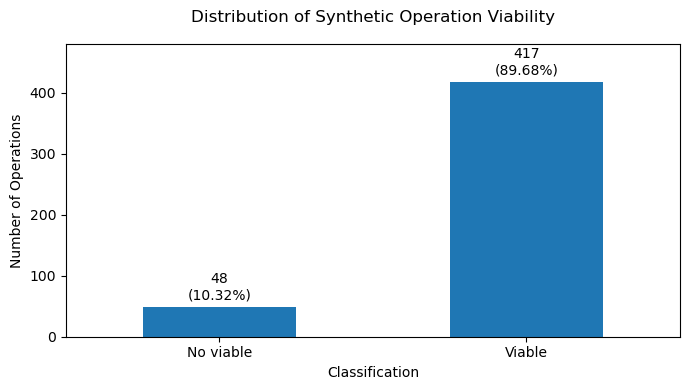

In [41]:
# ============================================================
# BLOCK 40: Final quality check before saving
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Create final quality check for Business_Model
# DataFrame created:
#  business_model_output_cols
# quality_business_model
# quality_business_model_display
# Files created:
#   - None
# ============================================================

business_model_output_cols = [
     "pricing_score",
    "tipo_nominal_anual",
    "comision_apertura_pct",
    "comision_disponibilidad_pct",
    "ingreso_comision_apertura",
    "ingreso_comision_disponibilidad",
     "ingreso_comisiones_totales",
    "coste_fondos_pct",
    "opex_pct_ead",
    "PD",
    "LGD",
    "EAD",
    "perdida_esperada",
    "ingreso_intereses_anual",
    "ingresos_totales",
    "coste_fondos",
    "opex",
    "margen_neto_ajustado",
    "margen_neto_ajustado_pct_ead",
    "operacion_viable"
]

quality_business_model = pd.DataFrame(
    {
        "Metrica": [
            "rows_business_model",
            "columns_business_model",
            "missing_values_business_model_outputs",
            "pd_min",
            "pd_max",
            "lgd_min",
            "lgd_max",
            "ead_min",
            "ead_max",
            "perdida_esperada_min",
            "perdida_esperada_max",
            "margen_neto_ajustado_min",
            "margen_neto_ajustado_max",
            "viable_base_count",
            "not_viable_base_count"
        ],
        "Valor": [
            len(hybrid),
            len(hybrid.columns),
            hybrid[business_model_output_cols].isna().sum().sum(),
            hybrid["PD"].min(),
            hybrid["PD"].max(),
            hybrid["LGD"].min(),
            hybrid["LGD"].max(),
            hybrid["EAD"].min(),
            hybrid["EAD"].max(),
            hybrid["perdida_esperada"].min(),
            hybrid["perdida_esperada"].max(),
            hybrid["margen_neto_ajustado"].min(),
            hybrid["margen_neto_ajustado"].max(),
            hybrid["operacion_viable"].sum(),
            (hybrid["operacion_viable"] == 0).sum()
        ]
    }
)

quality_business_model_display = quality_business_model.copy()

count_metrics = [
    "rows_business_model",
    "columns_business_model",
    "missing_values_business_model_outputs",
    "viable_base_count",
    "not_viable_base_count"
]

percentage_metrics = [
    "pd_min",
    "pd_max",
    "lgd_min",
    "lgd_max"
]

currency_metrics = [
    "ead_min",
    "ead_max",
    "perdida_esperada_min",
    "perdida_esperada_max",
    "margen_neto_ajustado_min",
    "margen_neto_ajustado_max"
]

quality_business_model_display["Valor"] = quality_business_model.apply(
    lambda row: (
        f"{int(row['Valor']):,}"
        if row["Metrica"] in count_metrics
        else f"{row['Valor']:.2%}"
        if row["Metrica"] in percentage_metrics
        else f"€{row['Valor']:,.0f}"
        if row["Metrica"] in currency_metrics
        else row["Valor"]
    ),
    axis=1
)

display(
   quality_business_model_display.style.hide(axis="index")
)


# Visualize the synthetic target distribution
viability_plot = (
    hybrid["operacion_viable"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No viable", 1: "Viable"})
)

ax = viability_plot.plot(
    kind="bar",
    figsize=(7, 4),
    rot=0
)

ax.set_title("Distribution of Synthetic Operation Viability", pad=16)
ax.set_xlabel("Classification")
ax.set_ylabel("Number of Operations")

# Add extra space above the tallest bar
ax.set_ylim(0, viability_plot.max() * 1.15)

for position, value in enumerate(viability_plot):
    percentage = value / len(hybrid)

    ax.text(
        position,
        value + viability_plot.max() * 0.02,
        f"{value}\n({percentage:.2%})",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The Business Model dataset contains 465 operations and 74 variables, with no missing values across the economic outputs. PD ranges from 2% to 22%, LGD from 17% to 53%, and expected loss from approximately €1,168 to €258,903. Adjusted net margins range from approximately −€157,623 to €111,312, producing 417 Viable and 48 Non-viable operations. These results confirm that the synthetic economic engine generates both profitable and loss-making cases, while the Non-viable share of 10.32% remains within the approved 5%–15% range despite the continued class imbalance toward Viable operations.

In [42]:
# ============================================================
# BLOCK 41: Save final Business Model Excel
# Source notebook:
#   - Business Model.ipynb
# Purpose:
#   - Save
# Files created:
#   - Business_Model.xlsx
# ============================================================

with pd.ExcelWriter(FINAL_PATH, engine="openpyxl") as writer:
    hybrid.to_excel(writer, sheet_name="Business_Model", index=False)
    quality_business_model.to_excel(writer, sheet_name="Quality_Check", index=False)

print("Final Business Model file created:")
print(FINAL_PATH)

Final Business Model file created:
/Users/ileanabeltranperez/Desktop/TFM/data/Business Model dataset/Business_Model.xlsx


<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART G: BUSINESS MODEL DEPURACIÓN AND VALIDATION
</div>

<br>

<div style="font-size:22px; color:#333;">
This section creates a working copy of the final Business Model dataset and reviews structure, variable roles, missing values, duplicates, negative values, outliers and categorical variables before preparing the modeling views.
</div>

In [43]:
# ============================================================
# BLOCK 42: Create Business Model working copy
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Create a working copy of the final Business Model dataset
#   - Preserve the original Business_Model output unchanged
# DataFrame created:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

business_model_2 = hybrid.copy()

print("Original Business Model shape:", hybrid.shape)
print("Business Model 2 working copy shape:", business_model_2.shape)

Original Business Model shape: (465, 74)
Business Model 2 working copy shape: (465, 74)


In [44]:
# ============================================================
# BLOCK 43: Review Business Model 2 structure
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review rows, columns, and data types before cleaning
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

print("Rows:", business_model_2.shape[0])
print("Columns:", business_model_2.shape[1])

business_model_2.info()

Rows: 465
Columns: 74
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 465 entries, 0 to 464
Data columns (total 74 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   operacion_id_simulada                     465 non-null    object 
 1   proyecto_id_simulado                      465 non-null    object 
 2   promotor_id_simulado                      465 non-null    object 
 3   Provincia                                 465 non-null    object 
 4   Año_originacion                           465 non-null    int64  
 5   No_Prestamo_proxy_RD                      465 non-null    int64  
 6   Negocio_proxy_RD                          465 non-null    object 
 7   Valor_RD_proxy                            465 non-null    float64
 8   prestamos_saldados_proxy_RD               465 non-null    int64  
 9   fecha_ultimo_pago_proxy_RD                321 non-null    object 
 10  total_valor_sald

In [45]:
# ============================================================
# BLOCK 43B: Classify variables by analytical role
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Classify Business Model variables before depuration
#   - Verify that all current variables are assigned once
# DataFrame checked:
#   - business_model_2
# DataFrames created:
#   - variable_group_summary
#   - variable_classification_check
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

id_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado"
]

rd_proxy_cols = [
    "No_Prestamo_proxy_RD",
    "Negocio_proxy_RD",
    "Valor_RD_proxy",
    "prestamos_saldados_proxy_RD",
    "fecha_ultimo_pago_proxy_RD",
    "total_valor_saldado_proxy_RD",
    "total_ultimo_pago_proxy_RD",
    "ha_saldado_antes_proxy_RD"
]

public_market_cols = [
    "Provincia",
    "Año_originacion",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)",
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

underwriting_cols = [
    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",
    "hito_actual",
    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "LTV_objetivo",
    "LTC_objetivo",
    "ead_por_ltv",
    "ead_por_ltc",
    "importe_dispuesto",
    "importe_comprometido",
    "importe_no_dispuesto",
    "EAD",
    "LTV",
    "LTC",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "indice_coste_base_mes",
    "indice_coste_seguimiento_mes",
    "indice_coste_base",
    "indice_coste_seguimiento",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos"
]

economic_risk_cols = [
    "pricing_score",
    "tipo_nominal_anual",
    "comision_apertura_pct",
    "comision_disponibilidad_pct",
    "ingreso_comision_apertura",
    "ingreso_comision_disponibilidad",
    "ingreso_comisiones_totales",
    "coste_fondos_pct",
    "opex_pct_ead",
    "PD",
    "LGD",
    "perdida_esperada",
    "ingreso_intereses_anual",
    "ingresos_totales",
    "coste_fondos",
    "opex",
    "margen_neto_ajustado",
    "margen_neto_ajustado_pct_ead"
]

target_col = "operacion_viable"

variable_groups = {
    "ID variables": [col for col in id_cols if col in business_model_2.columns],
    "RD proxy variables": [col for col in rd_proxy_cols if col in business_model_2.columns],
    "Public market variables": [col for col in public_market_cols if col in business_model_2.columns],
    "Underwriting variables": [col for col in underwriting_cols if col in business_model_2.columns],
    "Economic and risk variables": [col for col in economic_risk_cols if col in business_model_2.columns],
    "Target variable": [target_col] if target_col in business_model_2.columns else []
}

classified_cols = [
    col
    for cols in variable_groups.values()
    for col in cols
]

unclassified_cols = [
    col for col in business_model_2.columns
    if col not in classified_cols
]

duplicated_classification_cols = sorted({
    col for col in classified_cols
    if classified_cols.count(col) > 1
})

listed_cols = (
    id_cols
    + rd_proxy_cols
    + public_market_cols
    + underwriting_cols
    + economic_risk_cols
    + [target_col]
)

listed_but_missing_cols = [
    col for col in listed_cols
    if col not in business_model_2.columns
]

variable_group_summary = pd.DataFrame({
    "variable_group": list(variable_groups.keys()),
    "number_of_variables": [len(cols) for cols in variable_groups.values()]
})

variable_classification_check = pd.DataFrame({
    "check": [
        "Dataset columns",
        "Classified columns",
        "Unclassified columns",
        "Duplicated classifications",
        "Listed but missing columns"
    ],
    "result": [
        business_model_2.shape[1],
        len(classified_cols),
        len(unclassified_cols),
        len(duplicated_classification_cols),
        len(listed_but_missing_cols)
    ]
})

display(variable_group_summary)
display(variable_classification_check)

for group_name, cols in variable_groups.items():
    print("\n" + group_name)
    print(cols)

print("\nUnclassified columns")
print(unclassified_cols)

print("\nDuplicated classifications")
print(duplicated_classification_cols)

print("\nListed but missing columns")
print(listed_but_missing_cols)

,variable_group,number_of_variables
0,ID variables,3
1,RD proxy variables,8
2,Public market variables,14
3,Underwriting variables,30
4,Economic and risk variables,18
5,Target variable,1


,check,result
0,Dataset columns,74
1,Classified columns,74
2,Unclassified columns,0
3,Duplicated classifications,0
4,Listed but missing columns,0



ID variables
['operacion_id_simulada', 'proyecto_id_simulado', 'promotor_id_simulado']

RD proxy variables
['No_Prestamo_proxy_RD', 'Negocio_proxy_RD', 'Valor_RD_proxy', 'prestamos_saldados_proxy_RD', 'fecha_ultimo_pago_proxy_RD', 'total_valor_saldado_proxy_RD', 'total_ultimo_pago_proxy_RD', 'ha_saldado_antes_proxy_RD']

Public market variables
['Provincia', 'Año_originacion', 'Visados Viviendas', 'Superficie a Construir m2', 'm2 por Vivienda', 'Crecimiento YoY Viviendas', 'Crecimiento YoY m2', 'Volatilidad 4A Viviendas', 'Volatilidad 4A m2', 'Score Zona (nivel+tendencia-volatilidad)', 'Viviendas Siguiente Año', 'm2 Siguiente Año', 'Zona Buena Top2 Siguiente Año', 'Zona Buena Above Median Siguiente Año']

Underwriting variables
['tipo_promotor', 'promotor_experiencia_anios', 'promotor_proyectos_previos', 'equity_promotor_pct', 'deuda_existente_promotor_pct', 'documentacion_completa', 'riesgo_legal_titulo', 'tipo_activo', 'hito_actual', 'coste_total_proyecto', 'valor_tasacion_as_is', '

The Business Model contains 74 variables, including 3 identifiers, 8 RD proxy variables, 14 public market variables, 30 underwriting variables, 18 economic and risk variables, and 1 synthetic target variable. The classification check confirms that all 74 variables were assigned to one analytical group, with no unclassified variables, duplicated classifications, or listed variables missing from the dataset. This provides a clear view of how the information is distributed across the model and supports the next depuration decisions, especially the separation of operational and underwriting information from identifiers, RD proxies, future validation fields, and variables that directly form part of the synthetic viability rule.

In [46]:
# ============================================================
# BLOCK 43C: Review descriptive statistics
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review descriptive statistics for numeric variables before depuration
#   - Identify scale, dispersion, minimum and maximum values
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

numeric_cols = business_model_2.select_dtypes(include=["number"]).columns.tolist()

descriptive_statistics = (
    business_model_2[numeric_cols]
    .describe()
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

descriptive_statistics_display = (
    descriptive_statistics.style
    .format({
        "count": "{:,.0f}",
        "mean": "{:,.4f}",
        "std": "{:,.4f}",
        "min": "{:,.4f}",
        "25%": "{:,.4f}",
        "50%": "{:,.4f}",
        "75%": "{:,.4f}",
        "max": "{:,.4f}"
    })
    .set_caption("Descriptive Statistics for Numeric Variables")
    .set_properties(**{
        "text-align": "right",
        "padding": "6px"
    })
    .set_properties(
        subset=["variable"],
        **{
            "text-align": "left",
            "font-weight": "bold"
        }
    )
    .set_table_styles([
        {
            "selector": "caption",
            "props": [
                ("font-size", "15px"),
                ("font-weight", "bold"),
                ("text-align", "left"),
                ("margin-bottom", "8px")
            ]
        },
        {
            "selector": "th",
            "props": [
                ("text-align", "center"),
                ("font-weight", "bold")
            ]
        }
    ])
    .hide(axis="index")
)

display(descriptive_statistics_display)

variable,count,mean,std,min,25%,50%,75%,max
Año_originacion,465,"2,010.0000",8.9539,"1,995.0000","2,002.0000","2,010.0000","2,018.0000","2,025.0000"
No_Prestamo_proxy_RD,465,423.1570,24.8525,369.0000,406.0000,426.0000,445.0000,459.0000
Valor_RD_proxy,465,"278,813.1252","742,186.3653",525.0000,"6,825.0000","40,200.0100","196,355.0000","4,308,000.0000"
prestamos_saldados_proxy_RD,465,1.2774,1.3718,0.0000,0.0000,1.0000,2.0000,6.0000
total_valor_saldado_proxy_RD,465,"120,828.9810","202,716.5815",0.0000,0.0000,"22,000.0000","115,600.0000","735,000.0000"
total_ultimo_pago_proxy_RD,465,"97,784.1234","179,405.6610",0.0000,0.0000,"3,597.0000","60,000.0000","727,500.0000"
ha_saldado_antes_proxy_RD,465,0.6903,0.4629,0.0000,0.0000,1.0000,1.0000,1.0000
Visados Viviendas,465,"8,636.0559","11,263.2491",46.0000,"1,128.0000","3,772.0000","11,987.0000","58,398.0000"
Superficie a Construir m2,465,"2,337,055.0624","2,902,680.8366","66,194.0000","418,874.0000","1,206,893.0000","2,949,414.0000","17,005,910.0000"
m2 por Vivienda,465,107.1031,10.8593,79.9395,99.0439,106.2023,113.4809,173.5797


The descriptive review covers 62 numeric variables across the 465 simulated operations. The dataset spans market observations from 1995 to 2025 and includes variables with very different scales, from binary indicators to financing amounts above €4 million. The adjusted net margin averages approximately €27,764 and ranges from a loss of about €157,623 to a gain of about €111,312, confirming that the synthetic Business Model generates both profitable and loss-making operations. The mean of operacion_viable is 89.68%, equivalent to 417 Viable and 48 Non-viable operations, so the minority class represents 10.32% of the dataset. These results provide an initial check of the economic range and variable distributions before the depuration and modeling stages.

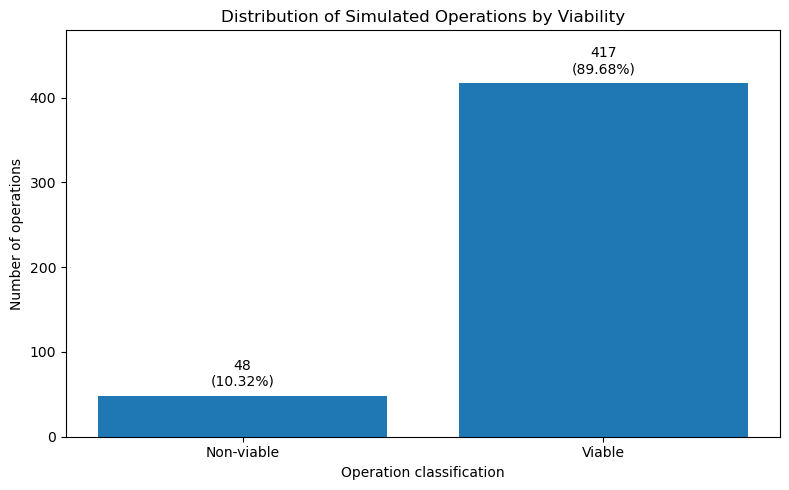

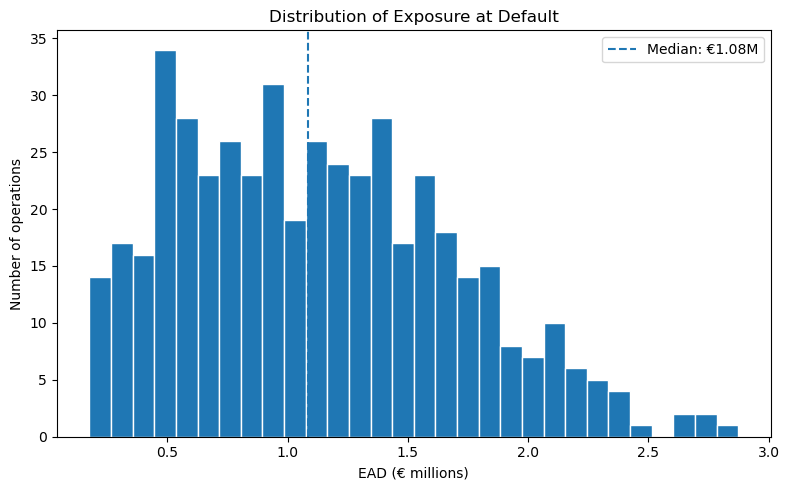

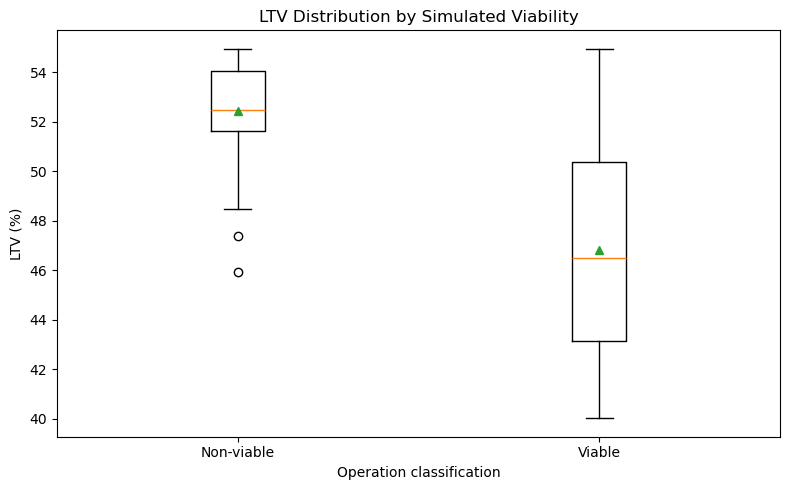

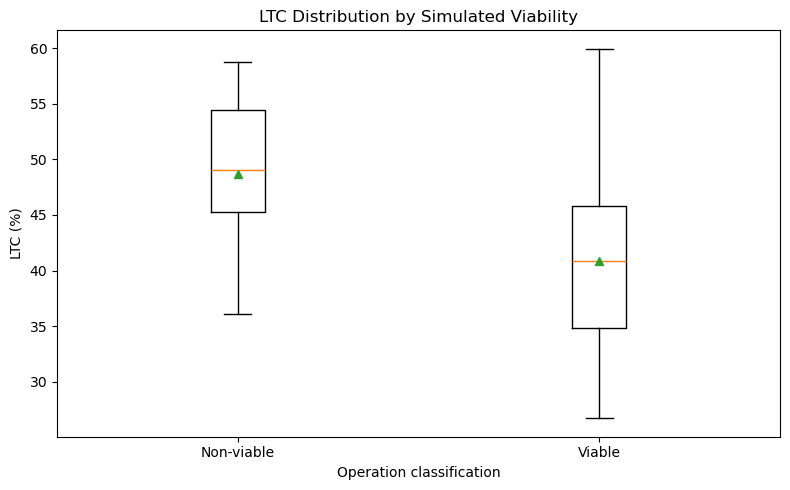

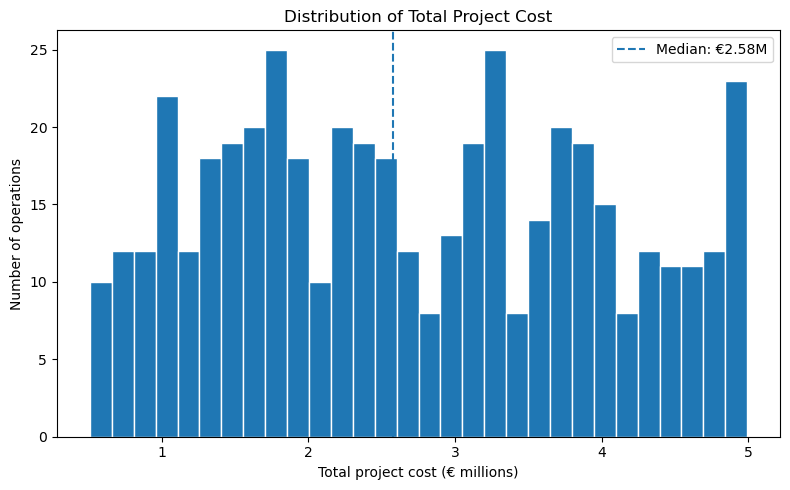

In [47]:
# ============================================================
# BLOCK 43D: Graphical review of key variables
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Visualize key Business Model variables before depuration
#   - Review the target distribution and selected numeric relationships
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

# Target distribution
target_counts = (
    business_model_2["operacion_viable"]
    .value_counts()
    .sort_index()
)

target_labels = ["Non-viable", "Viable"]
target_percentages = target_counts / target_counts.sum() * 100

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    target_labels,
    target_counts.values
)

ax.set_title("Distribution of Simulated Operations by Viability")
ax.set_xlabel("Operation classification")
ax.set_ylabel("Number of operations")
ax.set_ylim(0, target_counts.max() * 1.15)

for bar, count, percentage in zip(
    bars,
    target_counts.values,
    target_percentages.values
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + target_counts.max() * 0.02,
        f"{count:,}\n({percentage:.2f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()


# EAD distribution in EUR millions
ead_millions = business_model_2["EAD"] / 1_000_000

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    ead_millions,
    bins=30,
    edgecolor="white"
)

ax.axvline(
    ead_millions.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: €{ead_millions.median():.2f}M"
)

ax.set_title("Distribution of Exposure at Default")
ax.set_xlabel("EAD (€ millions)")
ax.set_ylabel("Number of operations")
ax.legend()

plt.tight_layout()
plt.show()


# LTV by target
ltv_plot_data = [
    business_model_2.loc[
        business_model_2["operacion_viable"] == 0,
        "LTV"
    ] * 100,
    business_model_2.loc[
        business_model_2["operacion_viable"] == 1,
        "LTV"
    ] * 100
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    ltv_plot_data,
    tick_labels=target_labels,
    showmeans=True
)

ax.set_title("LTV Distribution by Simulated Viability")
ax.set_xlabel("Operation classification")
ax.set_ylabel("LTV (%)")

plt.tight_layout()
plt.show()


# LTC by target
ltc_plot_data = [
    business_model_2.loc[
        business_model_2["operacion_viable"] == 0,
        "LTC"
    ] * 100,
    business_model_2.loc[
        business_model_2["operacion_viable"] == 1,
        "LTC"
    ] * 100
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(
    ltc_plot_data,
    tick_labels=target_labels,
    showmeans=True
)

ax.set_title("LTC Distribution by Simulated Viability")
ax.set_xlabel("Operation classification")
ax.set_ylabel("LTC (%)")

plt.tight_layout()
plt.show()


# Project cost distribution in EUR millions
project_cost_millions = (
    business_model_2["coste_total_proyecto"] / 1_000_000
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    project_cost_millions,
    bins=30,
    edgecolor="white"
)

ax.axvline(
    project_cost_millions.median(),
    linestyle="--",
    linewidth=1.5,
    label=f"Median: €{project_cost_millions.median():.2f}M"
)

ax.set_title("Distribution of Total Project Cost")
ax.set_xlabel("Total project cost (€ millions)")
ax.set_ylabel("Number of operations")
ax.legend()

plt.tight_layout()
plt.show()

The graphs confirm that the synthetic portfolio remains imbalanced, with 417 Viable operations and 48 Non-viable operations, equivalent to 89.68% and 10.32%, respectively. This means that accuracy alone could provide an overly positive view of model performance, since a classifier could predict most operations as Viable while failing to identify the smaller Non-viable group. EAD is concentrated mainly in the lower and middle exposure ranges, with a median of approximately €1.08 million and fewer operations at the highest exposure levels. The clearest difference between the two groups appears in LTV, as Non-viable operations are concentrated at higher leverage levels, while Viable operations generally show lower LTV and a wider range. This is consistent with the Business Model logic, since higher LTV reduces the lender’s collateral cushion. LTC also tends to be higher among Non-viable operations, although the overlap between both groups is greater, so it provides less visual separation than LTV. Total project cost is broadly distributed across the simulated range, with a median of approximately €2.58 million, confirming that the portfolio includes projects of different sizes rather than being concentrated around one typical project value.

In [48]:
# ============================================================
# BLOCK 44: Review missing values
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Identify missing values in Business Model 2
#   - Review whether missing values are expected or require treatment
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - missing_summary_business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

missing_summary_business_model_2 = (
    business_model_2
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "variable", 0: "missing_values"})
)

missing_summary_business_model_2["missing_pct"] = (
    missing_summary_business_model_2["missing_values"] / len(business_model_2)
).round(4)

missing_summary_business_model_2 = missing_summary_business_model_2.sort_values(
    by="missing_values",
    ascending=False
)

missing_summary_business_model_2[
    missing_summary_business_model_2["missing_values"] > 0
]

,variable,missing_values,missing_pct
9,fecha_ultimo_pago_proxy_RD,144,0.3097
22,m2 Siguiente Año,15,0.0323
21,Viviendas Siguiente Año,15,0.0323


fecha_ultimo_pago_proxy_RD has 144 missing values, representing 30.97% of the 465 operations, so it requires specific treatment due to its high level of missingness. Viviendas Siguiente Año and m2 Siguiente Año each have 15 missing values, or 3.23% of the dataset. These gaps are expected because the variables depend on the following year’s market information, which is not available for the final observation in each provincial series. They may still be useful for future validation or descriptive context, but they should not be used as predictors at the initial evaluation stage

In [49]:
# ============================================================
# BLOCK 45: Review duplicate records
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Check exact duplicate rows and duplicated operation IDs
#   - Confirm whether duplicated records require treatment
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

duplicate_rows = business_model_2.duplicated().sum()
duplicate_operation_ids = business_model_2["operacion_id_simulada"].duplicated().sum()

print("duplicate rows:", duplicate_rows)
print("Duplicate operacion_id_simulada:", duplicate_operation_ids)

if duplicate_operation_ids > 0:
    display(
        business_model_2[
            business_model_2["operacion_id_simulada"].duplicated(keep=False)
        ].sort_values("operacion_id_simulada")
    )

duplicate rows: 0
Duplicate operacion_id_simulada: 0


No duplicates were identified. Therefore, no duplicate treatment is required. 

In [50]:
# ============================================================
# BLOCK 46: Review negative values in numeric columns
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Check all numeric columns for negative values
#   - Identify which negative values are valid and which may require treatment
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

numeric_cols = business_model_2.select_dtypes(include=["number"]).columns

negative_values_summary = pd.DataFrame({
    "variable": numeric_cols,
    "negative_values": [
        (business_model_2[col] < 0).sum()
        for col in numeric_cols
    ]
})

negative_values_summary = negative_values_summary[
    negative_values_summary["negative_values"] > 0
].sort_values("negative_values", ascending=False)

negative_values_summary

,variable,negative_values
14,Score Zona (nivel+tendencia-volatilidad),249
40,desviacion_coste_pct,209
11,Crecimiento YoY m2,205
10,Crecimiento YoY Viviendas,199
59,margen_neto_ajustado,48
60,margen_neto_ajustado_pct_ead,48


The review confirms that the negative values reflect valid Business Model outcomes rather than data-quality problems. The 249 negative Score Zona observations identify market-year combinations with weaker relative conditions, while negative growth rates in housing permits and construction surface capture periods of market contraction. The 209 negative values in desviacion_coste_pct indicate cases where the follow-up cost index is below the initial reference level, representing cost relief rather than an error. The 48 negative adjusted margins correspond exactly to the 48 Non-viable operations, so these values are central to the synthetic economic decision rule. No correction is required because each negative value has a valid interpretation.

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
5,total_ultimo_pago_proxy_RD,0.000000,6.000000e+04,6.000000e+04,-9.000000e+04,1.500000e+05,96,20.65
35,indice_coste_seguimiento,132.044313,1.353497e+02,3.305375e+00,1.270863e+02,1.403077e+02,90,19.35
4,total_valor_saldado_proxy_RD,0.000000,1.156000e+05,1.156000e+05,-1.734000e+05,2.890000e+05,77,16.56
2,Valor_RD_proxy,6825.000000,1.963550e+05,1.895300e+05,-2.774700e+05,4.806500e+05,70,15.05
7,Superficie a Construir m2,418874.000000,2.949414e+06,2.530540e+06,-3.376936e+06,6.745224e+06,40,8.60
15,m2 Siguiente Año,407439.000000,2.952837e+06,2.545398e+06,-3.410658e+06,6.770934e+06,39,8.39
48,perdida_esperada,7579.061127,3.611258e+04,2.853352e+04,-3.522122e+04,7.891286e+04,38,8.17
6,Visados Viviendas,1128.000000,1.198700e+04,1.085900e+04,-1.516050e+04,2.827550e+04,38,8.17
14,Viviendas Siguiente Año,1050.750000,1.212650e+04,1.107575e+04,-1.556288e+04,2.874012e+04,35,7.53
36,desviacion_coste_pct,-0.010200,3.828019e-02,4.848027e-02,-8.292048e-02,1.110006e-01,29,6.24


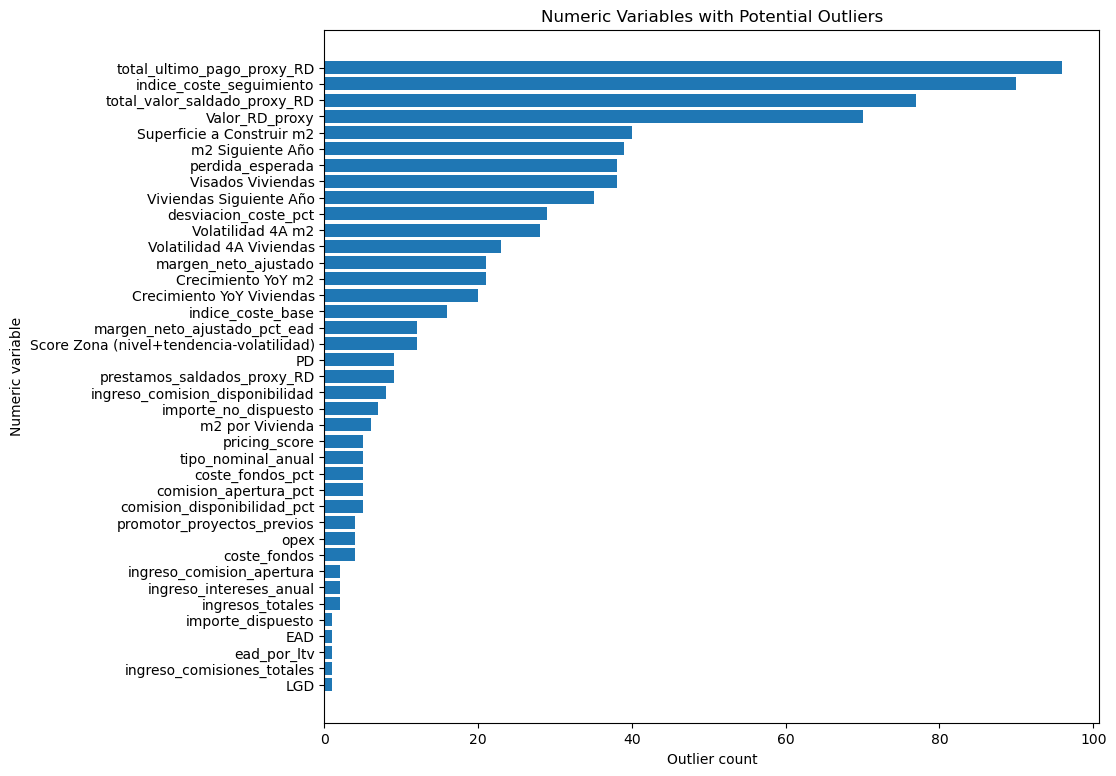

In [51]:
# ============================================================
# BLOCK 47: Review outliers in numeric variables
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Identify potential outliers in continuous numeric variables
#   - Review whether extreme values may require treatment before modeling
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - outlier_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Binary variables are excluded from the outlier review.
#   - Outliers are identified using the IQR method.
# ============================================================


# Identify numeric columns in Business Model 2
numeric_cols = business_model_2.select_dtypes(include=["number"]).columns.tolist()


# Identify binary numeric columns
binary_cols = [
    col for col in numeric_cols
    if business_model_2[col].dropna().nunique() <= 2
]

# Keep numeric variables that are not binary
continuous_numeric_cols = [
    col for col in numeric_cols
    if col not in binary_cols
]


# Calculate potential outliers using the IQR method

outlier_summary = []

for col in continuous_numeric_cols:
    q1 = business_model_2[col].quantile(0.25)
    q3 = business_model_2[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outlier_count = (
        (business_model_2[col] < lower_bound) |
        (business_model_2[col] > upper_bound)
    ).sum()

    outlier_summary.append({
        "variable": col,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": outlier_count,
        "outlier_pct": round(outlier_count / len(business_model_2) * 100, 2)
    })

# Convert results into a summary table
outlier_summary = pd.DataFrame(outlier_summary).sort_values(
    by="outlier_count",
    ascending=False
)

# Keep only variables with at least one potential outlier
outlier_summary_filtered = outlier_summary[
    outlier_summary["outlier_count"] > 0
]

display(outlier_summary_filtered)

# Plot all variables with at least one potential outlier
outlier_plot = outlier_summary_filtered.sort_values(
    by="outlier_count",
    ascending=False
)

plt.figure(figsize=(10, 9))
plt.barh(
    outlier_plot["variable"],
    outlier_plot["outlier_count"]
)
plt.title("Numeric Variables with Potential Outliers")
plt.xlabel("Outlier count")
plt.ylabel("Numeric variable")
plt.gca().invert_yaxis()
plt.show()

The IQR review identifies statistically unusual observations but does not provide evidence of data errors. The largest concentrations occur in `total_ultimo_pago_proxy_RD` with 96 cases (20.65%), `indice_coste_seguimiento` with 90 (19.35%), `total_valor_saldado_proxy_RD` with 77 (16.56%) and `Valor_RD_proxy` with 70 (15.05%); the RD proxy variables are later removed from the predictive views, while the cost-index pattern reflects the limited set of observed INE index levels rather than invalid records. Among the core Business Model variables, `perdida_esperada` has 38 potential outliers (8.17%), `desviacion_coste_pct` 29 (6.24%), `margen_neto_ajustado` 21 (4.52%) and `margen_neto_ajustado_pct_ead` 12 (2.58%), representing economically plausible higher-risk, cost-pressure or loss-making operations. By contrast, EAD and LGD each contain only one potential outlier (0.22%), while PD contains nine (1.94%). All observations remain within the predefined structural limits: EAD reaches a maximum of approximately €2.87 million against the €3 million cap, LTV 54.96% against 55%, LTC 59.94% against 75%, PD 22% against 25% and LGD 53% against 60%. Removing or winsorizing these observations would compress the intended risk distribution and could disproportionately eliminate part of the 48 Non-viable operations, producing an artificially favorable portfolio. Therefore, no rows are deleted solely because they exceed the IQR bounds, and all 465 operations are retained unless a separate validation identifies an impossible value, duplicated record, calculation error or explicit breach of the Business Model assumptions.


In [52]:
# ============================================================
# BLOCK 47A: Filter outlier summary to variables with 10+ potential outliers
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Narrow the outlier review to the variables the text discusses individually
#   - Report how many variables were excluded below the 10-observation cutoff
# DataFrame checked:
#   - outlier_summary_filtered
# DataFrame created:
#   - outlier_summary_top
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - This step does not rebuild the outlier chart above; it reuses
#     outlier_summary_filtered, the same data already used to plot it
#   - The 10-observation cutoff keeps every variable named individually in
#     the text, down to margen_neto_ajustado_pct_ead at 12, while excluding
#     everything the text does not discuss
#   - outlier_pct already expresses each count as a percentage of the 465
#     operations in business_model_2, computed in Block 47, and is carried
#     over unchanged rather than recalculated
#   - Only variable, outlier_count and outlier_pct are kept; q1/q3/iqr/bounds
#     are dropped here since Block 47's own table already shows them
# ============================================================

OUTLIER_COUNT_CUTOFF = 10

outlier_summary_top = (
    outlier_summary_filtered[
        outlier_summary_filtered["outlier_count"] >= OUTLIER_COUNT_CUTOFF
    ]
    [["variable", "outlier_count", "outlier_pct"]]
    .sort_values(
        by="outlier_count",
        ascending=False
    )
    .reset_index(drop=True)
)

display(outlier_summary_top)

variables_below_cutoff = (
    len(outlier_summary_filtered) - len(outlier_summary_top)
)

print(
    f"Variables with {OUTLIER_COUNT_CUTOFF} or more potential outliers:",
    len(outlier_summary_top)
)
print(
    "Variables excluded below the cutoff:",
    variables_below_cutoff
)

,variable,outlier_count,outlier_pct
0,total_ultimo_pago_proxy_RD,96,20.65
1,indice_coste_seguimiento,90,19.35
2,total_valor_saldado_proxy_RD,77,16.56
3,Valor_RD_proxy,70,15.05
4,Superficie a Construir m2,40,8.60
5,m2 Siguiente Año,39,8.39
6,perdida_esperada,38,8.17
7,Visados Viviendas,38,8.17
8,Viviendas Siguiente Año,35,7.53
9,desviacion_coste_pct,29,6.24


Variables with 10 or more potential outliers: 18
Variables excluded below the cutoff: 21


,variable,unique_categories,missing_values,most_frequent_category,most_frequent_count,most_frequent_pct
0,operacion_id_simulada,465,0,ESP_A_00001,1,0.22
1,proyecto_id_simulado,465,0,PROY_00001,1,0.22
2,promotor_id_simulado,465,0,promotor_00001,1,0.22
11,indice_coste_seguimiento_mes,54,0,2023M06,18,3.87
10,indice_coste_base_mes,51,0,2022M06,15,3.23
5,fecha_ultimo_pago_proxy_RD,30,144,NaT,144,30.97
3,Provincia,15,0,Alicante,31,6.67
4,Negocio_proxy_RD,6,0,PERSONAL,384,82.58
6,tipo_promotor,5,0,sociedad_vehiculo_proyecto,105,22.58
9,hito_actual,4,0,avance_intermedio,134,28.82


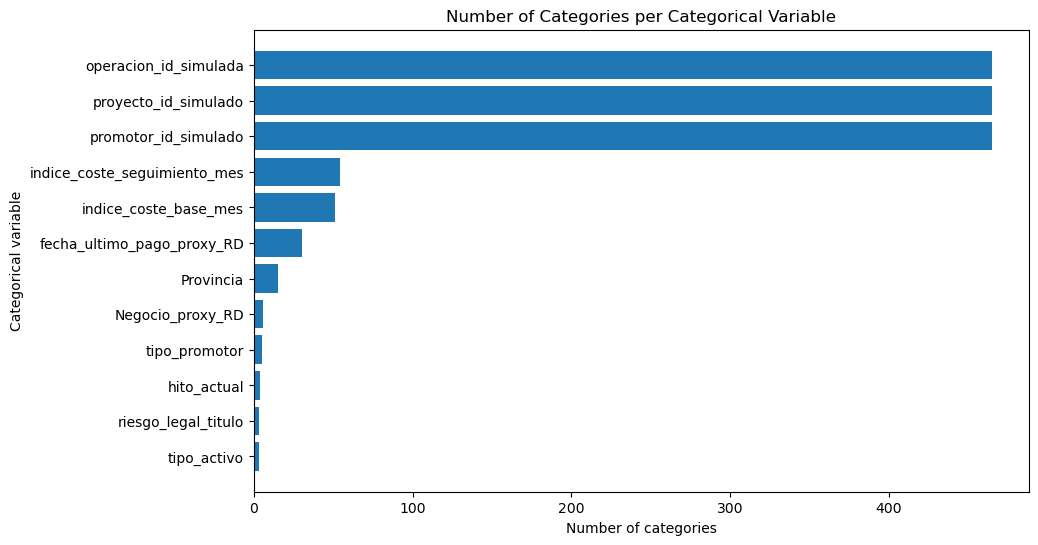

In [53]:
# ============================================================
# BLOCK 48: Review categorical variables and number of categories
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review categorical variables before column treatment
#   - Identify the number of categories in each categorical variable
#   - Detect high-cardinality or traceability variables
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - categorical_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - This block is diagnostic only.
#   - Categorical variables are reviewed before dropping, grouping, or encoding.
#   - The review helps identify variables that may be irrelevant, high-cardinality, or useful for dummy encoding.
# ============================================================

# Identify categorical columns
categorical_cols = business_model_2.select_dtypes(include=["object", "category"]).columns.tolist()

# Summarize categorical variables
categorical_summary = []

for col in categorical_cols:
    value_counts = business_model_2[col].value_counts(dropna=False)

    categorical_summary.append({
        "variable": col,
        "unique_categories": business_model_2[col].nunique(dropna=False),
        "missing_values": business_model_2[col].isna().sum(),
        "most_frequent_category": value_counts.index[0],
        "most_frequent_count": value_counts.iloc[0],
        "most_frequent_pct": round(value_counts.iloc[0] / len(business_model_2) * 100, 2)
    })

categorical_summary = pd.DataFrame(categorical_summary).sort_values(
    by="unique_categories",
    ascending=False
)

display(categorical_summary)

# Plot number of categories per categorical variable
categorical_plot = categorical_summary.sort_values(
    by="unique_categories",
    ascending=False
)

plt.figure(figsize=(10, 6))
plt.barh(
    categorical_plot["variable"],
    categorical_plot["unique_categories"]
)
plt.title("Number of Categories per Categorical Variable")
plt.xlabel("Number of categories")
plt.ylabel("Categorical variable")
plt.gca().invert_yaxis()
plt.show()

This block shows that the categorical variables have very different analytical roles. The three simulated identifiers contain 465 unique values each, so they are useful only for traceability and should not be treated as predictive categories. The two cost-index month fields also have relatively high cardinality, with 51 and 54 distinct values, while fecha_ultimo_pago_proxy_RD has 30 categories and 144 missing observations, reinforcing that these fields need separate treatment before modeling. The remaining business variables have low and manageable cardinality: 15 provinces, 6 RD business categories, 5 promoter types, 4 project milestones, and 3 categories each for legal risk and asset type. The category distributions are also business-plausible, although some variables are clearly concentrated in one group, such as Negocio_proxy_RD in PERSONAL, riesgo_legal_titulo in low risk, and tipo_activo in new construction. Overall, the block confirms that the true business categories are suitable for later encoding, while identifiers and date-like fields should not be used as ordinary categorical predictors.

# Depuration

In [54]:
# ============================================================
# BLOCK 49: Treat missing values
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Remove the RD proxy date field with high missingness
#   - Preserve all operations
#   - Review remaining missing values before final exclusions
# DataFrame updated:
#   - business_model_2
# Columns dropped:
#   - fecha_ultimo_pago_proxy_RD
# Files created:
#   - None
# ============================================================

business_model_2 = business_model_2.drop(
    columns=["fecha_ultimo_pago_proxy_RD"],
    errors="ignore"
)

remaining_missing = (
    business_model_2.isna().sum()
    .loc[lambda x: x > 0]
    .sort_values(ascending=False)
    .rename("missing_values")
    .to_frame()
)

remaining_missing["missing_pct"] = (
    remaining_missing["missing_values"] / len(business_model_2)
)

target_distribution = (
    business_model_2["operacion_viable"]
    .value_counts()
    .sort_index()
    .rename_axis("operacion_viable")
    .reset_index(name="operations")
)

target_distribution["percentage"] = (
    target_distribution["operations"] / len(business_model_2)
)

print("Dataset shape:", business_model_2.shape)

display(
    remaining_missing.style
    .format({
        "missing_values": "{:,.0f}",
        "missing_pct": "{:.2%}"
    })
    .set_caption("Remaining Missing Values")
)

display(
    target_distribution.style
    .format({
        "operations": "{:,.0f}",
        "percentage": "{:.2%}"
    })
    .set_caption("Target Distribution After Missing-Value Treatment")
    .hide(axis="index")
)

Dataset shape: (465, 73)


,missing_values,missing_pct
Viviendas Siguiente Año,15,3.23%
m2 Siguiente Año,15,3.23%


operacion_viable,operations,percentage
0,48,10.32%
1,417,89.68%


The dataset retains all 465 simulated operations and removes only fecha_ultimo_pago_proxy_RD, reducing the dataset from 74 to 73 columns. The remaining missing values are limited to Viviendas Siguiente Año and m2 Siguiente Año, with 15 missing observations each, equivalent to 3.23% of the dataset. These gaps are expected because the final market year has no following-year value available, and both variables are later excluded from the predictive views. The target distribution remains unchanged at 48 Non-viable operations and 417 Viable operations, confirming that the missing-value treatment did not reduce the sample or alter the synthetic Business Model outcome.

In [55]:
# ============================================================
# BLOCK 50: Remove variables not valid for modeling
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Remove identifiers, RD proxies, future variables and leakage variables
#   - Create the clean base for the origination and monitoring views
# DataFrames checked:
#   - hybrid
#   - business_model_2
# DataFrame updated:
#   - business_model_2
# Files created:
#   - None
# ============================================================

id_cols = [
    "operacion_id_simulada",
    "proyecto_id_simulado",
    "promotor_id_simulado"
]

rd_proxy_cols = [
    "No_Prestamo_proxy_RD",
    "Negocio_proxy_RD",
    "Valor_RD_proxy",
    "prestamos_saldados_proxy_RD",
    "total_valor_saldado_proxy_RD",
    "total_ultimo_pago_proxy_RD",
    "ha_saldado_antes_proxy_RD"
]

future_cols = [
    "Viviendas Siguiente Año",
    "m2 Siguiente Año",
    "Zona Buena Top2 Siguiente Año",
    "Zona Buena Above Median Siguiente Año"
]

leakage_cols = [
    "margen_neto_ajustado",
    "margen_neto_ajustado_pct_ead",
    "ingresos_totales",
    "ingreso_intereses_anual",
    "ingreso_comisiones_totales",
    "ingreso_comision_apertura",
    "ingreso_comision_disponibilidad",
    "coste_fondos",
    "coste_fondos_pct",
    "opex",
    "opex_pct_ead",
    "perdida_esperada",
    "PD",
    "LGD",
    "tipo_nominal_anual",
    "comision_apertura_pct",
    "comision_disponibilidad_pct",
    "pricing_score",
    "EAD",
    "ead_por_ltv",
    "ead_por_ltc",
    "importe_dispuesto",
    "importe_comprometido",
    "importe_no_dispuesto"
]

excluded_predictive_cols = (
    id_cols
    + rd_proxy_cols
    + future_cols
    + leakage_cols
)

business_model_2 = business_model_2.drop(
    columns=excluded_predictive_cols,
    errors="ignore"
).copy()

print("Original full Business Model:", hybrid.shape)
print("Clean Business Model:", business_model_2.shape)
print("Columns excluded:", len(excluded_predictive_cols))
print("Remaining missing values:", business_model_2.isna().sum().sum())
print("Target available:", "operacion_viable" in business_model_2.columns)

Original full Business Model: (465, 74)
Clean Business Model: (465, 35)
Columns excluded: 38
Remaining missing values: 0
Target available: True


The depuration process preserves all 465 simulated operations while reducing the original Business Model from 74 to 35 variables. One variable, fecha_ultimo_pago_proxy_RD, had already been removed during missing-value treatment, and the subsequent depuration excluded 38 additional variables. The resulting dataset contains no missing values and retains operacion_viable as the synthetic target. The excluded variables correspond to identifiers, RD proxy information, future market fields and components used directly to construct the economic viability rule, preventing traceability fields, unavailable future information and target leakage from entering the supervised models.

# Origination view 

In [56]:
# ============================================================
# BLOCK 51: Build origination view
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Build the origination view for the initial approval moment
#   - Keep the target variable for supervised classification
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - origination_view
#   - origination_view_columns
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - origination_view includes only variables available at the initial evaluation moment.
#   - The target variable operacion_viable is kept for supervised classification.
# ============================================================

target_col = "operacion_viable"

origination_predictor_cols = [
    # Public market variables available at origination
    "Provincia",
    "Año_originacion",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)",

    # Promotor and project profile variables available at origination
    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",

    # Financial structure variables available at origination
    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "LTV",
    "LTC",
    "porcentaje_preventas",

    # Base cost index variables available at origination
    "indice_coste_base_mes",
    "indice_coste_base"
]

origination_view = business_model_2[
    origination_predictor_cols + [target_col]
].copy()

origination_view_columns = pd.DataFrame({
    "view": "origination_view",
    "variable": origination_view.columns,
    "role": [
        "target" if col == target_col else "origination_predictor"
        for col in origination_view.columns
    ]
})

print("Business Model 2 shape:", business_model_2.shape)
print("Origination view shape:", origination_view.shape)
print("Origination predictors:", len(origination_predictor_cols))
print("Target variable available:", target_col in origination_view.columns)

display(origination_view_columns)

Business Model 2 shape: (465, 35)
Origination view shape: (465, 26)
Origination predictors: 25
Target variable available: True


,view,variable,role
0,origination_view,Provincia,origination_predictor
1,origination_view,Año_originacion,origination_predictor
2,origination_view,Visados Viviendas,origination_predictor
3,origination_view,Superficie a Construir m2,origination_predictor
4,origination_view,m2 por Vivienda,origination_predictor
5,origination_view,Crecimiento YoY Viviendas,origination_predictor
6,origination_view,Crecimiento YoY m2,origination_predictor
7,origination_view,Volatilidad 4A Viviendas,origination_predictor
8,origination_view,Volatilidad 4A m2,origination_predictor
9,origination_view,Score Zona (nivel+tendencia-volatilidad),origination_predictor


The origination view contains all 465 simulated operations and 25 predictors available at the initial underwriting stage, together with operacion_viable as the synthetic target. The selected variables combine territorial context, promoter profile, project characteristics, leverage, pre-sales and the initial cost reference, allowing the model to evaluate the operation using information available before monitoring begins. No future variables, RD proxies or direct components of the economic viability calculation remain in this view, so the structure is suitable for supervised modeling without target leakage.

# Monitoring view

In [57]:
# ============================================================
# BLOCK 52: Build monitoring view
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Build the view for the monitoring moment
#   - Explicitly list all variables included in monitoring_view
#   - Keep the target variable for supervised classification
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - monitoring_view
#   - monitoring_view_columns
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - monitoring_view is created from the depurated business_model_2.
#   - It includes all origination predictors.
#   - It also includes variables observed during project monitoring.
# ============================================================

monitoring_predictor_cols = [
    # Origination predictors
    "Provincia",
    "Año_originacion",
    "Visados Viviendas",
    "Superficie a Construir m2",
    "m2 por Vivienda",
    "Crecimiento YoY Viviendas",
    "Crecimiento YoY m2",
    "Volatilidad 4A Viviendas",
    "Volatilidad 4A m2",
    "Score Zona (nivel+tendencia-volatilidad)",

    "tipo_promotor",
    "promotor_experiencia_anios",
    "promotor_proyectos_previos",
    "equity_promotor_pct",
    "deuda_existente_promotor_pct",
    "documentacion_completa",
    "riesgo_legal_titulo",
    "tipo_activo",

    "coste_total_proyecto",
    "valor_tasacion_as_is",
    "LTV",
    "LTC",
    "porcentaje_preventas",

    "indice_coste_base_mes",
    "indice_coste_base",

    # Monitoring predictors
    "hito_actual",
    "retraso_obra_meses",
    "indice_coste_seguimiento_mes",
    "indice_coste_seguimiento",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos"
]

monitoring_view = business_model_2[
    monitoring_predictor_cols + [target_col]
].copy()

monitoring_view_columns = pd.DataFrame({
    "view": "monitoring_view",
    "variable": monitoring_view.columns,
    "role": [
        "target" if col == target_col
        else "monitoring_predictor" if col in [
            "hito_actual",
            "retraso_obra_meses",
            "indice_coste_seguimiento_mes",
            "indice_coste_seguimiento",
            "desviacion_coste_pct",
            "evidencia_hito",
            "stop_desembolsos"
        ]
        else "origination_predictor"
        for col in monitoring_view.columns
    ]
})

print("Business Model 2 shape:", business_model_2.shape)
print("Monitoring view shape:", monitoring_view.shape)
print("Monitoring predictors:", len(monitoring_predictor_cols))
print("Target variable available:", target_col in monitoring_view.columns)

display(monitoring_view_columns)

Business Model 2 shape: (465, 35)
Monitoring view shape: (465, 33)
Monitoring predictors: 32
Target variable available: True


,view,variable,role
0,monitoring_view,Provincia,origination_predictor
1,monitoring_view,Año_originacion,origination_predictor
2,monitoring_view,Visados Viviendas,origination_predictor
3,monitoring_view,Superficie a Construir m2,origination_predictor
4,monitoring_view,m2 por Vivienda,origination_predictor
5,monitoring_view,Crecimiento YoY Viviendas,origination_predictor
6,monitoring_view,Crecimiento YoY m2,origination_predictor
7,monitoring_view,Volatilidad 4A Viviendas,origination_predictor
8,monitoring_view,Volatilidad 4A m2,origination_predictor
9,monitoring_view,Score Zona (nivel+tendencia-volatilidad),origination_predictor


The monitoring view contains all 465 simulated operations and 32 predictors, adding seven follow-up variables to the origination information. These variables capture project progress, construction delays, updated cost conditions, milestone evidence and the temporary suspension of further drawdowns, reflecting the information available during the life of the operation and allowing the model to reassess synthetic viability as new operational risks emerge. The view excludes RD proxies and the direct economic outputs used to construct the target, including PD, LGD, expected loss, income, funding costs, OPEX and adjusted margin, while retaining the underlying underwriting and monitoring risk drivers needed to recover the synthetic decision rule. stop_desembolsos is retained as an observed monitoring control rather than as an input used to decide whether that control should be activated.

In [58]:
# ============================================================
# BLOCK 53: Define display helper for side by side tables
# ============================================================
from IPython.display import display_html

def display_side_by_side(left_df, right_df, left_title, right_title):
    left_html = left_df.to_html(index=False)
    right_html = right_df.to_html(index=False)

    display_html(
        f"""
        <div style="display: flex; gap: 30px; align-items: flex-start;">
            <div>
                <h4>{left_title}</h4>
                {left_html}
            </div>
            <div>
                <h4>{right_title}</h4>
                {right_html}
            </div>
        </div>
        """,
        raw=True
    )

In [59]:
# ============================================================
# BLOCK 54: Review target balance in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the distribution of the synthetic target in each modeling view
#   - Confirm whether origination_view and monitoring_view have the same target balance
#   - Identify class imbalance before model training and evaluation
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - The same target variable is used in both views
#   - Class imbalance must be considered when evaluating classification models
# ============================================================


target_col = "operacion_viable"

target_label_map = {
    0: "Non viable",
    1: "Viable"
}

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

target_balance_rows = []

for view_name, view_df in view_dict.items():
    
    for target_value, target_label in target_label_map.items():
        count = (view_df[target_col] == target_value).sum()
        percentage = count / len(view_df) * 100
        
        target_balance_rows.append({
            "view": view_name,
            "target_label": target_label,
            "count": count,
            "percentage": round(percentage, 2)
        })

target_balance_views = pd.DataFrame(target_balance_rows)

origination_target_balance = target_balance_views[
    target_balance_views["view"] == "origination_view"
].drop(columns=["view"]).reset_index(drop=True)

monitoring_target_balance = target_balance_views[
    target_balance_views["view"] == "monitoring_view"
].drop(columns=["view"]).reset_index(drop=True)

display_side_by_side(
    origination_target_balance,
    monitoring_target_balance,
    "Origination view",
    "Monitoring view"
)

view_structure_rows = []

for view_name, view_df in view_dict.items():
    view_structure_rows.append({
        "view": view_name,
        "records": len(view_df),
        "total_columns": view_df.shape[1],
        "predictors": view_df.shape[1] - 1
    })

view_structure_summary = pd.DataFrame(view_structure_rows)

display(view_structure_summary)

print(
    "Same target distribution:",
    origination_view[target_col].value_counts().sort_index().equals(
        monitoring_view[target_col].value_counts().sort_index()
    )
)

target_label,count,percentage
Non viable,48,10.32
Viable,417,89.68
target_label,count,percentage
Non viable,48,10.32
Viable,417,89.68


,view,records,total_columns,predictors
0,origination_view,465,26,25
1,monitoring_view,465,33,32


Same target distribution: True


The comparison confirms that creating separate origination and monitoring views does not change the underlying sample or the synthetic target. Both views retain the same 465 operations and the same 10.32% Non-viable rate, with 48 Non-viable and 417 Viable operations. Therefore, any later difference in model performance will come from the additional monitoring information rather than from a different portfolio composition or target distribution. The monitoring view contains seven more predictors than the origination view, which allows a direct comparison of whether follow-up information adds useful discriminatory power.

predictor_type,count,percentage
Numeric,20,80.0
Categorical,5,20.0
Total predictors,25,100.0
predictor_type,count,percentage
Numeric,25,78.12
Categorical,7,21.88
Total predictors,32,100.00


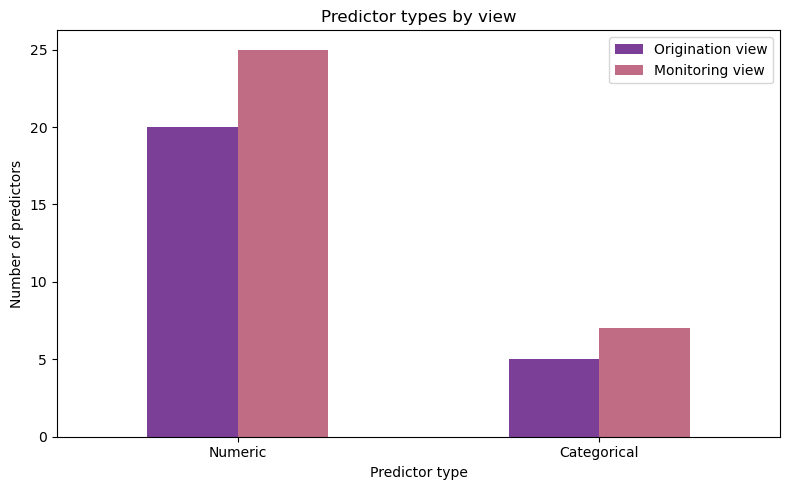

In [60]:
# ============================================================
# BLOCK 55: Review predictor types in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review numeric and categorical predictors in each modeling view
#   - Confirm which predictor groups require encoding before model training
#   - Keep the modeling view preparation organized before classification
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Categorical predictors require additional review before encoding
#   - Numeric predictors can be used directly or scaled depending on the model
# ============================================================


target_col = "operacion_viable"

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

predictor_type_rows = []

for view_name, view_df in view_dict.items():
    
    predictors = view_df.drop(columns=[target_col])
    
    numeric_predictors = predictors.select_dtypes(include=["number"]).columns.tolist()
    categorical_predictors = predictors.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    total_predictors = predictors.shape[1]
    
    predictor_type_rows.append({
        "view": view_name,
        "predictor_type": "Numeric",
        "count": len(numeric_predictors),
        "percentage": round(len(numeric_predictors) / total_predictors * 100, 2)
    })
    
    predictor_type_rows.append({
        "view": view_name,
        "predictor_type": "Categorical",
        "count": len(categorical_predictors),
        "percentage": round(len(categorical_predictors) / total_predictors * 100, 2)
    })
    
    predictor_type_rows.append({
        "view": view_name,
        "predictor_type": "Total predictors",
        "count": total_predictors,
        "percentage": 100.00
    })

predictor_type_summary = pd.DataFrame(predictor_type_rows)

origination_predictor_types = predictor_type_summary[
    predictor_type_summary["view"] == "origination_view"
].drop(columns=["view"]).reset_index(drop=True)

monitoring_predictor_types = predictor_type_summary[
    predictor_type_summary["view"] == "monitoring_view"
].drop(columns=["view"]).reset_index(drop=True)

display_side_by_side(
    origination_predictor_types,
    monitoring_predictor_types,
    "Origination view predictor types",
    "Monitoring view predictor types"
)

plot_data = predictor_type_summary[
    predictor_type_summary["predictor_type"].isin(["Numeric", "Categorical"])
].pivot(
    index="predictor_type",
    columns="view",
    values="count"
)

plot_data = plot_data.loc[["Numeric", "Categorical"]]

ax = plot_data[["origination_view", "monitoring_view"]].plot(
    kind="bar",
    figsize=(8, 5),
    color=["#7B3F98", "#C06C84"]
)

plt.title("Predictor types by view")
plt.xlabel("Predictor type")
plt.ylabel("Number of predictors")
plt.xticks(rotation=0)
ax.legend(["Origination view", "Monitoring view"])
plt.tight_layout()
plt.show()

The two modeling views are mainly numeric, which fits the Business Model because most of the underwriting and risk information is measured through amounts, ratios and percentages. The origination view contains 20 numeric and 5 categorical predictors, while the monitoring view contains 25 numeric and 7 categorical predictors. The additional monitoring variables increase both groups, but the overall structure remains similar, with roughly 80% numeric predictors in each view. This means the later modeling pipeline will need to standardize numeric variables and encode only a relatively small group of categorical variables, keeping the transformation process manageable.

categorical_variable,unique_categories
indice_coste_base_mes,51
Provincia,15
tipo_promotor,5
riesgo_legal_titulo,3
tipo_activo,3
categorical_variable,unique_categories
indice_coste_seguimiento_mes,54
indice_coste_base_mes,51
Provincia,15
tipo_promotor,5


categorical_variable,unique_categories
indice_coste_base_mes,51
Provincia,15
categorical_variable,unique_categories
indice_coste_seguimiento_mes,54
indice_coste_base_mes,51
Provincia,15


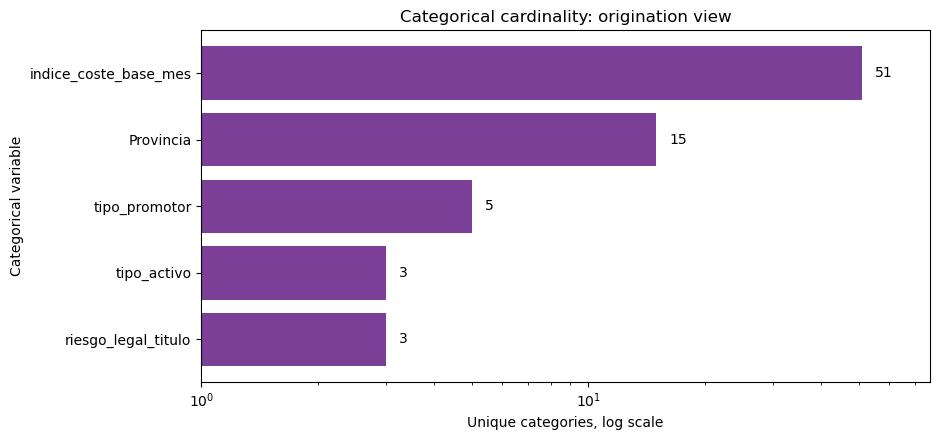

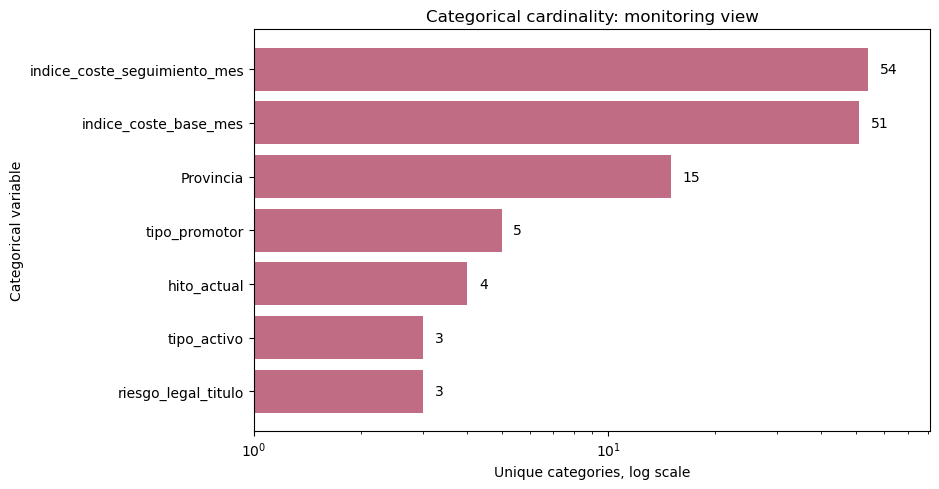

In [61]:
# ============================================================
# BLOCK 56: Review categorical cardinality in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the number of unique categories in each categorical predictor
#   - Identify categorical variables that may create too many dummy variables
#   - Support encoding decisions before preparing model ready datasets
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Low cardinality variables can usually be encoded with dummy variables
#   - High cardinality variables should be reviewed carefully to reduce model complexity
# ============================================================


target_col = "operacion_viable"

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

cardinality_rows = []

for view_name, view_df in view_dict.items():
    
    predictors = view_df.drop(columns=[target_col])
    categorical_predictors = predictors.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    for col in categorical_predictors:
        unique_count = view_df[col].nunique()
        
        cardinality_rows.append({
            "view": view_name,
            "categorical_variable": col,
            "unique_categories": unique_count
        })

categorical_cardinality = pd.DataFrame(cardinality_rows)

origination_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "origination_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

monitoring_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "monitoring_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

display_side_by_side(
    origination_cardinality,
    monitoring_cardinality,
    "Origination view categorical cardinality",
    "Monitoring view categorical cardinality"
)
high_cardinality_limit = 10

origination_high_cardinality = origination_cardinality[
    origination_cardinality["unique_categories"] > high_cardinality_limit
].reset_index(drop=True)

monitoring_high_cardinality = monitoring_cardinality[
    monitoring_cardinality["unique_categories"] > high_cardinality_limit
].reset_index(drop=True)

display_side_by_side(
    origination_high_cardinality,
    monitoring_high_cardinality,
    "Origination view high-cardinality variables",
    "Monitoring view high-cardinality variables"
)
origination_plot = origination_cardinality.sort_values(
    by="unique_categories",
    ascending=True
)

monitoring_plot = monitoring_cardinality.sort_values(
    by="unique_categories",
    ascending=True
)

plt.figure(figsize=(9.5, 4.5))
bars = plt.barh(
    origination_plot["categorical_variable"],
    origination_plot["unique_categories"],
    color="#7B3F98"
)

plt.title("Categorical cardinality: origination view")
plt.xlabel("Unique categories, log scale")
plt.ylabel("Categorical variable")
plt.xscale("log")
plt.xlim(1, origination_plot["unique_categories"].max() * 1.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.08,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va="center"
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(9.5, 5))
bars = plt.barh(
    monitoring_plot["categorical_variable"],
    monitoring_plot["unique_categories"],
    color="#C06C84"
)

plt.title("Categorical cardinality: monitoring view")
plt.xlabel("Unique categories, log scale")
plt.ylabel("Categorical variable")
plt.xscale("log")
plt.xlim(1, monitoring_plot["unique_categories"].max() * 1.5)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.08,
        bar.get_y() + bar.get_height() / 2,
        int(width),
        va="center"
    )

plt.tight_layout()
plt.show()

The categorical review shows that most business variables remain manageable for modeling. tipo_promotor has 5 categories, hito_actual has 4, and both riesgo_legal_titulo and tipo_activo have 3, so these variables can be encoded without creating excessive complexity.

Provincia contains 15 categories, which is higher than the other business variables and is therefore flagged by the diagnostic threshold. However, 15 provinces remain manageable for a portfolio of 465 operations, and the variable provides a relevant market-control dimension rather than a direct measure of territorial risk. It should therefore remain under review rather than being removed automatically.

The main concern is the two month-label variables. indice_coste_base_mes contains 51 categories and indice_coste_seguimiento_mes contains 54, so one-hot encoding them would create many additional columns with limited incremental value. Since the corresponding numeric cost indices are already available, the results support removing the month labels before modeling while retaining the underlying cost information

categorical_variable,top_category,top_category_count,top_category_percentage,rare_categories_count
riesgo_legal_titulo,bajo,311,66.88,0
tipo_activo,obra_nueva,242,52.04,0
tipo_promotor,sociedad_vehiculo_proyecto,105,22.58,0
Provincia,Alicante,31,6.67,0
indice_coste_base_mes,2022M06,15,3.23,4
categorical_variable,top_category,top_category_count,top_category_percentage,rare_categories_count
riesgo_legal_titulo,bajo,311,66.88,0
tipo_activo,obra_nueva,242,52.04,0
hito_actual,avance_intermedio,134,28.82,0
tipo_promotor,sociedad_vehiculo_proyecto,105,22.58,0


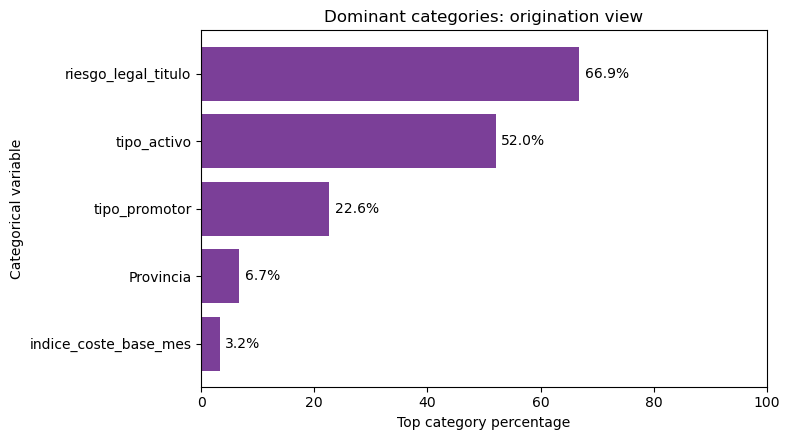

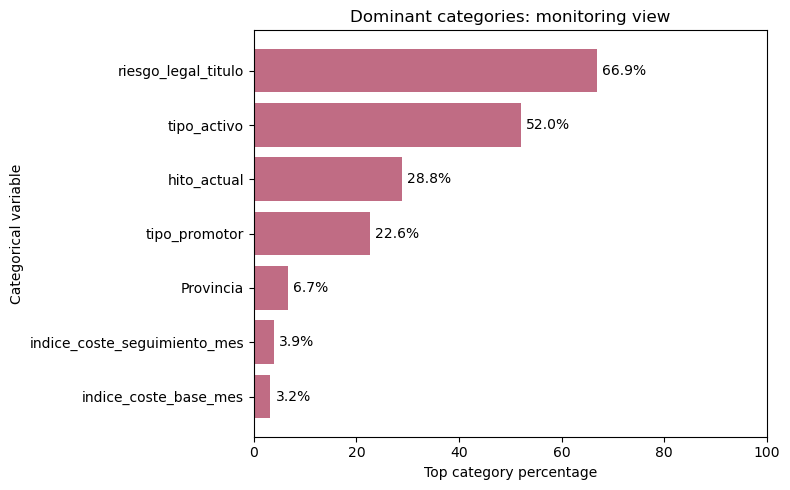

In [62]:
# ============================================================
# BLOCK 57: Review categorical distribution in modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the distribution of categories within each categorical predictor
#   - Identify dominant categories and rare categories before encoding
#   - Support encoding and grouping decisions
# DataFrame created / checked / updated:
#   - origination_view checked
#   - monitoring_view checked
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Category distribution is reviewed after cardinality
#   - Variables with dominant or rare categories should be reviewed before encoding
# ============================================================


target_col = "operacion_viable"

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

category_distribution_rows = []

for view_name, view_df in view_dict.items():
    
    predictors = view_df.drop(columns=[target_col])
    categorical_predictors = predictors.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    
    for col in categorical_predictors:
        
        counts = view_df[col].value_counts(dropna=False)
        percentages = view_df[col].value_counts(normalize=True, dropna=False) * 100
        
        top_category = counts.index[0]
        top_count = counts.iloc[0]
        top_percentage = percentages.iloc[0]
        rare_categories = (counts <= 5).sum()
        
        category_distribution_rows.append({
            "view": view_name,
            "categorical_variable": col,
            "top_category": str(top_category),
            "top_category_count": top_count,
            "top_category_percentage": round(top_percentage, 2),
            "rare_categories_count": rare_categories
        })

categorical_distribution_summary = pd.DataFrame(category_distribution_rows)

origination_categorical_distribution = categorical_distribution_summary[
    categorical_distribution_summary["view"] == "origination_view"
].drop(columns=["view"]).copy().sort_values(
    by="top_category_percentage",
    ascending=False
).reset_index(drop=True)

monitoring_categorical_distribution = categorical_distribution_summary[
    categorical_distribution_summary["view"] == "monitoring_view"
].drop(columns=["view"]).copy().sort_values(
    by="top_category_percentage",
    ascending=False
).reset_index(drop=True)

display_side_by_side(
    origination_categorical_distribution,
    monitoring_categorical_distribution,
    "Origination view categorical distribution",
    "Monitoring view categorical distribution"
)

origination_plot = origination_categorical_distribution.sort_values(
    by="top_category_percentage",
    ascending=True
)

monitoring_plot = monitoring_categorical_distribution.sort_values(
    by="top_category_percentage",
    ascending=True
)

plt.figure(figsize=(8, 4.5))
bars = plt.barh(
    origination_plot["categorical_variable"],
    origination_plot["top_category_percentage"],
    color="#7B3F98"
)

plt.title("Dominant categories: origination view")
plt.xlabel("Top category percentage")
plt.ylabel("Categorical variable")
plt.xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
bars = plt.barh(
    monitoring_plot["categorical_variable"],
    monitoring_plot["top_category_percentage"],
    color="#C06C84"
)

plt.title("Dominant categories: monitoring view")
plt.xlabel("Top category percentage")
plt.ylabel("Categorical variable")
plt.xlim(0, 100)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 1,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

The category distribution review shows that the main business variables are not affected by rare categories. riesgo_legal_titulo is concentrated in the low-risk group, which represents 66.88% of operations, while tipo_activo is led by new construction at 52.04%. tipo_promotor and hito_actual are more evenly distributed, and no rare categories are detected in the core business variables. Provincia is also well spread across the 15 territories, with Alicante as the most frequent category at only 6.67%.

The only rare-category issue appears in the month-label variables. indice_coste_base_mes has 4 rare categories and indice_coste_seguimiento_mes has 10. This reinforces the earlier decision to remove the month labels before modeling, since they add fragmentation without improving the business interpretation. The underlying numeric cost indices remain available, so no relevant cost information is lost.

In [63]:
# ============================================================
# BLOCK 58: Remove high-cardinality month-label variables before encoding
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Exclude high-cardinality month-label variables from the modeling views
#   - Update the predictor lists and modeling view documentation
#   - Confirm categorical cardinality after the exclusion
# DataFrame created / checked / updated:
#   - origination_view updated
#   - monitoring_view updated
#   - origination_view_columns updated
#   - monitoring_view_columns updated
#   - categorical_cardinality updated
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Month-label variables remain in business_model_2 for traceability
#   - Only indice_coste_base_mes and indice_coste_seguimiento_mes are excluded
#   - Numeric cost variables remain in the relevant modeling views
# ============================================================

target_col = "operacion_viable"

origination_predictor_cols = [
    col for col in origination_predictor_cols
    if col != "indice_coste_base_mes"
]

monitoring_predictor_cols = [
    col for col in monitoring_predictor_cols
    if col not in [
        "indice_coste_base_mes",
        "indice_coste_seguimiento_mes"
    ]
]

origination_view = business_model_2[
    origination_predictor_cols + [target_col]
].copy()

monitoring_view = business_model_2[
    monitoring_predictor_cols + [target_col]
].copy()

origination_view_columns = pd.DataFrame({
    "view": "origination_view",
    "variable": origination_view.columns,
    "role": [
        "target" if col == target_col else "origination_predictor"
        for col in origination_view.columns
    ]
})

monitoring_only_predictors = [
    "hito_actual",
    "retraso_obra_meses",
    "indice_coste_seguimiento",
    "desviacion_coste_pct",
    "evidencia_hito",
    "stop_desembolsos"
]

monitoring_view_columns = pd.DataFrame({
    "view": "monitoring_view",
    "variable": monitoring_view.columns,
    "role": [
        "target" if col == target_col
        else "monitoring_predictor" if col in monitoring_only_predictors
        else "origination_predictor"
        for col in monitoring_view.columns
    ]
})

view_dict = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

cardinality_rows = []

for view_name, view_df in view_dict.items():

    predictors = view_df.drop(columns=[target_col])

    categorical_predictors = predictors.select_dtypes(
        include=["object", "category", "bool"]
    ).columns.tolist()

    for col in categorical_predictors:

        unique_count = view_df[col].nunique()

        cardinality_rows.append({
            "view": view_name,
            "categorical_variable": col,
            "unique_categories": unique_count
        })

categorical_cardinality = pd.DataFrame(cardinality_rows)

origination_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "origination_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

monitoring_cardinality = categorical_cardinality[
    categorical_cardinality["view"] == "monitoring_view"
].drop(columns=["view"]).copy().sort_values(
    by="unique_categories",
    ascending=False
).reset_index(drop=True)

origination_html = origination_cardinality.to_html(index=False)
monitoring_html = monitoring_cardinality.to_html(index=False)

display_html(
    f"""
    <div style="display: flex; gap: 30px; align-items: flex-start;">
        <div>
            <h4 style="color: #7B3F98;">
                Origination view categorical cardinality
            </h4>
            {origination_html}
        </div>
        <div>
            <h4 style="color: #C06C84;">
                Monitoring view categorical cardinality
            </h4>
            {monitoring_html}
        </div>
    </div>
    """,
    raw=True
)

categorical_variable,unique_categories
Provincia,15
tipo_promotor,5
riesgo_legal_titulo,3
tipo_activo,3
categorical_variable,unique_categories
Provincia,15
tipo_promotor,5
hito_actual,4
riesgo_legal_titulo,3
tipo_activo,3


The remaining categorical predictors are all manageable for encoding. Provincia has 15 categories, tipo_promotor has 5, hito_actual has 4, and both riesgo_legal_titulo and tipo_activo have 3. This leaves the two modeling views with business-relevant categories only, while the numeric cost indices continue to carry the cost information without creating dozens of dummy variables.

,category,total_operations,non_viable_operations,non_viable_pct,categorical_variable
0,alto,46,16,34.78,riesgo_legal_titulo
1,Tarragona,31,7,22.58,Provincia
2,medio,108,24,22.22,riesgo_legal_titulo
3,Valencia,31,6,19.35,Provincia
4,Toledo,31,6,19.35,Provincia
5,promotor_local,91,17,18.68,tipo_promotor
6,Zaragoza,31,5,16.13,Provincia
7,sociedad_vehiculo_proyecto,105,16,15.24,tipo_promotor
8,Sevilla,31,4,12.90,Provincia
9,Almería,31,4,12.90,Provincia


,category,total_operations,non_viable_operations,non_viable_pct,categorical_variable
0,alto,46,16,34.78,riesgo_legal_titulo
1,Tarragona,31,7,22.58,Provincia
2,medio,108,24,22.22,riesgo_legal_titulo
3,Toledo,31,6,19.35,Provincia
4,Valencia,31,6,19.35,Provincia
5,promotor_local,91,17,18.68,tipo_promotor
6,Zaragoza,31,5,16.13,Provincia
7,sociedad_vehiculo_proyecto,105,16,15.24,tipo_promotor
8,pre_draw,116,15,12.93,hito_actual
9,Sevilla,31,4,12.90,Provincia


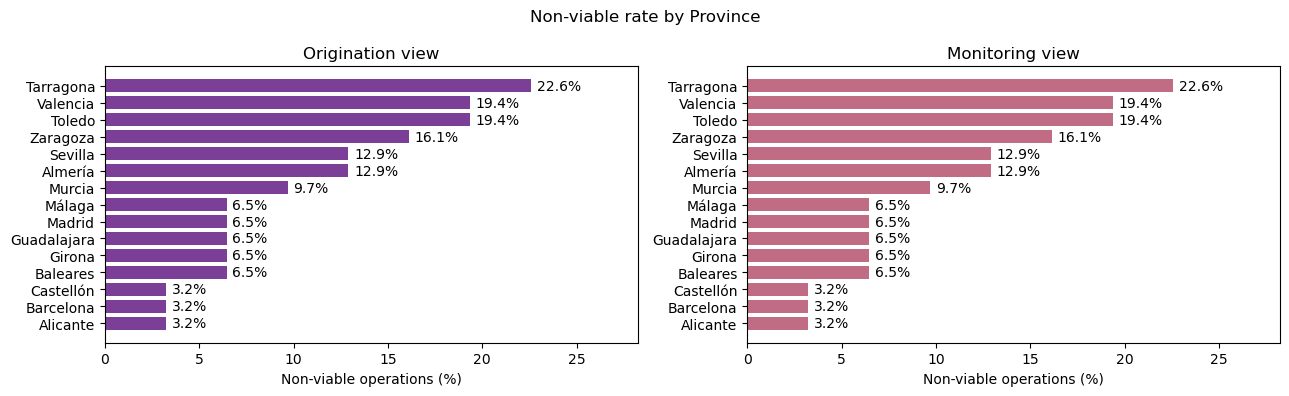

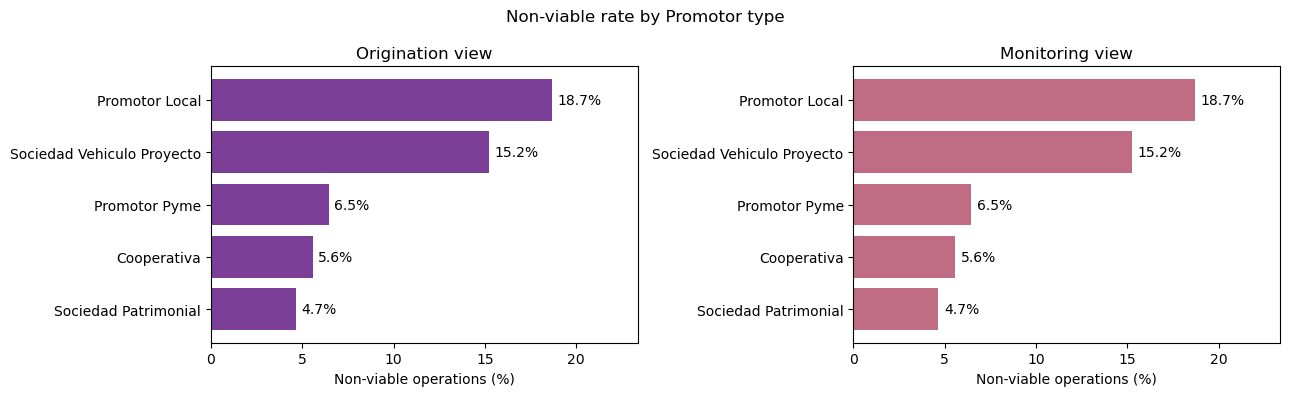

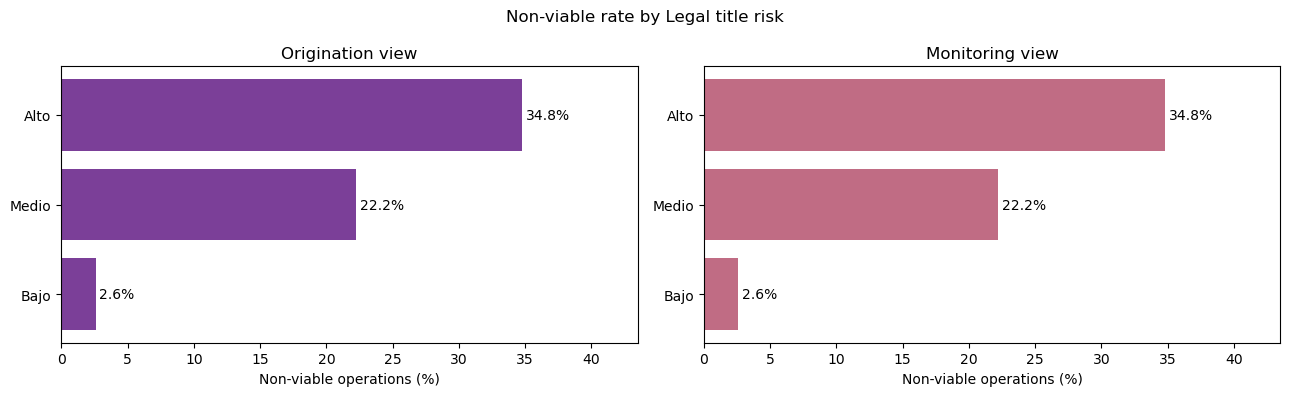

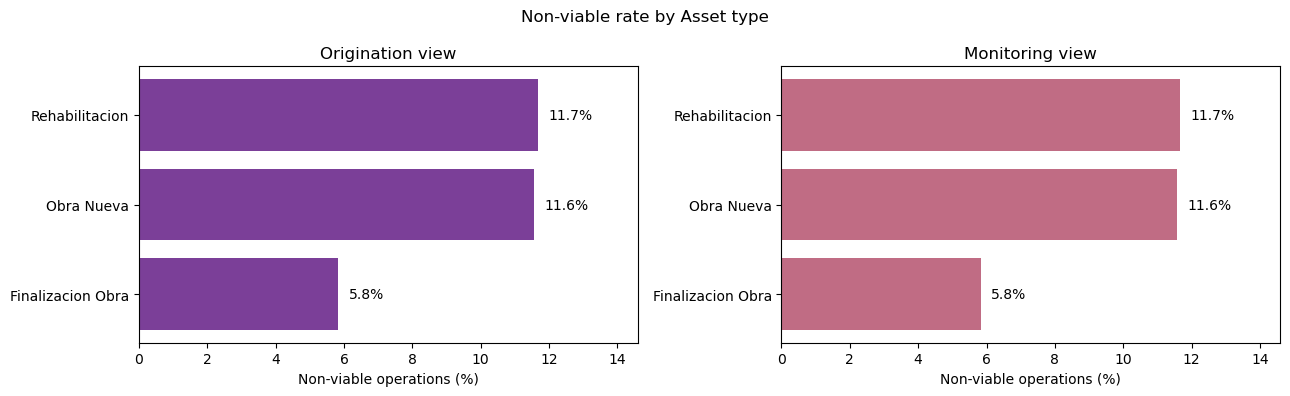

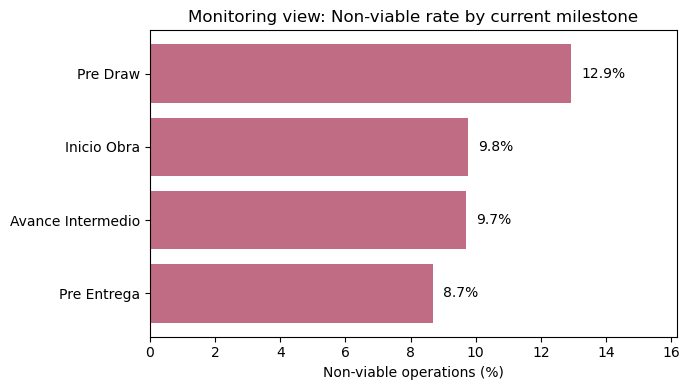

In [64]:
# ============================================================
# BLOCK 59: Analyze categorical predictors against the target
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Compare non-viable rates across categorical predictors
#   - Analyze origination_view and monitoring_view separately
#   - Display shared predictors side by side for comparison
# DataFrame created / checked / updated:
#   - origination_categorical_viability_summary
#   - monitoring_categorical_viability_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Both modeling views remain separate
#   - Shared predictors use the same category order and scale
#   - hito_actual is only analyzed in monitoring_view
#   - No predictors are removed in this block
# ============================================================

origination_categorical_predictors = [
    "Provincia",
    "tipo_promotor",
    "riesgo_legal_titulo",
    "tipo_activo"
]
monitoring_categorical_predictors = (
    origination_categorical_predictors + ["hito_actual"]
)
variable_titles = {
    "Provincia": "Province",
    "tipo_promotor": "Promotor type",
    "riesgo_legal_titulo": "Legal title risk",
    "tipo_activo": "Asset type",
    "hito_actual": "Current milestone"
}
def create_categorical_summary(dataframe, variables):
    summaries = []

    for variable in variables:
        summary = (
            dataframe.groupby(variable, observed=False)[target_col]
            .agg(
                total_operations="size",
                non_viable_operations=lambda values: (values == 0).sum()
            )
            .reset_index()
            .rename(columns={variable: "category"})
        )
        summary["non_viable_pct"] = (
            summary["non_viable_operations"]
            / summary["total_operations"] * 100
        ).round(2)

        summary["categorical_variable"] = variable
        summaries.append(summary)
    return pd.concat(summaries, ignore_index=True)
origination_categorical_viability_summary = create_categorical_summary(
    origination_view,
    origination_categorical_predictors
)
monitoring_categorical_viability_summary = create_categorical_summary(
    monitoring_view,
    monitoring_categorical_predictors
)

# Display both summaries as tables (counts + percentage), sorted to match
# the ordering the bar charts below already show, before any plotting runs
origination_categorical_viability_summary_sorted = (
    origination_categorical_viability_summary
    .sort_values("non_viable_pct", ascending=False)
    .reset_index(drop=True)
)

monitoring_categorical_viability_summary_sorted = (
    monitoring_categorical_viability_summary
    .sort_values("non_viable_pct", ascending=False)
    .reset_index(drop=True)
)

display(origination_categorical_viability_summary_sorted)
display(monitoring_categorical_viability_summary_sorted)

for variable in origination_categorical_predictors:
    origination_data = origination_categorical_viability_summary[
        origination_categorical_viability_summary["categorical_variable"] == variable
    ].copy()
    monitoring_data = monitoring_categorical_viability_summary[
        monitoring_categorical_viability_summary["categorical_variable"] == variable
    ].copy()
    category_order = (
        origination_data.sort_values("non_viable_pct")["category"].tolist() )
    origination_data = (
        origination_data.set_index("category")
        .reindex(category_order)
        .reset_index() )
    monitoring_data = (
        monitoring_data.set_index("category")
        .reindex(category_order)
        .reset_index())
    for data in [origination_data, monitoring_data]:
        data["category_display"] = (
            data["category"].astype(str)
            .str.replace("_", " ", regex=False)
            .str.title() )
    x_limit = max(
        10,
        origination_data["non_viable_pct"].max() * 1.25,
        monitoring_data["non_viable_pct"].max() * 1.25)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    for axis, data, title, color in zip(
        axes,
        [origination_data, monitoring_data],
        ["Origination view", "Monitoring view"],
        ["#7B3F98", "#C06C84"]):
        bars = axis.barh(
            data["category_display"],
            data["non_viable_pct"],
            color=color)
        axis.set_title(title)
        axis.set_xlabel("Non-viable operations (%)")
        axis.set_xlim(0, x_limit)
        for bar, percentage in zip(bars, data["non_viable_pct"]):
            axis.text(
                percentage + 0.3,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%",
                va="center")
    fig.suptitle(f"Non-viable rate by {variable_titles[variable]}")
    plt.tight_layout()
    plt.show()
monitoring_data = monitoring_categorical_viability_summary[
    monitoring_categorical_viability_summary[
        "categorical_variable"
    ] == "hito_actual"
].sort_values("non_viable_pct").copy()
monitoring_data["category_display"] = (
    monitoring_data["category"].astype(str)
    .str.replace("_", " ", regex=False)
    .str.title())
plt.figure(figsize=(7, 4))
bars = plt.barh(
    monitoring_data["category_display"],
    monitoring_data["non_viable_pct"],
    color="#C06C84")
plt.title("Monitoring view: Non-viable rate by current milestone")
plt.xlabel("Non-viable operations (%)")
plt.xlim(0, max(10, monitoring_data["non_viable_pct"].max() * 1.25))
for bar, percentage in zip(bars, monitoring_data["non_viable_pct"]):
    plt.text(
        percentage + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}%",
        va="center"
    )
plt.tight_layout()
plt.show()

The categorical analysis shows that riesgo_legal_titulo provides the clearest separation in both views. Operations classified as high legal risk reach a Non-viable rate of 34.8%, compared with 22.2% for medium risk and only 2.6% for low risk. Within the synthetic Business Model, this supports treating legal-title risk as an important screening and escalation factor, although these percentages represent simulated relationships rather than observed Spanish default or viability rates. Promoter type also provides segmentation: local promoters show the highest Non-viable rate at 18.7%, followed by project SPVs at 15.2%, while patrimonial companies record the lowest rate at 4.7%. These differences may inform model interpretation but should not be converted directly into underwriting rules because the target is synthetic.

Asset-type differences are limited, with Non-viable rates of 11.7% for rehabilitation, 11.6% for new construction and 5.8% for project completion. In the monitoring view, Pre Draw has the highest rate at 12.9%, followed by Inicio Obra at 9.8%, Avance Intermedio at 9.7% and Pre Entrega at 8.7%. These differences between milestones are moderate and should remain descriptive. Since hito_actual is assigned independently and does not enter the economic rule that constructs operacion_viable, the comparison does not demonstrate that one project stage is inherently riskier or that its controls are more effective. Provincial rates range from 3.2% in Castellón, Barcelona and Alicante to 22.6% in Tarragona; however, Provincia provides territorial context and must not be interpreted as an independent indicator of credit risk or as a rule for approval, rejection or pricing.

,analytical_view,variable,viability_outcome,count,mean,median
0,Monitoring view,LTC,Non-viable,48,48.69,49.08
1,Monitoring view,LTC,Viable,417,40.82,40.90
2,Origination view,LTC,Non-viable,48,48.69,49.08
3,Origination view,LTC,Viable,417,40.82,40.90
4,Monitoring view,LTV,Non-viable,48,52.44,52.47
5,Monitoring view,LTV,Viable,417,46.81,46.51
6,Origination view,LTV,Non-viable,48,52.44,52.47
7,Origination view,LTV,Viable,417,46.81,46.51
8,Monitoring view,desviacion_coste_pct,Non-viable,48,1.93,0.21
9,Monitoring view,desviacion_coste_pct,Viable,417,2.07,0.29


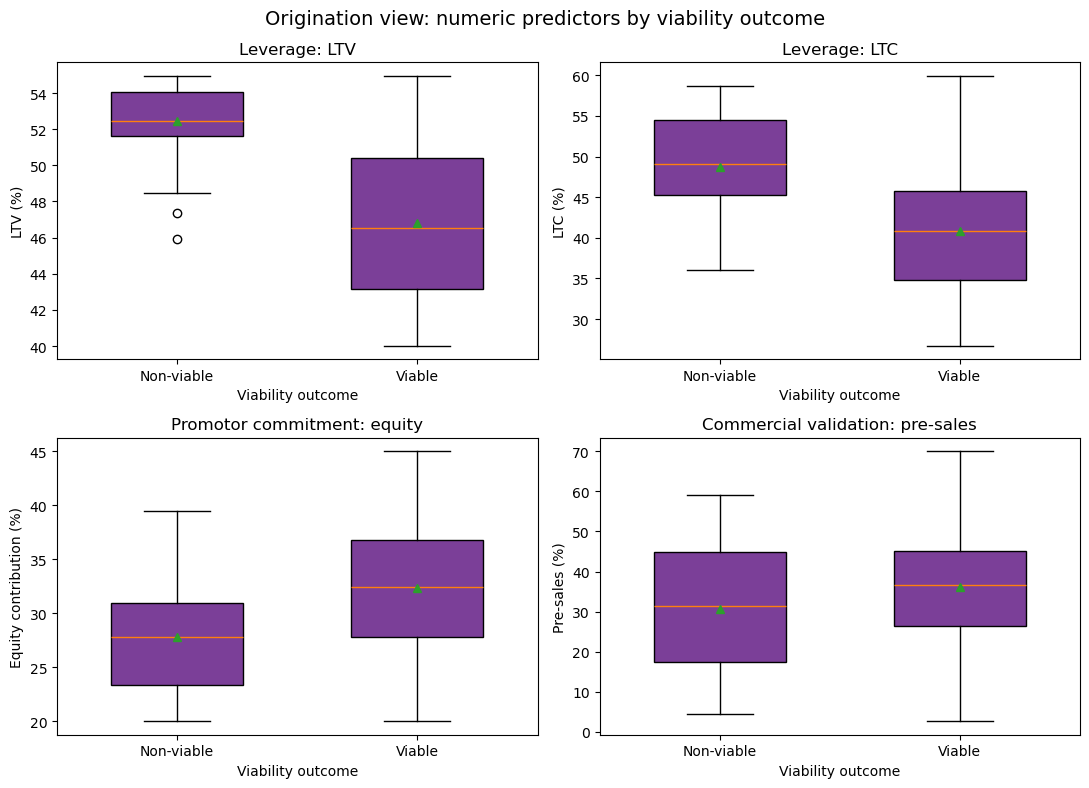

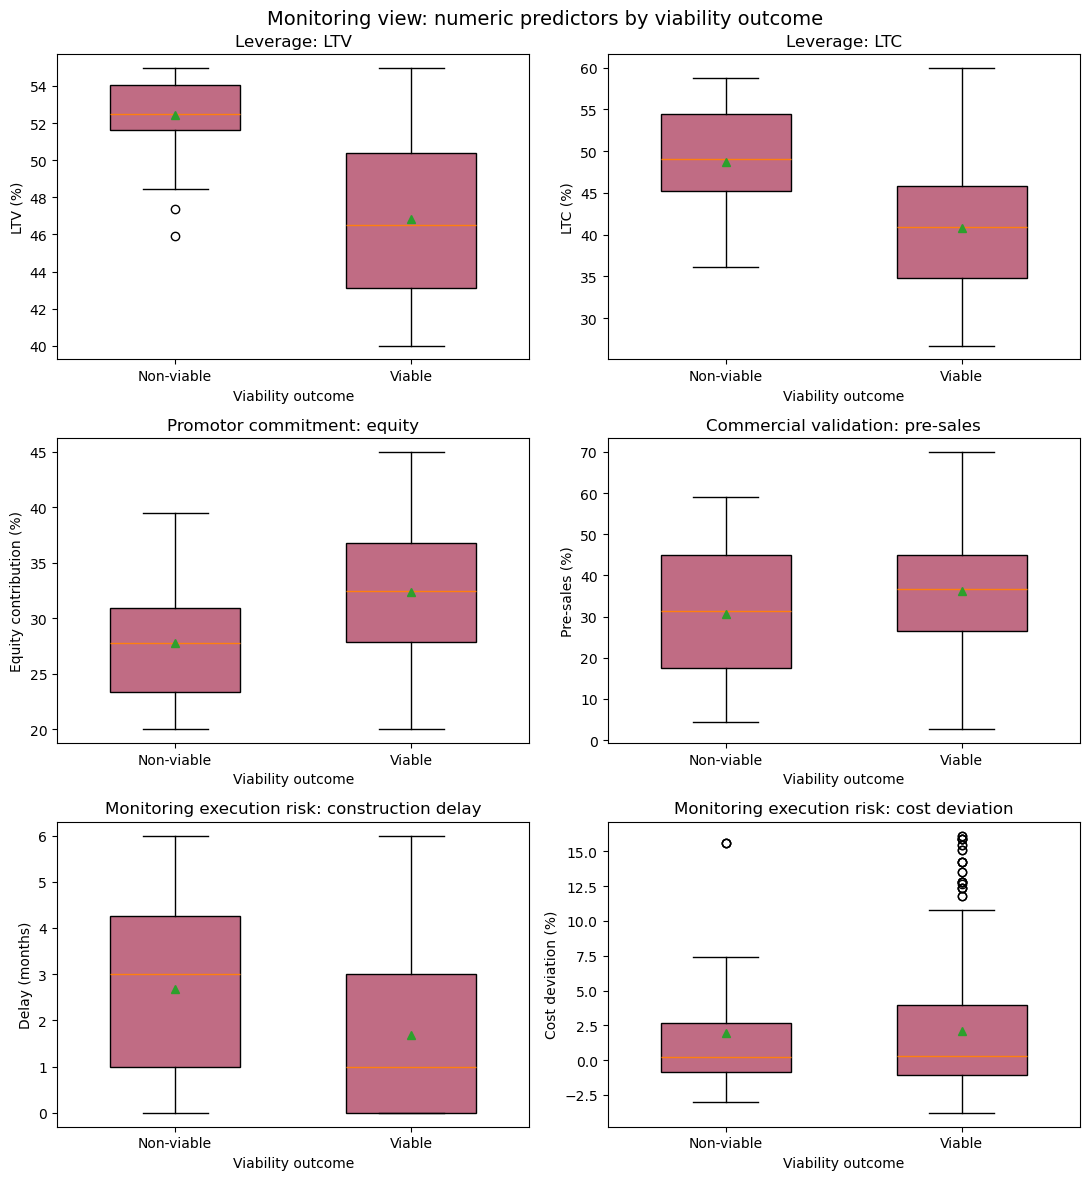

In [65]:
# ============================================================
# BLOCK 60: Review key numeric predictors by viability outcome
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review selected numeric predictors by viability outcome
#   - Separate origination and monitoring views
#   - Present each variable in business-readable units
# DataFrames checked:
#   - origination_view
#   - monitoring_view
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

target_col = "operacion_viable"

target_order = [0, 1]
target_labels = ["Non-viable", "Viable"]

origination_numeric_predictors = [
    "LTV",
    "LTC",
    "equity_promotor_pct",
    "porcentaje_preventas"
]

monitoring_numeric_predictors = [
    "LTV",
    "LTC",
    "equity_promotor_pct",
    "porcentaje_preventas",
    "retraso_obra_meses",
    "desviacion_coste_pct"
]

variable_settings = {
    "LTV": ("Leverage: LTV", "LTV (%)", 100),
    "LTC": ("Leverage: LTC", "LTC (%)", 100),
    "equity_promotor_pct": (
        "Promotor commitment: equity",
        "Equity contribution (%)",
        100
    ),
    "porcentaje_preventas": (
        "Commercial validation: pre-sales",
        "Pre-sales (%)",
        100
    ),
    "retraso_obra_meses": (
        "Monitoring execution risk: construction delay",
        "Delay (months)",
        1
    ),
    "desviacion_coste_pct": (
        "Monitoring execution risk: cost deviation",
        "Cost deviation (%)",
        100
    )
}

def plot_numeric_predictors_by_target(
    dataframe,
    variables,
    view_title,
    color
):
    n_cols = 2
    n_rows = (len(variables) + 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(11, 4 * n_rows)
    )

    axes = np.atleast_1d(axes).flatten()

    for i, variable in enumerate(variables):
        title, y_label, multiplier = variable_settings[variable]

        plot_values = [
            dataframe.loc[
                dataframe[target_col] == target,
                variable
            ].dropna() * multiplier
            for target in target_order
        ]

        boxplot = axes[i].boxplot(
            plot_values,
            tick_labels=target_labels,
            patch_artist=True,
            widths=0.55,
            showmeans=True
        )

        for box in boxplot["boxes"]:
            box.set_facecolor(color)

        axes[i].set_title(title)
        axes[i].set_xlabel("Viability outcome")
        axes[i].set_ylabel(y_label)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(view_title, fontsize=14)
    plt.tight_layout()
    plt.show()


# Block 60 never persists a summary table of its own; each boxplot's
# values are computed inline inside plot_numeric_predictors_by_target()
# and discarded right after plotting. This builds an equivalent
# descriptive-stats table (same units as the boxplots) so the Viable vs
# Non-viable comparison is readable directly from a table too.
def summarize_numeric_predictors_by_target(
    dataframe,
    variables,
    view_title
):
    rows = []

    for variable in variables:
        _, _, multiplier = variable_settings[variable]

        for target, target_label in zip(target_order, target_labels):
            values = (
                dataframe.loc[
                    dataframe[target_col] == target,
                    variable
                ].dropna() * multiplier
            )

            rows.append({
                "analytical_view": view_title,
                "variable": variable,
                "viability_outcome": target_label,
                "count": int(values.count()),
                "mean": round(values.mean(), 2),
                "median": round(values.median(), 2)
            })

    return pd.DataFrame(rows)


numeric_predictors_by_target_summary = pd.concat(
    [
        summarize_numeric_predictors_by_target(
            origination_view,
            origination_numeric_predictors,
            "Origination view"
        ),
        summarize_numeric_predictors_by_target(
            monitoring_view,
            monitoring_numeric_predictors,
            "Monitoring view"
        )
    ],
    ignore_index=True
).sort_values(
    ["variable", "analytical_view", "viability_outcome"]
).reset_index(drop=True)

display(numeric_predictors_by_target_summary)


plot_numeric_predictors_by_target(
    origination_view,
    origination_numeric_predictors,
    "Origination view: numeric predictors by viability outcome",
    "#7B3F98"
)

plot_numeric_predictors_by_target(
    monitoring_view,
    monitoring_numeric_predictors,
    "Monitoring view: numeric predictors by viability outcome",
    "#C06C84"
)

The numeric comparison shows that Non-viable operations have a median LTV of approximately 52%, compared with about 47% for Viable operations. Median LTC is also higher among Non-viable operations, at roughly 47% versus 41%. Promoter equity moves in the opposite direction, with median contributions of approximately 28% among Non-viable operations and 33% among Viable operations. Pre-sales have medians of approximately 32% and 37%, respectively, although their distributions overlap substantially.

In the monitoring view, Non-viable operations have a median construction delay of approximately three months, compared with one month among Viable operations. Cost-deviation distributions overlap considerably, with high positive deviations appearing in both groups. Overall, the observed directions are consistent with the construction of the Business Model: Non-viable operations tend to combine higher leverage, lower promoter equity and longer delays. However, this block does not establish which variable is the strongest signal because the variables are measured in different units and no standardized effect-size comparison is performed. The results should therefore remain descriptive and should not be interpreted as empirically validated lending thresholds.

,variable,viability_outcome,count,mean,median
0,Score Zona (nivel+tendencia-volatilidad),Non-viable,48,-0.39,-0.24
1,Score Zona (nivel+tendencia-volatilidad),Viable,417,0.05,-0.06
2,promotor_proyectos_previos,Non-viable,48,3.23,3.00
3,promotor_proyectos_previos,Viable,417,4.71,4.00
4,promotor_experiencia_anios,Non-viable,48,10.73,11.50
5,promotor_experiencia_anios,Viable,417,14.99,15.00
6,deuda_existente_promotor_pct,Non-viable,48,29.33,28.77
7,deuda_existente_promotor_pct,Viable,417,24.96,25.14


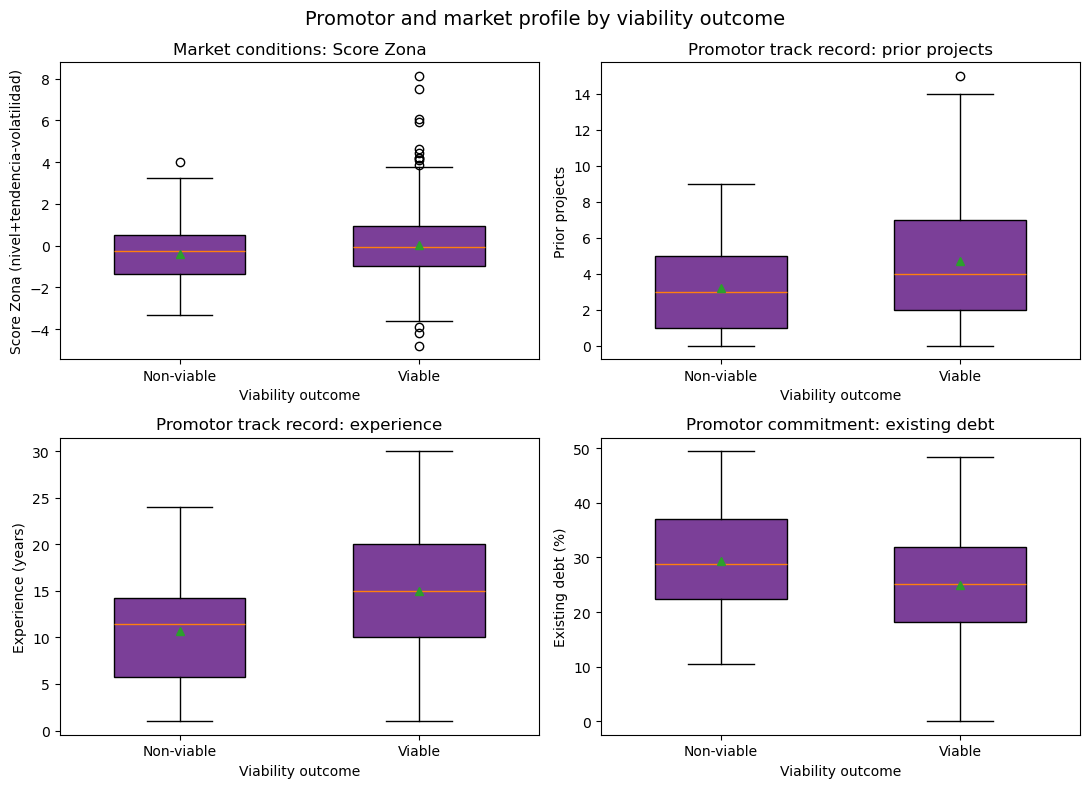

In [66]:
# ============================================================
# BLOCK 60A: Promotor and market profile by viability outcome
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Compare promotor track record and market-timing variables between
#     Viable and Non-viable operations, complementing Block 60
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - promotor_market_profile_by_target_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - porcentaje_preventas is excluded here because Block 60 already covers it
#   - deuda_existente_promotor_pct is expressed as a percentage (x100) for
#     readability, consistent with the other percentage variables already
#     shown in Block 60
# ============================================================

target_col = "operacion_viable"
target_order = [0, 1]
target_labels = ["Non-viable", "Viable"]

score_zona_col = "Score Zona (nivel+tendencia-volatilidad)"

promotor_market_variables = [
    score_zona_col,
    "promotor_proyectos_previos",
    "promotor_experiencia_anios",
    "deuda_existente_promotor_pct"
]

promotor_market_settings = {
    score_zona_col: (
        "Market conditions: Score Zona",
        "Score Zona (nivel+tendencia-volatilidad)",
        1
    ),
    "promotor_proyectos_previos": (
        "Promotor track record: prior projects",
        "Prior projects",
        1
    ),
    "promotor_experiencia_anios": (
        "Promotor track record: experience",
        "Experience (years)",
        1
    ),
    "deuda_existente_promotor_pct": (
        "Promotor commitment: existing debt",
        "Existing debt (%)",
        100
    )
}


def summarize_business_model_2_by_target(dataframe, variables, settings):
    rows = []

    for variable in variables:
        _, _, multiplier = settings[variable]

        for target, target_label in zip(target_order, target_labels):
            values = (
                dataframe.loc[
                    dataframe[target_col] == target,
                    variable
                ].dropna() * multiplier
            )

            rows.append({
                "variable": variable,
                "viability_outcome": target_label,
                "count": int(values.count()),
                "mean": round(values.mean(), 2),
                "median": round(values.median(), 2)
            })

    return pd.DataFrame(rows)


promotor_market_profile_by_target_summary = (
    summarize_business_model_2_by_target(
        business_model_2,
        promotor_market_variables,
        promotor_market_settings
    )
)

display(promotor_market_profile_by_target_summary)


def plot_business_model_2_predictors_by_target(
    dataframe,
    variables,
    settings,
    view_title,
    color
):
    n_cols = 2
    n_rows = (len(variables) + 1) // n_cols

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(11, 4 * n_rows)
    )

    axes = np.atleast_1d(axes).flatten()

    for i, variable in enumerate(variables):
        title, y_label, multiplier = settings[variable]

        plot_values = [
            dataframe.loc[
                dataframe[target_col] == target,
                variable
            ].dropna() * multiplier
            for target in target_order
        ]

        boxplot = axes[i].boxplot(
            plot_values,
            tick_labels=target_labels,
            patch_artist=True,
            widths=0.55,
            showmeans=True
        )

        for box in boxplot["boxes"]:
            box.set_facecolor(color)

        axes[i].set_title(title)
        axes[i].set_xlabel("Viability outcome")
        axes[i].set_ylabel(y_label)

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(view_title, fontsize=14)
    plt.tight_layout()
    plt.show()


plot_business_model_2_predictors_by_target(
    business_model_2,
    promotor_market_variables,
    promotor_market_settings,
    "Promotor and market profile by viability outcome",
    "#7B3F98"
)

The comparison shows a consistent descriptive pattern across the four variables. Non-viable operations have lower Score Zona values, with a mean of -0.39 and a median of -0.24, compared with 0.05 and -0.06 for Viable operations. They also have fewer prior projects and less experience: the respective medians are 3 versus 4 previous projects and 11.5 versus 15 years of experience. Existing promoter debt is higher among Non-viable operations, averaging 29.33% compared with 24.96% among Viable operations.

These differences should not be interpreted as independent or causal effects. Previous projects and years of experience enter both pricing_score and PD directly. Score Zona has an explicit indirect pathway through porcentaje_preventas, which enters pricing_score and produces a PD adjustment when pre-sales fall below 20%. By contrast, deuda_existente_promotor_pct has no formula path to the target; its observed association may arise because it was generated from the same underlying promoter-quality structure as other promoter characteristics. The results therefore reflect descriptive patterns and internal coherence within the Business Model, not independent evidence of real territorial or promoter risk.

,category,total_operations,non_viable_operations,non_viable_pct,categorical_variable
0,0,204,1,0.49,stop_desembolsos
1,1,261,47,18.01,stop_desembolsos


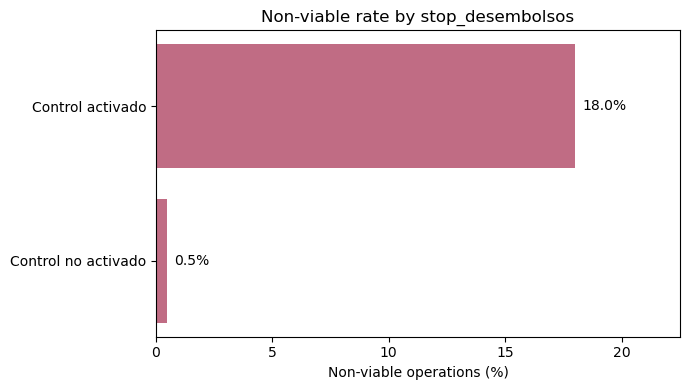

In [67]:
# ============================================================
# BLOCK 60B: stop_desembolsos control vs. viability outcome
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Compare the Non-viable rate between operations where the
#     stop_desembolsos monitoring control is activated and where it is not
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - stop_desembolsos_viability_summary
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - Reuses create_categorical_summary from Block 59 so the table
#     structure matches it exactly
#   - stop_desembolsos is a monitoring-stage signal, not an underwriting
#     rejection rule; it flags operations for closer review rather than
#     automatically rejecting them
# ============================================================

target_col = "operacion_viable"

stop_desembolsos_viability_summary = create_categorical_summary(
    business_model_2,
    ["stop_desembolsos"]
)

display(stop_desembolsos_viability_summary)

stop_desembolsos_labels = {
    0: "Control no activado",
    1: "Control activado"
}

stop_desembolsos_plot_data = stop_desembolsos_viability_summary.copy()
stop_desembolsos_plot_data["category_display"] = (
    stop_desembolsos_plot_data["category"].map(stop_desembolsos_labels)
)

fig, ax = plt.subplots(figsize=(7, 4))

bars = ax.barh(
    stop_desembolsos_plot_data["category_display"],
    stop_desembolsos_plot_data["non_viable_pct"],
    color="#C06C84"
)

ax.set_title("Non-viable rate by stop_desembolsos")
ax.set_xlabel("Non-viable operations (%)")
ax.set_xlim(
    0,
    max(10, stop_desembolsos_plot_data["non_viable_pct"].max() * 1.25)
)

for bar, percentage in zip(
    bars,
    stop_desembolsos_plot_data["non_viable_pct"]
):
    ax.text(
        percentage + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{percentage:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

Among the 204 operations where stop_desembolsos is not activated, only 1 operation, or 0.49%, is Non-viable. Among the 261 operations where the control is activated, 47 operations, or 18.01%, are Non-viable. This difference is consistent with the internal construction of the Business Model because stop_desembolsos and operacion_viable share several underlying drivers, including LTV, LTC, construction delay, legal risk, cost deviation and milestone evidence. Although stop_desembolsos does not enter the margin-based decision rule directly, these shared drivers affect the economic and risk components used to construct the target. The comparison therefore does not independently validate the control or prove that it identifies real economic weakness. Operationally, stop_desembolsos remains a preventive monitoring control that pauses additional drawdowns pending review, not an automatic rejection or termination rule. Since 214 of the 261 operations where it is activated, approximately 82%, remain Viable, activation alone is insufficient to classify an operation as economically unviable

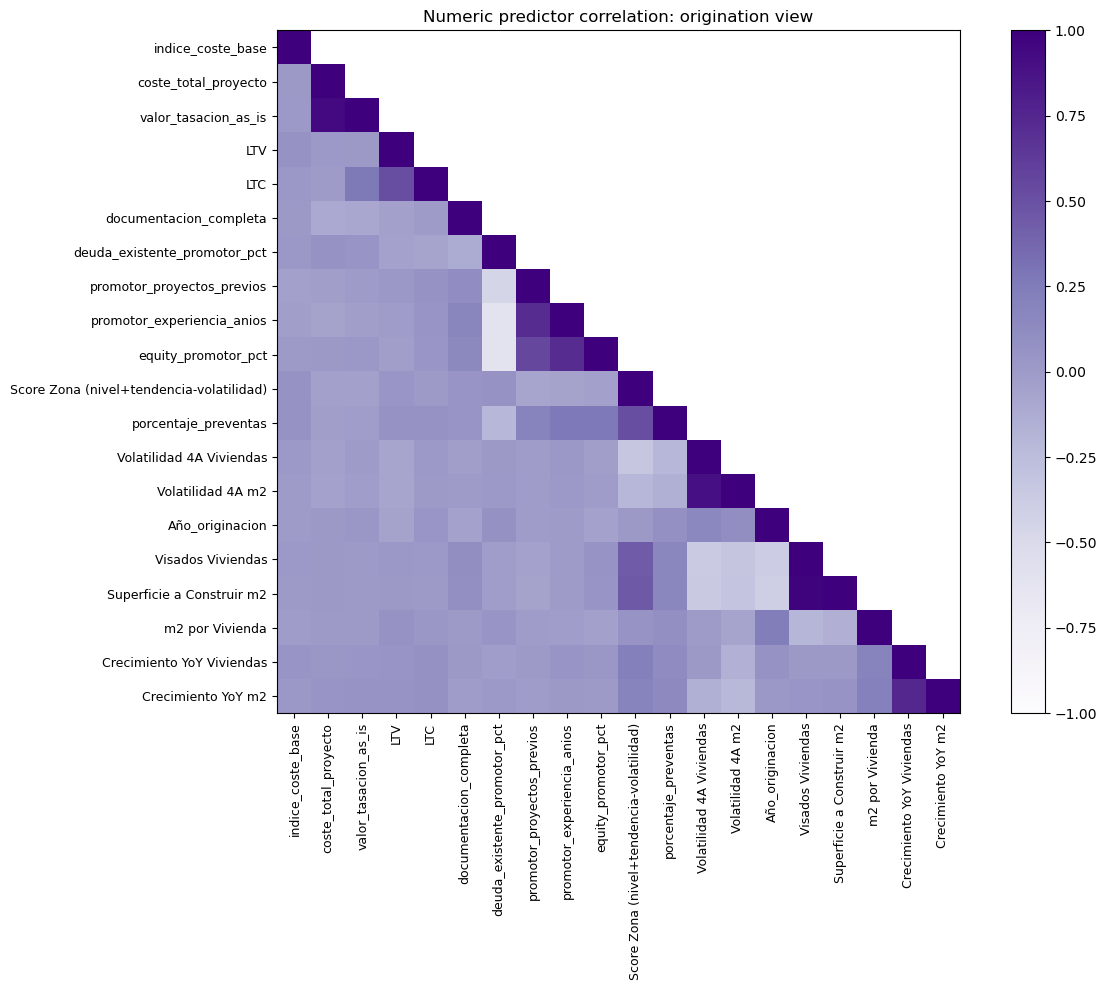

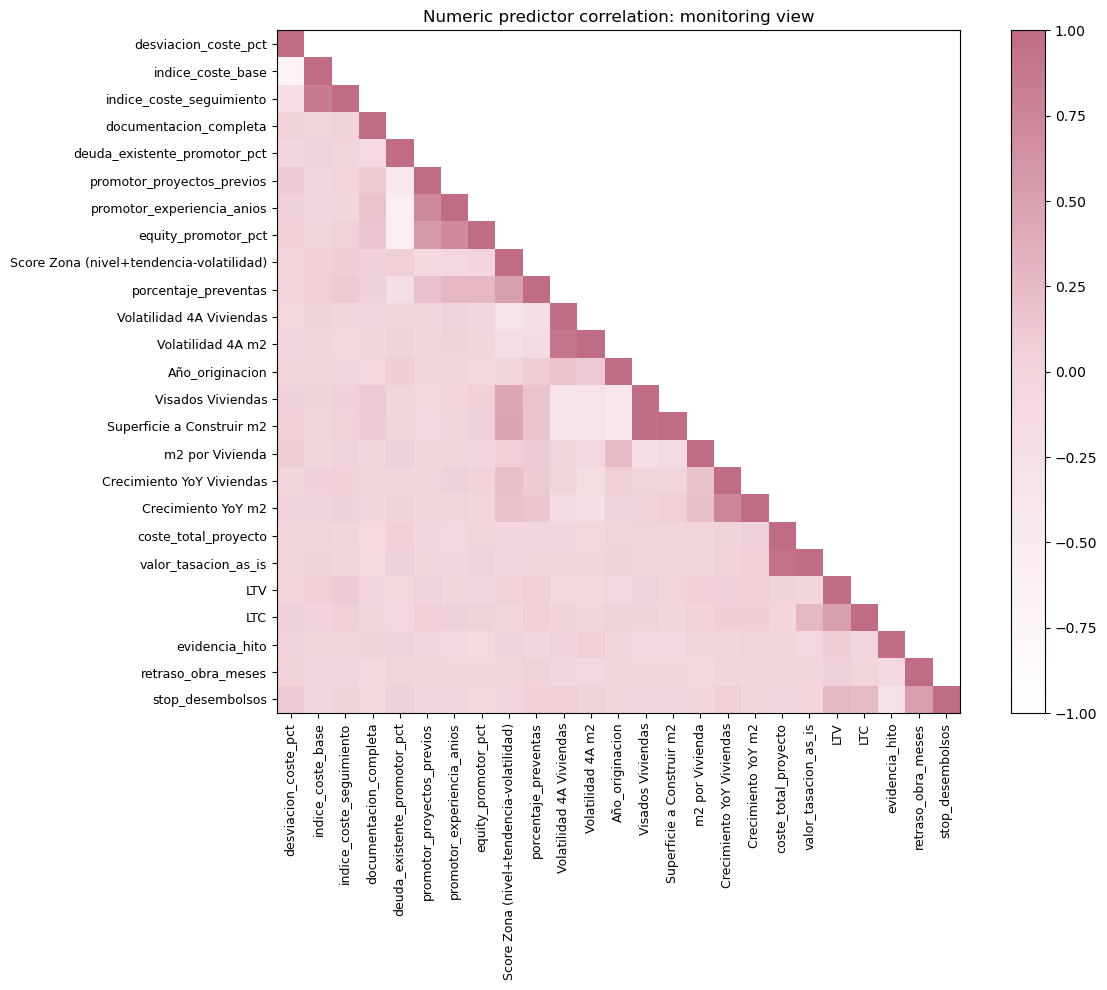

predictor_1,predictor_2,correlation,absolute_correlation
Visados Viviendas,Superficie a Construir m2,0.974468,0.974468
coste_total_proyecto,valor_tasacion_as_is,0.935946,0.935946
Volatilidad 4A Viviendas,Volatilidad 4A m2,0.892891,0.892891
Crecimiento YoY Viviendas,Crecimiento YoY m2,0.743860,0.743860
promotor_experiencia_anios,equity_promotor_pct,0.711717,0.711717
promotor_experiencia_anios,promotor_proyectos_previos,0.711175,0.711175
promotor_experiencia_anios,deuda_existente_promotor_pct,-0.615127,0.615127
equity_promotor_pct,deuda_existente_promotor_pct,-0.607210,0.607210
promotor_proyectos_previos,equity_promotor_pct,0.549903,0.549903
Score Zona (nivel+tendencia-volatilidad),porcentaje_preventas,0.509303,0.509303


In [68]:
# ============================================================
# BLOCK 61: Review numeric redundancy before final modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review redundancy among numeric predictors before finalizing modeling views
#   - Identify strongly overlapping Business Model variables
#   - Support a defensible feature reduction decision before model preparation
# DataFrames created:
#   - redundancy_outputs
#   - origination_top_numeric_correlations
#   - monitoring_top_numeric_correlations
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - The target variable is excluded from this review
#   - This block is diagnostic and does not remove predictors
#   - The heatmap shows only the lower triangle (upper triangle masked) since the matrix is symmetric
#   - Variables are reordered using hierarchical clustering so correlated variables sit together, showing a gradient toward the diagonal
# ============================================================

import copy

from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform

target_col = "operacion_viable"

monitoring_cmap = LinearSegmentedColormap.from_list(
    "monitoring_rose",
    ["#FFFFFF", "#F3D5DC", "#C06C84"]
)

redundancy_views = {
    "Origination view": {
        "data": origination_view,
        "color_map": "Purples"
    },
    "Monitoring view": {
        "data": monitoring_view,
        "color_map": monitoring_cmap
    }
}


def get_numeric_correlation_review(dataframe):

    numeric_predictors = (
        dataframe
        .drop(columns=[target_col])
        .select_dtypes(include=["number"])
    )

    correlation_matrix = numeric_predictors.corr()

    correlation_pairs = (
        correlation_matrix
        .where(
            np.triu(
                np.ones(correlation_matrix.shape),
                k=1
            ).astype(bool)
        )
        .stack()
        .reset_index()
    )

    correlation_pairs.columns = [
        "predictor_1",
        "predictor_2",
        "correlation"
    ]

    correlation_pairs["absolute_correlation"] = (
        correlation_pairs["correlation"].abs()
    )

    top_correlations = (
        correlation_pairs
        .sort_values(
            "absolute_correlation",
            ascending=False
        )
        .head(15)
        .reset_index(drop=True)
    )

    return correlation_matrix, top_correlations


def order_by_correlation_strength(correlation_matrix):

    # Clip tiny floating-point negative distances (e.g. from correlations
    # of exactly 1.0) since linkage() rejects negative distances outright
    distance_matrix = (
        (1 - correlation_matrix.abs())
        .clip(lower=0.0)
    )
    np.fill_diagonal(distance_matrix.values, 0.0)
    condensed_distance = squareform(
        distance_matrix.values,
        checks=False
    )
    linkage_matrix = linkage(
        condensed_distance,
        method="average"
    )
    leaf_order = dendrogram(
        linkage_matrix,
        no_plot=True
    )["leaves"]

    ordered_columns = correlation_matrix.columns[leaf_order]

    return correlation_matrix.loc[ordered_columns, ordered_columns]


def plot_correlation_heatmap(matrix, title, color_map, file_name):
    ordered = order_by_correlation_strength(matrix)
    mask = np.triu(np.ones(ordered.shape, dtype=bool), k=1)
    display = ordered.mask(mask)

    cmap = copy.copy(plt.get_cmap(color_map) if isinstance(color_map, str) else color_map)
    cmap.set_bad(color="white")

    fig, ax = plt.subplots(figsize=(14, 10))
    heatmap = ax.imshow(display, cmap=cmap, vmin=-1, vmax=1)

    ax.set_title(title)
    ax.set_xticks(range(len(display.columns)))
    ax.set_yticks(range(len(display.index)))
    ax.set_xticklabels(display.columns, rotation=90, fontsize=9)
    ax.set_yticklabels(display.index, fontsize=9)
    fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04)

    fig.tight_layout()
    fig.savefig(f"{file_name}.svg", bbox_inches="tight")
    fig.savefig(f"{file_name}.png", dpi=300, bbox_inches="tight")
    plt.show()
    
redundancy_outputs = {}

for view_name, view_info in redundancy_views.items():
    correlation_matrix, top_correlations = get_numeric_correlation_review(view_info["data"])

    redundancy_outputs[view_name] = {
        "correlation_matrix": correlation_matrix,
        "top_correlations": top_correlations
    }

    file_name = f"correlation_{view_name.split()[0].lower()}"

    plot_correlation_heatmap(
        correlation_matrix,
        f"Numeric predictor correlation: {view_name.lower()}",
        view_info["color_map"],
        file_name
    )


origination_top_numeric_correlations = (
    redundancy_outputs["Origination view"]["top_correlations"]
)

monitoring_top_numeric_correlations = (
    redundancy_outputs["Monitoring view"]["top_correlations"]
)

display_side_by_side(
    origination_top_numeric_correlations,
    monitoring_top_numeric_correlations,
    "Origination view strongest numeric relationships",
    "Monitoring view strongest numeric relationships"
)

The numeric redundancy review identifies two relationships that require action before modeling. Visados Viviendas and Superficie a Construir m2 have a correlation of 0.974, so both are capturing almost the same market-volume signal. Superficie a Construir m2 is removed, while Visados Viviendas is retained because it is easier to interpret as a direct measure of housing activity. Information on average dwelling size remains available through m2 por Vivienda.

A second strong relationship appears between coste_total_proyecto and valor_tasacion_as_is, with a correlation of 0.936. This is expected because the as-is valuation was generated from project cost in the synthetic dataset. valor_tasacion_as_is is therefore removed, while coste_total_proyecto is retained to preserve the absolute scale of the development. Collateral and financing pressure remain represented through LTV and LTC. The remaining high correlations are kept because they reflect related but still distinct market or monitoring concepts.

In [69]:
# ============================================================
# BLOCK 62: Drop redundant variables and recheck correlations
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Drop redundant variables from the final modeling views
#   - Recheck the strongest numeric correlations after the reduction
# DataFrames updated:
#   - origination_view
#   - monitoring_view
# Lists updated:
#   - origination_predictor_cols
#   - monitoring_predictor_cols
# Columns dropped:
#   - valor_tasacion_as_is
#   - Superficie a Construir m2
# Files created:
#   - None
# Notes / Decision:
#   - Both variables remain available in business_model_2
#   - Visados Viviendas is retained as the market-volume measure
#   - coste_total_proyecto is retained as the project-scale measure
# ============================================================

target_col = "operacion_viable"

drop_cols = [
    "valor_tasacion_as_is",
    "Superficie a Construir m2"
]

origination_view = origination_view.drop(
    columns=drop_cols,
    errors="ignore"
)

monitoring_view = monitoring_view.drop(
    columns=drop_cols,
    errors="ignore"
)

origination_predictor_cols = [
    col for col in origination_view.columns
    if col != target_col
]

monitoring_predictor_cols = [
    col for col in monitoring_view.columns
    if col != target_col
]

def get_top_numeric_correlations(df, target_col, top_n=15):
    numeric_data = (
        df.drop(columns=[target_col])
        .select_dtypes(include="number")
    )

    corr_pairs = (
        numeric_data.corr()
        .where(
            np.triu(
                np.ones(
                    (
                        numeric_data.shape[1],
                        numeric_data.shape[1]
                    )
                ),
                k=1
            ).astype(bool)
        )
        .stack()
        .reset_index()
    )

    corr_pairs.columns = [
        "variable_1",
        "variable_2",
        "correlation"
    ]

    corr_pairs["absolute_correlation"] = (
        corr_pairs["correlation"].abs()
    )

    return (
        corr_pairs
        .sort_values(
            "absolute_correlation",
            ascending=False
        )
        .head(top_n)
        .drop(columns="absolute_correlation")
        .reset_index(drop=True)
    )

origination_top_correlations_after = get_top_numeric_correlations(
    origination_view,
    target_col
)

monitoring_top_correlations_after = get_top_numeric_correlations(
    monitoring_view,
    target_col
)

display_side_by_side(
    origination_top_correlations_after,
    monitoring_top_correlations_after,
    "Origination view: top correlations after reduction",
    "Monitoring view: top correlations after reduction"
)

print("Origination view:", origination_view.shape)
print("Monitoring view:", monitoring_view.shape)
print("Dropped variables:", drop_cols)

variable_1,variable_2,correlation
Volatilidad 4A Viviendas,Volatilidad 4A m2,0.892891
Crecimiento YoY Viviendas,Crecimiento YoY m2,0.743860
promotor_experiencia_anios,equity_promotor_pct,0.711717
promotor_experiencia_anios,promotor_proyectos_previos,0.711175
promotor_experiencia_anios,deuda_existente_promotor_pct,-0.615127
equity_promotor_pct,deuda_existente_promotor_pct,-0.607210
promotor_proyectos_previos,equity_promotor_pct,0.549903
Score Zona (nivel+tendencia-volatilidad),porcentaje_preventas,0.509303
LTV,LTC,0.508797
promotor_proyectos_previos,deuda_existente_promotor_pct,-0.460481


Origination view: (465, 23)
Monitoring view: (465, 29)
Dropped variables: ['valor_tasacion_as_is', 'Superficie a Construir m2']


In [70]:
# ============================================================
# BLOCK 63: Final variable list summary for modeling views
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Confirm the final variables included in each modeling view
#   - Document variables excluded from supervised modeling
# DataFrames created:
#   - final_variable_list_summary
#   - origination_final_variable_list
#   - monitoring_final_variable_list
#   - excluded_final_variable_list
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

target_col = "operacion_viable"

final_modeling_variables = sorted(
    set(origination_view.columns)
    .union(monitoring_view.columns)
)

excluded_from_modeling = [
    col for col in hybrid.columns
    if col not in final_modeling_variables
]

final_variable_list_summary = pd.DataFrame({
    "dataset_or_view": [
        "Full Business Model",
        "Excluded from modeling",
        "Origination view",
        "Monitoring view"
    ],
    "variables": [
        hybrid.shape[1],
        len(excluded_from_modeling),
        origination_view.shape[1],
        monitoring_view.shape[1]
    ],
    "predictors": [
        None,
        None,
        origination_view.shape[1] - 1,
        monitoring_view.shape[1] - 1
    ]
})

origination_final_variable_list = pd.DataFrame({
    "number": range(1, len(origination_view.columns) + 1),
    "variable": origination_view.columns,
    "role": [
        "Target" if col == target_col else "Predictor"
        for col in origination_view.columns
    ]
})

monitoring_final_variable_list = pd.DataFrame({
    "number": range(1, len(monitoring_view.columns) + 1),
    "variable": monitoring_view.columns,
    "role": [
        "Target" if col == target_col else "Predictor"
        for col in monitoring_view.columns
    ]
})

excluded_final_variable_list = pd.DataFrame({
    "number": range(1, len(excluded_from_modeling) + 1),
    "variable": excluded_from_modeling,
    "role": "Excluded from supervised modeling"
})

display(
    final_variable_list_summary.style
    .format({"predictors": lambda x: "" if pd.isna(x) else f"{int(x)}"})
    .set_caption("Final Modeling Structure")
    .hide(axis="index")
)

display_side_by_side(
    origination_final_variable_list,
    monitoring_final_variable_list,
    "Origination View: Final Variables",
    "Monitoring View: Final Variables"
)

display(
    excluded_final_variable_list.style
    .set_caption("Variables Retained Outside the Modeling Views")
    .hide(axis="index")
)

dataset_or_view,variables,predictors
Full Business Model,74,
Excluded from modeling,45,
Origination view,23,22
Monitoring view,29,28


number,variable,role
1,Provincia,Predictor
2,Año_originacion,Predictor
3,Visados Viviendas,Predictor
4,m2 por Vivienda,Predictor
5,Crecimiento YoY Viviendas,Predictor
6,Crecimiento YoY m2,Predictor
7,Volatilidad 4A Viviendas,Predictor
8,Volatilidad 4A m2,Predictor
9,Score Zona (nivel+tendencia-volatilidad),Predictor
10,tipo_promotor,Predictor


number,variable,role
1,operacion_id_simulada,Excluded from supervised modeling
2,proyecto_id_simulado,Excluded from supervised modeling
3,promotor_id_simulado,Excluded from supervised modeling
4,No_Prestamo_proxy_RD,Excluded from supervised modeling
5,Negocio_proxy_RD,Excluded from supervised modeling
6,Valor_RD_proxy,Excluded from supervised modeling
7,prestamos_saldados_proxy_RD,Excluded from supervised modeling
8,fecha_ultimo_pago_proxy_RD,Excluded from supervised modeling
9,total_valor_saldado_proxy_RD,Excluded from supervised modeling
10,total_ultimo_pago_proxy_RD,Excluded from supervised modeling


The final variable summary confirms a clear separation between the full Business Model and the two modeling views. The original hybrid dataset contains 74 variables, while 45 are excluded from supervised modeling because they correspond to identifiers, RD proxy fields, future validation information, leakage variables, exposure calculations, high-cardinality month labels or redundant predictors. After depuration, origination_view contains 23 variables, including 22 predictors and operacion_viable, while monitoring_view contains 29 variables, including 28 predictors and the same target. This leaves both views focused on the information available at their respective business moments, while the full dataset remains available for traceability, economic analysis and later sensitivity testing.


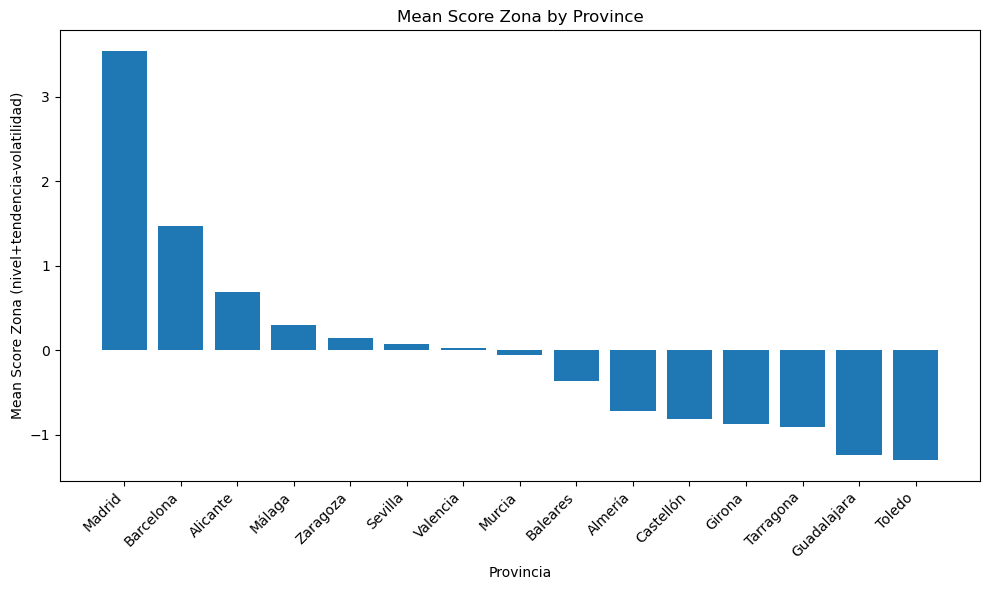

Highest ranked province: Madrid (3.545)
Lowest ranked province: Toledo (-1.298)


In [71]:
# ============================================================
# BLOCK 63A: Territorial analysis
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review average market conditions (Score Zona) by province
#   - Identify the strongest and weakest provincial markets
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - province_score_summary
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

province_score_summary = (
    business_model_2
    .groupby("Provincia")["Score Zona (nivel+tendencia-volatilidad)"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    province_score_summary.index,
    province_score_summary.values
)

ax.set_title("Mean Score Zona by Province")
ax.set_xlabel("Provincia")
ax.set_ylabel("Mean Score Zona (nivel+tendencia-volatilidad)")

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

highest_province = province_score_summary.index[0]
highest_province_score = province_score_summary.iloc[0]

lowest_province = province_score_summary.index[-1]
lowest_province_score = province_score_summary.iloc[-1]

print(
    "Highest ranked province:",
    highest_province,
    f"({highest_province_score:.3f})"
)
print(
    "Lowest ranked province:",
    lowest_province,
    f"({lowest_province_score:.3f})"
)

The territorial analysis shows that the portfolio incorporates different provincial market contexts rather than representing a single homogeneous environment. Each of the fifteen provinces contributes 31 operations, while the average Score Zona varies because the indicator summarizes relative differences in construction activity, recent evolution and stability. Madrid records the highest provincial mean at 3.545, whereas Toledo records the lowest at -1.298. The range between these values reflects variation among the provinces included, consistent with the contextual purpose of the indicator, but it does not demonstrate predictive capacity or establish a territorial ranking of credit risk. Provincia should therefore be used only to contextualize the operations and not as an independent rule for approval, rejection or pricing.

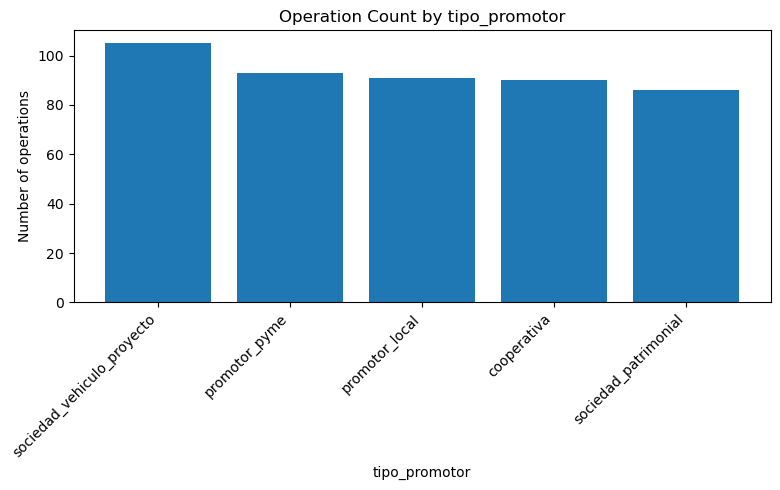

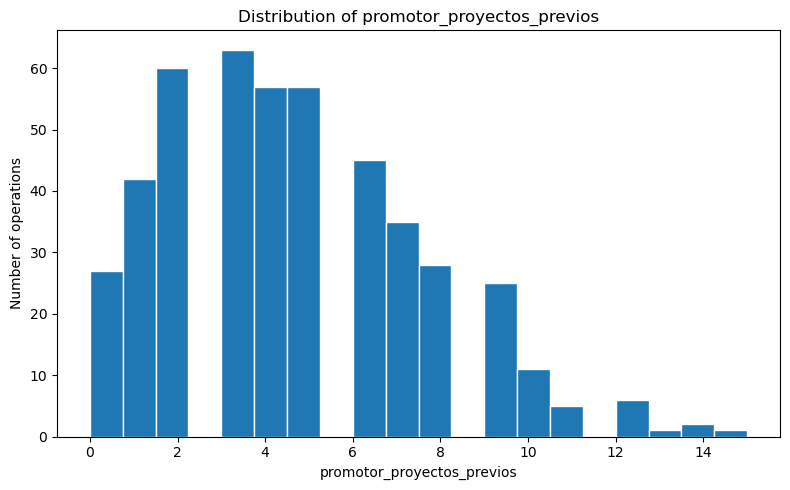

promotor_proyectos_previos skewness: 0.616
promotor_proyectos_previos mean: 4.561
promotor_proyectos_previos median: 4.0
promotor_proyectos_previos max: 15


In [72]:
# ============================================================
# BLOCK 63B: Promotor profile
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the promotor-type composition of the portfolio
#   - Review the distribution of promotor prior-project experience
# DataFrame checked:
#   - business_model_2
# DataFrame created:
#   - promotor_type_counts
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

promotor_type_counts = business_model_2["tipo_promotor"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    promotor_type_counts.index,
    promotor_type_counts.values
)

ax.set_title("Operation Count by tipo_promotor")
ax.set_xlabel("tipo_promotor")
ax.set_ylabel("Number of operations")

plt.setp(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    business_model_2["promotor_proyectos_previos"],
    bins=20,
    edgecolor="white"
)

ax.set_title("Distribution of promotor_proyectos_previos")
ax.set_xlabel("promotor_proyectos_previos")
ax.set_ylabel("Number of operations")

plt.tight_layout()
plt.show()

promotor_projects_skew = (
    business_model_2["promotor_proyectos_previos"].skew()
)
promotor_projects_mean = (
    business_model_2["promotor_proyectos_previos"].mean()
)
promotor_projects_median = (
    business_model_2["promotor_proyectos_previos"].median()
)
promotor_projects_max = (
    business_model_2["promotor_proyectos_previos"].max()
)

print(
    "promotor_proyectos_previos skewness:",
    round(promotor_projects_skew, 3)
)
print(
    "promotor_proyectos_previos mean:",
    round(promotor_projects_mean, 3)
)
print(
    "promotor_proyectos_previos median:",
    promotor_projects_median
)
print(
    "promotor_proyectos_previos max:",
    promotor_projects_max
)

The promoter-type distribution is sufficiently balanced to avoid excessive concentration in one organizational profile. The distribution of promotor_proyectos_previos shows moderate positive asymmetry, with a mean of 4.561 projects, a median of 4 and a maximum of 15. Most simulated promoters therefore have a moderate level of previous development experience, while a smaller group has completed a substantially larger number of projects. This variation is relevant for underwriting because prior execution experience may support the promoter’s ability to manage construction, commercialization and operational challenges, although it should be assessed jointly with equity, pre-sales, documentation and legal risk.

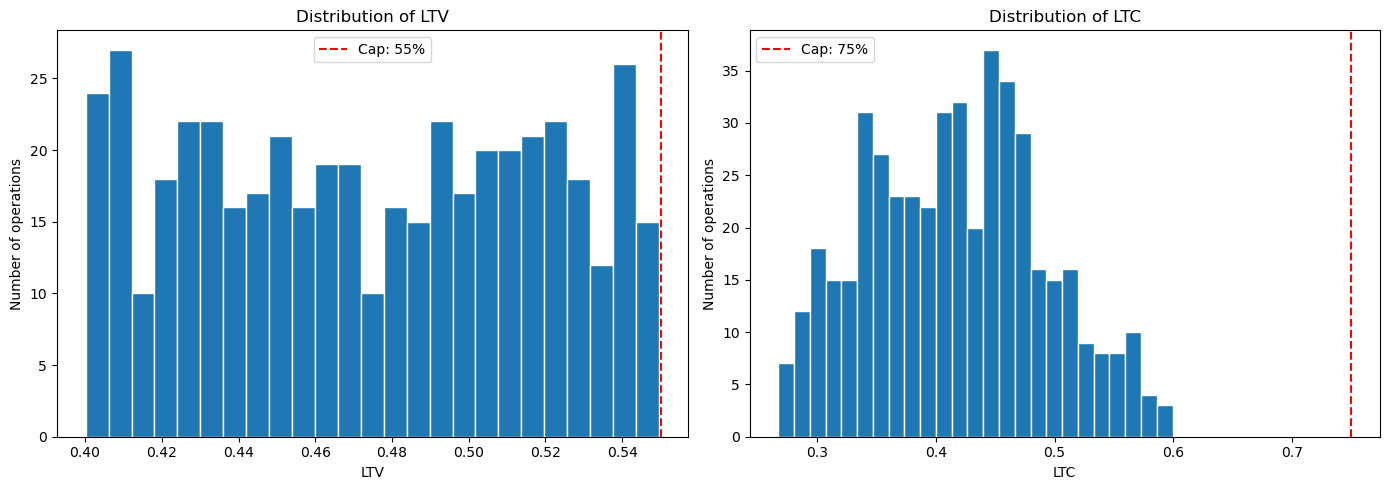

LTV skewness: -0.017
LTV max: 0.5496
LTC skewness: 0.144
LTC max: 0.5994


In [73]:
# ============================================================
# BLOCK 63C: Financial structure
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review the distribution of LTV and LTC against their policy caps
# DataFrame checked:
#   - business_model_2
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    business_model_2["LTV"],
    bins=25,
    edgecolor="white"
)
axes[0].axvline(
    0.55,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Cap: 55%"
)
axes[0].set_title("Distribution of LTV")
axes[0].set_xlabel("LTV")
axes[0].set_ylabel("Number of operations")
axes[0].legend()

axes[1].hist(
    business_model_2["LTC"],
    bins=25,
    edgecolor="white"
)
axes[1].axvline(
    0.75,
    color="red",
    linestyle="--",
    linewidth=1.5,
    label="Cap: 75%"
)
axes[1].set_title("Distribution of LTC")
axes[1].set_xlabel("LTC")
axes[1].set_ylabel("Number of operations")
axes[1].legend()

plt.tight_layout()
plt.show()

ltv_skew = business_model_2["LTV"].skew()
ltv_max = business_model_2["LTV"].max()
ltc_skew = business_model_2["LTC"].skew()
ltc_max = business_model_2["LTC"].max()

print("LTV skewness:", round(ltv_skew, 3))
print("LTV max:", round(ltv_max, 4))
print("LTC skewness:", round(ltc_skew, 3))
print("LTC max:", round(ltc_max, 4))

The distributions of LTV and LTC are approximately symmetric, with skewness values of −0.017 and 0.144 respectively. The maximum LTV reaches 54.96%, very close to the 55% policy cap, indicating that this restriction is relevant and binding for part of the simulated portfolio. In contrast, the maximum LTC is 59.94%, remaining materially below its 75% limit. The resulting financing structures therefore operate closer to the collateral-based constraint than to the project-cost constraint. From the lender’s perspective, this means that the valuation-based limit generally provides the more restrictive protection against excessive exposure.

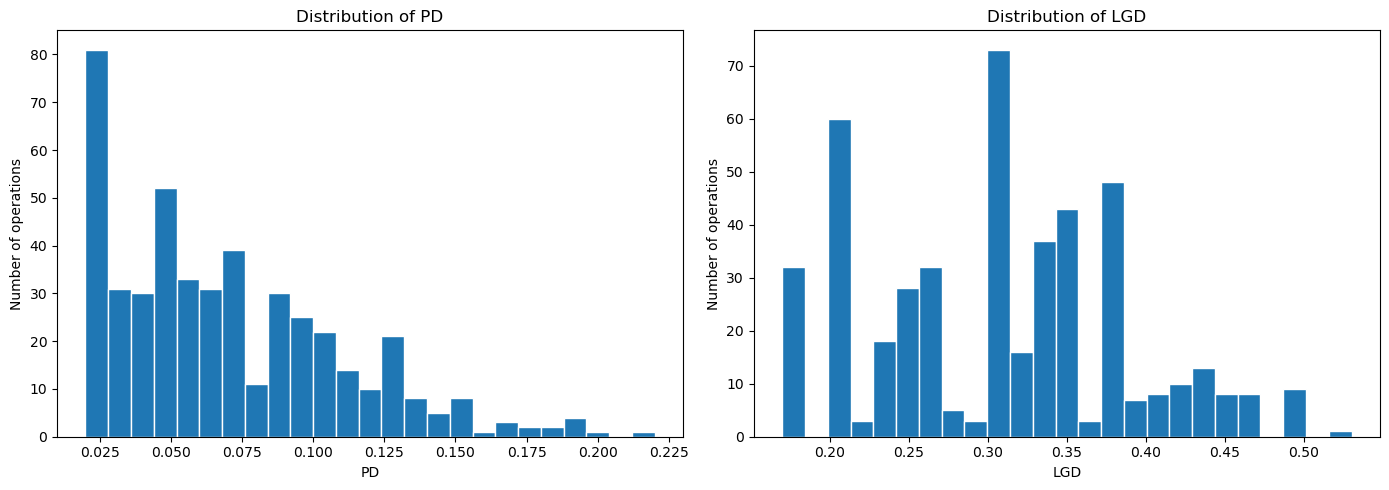

PD skewness: 0.867
LGD skewness: 0.178
perdida_esperada skewness: 2.593


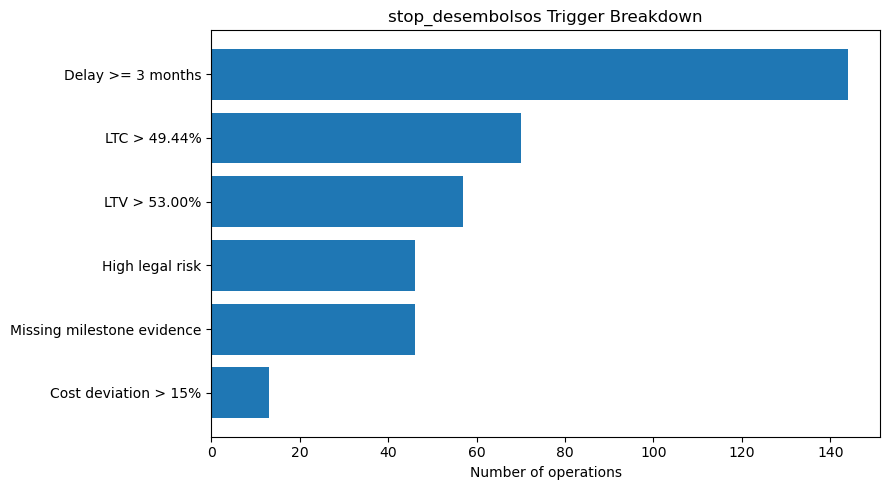

Cost deviation > 15%           13
Missing milestone evidence     46
High legal risk                46
LTV > 53.00%                   57
LTC > 49.44%                   70
Delay >= 3 months             144
dtype: int64
Total stop_desembolsos = 1: 261
Percentage stop_desembolsos = 1: 56.13%


In [74]:
# ============================================================
# BLOCK 63D: Risk and disbursement controls
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Review PD and LGD distributions
#   - Break down which monitoring conditions drive stop_desembolsos
# DataFrame checked:
#   - business_model_2
#   - hybrid
# DataFrame created:
#   - stop_desembolsos_trigger_breakdown
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - PD, LGD and perdida_esperada were excluded from business_model_2 in
#     Block 50 as leakage columns, so they are read from hybrid here, which
#     is row-aligned with business_model_2 and still carries them
#   - LTC_HIGH_THRESHOLD and LTV_STOP_THRESHOLD are the pre-existing
#     thresholds defined in Blocks 27 and 29 and are reused as-is
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    hybrid["PD"],
    bins=25,
    edgecolor="white"
)
axes[0].set_title("Distribution of PD")
axes[0].set_xlabel("PD")
axes[0].set_ylabel("Number of operations")

axes[1].hist(
    hybrid["LGD"],
    bins=25,
    edgecolor="white"
)
axes[1].set_title("Distribution of LGD")
axes[1].set_xlabel("LGD")
axes[1].set_ylabel("Number of operations")

plt.tight_layout()
plt.show()

pd_skew = hybrid["PD"].skew()
lgd_skew = hybrid["LGD"].skew()
perdida_esperada_skew = hybrid["perdida_esperada"].skew()

print("PD skewness:", round(pd_skew, 3))
print("LGD skewness:", round(lgd_skew, 3))
print("perdida_esperada skewness:", round(perdida_esperada_skew, 3))

stop_desembolsos_trigger_breakdown = pd.Series({
    "Delay >= 3 months": int(
        (business_model_2["retraso_obra_meses"] >= 3).sum()
    ),
    f"LTC > {LTC_HIGH_THRESHOLD:.2%}": int(
        (business_model_2["LTC"] > LTC_HIGH_THRESHOLD).sum()
    ),
    f"LTV > {LTV_STOP_THRESHOLD:.2%}": int(
        (business_model_2["LTV"] > LTV_STOP_THRESHOLD).sum()
    ),
    "Missing milestone evidence": int(
        (business_model_2["evidencia_hito"] == 0).sum()
    ),
    "High legal risk": int(
        (
            business_model_2["riesgo_legal_titulo"] == "alto"
        ).sum()
    ),
    "Cost deviation > 15%": int(
        (business_model_2["desviacion_coste_pct"] > 0.15).sum()
    )
}).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    stop_desembolsos_trigger_breakdown.index,
    stop_desembolsos_trigger_breakdown.values
)

ax.set_title("stop_desembolsos Trigger Breakdown")
ax.set_xlabel("Number of operations")

plt.tight_layout()
plt.show()

print(stop_desembolsos_trigger_breakdown)

stop_desembolsos_total = business_model_2["stop_desembolsos"].sum()
stop_desembolsos_pct = (
    stop_desembolsos_total / len(business_model_2) * 100
)

print(
    "Total stop_desembolsos = 1:",
    int(stop_desembolsos_total)
)
print(
    "Percentage stop_desembolsos = 1:",
    f"{stop_desembolsos_pct:.2f}%"
)

The PD distribution presents moderate positive asymmetry, with a skewness of 0.867, while the LGD distribution is more balanced, with a skewness of 0.178. Expected loss is considerably more positively skewed at 2.593 because it combines PD, LGD and EAD, causing a relatively small group of operations to concentrate a larger proportion of the estimated risk cost.

The most frequent disbursement-control trigger is a construction delay of at least three months, affecting 144 operations. This is followed by LTC above 49.44% in 70 cases and LTV above 53% in 57 cases. Missing milestone evidence and high legal risk each affect 46 operations, while cost deviation above 15% is the least frequent trigger, with 13 cases. Overall, stop_desembolsos is activated in 261 operations, equivalent to 56.13% of the portfolio. The trigger counts overlap because one operation may satisfy several conditions simultaneously. Activation represents a preventive review before releasing additional funds and does not imply a default or automatic classification as No viable

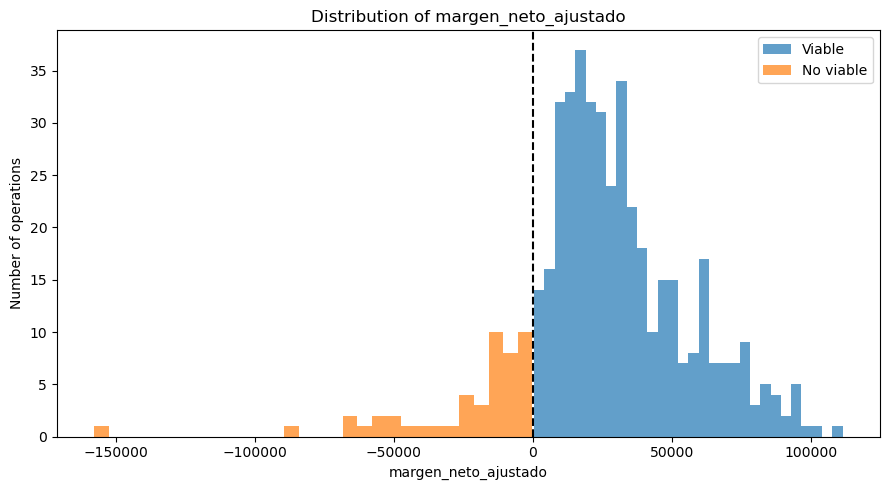

margen_neto_ajustado skewness: -0.622
margen_neto_ajustado mean: €27,764
margen_neto_ajustado median: €25,494


,variable,count,mean,median,std,min,max,skew
0,ingresos_totales,465,140345.88,131065.10,72484.78,20929.60,362670.27,0.475
1,coste_fondos,465,64353.81,59090.90,35386.36,8988.56,196138.82,0.662
2,opex,465,19591.71,18248.13,11110.91,2127.46,65251.02,0.783


In [75]:
# ============================================================
# BLOCK 63E: Income and margin
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Compare the adjusted net margin distribution between viable
#     and non-viable operations
# DataFrame checked:
#   - business_model_2
#   - hybrid
# Columns created:
#   - None
# Files created:
#   - None
# Notes / Decision:
#   - margen_neto_ajustado was excluded from business_model_2 in Block 50
#     as a leakage column, so it is read from hybrid here, which is
#     row-aligned with business_model_2 and still carries it
# ============================================================

viable_mask = business_model_2["operacion_viable"] == 1
no_viable_mask = business_model_2["operacion_viable"] == 0

margen_viable = hybrid.loc[viable_mask, "margen_neto_ajustado"]
margen_no_viable = hybrid.loc[no_viable_mask, "margen_neto_ajustado"]

fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    margen_viable,
    bins=30,
    alpha=0.7,
    label="Viable"
)
ax.hist(
    margen_no_viable,
    bins=30,
    alpha=0.7,
    label="No viable"
)

ax.axvline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5
)

ax.set_title("Distribution of margen_neto_ajustado")
ax.set_xlabel("margen_neto_ajustado")
ax.set_ylabel("Number of operations")
ax.legend()

plt.tight_layout()
plt.show()

margen_skew = hybrid["margen_neto_ajustado"].skew()
margen_mean = hybrid["margen_neto_ajustado"].mean()
margen_median = hybrid["margen_neto_ajustado"].median()

print(
    "margen_neto_ajustado skewness:",
    round(margen_skew, 3)
)
print(
    "margen_neto_ajustado mean:",
    f"€{margen_mean:,.0f}"
)
print(
    "margen_neto_ajustado median:",
    f"€{margen_median:,.0f}"
)

# ---- Income and cost components: distribution shape ----
# ingresos_totales, coste_fondos and opex are direct components of the
# margin formula itself (margen_neto_ajustado = ingresos_totales -
# coste_fondos - opex - perdida_esperada), so no target split is shown
# here: comparing them against operacion_viable would be the same
# circular check already avoided for PD, LGD and expected loss in
# Block 63D. This only describes their own distribution shape.
# They were excluded from business_model_2 in Block 50 as leakage
# columns, so they are read from hybrid here, same as margen_neto_ajustado.

income_cost_variables = [
    "ingresos_totales",
    "coste_fondos",
    "opex"
]

income_cost_rows = []

for variable in income_cost_variables:
    values = hybrid[variable].dropna()
    income_cost_rows.append({
        "variable": variable,
        "count": int(values.count()),
        "mean": round(values.mean(), 2),
        "median": round(values.median(), 2),
        "std": round(values.std(), 2),
        "min": round(values.min(), 2),
        "max": round(values.max(), 2),
        "skew": round(values.skew(), 3)
    })

income_cost_summary = pd.DataFrame(income_cost_rows)

display(income_cost_summary)

# A chart is only built for a variable if its skewness is notably high,
# using |skew| > 1 as the conventional cutoff for "highly skewed"
# (values between -0.5 and 0.5 are considered fairly symmetric, up to
# 1 moderately skewed, beyond that highly skewed). Otherwise the table
# above is sufficient on its own.
SKEW_CHART_THRESHOLD = 1.0

for _, row in income_cost_summary.iterrows():
    if abs(row["skew"]) > SKEW_CHART_THRESHOLD:
        fig, ax = plt.subplots(figsize=(8, 5))

        ax.hist(
            hybrid[row["variable"]].dropna(),
            bins=30,
            edgecolor="white"
        )

        ax.set_title(f"Distribution of {row['variable']}")
        ax.set_xlabel(row["variable"])
        ax.set_ylabel("Number of operations")

        plt.tight_layout()
        plt.show()

The adjusted net margin distribution has a mean of €27,764 and a median of €25,494, indicating that the typical simulated operation generates a positive economic result after deducting funding costs, OPEX and expected loss. Its skewness of −0.622 reflects a lower tail formed by operations with negative economic margins. The zero-margin line corresponds directly to the decision rule used to construct operacion_viable: operations above zero are classified as Viable, while those at or below zero are classified as No viable. The graph therefore illustrates the internal economic logic of the Business Model rather than providing an independent validation of that rule.

<div style="background:#1f4e79; color:white; padding:25px; border-radius:8px; font-size:42px; font-weight:bold;">
PART H: SUPERVISED CLASSIFICATION AND RECOVERY OF THE SYNTHETIC DECISION RULE
</div>

<br>

<div style="font-size:22px; color:#333;">
This section compares supervised classification models according to how well they reproduce and explain the synthetic viability rule defined by the Business Model. The target operacion_viable is derived from the adjusted net margin and does not represent observed defaults or real market viability in Spain. The models are therefore used as simulation, scoring and decision-support tools rather than as empirically validated predictors of real lending performance.
</div>

In [76]:
# ============================================================
# BLOCK 64: Prepare final classification inputs
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Prepare the final X and y objects for supervised classification
#   - Verify that the synthetic target is binary in both modeling views
#   - Identify numeric and categorical predictors for preprocessing
# DataFrame created / checked / updated:
#   - regression_input_summary
# Objects created / updated:
#   - regression_inputs
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

target_col = "operacion_viable"

regression_views = {
    "origination_view": origination_view,
    "monitoring_view": monitoring_view
}

regression_inputs = {}
regression_input_rows = []

for view_name, view_df in regression_views.items():
    X = view_df.drop(columns=[target_col]).copy()
    y = view_df[target_col].copy()

    numeric_cols = (
        X.select_dtypes(include="number")
        .columns
        .tolist()
    )

    categorical_cols = (
        X.select_dtypes(include=["object", "category", "bool"])
        .columns
        .tolist()
    )

    target_values = sorted(
        y.dropna()
        .unique()
        .tolist()
    )

    regression_inputs[view_name] = {
        "X": X,
        "y": y,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols
    }

    regression_input_rows.append({
        "modeling_view": view_name,
        "records": len(view_df),
        "predictors": X.shape[1],
        "numeric_predictors": len(numeric_cols),
        "categorical_predictors": len(categorical_cols),
        "target_variable": target_col,
        "target_values": target_values,
        "missing_values": int(view_df.isna().sum().sum())
    })

regression_input_summary = pd.DataFrame(
    regression_input_rows
)

display(
    regression_input_summary.style
    .set_caption("Final Classification Inputs")
    .hide(axis="index")
)

modeling_view,records,predictors,numeric_predictors,categorical_predictors,target_variable,target_values,missing_values
origination_view,465,22,18,4,operacion_viable,"[0, 1]",0
monitoring_view,465,28,23,5,operacion_viable,"[0, 1]",0


In [77]:
# ============================================================
# BLOCK 65: Create stratified train and test splits
# Source notebook:
#   - Final Dataset.ipynb
# Purpose:
#   - Create stratified 70/30 train and test splits for each modeling view
#   - Verify that the target distribution is preserved in each split
# DataFrame created / checked / updated:
#   - split_distribution_summary
# Columns created:
#   - None
# Files created:
#   - None
# ============================================================

from sklearn.model_selection import train_test_split

test_size = 0.30
random_state = 42

regression_splits = {}
split_distribution_rows = []

for view_name, input_data in regression_inputs.items():
    X = input_data["X"]
    y = input_data["y"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )
    
    regression_splits[view_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }
    
    for split_name, split_y in {
        "Train": y_train,
        "Test": y_test
    }.items():
        class_counts = split_y.value_counts().sort_index()
        class_percentages = split_y.value_counts(normalize=True).sort_index() * 100
        
        for target_value in class_counts.index:
            split_distribution_rows.append({
                "modeling_view": view_name,
                "split": split_name,
                "target_value": target_value,
                "records": class_counts.loc[target_value],
                "percentage": round(class_percentages.loc[target_value], 2)
            })

split_distribution_summary = pd.DataFrame(split_distribution_rows)

def format_split_distribution(summary, view_name):
    subset = summary[
        summary["modeling_view"] == view_name
    ]

    records = (
        subset
        .pivot(index="split", columns="target_value", values="records")
        .rename(columns={
            0: "non_viable_records",
            1: "viable_records"
        })
        .reindex(["Train", "Test"])
    )

    percentages = (
        subset
        .pivot(index="split", columns="target_value", values="percentage")
        .rename(columns={
            0: "non_viable_pct",
            1: "viable_pct"
        })
        .reindex(["Train", "Test"])
    )

    table = records.join(percentages).reset_index()

    table.insert(
        1,
        "total_records",
        table["non_viable_records"] + table["viable_records"]
    )

    return table[
        [
            "split",
            "total_records",
            "non_viable_records",
            "non_viable_pct",
            "viable_records",
            "viable_pct"
        ]
    ]


origination_split_distribution = format_split_distribution(
    split_distribution_summary,
    "origination_view"
)

monitoring_split_distribution = format_split_distribution(
    split_distribution_summary,
    "monitoring_view"
)

display(
    origination_split_distribution.style
    .format({
        "non_viable_pct": "{:.2f}%",
        "viable_pct": "{:.2f}%"
    })
    .set_caption("Origination View: Train and Test Distribution")
    .hide(axis="index")
)

display(
    monitoring_split_distribution.style
    .format({
        "non_viable_pct": "{:.2f}%",
        "viable_pct": "{:.2f}%"
    })
    .set_caption("Monitoring View: Train and Test Distribution")
    .hide(axis="index")
)

split,total_records,non_viable_records,non_viable_pct,viable_records,viable_pct
Train,325,34,10.46%,291,89.54%
Test,140,14,10.00%,126,90.00%


split,total_records,non_viable_records,non_viable_pct,viable_records,viable_pct
Train,325,34,10.46%,291,89.54%
Test,140,14,10.00%,126,90.00%


The stratified 70/30 split preserves the synthetic target distribution consistently across both modeling views. In each case, the training sample contains 325 operations, including 34 Non-viable cases (10.46%) and 291 Viable cases (89.54%), while the test sample contains 140 operations, including 14 Non-viable cases (10.00%) and 126 Viable cases (90.00%). The models will be fitted and selected using only the training data, while the test set remains unseen until the final evaluation. Together with the previous exclusion of direct target-construction variables, this provides a cleaner assessment of how well the models recover the synthetic decision rule in new simulated operations. Nevertheless, the test set contains only 14 Non-viable cases, so minority-class metrics and differences between models must still be interpreted cautiously.

In [78]:
# ============================================================
# BLOCK 66: Create majority-class baseline evaluation datasets
# Purpose:
#   - Identify the majority class from each training set
#   - Assign that class to every test observation
#   - Prepare actual, predicted, correct, and error indicators
# DataFrames created:
#   - origination_baseline_eval
#   - monitoring_baseline_eval
#   - baseline_setup_summary
# Files created:
#   - None
# ============================================================

baseline_evaluations = {}
baseline_setup_rows = []

class_labels = {
    0: "0 - Non-viable",
    1: "1 - Viable"
}

for view_name, split_data in regression_splits.items():
    y_train = split_data["y_train"].astype(int)
    y_test = split_data["y_test"].astype(int)

    majority_class = int(
        y_train.value_counts().idxmax()
    )

    baseline_eval = pd.DataFrame({
        "actual": y_test.to_numpy(),
        "predicted": majority_class
    })

    baseline_eval["correct"] = (
        baseline_eval["actual"] ==
        baseline_eval["predicted"]
    ).astype(int)

    baseline_eval["classification_error"] = (
        baseline_eval["actual"] !=
        baseline_eval["predicted"]
    ).astype(int)

    baseline_evaluations[view_name] = baseline_eval

    baseline_setup_rows.append({
        "modeling_view": view_name,
        "test_records": len(baseline_eval),
        "majority_class": class_labels[majority_class],
        "unique_prediction_values": str(
            sorted(
                baseline_eval["predicted"]
                .unique()
                .tolist()
            )
        )
    })

origination_baseline_eval = baseline_evaluations[
    "origination_view"
]

monitoring_baseline_eval = baseline_evaluations[
    "monitoring_view"
]

baseline_setup_summary = pd.DataFrame(
    baseline_setup_rows
)

display(
    baseline_setup_summary.style
    .set_caption("Majority-Class Baseline Setup")
    .hide(axis="index")
)

modeling_view,test_records,majority_class,unique_prediction_values
origination_view,140,1 - Viable,[1]
monitoring_view,140,1 - Viable,[1]


The majority-class baseline predicts every test operation as viable because class 1 is dominant in both training sets. This establishes a deliberately simple reference model against which the later classifiers must be compared. Although the baseline will achieve high overall accuracy because viable operations represent most of the sample, it cannot identify any non-viable operation. Therefore, later models must improve particularly on minority-class recall, balanced accuracy, macro-F1 and PR-AUC rather than merely exceeding the baseline’s accuracy.

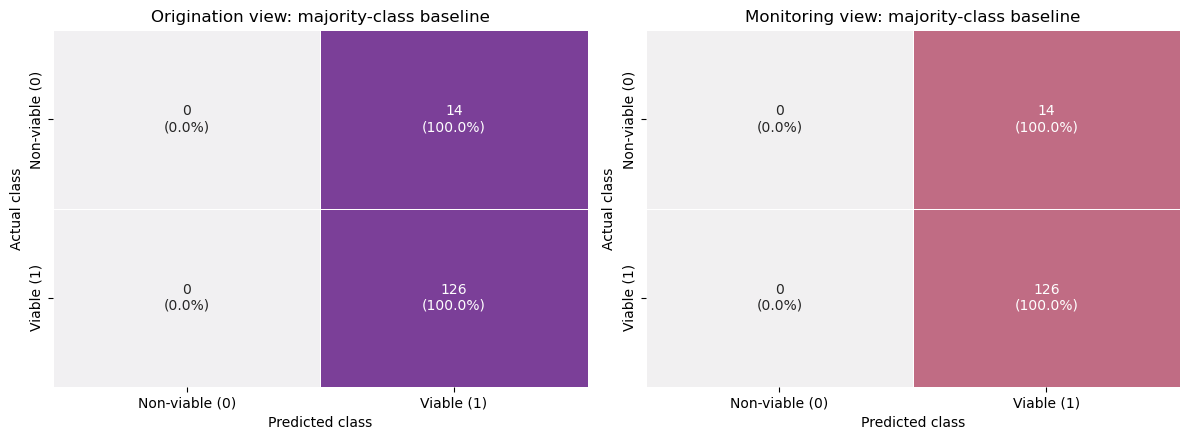

In [79]:
# ============================================================
# BLOCK 67: Create majority-class baseline confusion matrices
# Purpose:
#   - Compare actual and predicted classes for each baseline
#   - Store confusion matrices for later metric calculations
#   - Visualize baseline classification results
# DataFrames created:
#   - origination_baseline_confusion
#   - monitoring_baseline_confusion
# Files created:
#   - None
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

class_labels = [
    "Non-viable (0)",
    "Viable (1)"
]

baseline_confusion_matrices = {}

for view_name, baseline_eval in baseline_evaluations.items():
    confusion_values = confusion_matrix(
        baseline_eval["actual"],
        baseline_eval["predicted"],
        labels=[0, 1]
    )

    baseline_confusion_matrices[view_name] = pd.DataFrame(
        confusion_values,
        index=class_labels,
        columns=class_labels
    )

origination_baseline_confusion = baseline_confusion_matrices[
    "origination_view"
]

monitoring_baseline_confusion = baseline_confusion_matrices[
    "monitoring_view"
]

# Calculate row percentages
origination_baseline_confusion_pct = (
    origination_baseline_confusion
    .div(
        origination_baseline_confusion.sum(axis=1),
        axis=0
    )
    .mul(100)
)

monitoring_baseline_confusion_pct = (
    monitoring_baseline_confusion
    .div(
        monitoring_baseline_confusion.sum(axis=1),
        axis=0
    )
    .mul(100)
)


def create_confusion_annotations(counts, percentages):
    annotations = counts.astype(str).copy()

    for row in counts.index:
        for column in counts.columns:
            annotations.loc[row, column] = (
                f"{counts.loc[row, column]}\n"
                f"({percentages.loc[row, column]:.1f}%)"
            )

    return annotations


origination_baseline_annotations = (
    create_confusion_annotations(
        origination_baseline_confusion,
        origination_baseline_confusion_pct
    )
)

monitoring_baseline_annotations = (
    create_confusion_annotations(
        monitoring_baseline_confusion,
        monitoring_baseline_confusion_pct
    )
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4.5)
)

sns.heatmap(
    origination_baseline_confusion_pct,
    annot=origination_baseline_annotations,
    fmt="",
    cmap=sns.light_palette("#7B3F98", as_cmap=True),
    vmin=0,
    vmax=100,
    cbar=False,
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title(
    "Origination view: majority-class baseline"
)
axes[0].set_xlabel("Predicted class")
axes[0].set_ylabel("Actual class")

sns.heatmap(
    monitoring_baseline_confusion_pct,
    annot=monitoring_baseline_annotations,
    fmt="",
    cmap=sns.light_palette("#C06C84", as_cmap=True),
    vmin=0,
    vmax=100,
    cbar=False,
    linewidths=0.5,
    ax=axes[1]
)

axes[1].set_title(
    "Monitoring view: majority-class baseline"
)
axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("Actual class")

plt.tight_layout()
plt.show()

The majority-class baseline predicts every test operation as Viable in both analytical views. It correctly classifies all 126 Viable operations but incorrectly assigns all 14 Non-viable operations to the Viable class, resulting in a 0% detection rate for Non-viable cases. This behavior is expected because the baseline does not use any predictors and simply reproduces the most frequent class observed in the training data. From a Business Model perspective, such a rule would be unacceptable because it would approve every operation and fail to flag any economically Non-viable case for further review. Therefore, despite achieving a high number of correct classifications because of the class imbalance, it cannot support risk-based lending decisions and serves only as the minimum benchmark for the subsequent classification models.

In [80]:
# ============================================================
# BLOCK 68: Consolidate majority-class baseline metrics
# Purpose:
#   - Summarize the baseline evaluation in one comparison row
#   - Evaluate overall performance and non-viable detection
#   - Calculate probability-based no-skill metrics
# DataFrames created:
#   - baseline_metrics_summary
#   - baseline_metrics_display
# Files created:
#   - None
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# Confirm that both views have the same baseline outcomes
origination_baseline = (
    baseline_evaluations["origination_view"][
        ["actual", "predicted"]
    ]
    .reset_index(drop=True)
)

monitoring_baseline = (
    baseline_evaluations["monitoring_view"][
        ["actual", "predicted"]
    ]
    .reset_index(drop=True)
)

assert origination_baseline.equals(
    monitoring_baseline
), "Baseline outcomes differ across analytical views."

# Use one shared calculation because the baseline uses no predictors
y_true = origination_baseline["actual"].astype(int)
y_pred = origination_baseline["predicted"].astype(int)

# Treat non-viable operations as the class of interest
y_true_non_viable = (y_true == 0).astype(int)

# Use training prevalence as the constant no-skill probability
y_train = regression_splits[
    "origination_view"
]["y_train"].astype(int)

non_viable_train_prevalence = (
    y_train == 0
).mean()

non_viable_probability = np.full(
    shape=len(y_true),
    fill_value=non_viable_train_prevalence
)

accuracy = accuracy_score(
    y_true,
    y_pred
)

classification_error = 1 - accuracy

balanced_accuracy = balanced_accuracy_score(
    y_true,
    y_pred
)

precision_non_viable = precision_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

recall_non_viable = recall_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

f1_non_viable = f1_score(
    y_true,
    y_pred,
    pos_label=0,
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

roc_auc = roc_auc_score(
    y_true_non_viable,
    non_viable_probability
)

pr_auc = average_precision_score(
    y_true_non_viable,
    non_viable_probability
)

baseline_metrics_summary = pd.DataFrame([{
    "model": "Majority baseline",
    "accuracy_pct": round(accuracy * 100, 2),
    "classification_error_pct": round(
        classification_error * 100,
        2
    ),
    "balanced_accuracy_pct": round(
        balanced_accuracy * 100,
        2
    ),
    "precision_non_viable_pct": round(
        precision_non_viable * 100,
        2
    ),
    "recall_non_viable_pct": round(
        recall_non_viable * 100,
        2
    ),
    "f1_non_viable_pct": round(
        f1_non_viable * 100,
        2
    ),
    "macro_f1_pct": round(
        macro_f1 * 100,
        2
    ),
    "roc_auc_pct": round(
        roc_auc * 100,
        2
    ),
    "pr_auc_pct": round(
        pr_auc * 100,
        2
    )
}])

baseline_metrics_display = pd.DataFrame({
    "Metric": [
        "Model",
        "Accuracy",
        "Classification error",
        "Balanced accuracy",
        "Precision: non-viable",
        "Recall: non-viable",
        "F1-score: non-viable",
        "Macro F1-score",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Origination view": [
        baseline_metrics_summary.loc[0, "model"],
        f'{baseline_metrics_summary.loc[0, "accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "classification_error_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "balanced_accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "precision_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "recall_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "f1_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "macro_f1_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "roc_auc_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "pr_auc_pct"]:.2f}%'
    ],
    "Monitoring view": [
        baseline_metrics_summary.loc[0, "model"],
        f'{baseline_metrics_summary.loc[0, "accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "classification_error_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "balanced_accuracy_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "precision_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "recall_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "f1_non_viable_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "macro_f1_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "roc_auc_pct"]:.2f}%',
        f'{baseline_metrics_summary.loc[0, "pr_auc_pct"]:.2f}%'
    ]
})

display(
    baseline_metrics_display.style
    .hide(axis="index")
    .set_caption(
        "Majority-Class Baseline Performance by Analytical View"
    )
)

Metric,Origination view,Monitoring view
Model,Majority baseline,Majority baseline
Accuracy,90.00%,90.00%
Classification error,10.00%,10.00%
Balanced accuracy,50.00%,50.00%
Precision: non-viable,0.00%,0.00%
Recall: non-viable,0.00%,0.00%
F1-score: non-viable,0.00%,0.00%
Macro F1-score,47.37%,47.37%
ROC-AUC,50.00%,50.00%
PR-AUC,10.00%,10.00%


The majority-class baseline achieves 90.00% accuracy in both views, but this result is misleading because it predicts every operation as Viable. Its balanced accuracy and ROC-AUC remain at 50.00%, while precision, recall and F1-score for the Non-viable class are all 0.00%, and the Macro F1-score is only 47.37%. The PR-AUC of 10.00% matches the prevalence of Non-viable operations in the test sample, confirming that the baseline provides no useful ranking ability beyond the class distribution. From a Business Model perspective, this rule would approve all operations and fail to identify any economically Non-viable case, so it cannot support credit-risk decisions. The subsequent models must therefore improve minority-class detection, particularly recall, F1-score and PR-AUC, rather than merely exceed the baseline’s overall accuracy.

### Logistic Regression

In [81]:
# ============================================================
# BLOCK 69: Review categorical training distributions
# Purpose:
#   - Confirm the remaining categorical predictors
#   - Display category counts and percentages using training data only
#   - Support the later selection of reference categories
# DataFrames created:
#   - categorical_predictor_overview
#   - categorical_reference_review
#   - origination_reference_review
#   - monitoring_reference_review
# Files created:
#   - None
# ============================================================

categorical_reference_review = {}
categorical_overview_rows = []

for view_name, split_data in regression_splits.items():
    X_train = split_data["X_train"].copy()

    categorical_columns = (
        X_train
        .select_dtypes(
            include=["object", "category", "bool"]
        )
        .columns
        .tolist()
    )

    numeric_columns = (
        X_train
        .select_dtypes(
            exclude=["object", "category", "bool"]
        )
        .columns
        .tolist()
    )

    categorical_overview_rows.append({
        "Analytical view": view_name.replace(
            "_view",
            " view"
        ).title(),
        "Total predictors": X_train.shape[1],
        "Numeric predictors": len(numeric_columns),
        "Categorical predictors": len(categorical_columns),
        "Named categorical predictors": ", ".join(
            categorical_columns
        )
    })

    review_rows = []

    for variable in categorical_columns:
        category_counts = (
            X_train[variable]
            .astype("object")
            .fillna("Missing")
            .value_counts(dropna=False)
        )

        total_records = int(category_counts.sum())
        maximum_count = int(category_counts.max())

        for category, count in category_counts.items():
            review_rows.append({
                "Variable": variable,
                "Category": category,
                "Training records": int(count),
                "Training percentage": (
                    f"{count / total_records * 100:.2f}%"
                ),
                "Most frequent": (
                    "Yes"
                    if int(count) == maximum_count
                    else ""
                )
            })

    categorical_reference_review[view_name] = (
        pd.DataFrame(review_rows)
    )

categorical_predictor_overview = pd.DataFrame(
    categorical_overview_rows
)

origination_reference_review = (
    categorical_reference_review[
        "origination_view"
    ]
)

monitoring_reference_review = (
    categorical_reference_review[
        "monitoring_view"
    ]
)

display(
    categorical_predictor_overview.style
    .hide(axis="index")
    .set_caption(
        "Training predictor overview by analytical view"
    )
)

display_side_by_side(
    origination_reference_review,
    monitoring_reference_review,
    "Origination view: categorical training review",
    "Monitoring view: categorical training review"
)

Analytical view,Total predictors,Numeric predictors,Categorical predictors,Named categorical predictors
Origination View,22,18,4,"Provincia, tipo_promotor, riesgo_legal_titulo, tipo_activo"
Monitoring View,28,23,5,"Provincia, tipo_promotor, riesgo_legal_titulo, tipo_activo, hito_actual"


Variable,Category,Training records,Training percentage,Most frequent
Provincia,Zaragoza,25,7.69%,Yes
Provincia,Baleares,25,7.69%,Yes
Provincia,Guadalajara,24,7.38%,
Provincia,Alicante,23,7.08%,
Provincia,Girona,23,7.08%,
Provincia,Tarragona,23,7.08%,
Provincia,Barcelona,23,7.08%,
Provincia,Castellón,22,6.77%,
Provincia,Murcia,22,6.77%,
Provincia,Toledo,21,6.46%,


The categorical training review confirms that all retained levels have sufficient representation for one-hot encoding without grouping or removing categories. The smallest categories are Valencia and Madrid, with 17 training observations each, while high legal risk contains 28 observations and every monitoring milestone contains at least 61. Therefore, no sparse categorical level is identified at this stage. Reference categories should be selected for business interpretability, while Provincia should remain a control variable because territorial conditions were not structurally connected to the synthetic target.

In [82]:
# ============================================================
# BLOCK 70: Confirm selected reference categories
# Purpose:
#   - Store the reference category selected for each predictor
#   - Validate each reference using the training review from Block 69
#   - Report the training support of each selected reference
# DataFrames created:
#   - origination_reference_selection
#   - monitoring_reference_selection
# Files created:
#   - None
# ============================================================

categorical_reference_map = {
    "origination_view": {
        "Provincia": "Barcelona",
        "tipo_promotor": "sociedad_vehiculo_proyecto",
        "riesgo_legal_titulo": "bajo",
        "tipo_activo": "obra_nueva"
    },
    "monitoring_view": {
        "Provincia": "Barcelona",
        "tipo_promotor": "sociedad_vehiculo_proyecto",
        "riesgo_legal_titulo": "bajo",
        "tipo_activo": "obra_nueva",
        "hito_actual": "inicio_obra"
    }
}

reference_selection_tables = {}

for view_name, reference_map in categorical_reference_map.items():
    training_review = categorical_reference_review[
        view_name
    ].copy()

    selection_rows = []

    for variable, reference_category in reference_map.items():
        reference_match = training_review[
            (training_review["Variable"] == variable) &
            (
                training_review["Category"].astype(str) ==
                str(reference_category)
            )
        ]

        reference_available = not reference_match.empty

        selection_rows.append({
            "Categorical predictor": variable,
            "Reference category": reference_category,
            "Training records": (
                int(reference_match.iloc[0]["Training records"])
                if reference_available
                else 0
            ),
            "Training percentage": (
                reference_match.iloc[0]["Training percentage"]
                if reference_available
                else "0.00%"
            ),
            "Available in training": (
                "Yes" if reference_available else "No"
            )
        })

    reference_selection_tables[view_name] = pd.DataFrame(
        selection_rows
    )

origination_reference_selection = (
    reference_selection_tables["origination_view"]
)

monitoring_reference_selection = (
    reference_selection_tables["monitoring_view"]
)

assert (
    origination_reference_selection[
        "Available in training"
    ] == "Yes"
).all(), (
    "At least one origination reference category "
    "is not available in training."
)

assert (
    monitoring_reference_selection[
        "Available in training"
    ] == "Yes"
).all(), (
    "At least one monitoring reference category "
    "is not available in training."
)

display_side_by_side(
    origination_reference_selection,
    monitoring_reference_selection,
    "Origination view: selected reference categories",
    "Monitoring view: selected reference categories"
)

Categorical predictor,Reference category,Training records,Training percentage,Available in training
Provincia,Barcelona,23,7.08%,Yes
tipo_promotor,sociedad_vehiculo_proyecto,78,24.00%,Yes
riesgo_legal_titulo,bajo,219,67.38%,Yes
tipo_activo,obra_nueva,175,53.85%,Yes
Categorical predictor,Reference category,Training records,Training percentage,Available in training
Provincia,Barcelona,23,7.08%,Yes
tipo_promotor,sociedad_vehiculo_proyecto,78,24.00%,Yes
riesgo_legal_titulo,bajo,219,67.38%,Yes
tipo_activo,obra_nueva,175,53.85%,Yes
hito_actual,inicio_obra,86,26.46%,Yes


The selected reference categories are all present in the training sample and have sufficient representation for stable one-hot encoding. Barcelona is used as the provincial benchmark with 23 training operations, equivalent to 7.08% of the sample, providing an interpretable large-market reference even though it is not the most frequent province. For promoter type, sociedad_vehiculo_proyecto is selected with 78 operations (24.00%); for legal-title risk, bajo is used with 219 operations (67.38%); and for asset type, obra_nueva is retained with 175 operations (53.85%). In the monitoring view, inicio_obra is added as the milestone reference with 86 operations (26.46%). These choices do not remove the remaining categories; they only establish the comparison base used to interpret the later logistic-regression coefficients and odds ratios.

In [83]:
# ============================================================
# BLOCK 71: Complete unpenalized logistic regression diagnostics
# Purpose:
#   - Fit the complete unpenalized model for each view
#   - Evaluate numerical stability and training separation
# 
# DataFrames created:
#   - complete_logistic_diagnostic_summary
#   - origination_complete_diagnostic
#   - monitoring_complete_diagnostic
#   - origination_complete_coefficients
#   - monitoring_complete_coefficients
# Files created:
#   - None
# ============================================================

import warnings
import statsmodels.api as sm

# 1. Standardize numeric predictors and create 0/1 dummies
def build_complete_design_matrix(X_train, reference_categories):
    categorical_columns = list(reference_categories)
    numeric_columns = [c for c in X_train.columns if c not in categorical_columns]

    X_raw = X_train[numeric_columns].apply(pd.to_numeric, errors="raise").astype(float)
    numeric_mean = X_raw.mean()
    numeric_std = X_raw.std(ddof=0).replace(0, 1)
    parts = [(X_raw - numeric_mean) / numeric_std]

    for variable in categorical_columns:
        reference = reference_categories[variable]
        observed = X_train[variable].astype(str)
        assert reference in observed.unique(), (
            f"Reference category '{reference}' is not present in {variable}."
        )

        levels = [reference] + sorted(set(observed) - {reference})
        categorical_series = pd.Series(
            pd.Categorical(observed, categories=levels),
            index=X_train.index,
            name=variable
        )

        parts.append(pd.get_dummies(
            categorical_series,
            prefix=variable,
            prefix_sep="=",
            drop_first=True,
            dtype=float
        ))

    X_design = sm.add_constant(pd.concat(parts, axis=1), has_constant="add")
    X_design = X_design.apply(pd.to_numeric, errors="raise").astype(float)

    return {
        "X_design": X_design,
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns,
        "numeric_mean": numeric_mean,
        "numeric_std": numeric_std
    }

# 2. Fit one complete model and calculate its diagnostics
def fit_complete_view(view_name, split_data):
    X_train = split_data["X_train"].copy()
    y_train = pd.to_numeric(split_data["y_train"], errors="raise").astype(float)

    design = build_complete_design_matrix(
        X_train,
        categorical_reference_map[view_name]
    )

    X_design = design["X_design"]
    y_train = y_train.reindex(X_design.index)

    assert X_design.index.equals(y_train.index)
    assert np.isfinite(X_design.to_numpy()).all()
    assert np.isfinite(y_train.to_numpy()).all()

    design_array = X_design.to_numpy()
    matrix_rank = int(np.linalg.matrix_rank(design_array))
    design_columns = X_design.shape[1]
    full_column_rank = matrix_rank == design_columns
    condition_number = float(np.linalg.cond(design_array))

    with warnings.catch_warnings(record=True) as captured_warnings:
        warnings.simplefilter("always")
        model = sm.Logit(y_train, X_design).fit(
            method="lbfgs",
            maxiter=5000,
            disp=False
        )

    warning_messages = [str(w.message) for w in captured_warnings]
    if any("Inverting hessian failed" in m for m in warning_messages):
        warning_summary = "Hessian inversion failed"
    elif warning_messages:
        warning_summary = " | ".join(sorted(set(warning_messages)))
    else:
        warning_summary = "None"

    try:
        covariance_available = bool(
            np.isfinite(np.asarray(model.cov_params())).all()
        )
    except Exception:
        covariance_available = False

    probabilities = np.asarray(model.predict(X_design), dtype=float)
    training_records = len(y_train)
    non_viable_records = int((y_train == 0).sum())
    viable_records = int((y_train == 1).sum())
    estimated_parameters = len(model.params)
    transformed_predictors = X_design.shape[1] - 1
    cases_per_parameter = non_viable_records / estimated_parameters

    below_001 = int((probabilities < 0.01).sum())
    above_099 = int((probabilities > 0.99).sum())
    separation_warning = (below_001 + above_099) / training_records >= 0.95
    low_minority_support = non_viable_records < estimated_parameters
    inference_reliable = (
        covariance_available
        and not separation_warning
        and not low_minority_support
    )

    negative_two_log_likelihood = float(-2 * model.llf)
    aic = float(model.aic)
    bic = float(model.bic)
    denominator = training_records - estimated_parameters - 1
    aicc = (
        aic + 2 * estimated_parameters * (estimated_parameters + 1) / denominator
        if denominator > 0 else np.nan
    )

    coefficients = model.params.drop("const", errors="ignore")
    coefficient_table = (
        coefficients.rename("Coefficient")
        .rename_axis("Parameter")
        .reset_index()
        .assign(_magnitude=lambda x: x["Coefficient"].abs())
        .sort_values("_magnitude", ascending=False)
        .drop(columns="_magnitude")
        .reset_index(drop=True)
    )

    if not covariance_available:
        conclusion = "Training separation and unavailable classical inference"
    elif separation_warning:
        conclusion = "Training separation and unreliable classical inference"
    elif low_minority_support:
        conclusion = "Insufficient minority support for complete-model inference"
    else:
        conclusion = "No major diagnostic issue detected"

    converged = bool(model.mle_retvals.get("converged", False))
    yes_no = lambda value: "Yes" if value else "No"

    summary = {
        "Analytical view": view_name.replace("_view", " view").title(),
        "Training records": training_records,
        "Non-viable records": non_viable_records,
        "Viable records": viable_records,
        "Original predictors": X_train.shape[1],
        "Transformed predictors": transformed_predictors,
        "Estimated parameters": estimated_parameters,
        "Non-viable cases per parameter": cases_per_parameter,
        "Matrix rank": matrix_rank,
        "Design columns": design_columns,
        "Full column rank": full_column_rank,
        "Condition number": condition_number,
        "Maximum coefficient magnitude": float(coefficients.abs().max()),
        "Probabilities below 0.01": below_001,
        "Probabilities above 0.99": above_099,
        "-2 Log L": negative_two_log_likelihood,
        "AIC": aic,
        "AICc": aicc,
        "BIC / SC": bic,
        "Converged": converged,
        "Covariance available": covariance_available,
        "Reliable inference": inference_reliable,
        "Estimation warning": warning_summary,
        "Diagnostic conclusion": conclusion
    }

    display_table = pd.DataFrame({
        "Diagnostic": [
            "Training records",
            "Non-viable records",
            "Original predictors",
            "Transformed predictors",
            "Estimated parameters",
            "Non-viable cases per parameter",
            "Design matrix rank",
            "Condition number",
            "Maximum coefficient magnitude",
            "Extreme fitted probabilities",
            "-2 Log L",
            "AIC",
            "AICc",
            "BIC / SC",
            "Converged",
            "Covariance matrix available",
            "Reliable classical inference",
            "Diagnostic conclusion"
        ],
        "Result": [
            str(training_records),
            str(non_viable_records),
            str(X_train.shape[1]),
            str(transformed_predictors),
            str(estimated_parameters),
            f"{cases_per_parameter:.2f}",
            f"{matrix_rank} of {design_columns} "
            f"({'full rank' if full_column_rank else 'not full rank'})",
            f"{condition_number:.2f}",
            f"{coefficients.abs().max():.2f}",
            f"{below_001} below 0.01; {above_099} above 0.99",
            f"{negative_two_log_likelihood:.2f}",
            f"{aic:.2f}",
            f"{aicc:.2f}",
            f"{bic:.2f}",
            yes_no(converged),
            yes_no(covariance_available),
            yes_no(inference_reliable),
            conclusion
        ]
    })

    stored_design = {
        "X_train_design": X_design,
        "y_train_model": y_train,
        "numeric_columns": design["numeric_columns"],
        "categorical_columns": design["categorical_columns"],
        "numeric_mean": design["numeric_mean"],
        "numeric_std": design["numeric_std"]
    }

    return {
        "model": model,
        "design": stored_design,
        "coefficients": coefficient_table,
        "summary": summary,
        "display": display_table
    }

# 3. Run and store both analytical views
complete_results = {
    view_name: fit_complete_view(view_name, split_data)
    for view_name, split_data in regression_splits.items()
}

complete_diagnostic_models = {
    view: result["model"] for view, result in complete_results.items()
}
complete_design_matrices = {
    view: result["design"] for view, result in complete_results.items()
}
complete_coefficient_tables = {
    view: result["coefficients"] for view, result in complete_results.items()
}
diagnostic_display_tables = {
    view: result["display"] for view, result in complete_results.items()
}
diagnostic_summary_rows = [
    result["summary"] for result in complete_results.values()
]

complete_logistic_diagnostic_summary = pd.DataFrame(diagnostic_summary_rows)

origination_complete_diagnostic = diagnostic_display_tables["origination_view"]
monitoring_complete_diagnostic = diagnostic_display_tables["monitoring_view"]
origination_complete_coefficients = complete_coefficient_tables["origination_view"]
monitoring_complete_coefficients = complete_coefficient_tables["monitoring_view"]

display_side_by_side(
    origination_complete_diagnostic,
    monitoring_complete_diagnostic,
    "Origination view: complete-model diagnostic",
    "Monitoring view: complete-model diagnostic"
)

# 4. Create raw training bases for later model selection
def build_view1_from_training_split(view_name):
    split_data = regression_splits[view_name]

    X_model = split_data["X_train"].copy()
    y_model = (
        split_data["y_train"]
        .astype(int)
        .rename(target_col)
    )

    categorical_columns = (
        X_model
        .select_dtypes(
            include=["object", "category", "bool"]
        )
        .columns
        .tolist()
    )

    numeric_columns = [
        column for column in X_model.columns
        if column not in categorical_columns
    ]

    preprocessing = {
        "numeric_columns": numeric_columns,
        "categorical_columns": categorical_columns,
        "reference_categories": categorical_reference_map[
            view_name
        ],
        "predictor_columns": X_model.columns.tolist()
    }

    return (
        pd.concat([X_model, y_model], axis=1),
        preprocessing
    )


origination_view1, origination_view1_preprocessing = (
    build_view1_from_training_split(
        "origination_view"
    )
)

monitoring_view1, monitoring_view1_preprocessing = (
    build_view1_from_training_split(
        "monitoring_view"
    )
)

origination_selection_variables = (
    origination_view1_preprocessing[
        "predictor_columns"
    ]
)

monitoring_selection_variables = (
    monitoring_view1_preprocessing[
        "predictor_columns"
    ]
)


def view1_summary_row(label, view1, preprocessing):
    target = view1[target_col]

    return {
        "View": label,
        "Training records": len(view1),
        "Numeric predictors": len(
            preprocessing["numeric_columns"]
        ),
        "Categorical predictors": len(
            preprocessing["categorical_columns"]
        ),
        "Total original predictors": len(
            preprocessing["predictor_columns"]
        ),
        "Non-viable": int((target == 0).sum()),
        "Viable": int((target == 1).sum())
    }


view1_summary = pd.DataFrame([
    view1_summary_row(
        "Origination view1",
        origination_view1,
        origination_view1_preprocessing
    ),
    view1_summary_row(
        "Monitoring view1",
        monitoring_view1,
        monitoring_view1_preprocessing
    )
])

display(
    view1_summary.style
    .hide(axis="index")
    .set_caption(
        "Raw Training Bases for Model Selection"
    )
)

Diagnostic,Result
Training records,325
Non-viable records,34
Original predictors,22
Transformed predictors,40
Estimated parameters,41
Non-viable cases per parameter,0.83
Design matrix rank,41 of 41 (full rank)
Condition number,33.08
Maximum coefficient magnitude,83.33
Extreme fitted probabilities,34 below 0.01; 291 above 0.99


View,Training records,Numeric predictors,Categorical predictors,Total original predictors,Non-viable,Viable
Origination view1,325,18,4,22,34,291
Monitoring view1,325,23,5,28,34,291


The complete logistic models confirm training separation in both analytical views. In the origination view, all 34 Non-viable operations receive fitted probabilities below 0.01 and all 291 Viable operations receive probabilities above 0.99; the monitoring view produces the same extreme classification pattern. Although both design matrices are full rank and the optimizers converge, the specifications are too complex relative to the minority-class support. Origination estimates 41 parameters, equivalent to only 0.83 Non-viable cases per parameter, while monitoring estimates 49 parameters, equivalent to 0.69 cases per parameter. The maximum coefficient magnitudes are 83.33 and 41.99 respectively, together with the near-zero −2 Log L of 0.01, confirming that the models reproduce the training labels almost perfectly. Both covariance matrices are technically available, but neither supports reliable classical inference given the separation.

From a Business Model perspective, this does not mean that the predictors lack useful information. It indicates that the complete specifications recover the synthetic decision rule too closely to produce stable and interpretable unpenalized coefficient estimates. These models should therefore remain diagnostic only. The next stage must use smaller or penalized specifications, perform variable selection through leakage-safe cross-validation with Non-viable PR-AUC as the primary criterion, and reserve the untouched test set for final evaluation. The raw training bases remain correctly preserved with 325 operations, including 34 Non-viable and 291 Viable cases, and with 22 origination predictors and 28 monitoring predictors.

In [84]:
# ============================================================
# BLOCK 72: Verify categorical-level support
# Purpose:
#   - Review the training support of each future dummy variable
#   - Compare possible support thresholds before combining any level
#   - Identify categorical levels without non-viable support
# DataFrames created:
#   - origination_dummy_support
#   - monitoring_dummy_support
#   - dummy_threshold_summary
# Files created:
#   - None
# ============================================================

# 1. Calculate support for each future dummy variable
def build_dummy_support(
    view1,
    preprocessing
):
    target = view1[target_col].astype(int)

    categorical_columns = preprocessing[
        "categorical_columns"
    ]

    reference_categories = preprocessing[
        "reference_categories"
    ]

    rows = []

    for variable in categorical_columns:
        observed = (
            view1[variable]
            .astype(str)
        )

        reference = str(
            reference_categories[variable]
        )

        levels = sorted(
            level
            for level in observed.unique()
            if level != reference
        )

        for level in levels:
            active = observed.eq(level)
            total = int(active.sum())

            non_viable = int(
                (active & target.eq(0)).sum()
            )

            viable = int(
                (active & target.eq(1)).sum()
            )

            rows.append({
                "Original variable": variable,
                "Dummy variable": (
                    f"{variable}={level}"
                ),
                "Reference category": reference,
                "Total": total,
                "Share": total / len(view1),
                "Non-viable": non_viable,
                "Viable": viable,
                "Below 3": total < 3,
                "Below 5": total < 5,
                "Below 10": total < 10,
                "Zero non-viable support": (
                    non_viable == 0
                )
            })

    result = (
        pd.DataFrame(rows)
        .sort_values(
            ["Total", "Dummy variable"]
        )
        .reset_index(drop=True)
    )

    result["Share"] = result["Share"].map(
        lambda value: f"{value:.2%}"
    )

    for column in [
        "Below 3",
        "Below 5",
        "Below 10",
        "Zero non-viable support"
    ]:
        result[column] = result[column].map({
            True: "Yes",
            False: "No"
        })

    return result


# 2. Create support tables for both analytical views
origination_dummy_support = build_dummy_support(
    origination_view1,
    origination_view1_preprocessing
)

monitoring_dummy_support = build_dummy_support(
    monitoring_view1,
    monitoring_view1_preprocessing
)


# 3. Summarize the number of levels affected by each rule
def threshold_summary_row(
    label,
    support_table
):
    return {
        "View": label,
        "Dummy variables": len(
            support_table
        ),
        "Below 3": int(
            (
                support_table["Below 3"] ==
                "Yes"
            ).sum()
        ),
        "Below 5": int(
            (
                support_table["Below 5"] ==
                "Yes"
            ).sum()
        ),
        "Below 10": int(
            (
                support_table["Below 10"] ==
                "Yes"
            ).sum()
        ),
        "Zero non-viable support": int(
            (
                support_table[
                    "Zero non-viable support"
                ] == "Yes"
            ).sum()
        )
    }


dummy_threshold_summary = pd.DataFrame([
    threshold_summary_row(
        "Origination view",
        origination_dummy_support
    ),
    threshold_summary_row(
        "Monitoring view",
        monitoring_dummy_support
    )
])

# 4. Create cleaner display tables

display_columns = [
    "Original variable",
    "Dummy variable",
    "Total",
    "Share",
    "Non-viable",
    "Viable",
    "Zero non-viable support"
]

origination_dummy_support_display = (
    origination_dummy_support[
        display_columns
    ].copy()
)

monitoring_dummy_support_display = (
    monitoring_dummy_support[
        display_columns
    ].copy()
)

caption_styles = [
    {
        "selector": "caption",
        "props": [
            ("font-size", "18px"),
            ("font-weight", "bold"),
            ("text-align", "left"),
            ("caption-side", "top"),
            ("margin-bottom", "8px")
        ]
    }
]

display(
    dummy_threshold_summary.style
    .hide(axis="index")
    .set_caption(
        "Categorical-Level Support Summary"
    )
    .set_table_styles(caption_styles)
)

display(
    origination_dummy_support_display.style
    .hide(axis="index")
    .set_caption(
        "Origination view: categorical-level support"
    )
    .set_table_styles(caption_styles)
)

display(
    monitoring_dummy_support_display.style
    .hide(axis="index")
    .set_caption(
        "Monitoring view: categorical-level support"
    )
    .set_table_styles(caption_styles)
)

View,Dummy variables,Below 3,Below 5,Below 10,Zero non-viable support
Origination view,22,0,0,0,0
Monitoring view,25,0,0,0,0


Original variable,Dummy variable,Total,Share,Non-viable,Viable,Zero non-viable support
Provincia,Provincia=Madrid,17,5.23%,1,16,No
Provincia,Provincia=Valencia,17,5.23%,3,14,No
Provincia,Provincia=Almería,19,5.85%,4,15,No
Provincia,Provincia=Málaga,20,6.15%,1,19,No
Provincia,Provincia=Sevilla,21,6.46%,1,20,No
Provincia,Provincia=Toledo,21,6.46%,4,17,No
Provincia,Provincia=Castellón,22,6.77%,1,21,No
Provincia,Provincia=Murcia,22,6.77%,3,19,No
Provincia,Provincia=Alicante,23,7.08%,1,22,No
Provincia,Provincia=Girona,23,7.08%,1,22,No


Original variable,Dummy variable,Total,Share,Non-viable,Viable,Zero non-viable support
Provincia,Provincia=Madrid,17,5.23%,1,16,No
Provincia,Provincia=Valencia,17,5.23%,3,14,No
Provincia,Provincia=Almería,19,5.85%,4,15,No
Provincia,Provincia=Málaga,20,6.15%,1,19,No
Provincia,Provincia=Sevilla,21,6.46%,1,20,No
Provincia,Provincia=Toledo,21,6.46%,4,17,No
Provincia,Provincia=Castellón,22,6.77%,1,21,No
Provincia,Provincia=Murcia,22,6.77%,3,19,No
Provincia,Provincia=Alicante,23,7.08%,1,22,No
Provincia,Provincia=Girona,23,7.08%,1,22,No


The categorical-level support review shows that every non-reference level represented by a future dummy variable contains at least 17 training observations, with no level falling below 10 cases. Each of these non-reference levels includes both Viable and Non-viable operations, so the support results do not justify grouping or removing any dummy category because of low frequency or absence of minority-class observations. Reference categories are not included in this review because they do not generate dummy variables. In particular, Barcelona, used as the reference category for Provincia, contains 23 training operations, all classified as Viable. This requires caution when interpreting the separation observed in the complete unpenalized model. However, Provincia was not retained in either final logistic specification, so this characteristic does not affect the reported coefficients or odds ratios. All predefined categories are therefore retained, while Provincia remains a contextual variable and not an independent criterion for approval, rejection, pricing or risk decisions.

In [85]:
# ============================================================
# BLOCK 73: Automatic variable-selection functions
# Purpose:
#   - Select complete original predictors automatically
#   - Use near-unpenalized information criteria as heuristics
#   - Test information-criterion sensitivity across large C values
#   - Use Non-viable PR-AUC, not accuracy, for grouped RF-RFE
# Objects created:
#   - Reusable preprocessing, selection and sensitivity functions
# Files created:
#   - None
# ============================================================

from collections import Counter
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.model_selection import (
    StratifiedKFold,
    StratifiedShuffleSplit,
    cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_one_hot_encoder(drop=None):
    try:
        return OneHotEncoder(
            drop=drop,
            handle_unknown="ignore",
            sparse_output=True
        )
    except TypeError:
        return OneHotEncoder(
            drop=drop,
            handle_unknown="ignore",
            sparse=True
        )


def materialize_cv_splits(cv, X, y):
    return (
        list(cv.split(X, y))
        if hasattr(cv, "split")
        else list(cv)
    )


def non_viable_pr_auc_scorer(estimator, X, y):
    classes = np.asarray(estimator.classes_)

    assert 0 in classes, (
        "Class 0 must represent Non-viable operations."
    )

    position = int(
        np.flatnonzero(classes == 0)[0]
    )

    probability = estimator.predict_proba(
        X
    )[:, position]

    observed = (
        np.asarray(y).astype(int) == 0
    ).astype(int)

    return float(
        average_precision_score(
            observed,
            probability
        )
    )


def build_logistic_preprocessor(
    X,
    variables,
    reference_categories
):
    variables = list(variables)

    missing = [
        variable
        for variable in variables
        if variable not in X.columns
    ]

    assert not missing, (
        "Variables not found in the training data: "
        f"{missing}"
    )

    categorical = [
        variable
        for variable in variables
        if variable in reference_categories
    ]

    numeric = [
        variable
        for variable in variables
        if variable not in categorical
    ]

    for variable in categorical:
        reference = str(
            reference_categories[variable]
        )

        assert reference in (
            X[variable]
            .astype(str)
            .unique()
        ), (
            f"Reference category '{reference}' "
            f"is not available for {variable}."
        )

    transformers = []

    if numeric:
        transformers.append((
            "numeric",
            StandardScaler(),
            numeric
        ))

    if categorical:
        drop = [
            reference_categories[variable]
            for variable in categorical
        ]

        transformers.append((
            "categorical",
            make_one_hot_encoder(
                drop=drop
            ),
            categorical
        ))

    assert transformers, (
        "At least one predictor must be supplied."
    )

    return ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )


def build_ridge_logistic_pipeline(
    X,
    variables,
    reference_categories,
    C
):
    return Pipeline([
        (
            "preprocessor",
            build_logistic_preprocessor(
                X,
                variables,
                reference_categories
            )
        ),
        (
            "model",
            LogisticRegression(
                C=float(C),
                solver="liblinear",
                class_weight="balanced",
                max_iter=5000,
                random_state=GLOBAL_SEED
            )
        )
    ])


def evaluate_ridge_candidates(
    X,
    y,
    variables,
    reference_categories,
    C_values,
    cv,
    n_jobs=-1
):
    X = X.copy()

    y = pd.Series(
        y,
        index=X.index
    ).astype(int)

    variables = list(variables)

    assert variables, (
        "Ridge tuning requires at least one predictor."
    )

    splits = materialize_cv_splits(
        cv,
        X,
        y
    )

    rows = []

    for C in C_values:
        pipeline = build_ridge_logistic_pipeline(
            X,
            variables,
            reference_categories,
            C
        )

        scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=splits,
            scoring=non_viable_pr_auc_scorer,
            n_jobs=n_jobs
        )

        rows.append({
            "C": float(C),
            "Regularization strength": (
                1 / float(C)
            ),
            "Original predictors": len(
                variables
            ),
            "Mean Non-viable PR-AUC": float(
                scores.mean()
            ),
            "SD Non-viable PR-AUC": float(
                scores.std(ddof=1)
            )
        })

    return (
        pd.DataFrame(rows)
        .sort_values(
            [
                "Mean Non-viable PR-AUC",
                "C"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )


def build_selection_workspace(
    X,
    reference_categories
):
    parts = []
    group_columns = {}

    for variable in X.columns:
        if variable in reference_categories:
            reference = str(
                reference_categories[variable]
            )

            observed = X[
                variable
            ].astype(str)

            assert reference in observed.unique(), (
                f"Reference category '{reference}' "
                f"is not available for {variable}."
            )

            levels = [
                reference
            ] + sorted(
                set(observed)
                - {reference}
            )

            series = pd.Series(
                pd.Categorical(
                    observed,
                    categories=levels
                ),
                index=X.index,
                name=variable
            )

            dummies = pd.get_dummies(
                series,
                prefix=variable,
                prefix_sep="=",
                drop_first=True,
                dtype=float
            )

            parts.append(
                dummies
            )

            group_columns[variable] = (
                dummies.columns.tolist()
            )

        else:
            numeric = pd.to_numeric(
                X[variable],
                errors="raise"
            ).astype(float)

            std = numeric.std(
                ddof=0
            )

            if (
                not np.isfinite(std)
                or std == 0
            ):
                std = 1.0

            standardized = (
                (
                    numeric
                    - numeric.mean()
                )
                / std
            ).rename(variable)

            parts.append(
                standardized.to_frame()
            )

            group_columns[variable] = [
                variable
            ]

    design = pd.concat(
        parts,
        axis=1
    ).astype(float)

    assert np.isfinite(
        design.to_numpy()
    ).all()

    return {
        "design": design,
        "group_columns": group_columns
    }


# This is a heuristic approximation,
# not classical maximum-likelihood AIC/BIC.
def stable_information_criterion(
    workspace,
    y,
    variables,
    k_penalty,
    near_unpenalized_C=1e6
):
    assert (
        float(near_unpenalized_C) > 0
    ), (
        "near_unpenalized_C must be positive."
    )

    y = pd.Series(
        y,
        index=workspace[
            "design"
        ].index
    ).astype(int)

    variables = list(variables)

    columns = [
        column
        for variable in variables
        for column in workspace[
            "group_columns"
        ][variable]
    ]

    if columns:
        X_model = workspace[
            "design"
        ][columns]

        model = LogisticRegression(
            C=float(
                near_unpenalized_C
            ),
            solver="liblinear",
            max_iter=10000,
            tol=1e-10,
            random_state=GLOBAL_SEED
        )

        model.fit(
            X_model,
            y
        )

        probability = model.predict_proba(
            X_model
        )[:, 1]

        parameters = (
            X_model.shape[1]
            + 1
        )

    else:
        probability = np.repeat(
            y.mean(),
            len(y)
        )

        parameters = 1

    probability = np.clip(
        probability,
        1e-12,
        1 - 1e-12
    )

    log_likelihood = np.sum(
        y * np.log(probability)
        + (1 - y)
        * np.log(1 - probability)
    )

    return float(
        -2 * log_likelihood
        + float(k_penalty)
        * parameters
    )


def stepwise_select(
    X,
    y,
    k_penalty,
    reference_categories,
    near_unpenalized_C=1e6,
    tolerance=1e-6,
    return_history=False
):
    X = X.copy()

    y = pd.Series(
        y,
        index=X.index
    ).astype(int)

    workspace = build_selection_workspace(
        X,
        reference_categories
    )

    available = X.columns.tolist()
    selected = []
    cache = {}

    def score(variables):
        key = tuple(
            sorted(variables)
        )

        if key not in cache:
            cache[key] = (
                stable_information_criterion(
                    workspace,
                    y,
                    list(key),
                    k_penalty,
                    near_unpenalized_C=(
                        near_unpenalized_C
                    )
                )
            )

        return cache[key]

    current = score([])

    history = [{
        "Step": 0,
        "Action": "Baseline",
        "Variable": "None",
        "Original predictors": 0,
        "Criterion": current
    }]

    step = 0

    while True:
        changed = False

        remaining = [
            variable
            for variable in available
            if variable not in selected
        ]

        if remaining:
            add_score, add_variable = min(
                (
                    (
                        score(
                            selected
                            + [variable]
                        ),
                        variable
                    )
                    for variable in remaining
                ),
                key=lambda item: (
                    item[0],
                    item[1]
                )
            )

            if (
                add_score
                < current
                - tolerance
            ):
                selected.append(
                    add_variable
                )

                current = add_score
                changed = True
                step += 1

                history.append({
                    "Step": step,
                    "Action": "Add",
                    "Variable": add_variable,
                    "Original predictors": len(
                        selected
                    ),
                    "Criterion": current
                })

        while selected:
            remove_score, remove_variable = min(
                (
                    (
                        score([
                            variable
                            for variable in selected
                            if variable != candidate
                        ]),
                        candidate
                    )
                    for candidate in selected
                ),
                key=lambda item: (
                    item[0],
                    item[1]
                )
            )

            if (
                remove_score
                < current
                - tolerance
            ):
                selected.remove(
                    remove_variable
                )

                current = remove_score
                changed = True
                step += 1

                history.append({
                    "Step": step,
                    "Action": "Remove",
                    "Variable": remove_variable,
                    "Original predictors": len(
                        selected
                    ),
                    "Criterion": current
                })

            else:
                break

        if not changed:
            break

    history = pd.DataFrame(
        history
    )

    if return_history:
        return selected, history

    return selected


def repeated_stepwise(
    X,
    y,
    criterion,
    reference_categories,
    near_unpenalized_C=1e6,
    n_repeats=41,
    train_share=0.80,
    random_state=GLOBAL_SEED,
    top_n=1
):
    X = X.copy()

    y = pd.Series(
        y,
        index=X.index
    ).astype(int)

    model_counts = Counter()
    variable_counts = Counter()

    splitter = StratifiedShuffleSplit(
        n_splits=n_repeats,
        train_size=train_share,
        random_state=random_state
    )

    for train_index, _ in splitter.split(
        X,
        y
    ):
        X_sub = X.iloc[
            train_index
        ].copy()

        y_sub = y.iloc[
            train_index
        ].copy()

        if criterion == "AIC":
            penalty = 2.0

        elif criterion == "BIC":
            penalty = np.log(
                len(X_sub)
            )

        else:
            raise ValueError(
                "criterion must be 'AIC' or 'BIC'."
            )

        selected = stepwise_select(
            X_sub,
            y_sub,
            penalty,
            reference_categories,
            near_unpenalized_C=(
                near_unpenalized_C
            )
        )

        selected_key = tuple(
            sorted(selected)
        )

        model_counts[
            selected_key
        ] += 1

        variable_counts.update(
            selected
        )

    ranked = model_counts.most_common(
        top_n
    )

    ranked_models = [
        {
            "variables": list(
                variables
            ),
            "frequency": frequency,
            "selection_share": (
                frequency
                / n_repeats
            )
        }
        for variables, frequency
        in ranked
    ]

    while len(ranked_models) < top_n:
        ranked_models.append(
            ranked_models[0].copy()
            if ranked_models
            else {
                "variables": [],
                "frequency": 0,
                "selection_share": 0.0
            }
        )

    model_frequency = pd.DataFrame([
        {
            "Selected variables": (
                " + ".join(variables)
                if variables
                else "No predictors selected"
            ),
            "Original predictors": len(
                variables
            ),
            "Frequency": frequency,
            "Selection share": (
                frequency
                / n_repeats
            )
        }
        for variables, frequency
        in model_counts.most_common()
    ])

    variable_frequency = pd.DataFrame([
        {
            "Original variable": variable,
            "Frequency": variable_counts[
                variable
            ],
            "Selection share": (
                variable_counts[variable]
                / n_repeats
            )
        }
        for variable in X.columns
    ]).sort_values(
        [
            "Frequency",
            "Original variable"
        ],
        ascending=[
            False,
            True
        ]
    ).reset_index(
        drop=True
    )

    return {
        "selected_sets": [
            item["variables"]
            for item in ranked_models
        ],
        "ranked_models": ranked_models,
        "model_frequency": (
            model_frequency
        ),
        "variable_frequency": (
            variable_frequency
        )
    }


def information_criterion_sensitivity(
    X,
    y,
    reference_categories,
    C_values=(
        1e4,
        1e6,
        1e8
    ),
    k_general=14,
    n_repeats_step=41,
    train_share_step=0.80,
    random_state=GLOBAL_SEED
):
    X = X.copy()

    y = pd.Series(
        y,
        index=X.index
    ).astype(int)

    C_values = tuple(
        float(C)
        for C in C_values
    )

    assert (
        C_values
        and all(
            C > 0
            for C in C_values
        )
    ), (
        "All sensitivity C values "
        "must be positive."
    )

    rows = []
    runs = {}

    for C in C_values:
        step_aic, history_aic = (
            stepwise_select(
                X,
                y,
                2.0,
                reference_categories,
                near_unpenalized_C=C,
                return_history=True
            )
        )

        step_bic, history_bic = (
            stepwise_select(
                X,
                y,
                np.log(len(X)),
                reference_categories,
                near_unpenalized_C=C,
                return_history=True
            )
        )

        step_k, history_k = (
            stepwise_select(
                X,
                y,
                float(k_general),
                reference_categories,
                near_unpenalized_C=C,
                return_history=True
            )
        )

        repeated_aic = repeated_stepwise(
            X,
            y,
            "AIC",
            reference_categories,
            near_unpenalized_C=C,
            n_repeats=n_repeats_step,
            train_share=train_share_step,
            random_state=random_state,
            top_n=1
        )

        repeated_bic = repeated_stepwise(
            X,
            y,
            "BIC",
            reference_categories,
            near_unpenalized_C=C,
            n_repeats=n_repeats_step,
            train_share=train_share_step,
            random_state=random_state,
            top_n=2
        )

        candidate_sets = {
            "AIC_APPROX": step_aic,
            "BIC_APPROX": step_bic,
            "K_APPROX": step_k,
            "REPEATED_AIC_APPROX": (
                repeated_aic[
                    "selected_sets"
                ][0]
            ),
            "REPEATED_BIC_APPROX_1": (
                repeated_bic[
                    "selected_sets"
                ][0]
            ),
            "REPEATED_BIC_APPROX_2": (
                repeated_bic[
                    "selected_sets"
                ][1]
            )
        }

        runs[C] = {
            "candidate_sets": (
                candidate_sets
            ),
            "stepwise_history": {
                "AIC_APPROX": (
                    history_aic
                ),
                "BIC_APPROX": (
                    history_bic
                ),
                "K_APPROX": (
                    history_k
                )
            },
            "repeated_stepwise": {
                "AIC": repeated_aic,
                "BIC": repeated_bic
            }
        }

        workspace = build_selection_workspace(
            X,
            reference_categories
        )

        metadata = {
            "AIC_APPROX": (
                2.0,
                np.nan
            ),
            "BIC_APPROX": (
                np.log(len(X)),
                np.nan
            ),
            "K_APPROX": (
                float(k_general),
                np.nan
            ),
            "REPEATED_AIC_APPROX": (
                2.0,
                repeated_aic[
                    "ranked_models"
                ][0][
                    "selection_share"
                ]
            ),
            "REPEATED_BIC_APPROX_1": (
                np.log(len(X)),
                repeated_bic[
                    "ranked_models"
                ][0][
                    "selection_share"
                ]
            ),
            "REPEATED_BIC_APPROX_2": (
                np.log(len(X)),
                repeated_bic[
                    "ranked_models"
                ][1][
                    "selection_share"
                ]
            )
        }

        for method, variables in (
            candidate_sets.items()
        ):
            penalty, selection_share = (
                metadata[method]
            )

            criterion_value = (
                stable_information_criterion(
                    workspace,
                    y,
                    variables,
                    penalty,
                    near_unpenalized_C=C
                )
            )

            rows.append({
                "Method": method,
                "Near-unpenalized C": C,
                "Selected variables": (
                    " + ".join(
                        sorted(variables)
                    )
                    if variables
                    else "None"
                ),
                "Original predictors": len(
                    variables
                ),
                "Criterion penalty k": float(
                    penalty
                ),
                "Criterion value": (
                    criterion_value
                ),
                "Repeated-selection share": (
                    selection_share
                )
            })

    detail = (
        pd.DataFrame(rows)
        .sort_values(
            [
                "Method",
                "Near-unpenalized C"
            ]
        )
        .reset_index(drop=True)
    )

    summary_rows = []

    for method, data in detail.groupby(
        "Method",
        sort=False
    ):
        criterion_mean = data[
            "Criterion value"
        ].mean()

        criterion_range = (
            data[
                "Criterion value"
            ].max()
            - data[
                "Criterion value"
            ].min()
        )

        stable_set = (
            data[
                "Selected variables"
            ].nunique()
            == 1
        )

        summary_rows.append({
            "Method": method,
            "Variable-set stable": (
                stable_set
            ),
            "Distinct variable sets": (
                data[
                    "Selected variables"
                ].nunique()
            ),
            "Selected variables": (
                data[
                    "Selected variables"
                ].iloc[0]
                if stable_set
                else "See sensitivity detail"
            ),
            "Minimum criterion": (
                data[
                    "Criterion value"
                ].min()
            ),
            "Maximum criterion": (
                data[
                    "Criterion value"
                ].max()
            ),
            "Criterion range": (
                criterion_range
            ),
            "Relative criterion range": (
                criterion_range
                / max(
                    abs(criterion_mean),
                    1e-12
                )
            )
        })

    summary = pd.DataFrame(
        summary_rows
    )

    return {
        "detail": detail,
        "summary": summary,
        "runs": runs,
        "all_variable_sets_stable": bool(
            summary[
                "Variable-set stable"
            ].all()
        )
    }


def build_rf_pipeline(
    X,
    variables,
    reference_categories
):
    variables = list(variables)

    categorical = [
        variable
        for variable in variables
        if variable in reference_categories
    ]

    numeric = [
        variable
        for variable in variables
        if variable not in categorical
    ]

    transformers = []

    if numeric:
        transformers.append((
            "numeric",
            "passthrough",
            numeric
        ))

    if categorical:
        transformers.append((
            "categorical",
            make_one_hot_encoder(),
            categorical
        ))

    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder="drop",
        verbose_feature_names_out=False
    )

    model = RandomForestClassifier(
        n_estimators=400,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=GLOBAL_SEED,
        n_jobs=1
    )

    return Pipeline([
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            model
        )
    ])


def aggregate_rf_group_importance(
    pipeline,
    numeric,
    categorical
):
    preprocessor = pipeline[
        "preprocessor"
    ]

    importances = pipeline[
        "model"
    ].feature_importances_

    grouped = {}
    offset = 0

    for variable in numeric:
        grouped[variable] = float(
            importances[offset]
        )

        offset += 1

    if categorical:
        encoder = (
            preprocessor
            .named_transformers_[
                "categorical"
            ]
        )

        for variable, categories in zip(
            categorical,
            encoder.categories_
        ):
            width = len(categories)

            grouped[variable] = float(
                importances[
                    offset:
                    offset + width
                ].sum()
            )

            offset += width

    assert offset == len(importances), (
        "Random Forest importance mapping "
        "is inconsistent."
    )

    return grouped


def rfe_select(
    X,
    y,
    reference_categories,
    max_variables=None,
    grupos=4,
    random_state=GLOBAL_SEED,
    n_jobs=-1
):
    X = X.copy()

    y = pd.Series(
        y,
        index=X.index
    ).astype(int)

    current = X.columns.tolist()

    path = {
        len(current): current.copy()
    }

    while len(current) > 1:
        categorical = [
            variable
            for variable in current
            if variable in reference_categories
        ]

        numeric = [
            variable
            for variable in current
            if variable not in categorical
        ]

        pipeline = build_rf_pipeline(
            X,
            current,
            reference_categories
        )

        pipeline.fit(
            X[current],
            y
        )

        importance = (
            aggregate_rf_group_importance(
                pipeline,
                numeric,
                categorical
            )
        )

        remove = min(
            importance,
            key=lambda variable: (
                importance[variable],
                variable
            )
        )

        current = [
            variable
            for variable in current
            if variable != remove
        ]

        path[len(current)] = (
            current.copy()
        )

    maximum = (
        X.shape[1]
        if max_variables is None
        else min(
            int(max_variables),
            X.shape[1]
        )
    )

    assert maximum >= 1, (
        "max_variables must be "
        "at least 1 or None."
    )

    cv = StratifiedKFold(
        n_splits=grupos,
        shuffle=True,
        random_state=random_state
    )

    splits = materialize_cv_splits(
        cv,
        X,
        y
    )

    rows = []

    for size in range(
        1,
        maximum + 1
    ):
        variables = path[size]

        pipeline = build_rf_pipeline(
            X,
            variables,
            reference_categories
        )

        scores = cross_val_score(
            pipeline,
            X,
            y,
            cv=splits,
            scoring=non_viable_pr_auc_scorer,
            n_jobs=n_jobs
        )

        rows.append({
            "Variables": size,
            "Mean Non-viable PR-AUC": float(
                scores.mean()
            ),
            "SD Non-viable PR-AUC": float(
                scores.std(ddof=1)
            ),
            "Selected variables": (
                " + ".join(variables)
            )
        })

    size_results = pd.DataFrame(
        rows
    )

    best_size = int(
        size_results
        .sort_values(
            [
                "Mean Non-viable PR-AUC",
                "Variables"
            ],
            ascending=[
                False,
                True
            ]
        )
        .iloc[0]["Variables"]
    )

    return {
        "selected_variables": path[
            best_size
        ],
        "size_results": (
            size_results
        ),
        "elimination_path": path
    }

In [86]:
# ============================================================
# BLOCK 74: Repeated cross-validation for reduced logistic models
# Purpose:
#   - Evaluate automatically selected predictor sets
#   - Fit preprocessing separately inside each training fold
#   - Preserve the professor's original metric names
#   - Evaluate both Viable and Non-viable operations
#   - Keep 0.50 only as the reference threshold
# Objects created:
#   - cruzada_logistica_cv()
# Files created:
#   - None
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)
from sklearn.model_selection import RepeatedStratifiedKFold


def cruzada_logistica_cv(
    X,
    y,
    variables,
    reference_categories,
    C,
    grupos=4,
    sinicio=GLOBAL_SEED,
    repe=20,
    threshold=0.50,
    return_predictions=False
):
    """
    Professor metric names:
        auc   = ROC-AUC for Non-viable operations
        tasa  = classification error rate
        sensi = recall for Viable operations
        espe  = recall for Non-viable operations
    """

    y_model = (
        pd.Series(y)
        .astype(int)
        .reset_index(drop=True)
    )

    variables = list(variables)

    assert set(
        y_model.unique()
    ) == {0, 1}, (
        "The target must contain classes 0 and 1."
    )

    assert 0 < threshold < 1, (
        "The threshold must be between 0 and 1."
    )

    assert (
        int(
            y_model
            .value_counts()
            .min()
        )
        >= grupos
    ), (
        "Each class must contain at least as many "
        "observations as CV folds."
    )

    if variables:
        missing = [
            variable
            for variable in variables
            if variable not in X.columns
        ]

        assert not missing, (
            f"Variables not found in X: {missing}"
        )

        X_model = (
            X[variables]
            .reset_index(drop=True)
            .copy()
        )

    else:
        X_model = pd.DataFrame(
            index=y_model.index
        )

    repeated_cv = RepeatedStratifiedKFold(
        n_splits=grupos,
        n_repeats=repe,
        random_state=sinicio
    )

    prediction_records = []

    for split_number, (
        train_index,
        validation_index
    ) in enumerate(
        repeated_cv.split(
            X_model,
            y_model
        )
    ):
        repetition = (
            split_number // grupos
            + 1
        )

        fold = (
            split_number % grupos
            + 1
        )

        y_train = y_model.iloc[
            train_index
        ]

        y_validation = y_model.iloc[
            validation_index
        ]

        if variables:
            X_train = X_model.iloc[
                train_index
            ].copy()

            X_validation = X_model.iloc[
                validation_index
            ].copy()

            model = (
                build_ridge_logistic_pipeline(
                    X_train,
                    variables,
                    reference_categories,
                    C
                )
            )

            model.fit(
                X_train,
                y_train
            )

            probabilities = model.predict_proba(
                X_validation
            )

            classes = np.asarray(
                model.named_steps[
                    "model"
                ].classes_
            )

            non_viable_position = int(
                np.flatnonzero(
                    classes == 0
                )[0]
            )

            viable_position = int(
                np.flatnonzero(
                    classes == 1
                )[0]
            )

            probability_non_viable = (
                probabilities[
                    :,
                    non_viable_position
                ]
            )

            probability_viable = (
                probabilities[
                    :,
                    viable_position
                ]
            )

        else:
            probability_viable = np.repeat(
                y_train.mean(),
                len(validation_index)
            )

            probability_non_viable = (
                1
                - probability_viable
            )

        predicted = np.where(
            probability_non_viable
            >= threshold,
            0,
            1
        ).astype(int)

        prediction_records.append(
            pd.DataFrame({
                "repetition": repetition,
                "fold": fold,
                "observation_index": (
                    validation_index
                ),
                "observed": (
                    y_validation
                    .to_numpy()
                ),
                "predicted": predicted,
                "probability_viable": (
                    probability_viable
                ),
                "probability_non_viable": (
                    probability_non_viable
                )
            })
        )

    pooled_predictions = pd.concat(
        prediction_records,
        ignore_index=True
    )

    result_rows = []

    for repetition, data in (
        pooled_predictions
        .groupby(
            "repetition",
            sort=True
        )
    ):
        observed = data[
            "observed"
        ].astype(int)

        predicted = data[
            "predicted"
        ].astype(int)

        observed_non_viable = (
            observed
            .eq(0)
            .astype(int)
        )

        observed_viable = (
            observed
            .eq(1)
            .astype(int)
        )

        probability_non_viable = data[
            "probability_non_viable"
        ]

        probability_viable = data[
            "probability_viable"
        ]

        accuracy = accuracy_score(
            observed,
            predicted
        )

        recall_viable = recall_score(
            observed,
            predicted,
            pos_label=1,
            zero_division=0
        )

        recall_non_viable = recall_score(
            observed,
            predicted,
            pos_label=0,
            zero_division=0
        )

        result_rows.append({
            "repetition": repetition,
            "auc": roc_auc_score(
                observed_non_viable,
                probability_non_viable
            ),
            "tasa": 1 - accuracy,
            "sensi": recall_viable,
            "espe": recall_non_viable,
            "pr_auc": average_precision_score(
                observed_non_viable,
                probability_non_viable
            ),
            "pr_auc_viable": (
                average_precision_score(
                    observed_viable,
                    probability_viable
                )
            ),
            "balanced_accuracy": (
                balanced_accuracy_score(
                    observed,
                    predicted
                )
            ),
            "macro_f1": f1_score(
                observed,
                predicted,
                average="macro",
                zero_division=0
            ),
            "precision_non_viable": (
                precision_score(
                    observed,
                    predicted,
                    pos_label=0,
                    zero_division=0
                )
            ),
            "recall_non_viable": (
                recall_non_viable
            ),
            "f1_non_viable": f1_score(
                observed,
                predicted,
                pos_label=0,
                zero_division=0
            ),
            "precision_viable": (
                precision_score(
                    observed,
                    predicted,
                    pos_label=1,
                    zero_division=0
                )
            ),
            "recall_viable": (
                recall_viable
            ),
            "f1_viable": f1_score(
                observed,
                predicted,
                pos_label=1,
                zero_division=0
            ),
            "accuracy": accuracy,
            "threshold": threshold
        })

    result_table = pd.DataFrame(
        result_rows
    )

    if return_predictions:
        return (
            result_table,
            pooled_predictions
        )

    return result_table

In [87]:
# ============================================================
# BLOCK 75: Orchestrate automatic variable selection
# Purpose:
#   - Compare near-unpenalized IC heuristics and grouped RF-RFE
#   - Confirm an upper-range C stability plateau
#   - Tune ridge estimation for each automatic specification
#   - Compare specifications using repeated training CV
#   - Use clear reporting names and colored boxplots
#   - Preserve OOF probabilities for later threshold tuning
# Objects created:
#   - comparar_modelos_binaria()
# Files created:
#   - None
# ============================================================

import time
from sklearn.model_selection import StratifiedKFold


METHOD_DISPLAY_NAMES = {
    "AIC_APPROX": "STEP AIC",
    "BIC_APPROX": "STEP BIC",
    "K_APPROX": "STEP k",
    "REPEATED_AIC_APPROX": "Repeated STEP AIC",
    "REPEATED_BIC_APPROX_1": "Repeated STEP BIC 1",
    "REPEATED_BIC_APPROX_2": "Repeated STEP BIC 2",
    "RFE_PR_AUC": "RFE"
}

METHOD_COLORS = {
    "AIC_APPROX": "#4C78A8",
    "BIC_APPROX": "#72B7B2",
    "K_APPROX": "#F2CF5B",
    "REPEATED_AIC_APPROX": "#F58518",
    "REPEATED_BIC_APPROX_1": "#54A24B",
    "REPEATED_BIC_APPROX_2": "#B279A2",
    "RFE_PR_AUC": "#E45756"
}


def comparar_modelos_binaria(
    view1,
    target_col,
    reference_categories,
    selection_C=1e6,
    sensitivity_C_values=(1e4, 1e6, 1e8),
    precomputed_ic_sensitivity=None,
    max_rfe_variables=None,
    k_general=14,
    n_repeats_step=41,
    train_share_step=0.80,
    C_values=(0.01, 0.10, 1.00, 10.00, 100.00),
    pr_auc_tolerance=0.01,
    grupos=4,
    semilla=GLOBAL_SEED,
    repe=20,
    random_state=GLOBAL_SEED,
    n_jobs=-1
):
    """
    Information-criterion methods are heuristic
    near-unpenalized procedures because the complete
    training specifications separate and minority-class
    support is limited.

    Numerical stability is accepted when every IC method
    selects the same variable set at selection_C and the
    next larger sensitivity value.

    RFE selects its subset size through Non-viable PR-AUC.

    Final selection hierarchy:
        1. Highest mean Non-viable PR-AUC
        2. Fewer predictors within the PR-AUC tolerance
        3. Higher Non-viable recall
        4. Higher balanced accuracy

    The 0.50 threshold is only a reference at this stage.
    """

    start_time = time.time()

    X = view1.drop(columns=[target_col]).copy()
    y = view1[target_col].astype(int).copy()

    assert set(y.unique()) == {0, 1}, (
        "The target must contain classes 0 and 1."
    )
    assert float(selection_C) > 0, (
        "selection_C must be positive."
    )
    assert all(float(C) > 0 for C in C_values), (
        "All estimation C values must be positive."
    )
    assert pr_auc_tolerance >= 0, (
        "The PR-AUC tolerance cannot be negative."
    )
    assert int(y.value_counts().min()) >= grupos, (
        "Each class must contain at least as many "
        "observations as CV folds."
    )

    sensitivity_C_values = tuple(
        float(C) for C in sensitivity_C_values
    )

    assert any(
        np.isclose(float(selection_C), C)
        for C in sensitivity_C_values
    ), (
        "selection_C must be included in "
        "sensitivity_C_values."
    )


    # 1. Obtain the information-criterion sensitivity results
    if precomputed_ic_sensitivity is None:
        print(
            "Running near-unpenalized "
            "information-criterion sensitivity "
            f"for C={sensitivity_C_values}..."
        )

        ic_sensitivity = information_criterion_sensitivity(
            X=X,
            y=y,
            reference_categories=reference_categories,
            C_values=sensitivity_C_values,
            k_general=k_general,
            n_repeats_step=n_repeats_step,
            train_share_step=train_share_step,
            random_state=random_state
        )

    else:
        print(
            "Using previously computed "
            "information-criterion sensitivity results."
        )

        ic_sensitivity = precomputed_ic_sensitivity


    # 2. Identify the selected C and the next larger C
    available_sensitivity_C = sorted(
        float(C)
        for C in ic_sensitivity["runs"]
    )

    matching_selection_C = [
        C for C in available_sensitivity_C
        if np.isclose(C, float(selection_C))
    ]

    assert matching_selection_C, (
        "selection_C is not present in the "
        "sensitivity results."
    )

    selection_key = matching_selection_C[0]

    higher_sensitivity_C = [
        C for C in available_sensitivity_C
        if C > selection_key
    ]

    assert higher_sensitivity_C, (
        "At least one sensitivity C value must "
        "be larger than selection_C."
    )

    upper_comparison_C = min(
        higher_sensitivity_C
    )


    # 3. Require an upper-range variable-selection plateau
    selection_sets = (
        ic_sensitivity["runs"]
        [selection_key]["candidate_sets"]
    )

    upper_sets = (
        ic_sensitivity["runs"]
        [upper_comparison_C]["candidate_sets"]
    )

    upper_stability_rows = []

    for method in selection_sets:
        variables_selection_C = tuple(
            sorted(selection_sets[method])
        )

        variables_upper_C = tuple(
            sorted(upper_sets[method])
        )

        upper_stability_rows.append({
            "Method": METHOD_DISPLAY_NAMES.get(
                method,
                method
            ),
            "Selection C": selection_key,
            "Upper comparison C": upper_comparison_C,
            "Variable-set stable": (
                variables_selection_C
                == variables_upper_C
            ),
            "Variables at selection C": (
                " + ".join(variables_selection_C)
                if variables_selection_C
                else "None"
            ),
            "Variables at upper C": (
                " + ".join(variables_upper_C)
                if variables_upper_C
                else "None"
            )
        })

    upper_range_stability = pd.DataFrame(
        upper_stability_rows
    )
    if not bool(
        upper_range_stability[
            "Variable-set stable"
        ].all()
    ):
        print(
            "WARNING: at least one information-criterion "
            "method changes its selected variable set "
            "between selection_C and the next larger "
            "sensitivity value. Inspect "
            "'upper_range_stability' for details."
        )
    if not ic_sensitivity[
        "all_variable_sets_stable"
    ]:
        print(
            "Full-range sensitivity is not exact, "
            "but all selected variable sets are stable "
            f"between C={selection_key:.0e} and "
            f"C={upper_comparison_C:.0e}."
        )


    # 4. Recover the accepted IC specifications
    selected_ic_run = (
        ic_sensitivity[
            "runs"
        ][selection_key]
    )

    ic_candidate_sets = (
        selected_ic_run[
            "candidate_sets"
        ]
    )

    history_aic = (
        selected_ic_run[
            "stepwise_history"
        ]["AIC_APPROX"]
    )

    history_bic = (
        selected_ic_run[
            "stepwise_history"
        ]["BIC_APPROX"]
    )

    history_k = (
        selected_ic_run[
            "stepwise_history"
        ]["K_APPROX"]
    )

    repeated_aic = (
        selected_ic_run[
            "repeated_stepwise"
        ]["AIC"]
    )

    repeated_bic = (
        selected_ic_run[
            "repeated_stepwise"
        ]["BIC"]
    )


    # 5. Run grouped RF-RFE using Non-viable PR-AUC
    print(
        "Running grouped RF-RFE "
        "with Non-viable PR-AUC..."
    )

    rfe_results = rfe_select(
        X=X,
        y=y,
        reference_categories=reference_categories,
        max_variables=max_rfe_variables,
        grupos=grupos,
        random_state=random_state,
        n_jobs=n_jobs
    )

    candidate_sets = {
        **ic_candidate_sets,
        "RFE_PR_AUC": (
            rfe_results[
                "selected_variables"
            ]
        )
    }

    selection_basis = {
        "AIC_APPROX": (
            "Near-unpenalized IC heuristic, k=2"
        ),
        "BIC_APPROX": (
            "Near-unpenalized IC heuristic, k=log(n)"
        ),
        "K_APPROX": (
            "Near-unpenalized IC heuristic, "
            f"k={float(k_general):g}"
        ),
        "REPEATED_AIC_APPROX": (
            "Repeated 80% near-unpenalized "
            "AIC heuristic"
        ),
        "REPEATED_BIC_APPROX_1": (
            "Most frequent repeated 80% "
            "BIC heuristic"
        ),
        "REPEATED_BIC_APPROX_2": (
            "Second-most frequent repeated "
            "80% BIC heuristic"
        ),
        "RFE_PR_AUC": (
            "Grouped RF-RFE; subset size selected "
            "by Non-viable PR-AUC"
        )
    }

    assert any(candidate_sets.values()), (
        "All automatic selection methods "
        "returned empty specifications."
    )


    # 6. Tune ridge-estimation C for each specification
    tuning_cv = StratifiedKFold(
        n_splits=grupos,
        shuffle=True,
        random_state=semilla + 1000
    )

    C_tables = {}
    selected_C_values = {}
    tuning_cache = {}

    for method, variables in candidate_sets.items():
        display_method = METHOD_DISPLAY_NAMES.get(
            method,
            method
        )

        print(
            f"Tuning ridge estimation C "
            f"for {display_method}..."
        )

        if not variables:
            C_tables[method] = pd.DataFrame({
                "C": [np.nan],
                "Regularization strength": [np.nan],
                "Original predictors": [0],
                "Mean Non-viable PR-AUC": [
                    float((y == 0).mean())
                ],
                "SD Non-viable PR-AUC": [0.0]
            })

            selected_C_values[method] = 1.0
            continue

        variable_key = tuple(
            sorted(variables)
        )

        if variable_key not in tuning_cache:
            tuning_cache[
                variable_key
            ] = evaluate_ridge_candidates(
                X=X,
                y=y,
                variables=variables,
                reference_categories=(
                    reference_categories
                ),
                C_values=C_values,
                cv=tuning_cv,
                n_jobs=n_jobs
            )

        C_tables[method] = (
            tuning_cache[
                variable_key
            ].copy()
        )

        selected_C_values[method] = float(
            C_tables[
                method
            ].iloc[0]["C"]
        )


    # 7. Evaluate every automatic specification
    cv_tables = []
    oof_tables = {}
    evaluation_cache = {}

    for method, variables in candidate_sets.items():
        display_method = METHOD_DISPLAY_NAMES.get(
            method,
            method
        )

        print(
            f"Cross-validating {display_method}..."
        )

        evaluation_key = (
            tuple(sorted(variables)),
            selected_C_values[method]
        )

        if evaluation_key not in evaluation_cache:
            evaluation_cache[
                evaluation_key
            ] = cruzada_logistica_cv(
                X=X,
                y=y,
                variables=variables,
                reference_categories=(
                    reference_categories
                ),
                C=selected_C_values[method],
                grupos=grupos,
                sinicio=semilla,
                repe=repe,
                threshold=0.50,
                return_predictions=True
            )

        metrics, predictions = (
            evaluation_cache[
                evaluation_key
            ]
        )

        metrics = metrics.copy()
        metrics["modelo"] = method

        cv_tables.append(metrics)
        oof_tables[method] = predictions.copy()

    union1_internal = pd.concat(
        cv_tables,
        ignore_index=True
    )

    method_order = list(
        candidate_sets
    )

    union1_internal["modelo"] = pd.Categorical(
        union1_internal["modelo"],
        categories=method_order,
        ordered=True
    )


    # 8. Build the comparison summary
    summary_rows = []

    for method, variables in candidate_sets.items():
        data = union1_internal.loc[
            union1_internal["modelo"]
            == method
        ]

        summary_rows.append({
            "Model": method,
            "Selection basis": (
                selection_basis[method]
            ),
            "Selection C": (
                np.nan
                if method == "RFE_PR_AUC"
                else float(selection_C)
            ),
            "Selected variables": (
                " + ".join(variables)
                if variables
                else "None"
            ),
            "Original predictors": len(variables),
            "Selected estimation C": (
                selected_C_values[method]
            ),
            "Mean Non-viable PR-AUC": (
                data["pr_auc"].mean()
            ),
            "SD Non-viable PR-AUC": (
                data["pr_auc"].std(ddof=1)
            ),
            "Mean Viable PR-AUC": (
                data["pr_auc_viable"].mean()
            ),
            "Mean ROC-AUC": (
                data["auc"].mean()
            ),
            "Mean Non-viable precision": (
                data[
                    "precision_non_viable"
                ].mean()
            ),
            "Mean Non-viable recall": (
                data[
                    "recall_non_viable"
                ].mean()
            ),
            "Mean Non-viable F1": (
                data[
                    "f1_non_viable"
                ].mean()
            ),
            "Mean Viable precision": (
                data[
                    "precision_viable"
                ].mean()
            ),
            "Mean Viable recall": (
                data[
                    "recall_viable"
                ].mean()
            ),
            "Mean Viable F1": (
                data[
                    "f1_viable"
                ].mean()
            ),
            "Mean balanced accuracy": (
                data[
                    "balanced_accuracy"
                ].mean()
            ),
            "Mean macro F1": (
                data["macro_f1"].mean()
            ),
            "Mean accuracy": (
                data["accuracy"].mean()
            )
        })

    comparison_summary_internal = pd.DataFrame(
        summary_rows
    )

    nonempty = comparison_summary_internal[
        "Original predictors"
    ].gt(0)

    best_pr_auc = (
        comparison_summary_internal.loc[
            nonempty,
            "Mean Non-viable PR-AUC"
        ].max()
    )

    comparison_summary_internal[
        "Within PR-AUC tolerance"
    ] = (
        nonempty
        & (
            best_pr_auc
            - comparison_summary_internal[
                "Mean Non-viable PR-AUC"
            ]
            <= pr_auc_tolerance
        )
    )

    eligible = (
        comparison_summary_internal.loc[
            comparison_summary_internal[
                "Within PR-AUC tolerance"
            ]
        ]
        .sort_values(
            [
                "Original predictors",
                "Mean Non-viable recall",
                "Mean balanced accuracy",
                "Model"
            ],
            ascending=[
                True,
                False,
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    selected_method_key = str(
        eligible.iloc[0]["Model"]
    )

    selected_variables = (
        candidate_sets[
            selected_method_key
        ]
    )

    selected_C = (
        selected_C_values[
            selected_method_key
        ]
    )

    comparison_summary_internal[
        "Selected model"
    ] = np.where(
        comparison_summary_internal[
            "Model"
        ].eq(selected_method_key),
        "Yes",
        "No"
    )

    comparison_summary_internal = (
        comparison_summary_internal
        .sort_values(
            [
                "Selected model",
                "Mean Non-viable PR-AUC"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(drop=True)
    )


    # 9. Plot the repeated-CV distributions
    metric_definitions = [
        (
            "pr_auc",
            "Non-viable PR-AUC"
        ),
        (
            "recall_non_viable",
            "Non-viable Recall at 0.50"
        ),
        (
            "recall_viable",
            "Viable Recall at 0.50"
        ),
        (
            "balanced_accuracy",
            "Balanced Accuracy at 0.50"
        )
    ]

    display_order = [
        METHOD_DISPLAY_NAMES.get(
            method,
            method
        )
        for method in method_order
    ]

    figure, axes = plt.subplots(
        2,
        2,
        figsize=(16, 10)
    )

    axes = axes.flatten()

    for axis, (
        metric,
        title
    ) in zip(
        axes,
        metric_definitions
    ):
        data_by_method = [
            union1_internal.loc[
                union1_internal["modelo"]
                == method,
                metric
            ].dropna()
            for method in method_order
        ]

        boxplot_kwargs = {
            "patch_artist": True
        }

        try:
            box = axis.boxplot(
                data_by_method,
                tick_labels=display_order,
                **boxplot_kwargs
            )

        except TypeError:
            box = axis.boxplot(
                data_by_method,
                labels=display_order,
                **boxplot_kwargs
            )

        for patch, method in zip(
            box["boxes"],
            method_order
        ):
            patch.set_facecolor(
                METHOD_COLORS.get(
                    method,
                    "#CCCCCC"
                )
            )
            patch.set_edgecolor("#555555")
            patch.set_alpha(0.80)

        for median in box["medians"]:
            median.set_color("#222222")
            median.set_linewidth(1.8)

        for whisker in box["whiskers"]:
            whisker.set_color("#666666")

        for cap in box["caps"]:
            cap.set_color("#666666")

        axis.set_title(
            title,
            fontweight="bold"
        )

        axis.tick_params(
            axis="x",
            rotation=35,
            labelsize=9
        )

        axis.grid(
            axis="y",
            alpha=0.25
        )

        metric_min = union1_internal[
            metric
        ].min()

        metric_max = union1_internal[
            metric
        ].max()

        offset = (
            (metric_max - metric_min) * 0.05
            if metric_max > metric_min
            else 0.01
        )

        for position, method in enumerate(
            method_order,
            start=1
        ):
            maximum = union1_internal.loc[
                union1_internal["modelo"]
                == method,
                metric
            ].max()

            axis.text(
                position,
                maximum + offset,
                str(len(candidate_sets[method])),
                ha="center",
                fontweight="bold",
                fontsize=9
            )

    plt.tight_layout()
    plt.show()


    # 10. Aggregate repeated OOF probabilities by observation
    selected_repeated_oof = (
        oof_tables[
            selected_method_key
        ].copy()
    )

    selected_oof = (
        selected_repeated_oof
        .groupby(
            "observation_index",
            as_index=False
        )
        .agg(
            observed=(
                "observed",
                "first"
            ),
            probability_viable=(
                "probability_viable",
                "mean"
            ),
            probability_non_viable=(
                "probability_non_viable",
                "mean"
            )
        )
    )


    # 11. Convert internal names to reporting names
    union1 = union1_internal.copy()

    union1["modelo"] = (
        union1["modelo"]
        .astype(str)
        .map(
            lambda method: (
                METHOD_DISPLAY_NAMES.get(
                    method,
                    method
                )
            )
        )
    )

    comparison_summary = (
        comparison_summary_internal.copy()
    )

    comparison_summary["Model"] = (
        comparison_summary["Model"].map(
            lambda method: (
                METHOD_DISPLAY_NAMES.get(
                    method,
                    method
                )
            )
        )
    )

    modelos_display = {
        METHOD_DISPLAY_NAMES.get(
            method,
            method
        ): variables
        for method, variables
        in candidate_sets.items()
    }

    selected_method = (
        METHOD_DISPLAY_NAMES.get(
            selected_method_key,
            selected_method_key
        )
    )

    C_tables_display = {
        METHOD_DISPLAY_NAMES.get(
            method,
            method
        ): table
        for method, table
        in C_tables.items()
    }

    selected_C_values_display = {
        METHOD_DISPLAY_NAMES.get(
            method,
            method
        ): value
        for method, value
        in selected_C_values.items()
    }

    oof_tables_display = {
        METHOD_DISPLAY_NAMES.get(
            method,
            method
        ): table
        for method, table
        in oof_tables.items()
    }

    ic_sensitivity_display = dict(
        ic_sensitivity
    )

    ic_sensitivity_display[
        "detail"
    ] = ic_sensitivity[
        "detail"
    ].copy()

    ic_sensitivity_display[
        "summary"
    ] = ic_sensitivity[
        "summary"
    ].copy()

    for table_name in [
        "detail",
        "summary"
    ]:
        ic_sensitivity_display[
            table_name
        ]["Method"] = (
            ic_sensitivity_display[
                table_name
            ]["Method"].map(
                lambda method: (
                    METHOD_DISPLAY_NAMES.get(
                        method,
                        method
                    )
                )
            )
        )

    elapsed = time.time() - start_time

    print(
        f"Selected automatic method: "
        f"{selected_method}"
    )
    print(
        f"Selected original predictors: "
        f"{len(selected_variables)}"
    )
    print(
        f"Selected ridge estimation C: "
        f"{selected_C:g}"
    )
    print(
        f"Total execution time: "
        f"{elapsed:.1f} seconds"
    )

    return {
        "medias": union1,
        "comparison_summary": comparison_summary,
        "listconti": modelos_display,
        "selection_basis": selection_basis,
        "selection_C": float(selection_C),
        "selected_method": selected_method,
        "selected_model": selected_method,
        "selected_method_key": selected_method_key,
        "selected_variables": selected_variables,
        "selected_C": selected_C,
        "selected_C_values": (
            selected_C_values_display
        ),
        "candidate_C_tables": (
            C_tables_display
        ),
        "oof_predictions": (
            oof_tables_display
        ),
        "selected_oof_predictions_repeated": (
            selected_repeated_oof
        ),
        "selected_oof_predictions": selected_oof,
        "stepwise_history": {
            "STEP AIC": history_aic,
            "STEP BIC": history_bic,
            "STEP k": history_k
        },
        "repeated_stepwise": {
            "AIC": repeated_aic,
            "BIC": repeated_bic
        },
        "ic_sensitivity": (
            ic_sensitivity_display
        ),
        "upper_range_stability": (
            upper_range_stability
        ),
        "rfe_results": rfe_results,
        "method_display_names": (
            METHOD_DISPLAY_NAMES
        ),
        "method_colors": METHOD_COLORS,
        "figure": figure,
        "elapsed_seconds": elapsed
    }

In [88]:
# ============================================================
# BLOCK 76: Reporting tables for automatic selection
# Purpose:
#   - Summarize repeated-CV performance per automatic method
#   - Report both classes at the 0.50 reference threshold
#   - Show which original variables each method selected
# Objects created:
#   - crear_tabla_modelos_binaria()
#   - crear_tabla_clases_binaria()
#   - crear_tabla_presencia()
# Files created:
#   - None
# ============================================================

reporting_table_styles = [
    {
        "selector": "caption",
        "props": [
            ("font-size", "18px"),
            ("font-weight", "bold"),
            ("text-align", "left"),
            ("caption-side", "top"),
            ("margin-bottom", "8px")
        ]
    },
    {
        "selector": "th",
        "props": [
            (
                "background-color",
                "#4472C4"
            ),
            ("color", "white"),
            ("font-weight", "bold"),
            ("padding", "6px 10px"),
            (
                "border",
                "1px solid #cccccc"
            )
        ]
    },
    {
        "selector": "td",
        "props": [
            ("padding", "6px 10px"),
            (
                "border",
                "1px solid #cccccc"
            )
        ]
    }
]


def get_model_order(union1):
    return (
        union1["modelo"]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .tolist()
    )


def format_cv_metric(
    data,
    metric
):
    values = pd.to_numeric(
        data[metric],
        errors="coerce"
    ).dropna()

    if values.empty:
        return "Not available"

    std = values.std(
        ddof=1
    )

    if pd.isna(std):
        std = 0.0

    return (
        f"{values.mean():.3f} "
        f"± {std:.3f}"
    )


def crear_tabla_modelos_binaria(
    union1,
    modelos,
    selected_model=None
):
    required = [
        "modelo",
        "auc",
        "pr_auc",
        "pr_auc_viable",
        "balanced_accuracy",
        "macro_f1",
        "accuracy"
    ]

    missing = [
        column
        for column in required
        if column not in union1.columns
    ]

    assert not missing, (
        f"Missing CV result columns: {missing}"
    )

    rows = []

    for method in get_model_order(
        union1
    ):
        data = union1.loc[
            union1["modelo"]
            .astype(str)
            .eq(method)
        ]

        variables = modelos.get(
            method,
            []
        )

        rows.append({
            "Method": method,
            "Selected variables": (
                " + ".join(variables)
                if variables
                else "None"
            ),
            "Original predictors": len(
                variables
            ),
            "Non-viable PR-AUC": (
                format_cv_metric(
                    data,
                    "pr_auc"
                )
            ),
            "Viable PR-AUC": (
                format_cv_metric(
                    data,
                    "pr_auc_viable"
                )
            ),
            "ROC-AUC": (
                format_cv_metric(
                    data,
                    "auc"
                )
            ),
            "Balanced accuracy at 0.50": (
                format_cv_metric(
                    data,
                    "balanced_accuracy"
                )
            ),
            "Macro F1 at 0.50": (
                format_cv_metric(
                    data,
                    "macro_f1"
                )
            ),
            "Accuracy at 0.50": (
                format_cv_metric(
                    data,
                    "accuracy"
                )
            ),
            "Selected": (
                "Yes"
                if method
                == selected_model
                else "No"
            )
        })

    table = pd.DataFrame(
        rows
    )

    def highlight_selected(row):
        style = (
            "background-color: #E2F0D9; "
            "font-weight: bold"
        )

        if row["Selected"] == "Yes":
            return [
                style
            ] * len(row)

        return [""] * len(row)

    return (
        table.style
        .hide(axis="index")
        .apply(
            highlight_selected,
            axis=1
        )
        .set_caption(
            "Repeated Cross-Validation of "
            "Automatically Selected Specifications"
        )
        .set_table_styles(
            reporting_table_styles
        )
    )


def crear_tabla_clases_binaria(
    union1,
    selected_model=None
):
    required = [
        "modelo",
        "precision_non_viable",
        "recall_non_viable",
        "f1_non_viable",
        "precision_viable",
        "recall_viable",
        "f1_viable"
    ]

    missing = [
        column
        for column in required
        if column not in union1.columns
    ]

    assert not missing, (
        "Missing class-performance columns: "
        f"{missing}"
    )

    rows = []

    for method in get_model_order(
        union1
    ):
        data = union1.loc[
            union1["modelo"]
            .astype(str)
            .eq(method)
        ]

        rows.append({
            "Method": method,
            "Non-viable precision": (
                format_cv_metric(
                    data,
                    "precision_non_viable"
                )
            ),
            "Non-viable recall": (
                format_cv_metric(
                    data,
                    "recall_non_viable"
                )
            ),
            "Non-viable F1": (
                format_cv_metric(
                    data,
                    "f1_non_viable"
                )
            ),
            "Viable precision": (
                format_cv_metric(
                    data,
                    "precision_viable"
                )
            ),
            "Viable recall": (
                format_cv_metric(
                    data,
                    "recall_viable"
                )
            ),
            "Viable F1": (
                format_cv_metric(
                    data,
                    "f1_viable"
                )
            ),
            "Selected": (
                "Yes"
                if method
                == selected_model
                else "No"
            )
        })

    table = pd.DataFrame(
        rows
    )

    def highlight_selected(row):
        style = (
            "background-color: #E2F0D9; "
            "font-weight: bold"
        )

        if row["Selected"] == "Yes":
            return [
                style
            ] * len(row)

        return [""] * len(row)

    return (
        table.style
        .hide(axis="index")
        .apply(
            highlight_selected,
            axis=1
        )
        .set_caption(
            "Class-Specific Performance at the "
            "0.50 Reference Threshold"
        )
        .set_table_styles(
            reporting_table_styles
        )
    )


def crear_tabla_presencia(
    union1,
    modelos,
    selected_model=None
):
    methods = get_model_order(
        union1
    )

    variables = sorted({
        variable
        for values in modelos.values()
        for variable in values
    })

    rows = []

    for variable in variables:
        row = {
            "Original variable": variable
        }

        count = 0

        for method in methods:
            present = (
                variable
                in modelos.get(
                    method,
                    []
                )
            )

            label = (
                f"{method} (selected)"
                if method
                == selected_model
                else method
            )

            row[label] = (
                "Yes"
                if present
                else ""
            )

            count += int(
                present
            )

        row[
            "Methods selecting variable"
        ] = count

        rows.append(
            row
        )

    table = (
        pd.DataFrame(rows)
        .sort_values(
            [
                "Methods selecting variable",
                "Original variable"
            ],
            ascending=[
                False,
                True
            ]
        )
        .reset_index(drop=True)
    )

    total = {
        "Original variable": (
            "TOTAL SELECTED"
        ),
        "Methods selecting variable": ""
    }

    for method in methods:
        label = (
            f"{method} (selected)"
            if method
            == selected_model
            else method
        )

        total[label] = len(
            modelos.get(
                method,
                []
            )
        )

    table = pd.concat(
        [
            table,
            pd.DataFrame([total])
        ],
        ignore_index=True
    )

    method_columns = [
        column
        for column in table.columns
        if column not in {
            "Original variable",
            "Methods selecting variable"
        }
    ]

    def highlight_presence(value):
        if value == "Yes":
            return (
                "background-color: #D9EAF7; "
                "font-weight: bold"
            )

        return ""

    def highlight_total(row):
        style = (
            "background-color: #D9EAD3; "
            "font-weight: bold"
        )

        if (
            row["Original variable"]
            == "TOTAL SELECTED"
        ):
            return [
                style
            ] * len(row)

        return [""] * len(row)

    return (
        table.style
        .hide(axis="index")
        .map(
            highlight_presence,
            subset=method_columns
        )
        .apply(
            highlight_total,
            axis=1
        )
        .set_caption(
            "Original-Variable Presence Across "
            "Automatic Selection Methods"
        )
        .set_table_styles(
            reporting_table_styles
        )
    )

Using previously computed information-criterion sensitivity results.
Running grouped RF-RFE with Non-viable PR-AUC...
Tuning ridge estimation C for STEP AIC...
Tuning ridge estimation C for STEP BIC...
Tuning ridge estimation C for STEP k...
Tuning ridge estimation C for Repeated STEP AIC...
Tuning ridge estimation C for Repeated STEP BIC 1...
Tuning ridge estimation C for Repeated STEP BIC 2...
Tuning ridge estimation C for RFE...
Cross-validating STEP AIC...
Cross-validating STEP BIC...
Cross-validating STEP k...
Cross-validating Repeated STEP AIC...
Cross-validating Repeated STEP BIC 1...
Cross-validating Repeated STEP BIC 2...
Cross-validating RFE...


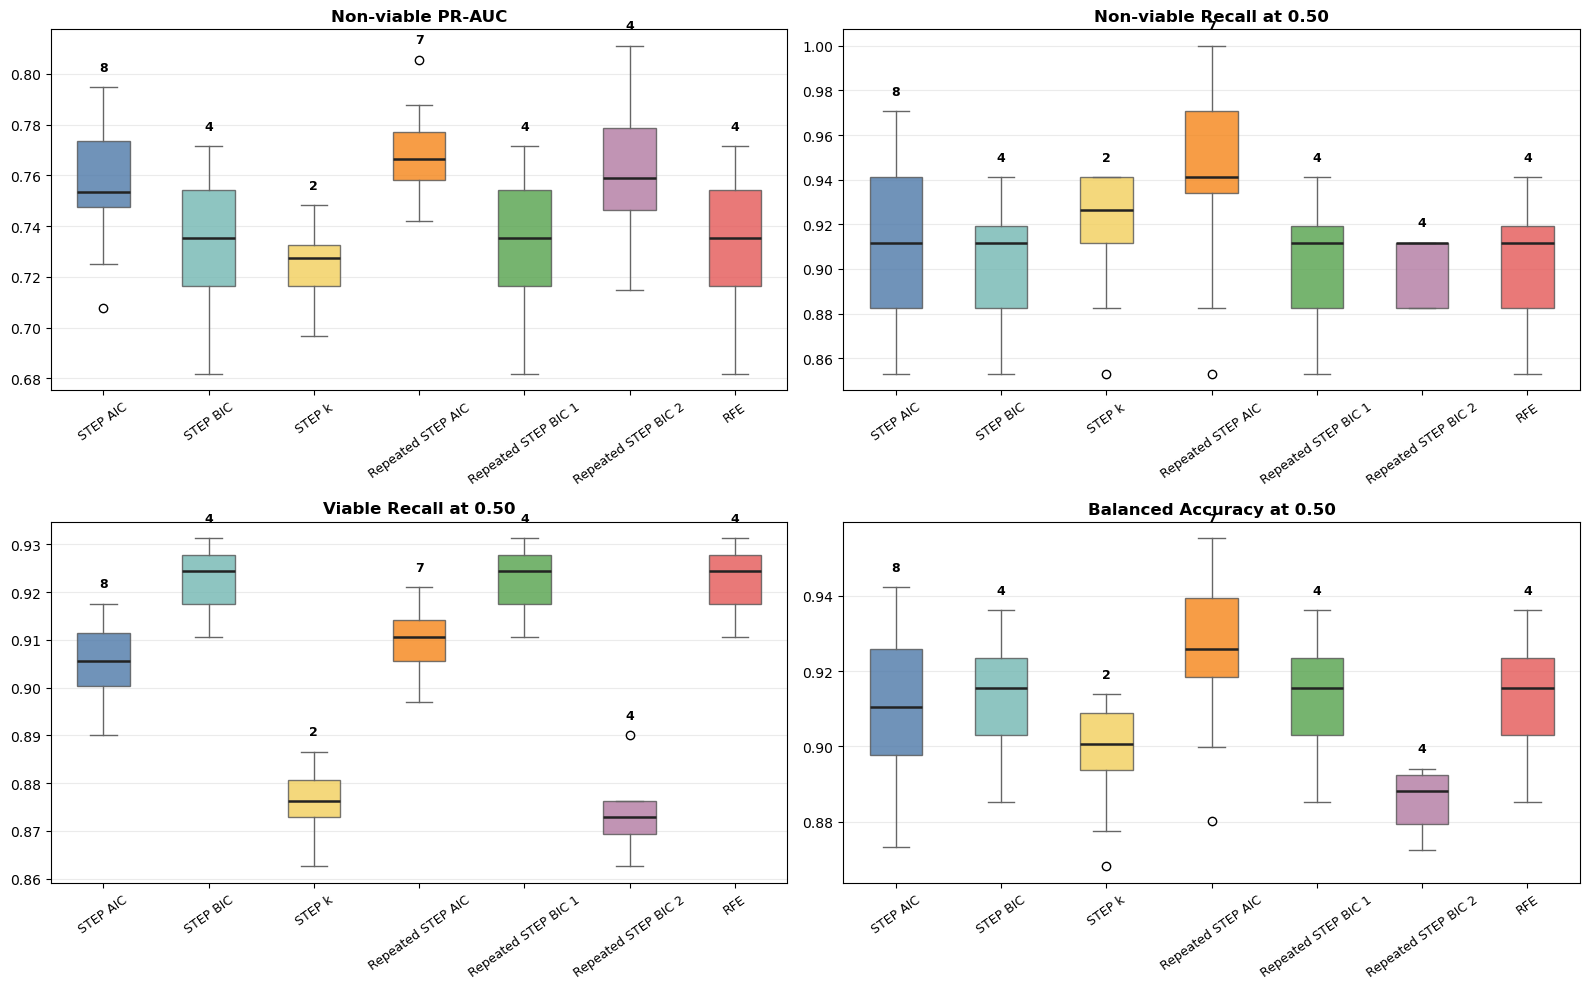

Selected automatic method: Repeated STEP BIC 2
Selected original predictors: 4
Selected ridge estimation C: 1
Total execution time: 25.8 seconds


Method,Variable-set stable,Distinct variable sets,Selected variables,Minimum criterion,Maximum criterion,Criterion range,Relative criterion range
STEP AIC,True,1,LTC + LTV + Provincia + coste_total_proyecto + equity_promotor_pct + indice_coste_base + riesgo_legal_titulo + tipo_activo,48.000944,50.320547,2.319603,4.753993%
STEP BIC,True,1,LTC + LTV + equity_promotor_pct + riesgo_legal_titulo,114.034283,114.034286,0.000003,0.000003%
STEP k,True,1,LTV + riesgo_legal_titulo,151.397717,151.397719,0.000002,0.000001%
Repeated STEP AIC,True,1,LTC + LTV + Provincia + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo + tipo_activo,46.287821,62.366444,16.078623,29.770264%
Repeated STEP BIC 1,True,1,LTC + LTV + equity_promotor_pct + riesgo_legal_titulo,114.034283,114.034286,0.000003,0.000003%
Repeated STEP BIC 2,True,1,LTV + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo,115.927319,115.927322,0.000003,0.000003%


Method,Selection C,Upper comparison C,Variable-set stable,Variables at selection C,Variables at upper C
STEP AIC,1e+06,1e+08,True,LTC + LTV + Provincia + coste_total_proyecto + equity_promotor_pct + indice_coste_base + riesgo_legal_titulo + tipo_activo,LTC + LTV + Provincia + coste_total_proyecto + equity_promotor_pct + indice_coste_base + riesgo_legal_titulo + tipo_activo
STEP BIC,1e+06,1e+08,True,LTC + LTV + equity_promotor_pct + riesgo_legal_titulo,LTC + LTV + equity_promotor_pct + riesgo_legal_titulo
STEP k,1e+06,1e+08,True,LTV + riesgo_legal_titulo,LTV + riesgo_legal_titulo
Repeated STEP AIC,1e+06,1e+08,True,LTC + LTV + Provincia + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo + tipo_activo,LTC + LTV + Provincia + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo + tipo_activo
Repeated STEP BIC 1,1e+06,1e+08,True,LTC + LTV + equity_promotor_pct + riesgo_legal_titulo,LTC + LTV + equity_promotor_pct + riesgo_legal_titulo
Repeated STEP BIC 2,1e+06,1e+08,True,LTV + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo,LTV + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo


All information-criterion variable sets are stable between C=1e6 and C=1e8. STEP AIC selects one additional variable at C=1e4.


Method,Selected variables,Original predictors,Non-viable PR-AUC,Viable PR-AUC,ROC-AUC,Balanced accuracy at 0.50,Macro F1 at 0.50,Accuracy at 0.50,Selected
STEP AIC,LTV + riesgo_legal_titulo + equity_promotor_pct + LTC + coste_total_proyecto + tipo_activo + Provincia + indice_coste_base,8,0.756 ± 0.021,0.996 ± 0.001,0.969 ± 0.005,0.911 ± 0.017,0.810 ± 0.015,0.907 ± 0.008,No
STEP BIC,LTV + riesgo_legal_titulo + equity_promotor_pct + LTC,4,0.734 ± 0.024,0.996 ± 0.001,0.966 ± 0.005,0.913 ± 0.015,0.830 ± 0.013,0.921 ± 0.007,No
STEP k,LTV + riesgo_legal_titulo,2,0.726 ± 0.013,0.994 ± 0.000,0.954 ± 0.003,0.899 ± 0.012,0.775 ± 0.008,0.882 ± 0.005,No
Repeated STEP AIC,LTC + LTV + Provincia + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo + tipo_activo,7,0.768 ± 0.016,0.997 ± 0.000,0.972 ± 0.003,0.926 ± 0.018,0.821 ± 0.013,0.912 ± 0.007,No
Repeated STEP BIC 1,LTC + LTV + equity_promotor_pct + riesgo_legal_titulo,4,0.734 ± 0.024,0.996 ± 0.001,0.966 ± 0.005,0.913 ± 0.015,0.830 ± 0.013,0.921 ± 0.007,No
Repeated STEP BIC 2,LTV + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo,4,0.761 ± 0.023,0.995 ± 0.001,0.958 ± 0.005,0.886 ± 0.007,0.764 ± 0.007,0.875 ± 0.005,Yes
RFE,equity_promotor_pct + riesgo_legal_titulo + LTV + LTC,4,0.734 ± 0.024,0.996 ± 0.001,0.966 ± 0.005,0.913 ± 0.015,0.830 ± 0.013,0.921 ± 0.007,No


Method,Non-viable precision,Non-viable recall,Non-viable F1,Viable precision,Viable recall,Viable F1,Selected
STEP AIC,0.533 ± 0.024,0.916 ± 0.031,0.674 ± 0.026,0.989 ± 0.004,0.906 ± 0.007,0.946 ± 0.005,No
STEP BIC,0.579 ± 0.022,0.903 ± 0.029,0.705 ± 0.022,0.988 ± 0.004,0.923 ± 0.006,0.954 ± 0.004,No
STEP k,0.467 ± 0.012,0.921 ± 0.025,0.619 ± 0.014,0.990 ± 0.003,0.877 ± 0.006,0.930 ± 0.003,No
Repeated STEP AIC,0.548 ± 0.021,0.943 ± 0.035,0.693 ± 0.023,0.993 ± 0.004,0.909 ± 0.007,0.949 ± 0.004,No
Repeated STEP BIC 1,0.579 ± 0.022,0.903 ± 0.029,0.705 ± 0.022,0.988 ± 0.004,0.923 ± 0.006,0.954 ± 0.004,No
Repeated STEP BIC 2,0.452 ± 0.011,0.900 ± 0.015,0.601 ± 0.010,0.987 ± 0.002,0.872 ± 0.006,0.926 ± 0.003,Yes
RFE,0.579 ± 0.022,0.903 ± 0.029,0.705 ± 0.022,0.988 ± 0.004,0.923 ± 0.006,0.954 ± 0.004,No


Original variable,STEP AIC,STEP BIC,STEP k,Repeated STEP AIC,Repeated STEP BIC 1,Repeated STEP BIC 2 (selected),RFE,Methods selecting variable
LTV,Yes,Yes,Yes,Yes,Yes,Yes,Yes,7
riesgo_legal_titulo,Yes,Yes,Yes,Yes,Yes,Yes,Yes,7
equity_promotor_pct,Yes,Yes,,Yes,Yes,Yes,Yes,6
LTC,Yes,Yes,,Yes,Yes,,Yes,5
Provincia,Yes,,,Yes,,,,2
documentacion_completa,,,,Yes,,Yes,,2
tipo_activo,Yes,,,Yes,,,,2
coste_total_proyecto,Yes,,,,,,,1
indice_coste_base,Yes,,,,,,,1
TOTAL SELECTED,8,4,2,7,4,4,4,


Saved: tabla_presencia_variables_origination.html
Selected origination method: Repeated STEP BIC 2
Selected variables: ['LTV', 'documentacion_completa', 'equity_promotor_pct', 'riesgo_legal_titulo']
Selected ridge estimation C: 1


In [89]:
# ============================================================
# BLOCK 77: Run automatic variable selection on origination_view1
# Purpose:
#   - Assess near-unpenalized IC sensitivity
#   - Confirm the upper-range plateau from C=1e6 to C=1e8
#   - Compare automatic reduced logistic specifications
#   - Display overall and class-specific CV results
#   - Store averaged OOF probabilities for threshold tuning
# DataFrames created:
#   - origination_ic_sensitivity_detail
#   - origination_ic_sensitivity_summary
#   - origination_upper_range_stability
#   - union1_origination
#   - origination_selection_comparison
#   - origination_selected_oof_predictions
# Objects created:
#   - result_origination
#   - modelos_origination
#   - origination_selected_method
#   - origination_selected_method_key
#   - origination_selected_variables
#   - origination_selected_C
# Files created:
#   - tabla_presencia_variables_origination.html
# ============================================================

origination_reference_categories = (
    origination_view1_preprocessing[
        "reference_categories"
    ]
)


# 1. Obtain the sensitivity result once
if (
    "origination_ic_sensitivity_check"
    in globals()
):
    print(
        "Using the previously computed "
        "origination sensitivity result."
    )

    origination_ic_sensitivity_raw = (
        origination_ic_sensitivity_check
    )

else:
    origination_ic_sensitivity_raw = (
        information_criterion_sensitivity(
            X=origination_view1.drop(
                columns=[target_col]
            ),
            y=origination_view1[
                target_col
            ].astype(int),
            reference_categories=(
                origination_reference_categories
            ),
            C_values=(1e4, 1e6, 1e8),
            k_general=14,
            n_repeats_step=41,
            train_share_step=0.80,
            random_state=GLOBAL_SEED
        )
    )


# 2. Run automatic selection without repeating sensitivity
result_origination = comparar_modelos_binaria(
    view1=origination_view1,
    target_col=target_col,
    reference_categories=(
        origination_reference_categories
    ),
    selection_C=1e6,
    sensitivity_C_values=(
        1e4,
        1e6,
        1e8
    ),
    precomputed_ic_sensitivity=(
        origination_ic_sensitivity_raw
    ),
    max_rfe_variables=None,
    k_general=14,
    n_repeats_step=41,
    train_share_step=0.80,
    C_values=(
        0.01,
        0.10,
        1.00,
        10.00,
        100.00
    ),
    pr_auc_tolerance=0.01,
    grupos=4,
    semilla=GLOBAL_SEED,
    repe=20,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)


# 3. Store the sensitivity evidence
origination_ic_sensitivity = (
    result_origination[
        "ic_sensitivity"
    ]
)

origination_ic_sensitivity_detail = (
    origination_ic_sensitivity[
        "detail"
    ]
)

origination_ic_sensitivity_summary = (
    origination_ic_sensitivity[
        "summary"
    ]
)

origination_upper_range_stability = (
    result_origination[
        "upper_range_stability"
    ]
)


# 4. Display the full-range sensitivity summary
display(
    origination_ic_sensitivity_summary.style
    .hide(axis="index")
    .format({
        "Minimum criterion": "{:.6f}",
        "Maximum criterion": "{:.6f}",
        "Criterion range": "{:.6f}",
        "Relative criterion range": "{:.6%}"
    })
    .set_caption(
        "Origination Information-Criterion "
        "Stability Summary"
    )
    .set_table_styles(
        reporting_table_styles
    )
)


# 5. Display methods that changed across the full range
unstable_origination_methods = (
    origination_ic_sensitivity_summary.loc[
        ~origination_ic_sensitivity_summary[
            "Variable-set stable"
        ],
        "Method"
    ].tolist()
)

if unstable_origination_methods:
    unstable_detail = (
        origination_ic_sensitivity_detail.loc[
            origination_ic_sensitivity_detail[
                "Method"
            ].isin(
                unstable_origination_methods
            )
        ]
        .sort_values([
            "Method",
            "Near-unpenalized C"
        ])
        .copy()
    )

    unstable_detail[
        "Near-unpenalized C"
    ] = unstable_detail[
        "Near-unpenalized C"
    ].map(
        lambda value: f"{value:.0e}"
    )

    unstable_detail[
        "Criterion value"
    ] = unstable_detail[
        "Criterion value"
    ].map(
        lambda value: f"{value:.6f}"
    )

    unstable_detail[
        "Repeated-selection share"
    ] = unstable_detail[
        "Repeated-selection share"
    ].map(
        lambda value: (
            ""
            if pd.isna(value)
            else f"{value:.3f}"
        )
    )

    display(
        unstable_detail.style
        .hide(axis="index")
        .set_caption(
            "Origination Methods That Change "
            "Across the Full Sensitivity Range"
        )
        .set_table_styles(
            reporting_table_styles
        )
    )


# 6. Display the accepted upper-range plateau
display(
    origination_upper_range_stability.style
    .hide(axis="index")
    .format({
        "Selection C": "{:.0e}",
        "Upper comparison C": "{:.0e}"
    })
    .set_caption(
        "Origination Upper-Range "
        "Information-Criterion Stability"
    )
    .set_table_styles(
        reporting_table_styles
    )
)

print(
    "All information-criterion variable sets are "
    "stable between C=1e6 and C=1e8. "
    "STEP AIC selects one additional variable "
    "at C=1e4."
)


# 7. Store the finalized origination results
union1_origination = (
    result_origination[
        "medias"
    ]
)

origination_selection_comparison = (
    result_origination[
        "comparison_summary"
    ]
)

modelos_origination = (
    result_origination[
        "listconti"
    ]
)

origination_selected_method = (
    result_origination[
        "selected_method"
    ]
)

origination_selected_method_key = (
    result_origination[
        "selected_method_key"
    ]
)

origination_selected_variables = (
    result_origination[
        "selected_variables"
    ]
)

origination_selected_C = (
    result_origination[
        "selected_C"
    ]
)

origination_selected_oof_predictions = (
    result_origination[
        "selected_oof_predictions"
    ]
)


# 8. Create the finalized reporting tables
tabla_modelos_origination = (
    crear_tabla_modelos_binaria(
        union1=union1_origination,
        modelos=modelos_origination,
        selected_model=(
            origination_selected_method
        )
    )
)

tabla_clases_origination = (
    crear_tabla_clases_binaria(
        union1=union1_origination,
        selected_model=(
            origination_selected_method
        )
    )
)

tabla_presencia_origination = (
    crear_tabla_presencia(
        union1=union1_origination,
        modelos=modelos_origination,
        selected_model=(
            origination_selected_method
        )
    )
)

display(
    tabla_modelos_origination
)

display(
    tabla_clases_origination
)

display(
    tabla_presencia_origination
)


# 9. Save the variable-presence table
origination_presence_file = (
    "tabla_presencia_variables_origination.html"
)

tabla_presencia_origination.to_html(
    origination_presence_file
)

print(
    f"Saved: "
    f"{origination_presence_file}"
)

print(
    f"Selected origination method: "
    f"{origination_selected_method}"
)

print(
    f"Selected variables: "
    f"{origination_selected_variables}"
)

print(
    f"Selected ridge estimation C: "
    f"{origination_selected_C:g}"
)

The origination model selects Repeated STEP BIC 2, cutting the predictor set down to just four variables: LTV, documentacion_completa, equity_promotor_pct and riesgo_legal_titulo. It reaches a mean Non-viable PR-AUC of 0.761 ± 0.023, ROC-AUC of 0.958 ± 0.005 and balanced accuracy of 0.886 ± 0.007, identifying 90.0% ± 1.5% of Non-viable operations at the 0.50 threshold with 45.2% ± 1.1% precision (F1 = 60.1% ± 1.0%). Ridge estimation with C = 1 keeps the specification stable. From a Business Model perspective, this is a simpler and easier rule to enforce: leverage, promoter equity, documentation completeness and legal-title risk alone are enough to flag risky operations at underwriting.

Using previously computed information-criterion sensitivity results.
Full-range sensitivity is not exact, but all selected variable sets are stable between C=1e+06 and C=1e+08.
Running grouped RF-RFE with Non-viable PR-AUC...
Tuning ridge estimation C for STEP AIC...
Tuning ridge estimation C for STEP BIC...
Tuning ridge estimation C for STEP k...
Tuning ridge estimation C for Repeated STEP AIC...
Tuning ridge estimation C for Repeated STEP BIC 1...
Tuning ridge estimation C for Repeated STEP BIC 2...
Tuning ridge estimation C for RFE...
Cross-validating STEP AIC...
Cross-validating STEP BIC...
Cross-validating STEP k...
Cross-validating Repeated STEP AIC...
Cross-validating Repeated STEP BIC 1...
Cross-validating Repeated STEP BIC 2...
Cross-validating RFE...


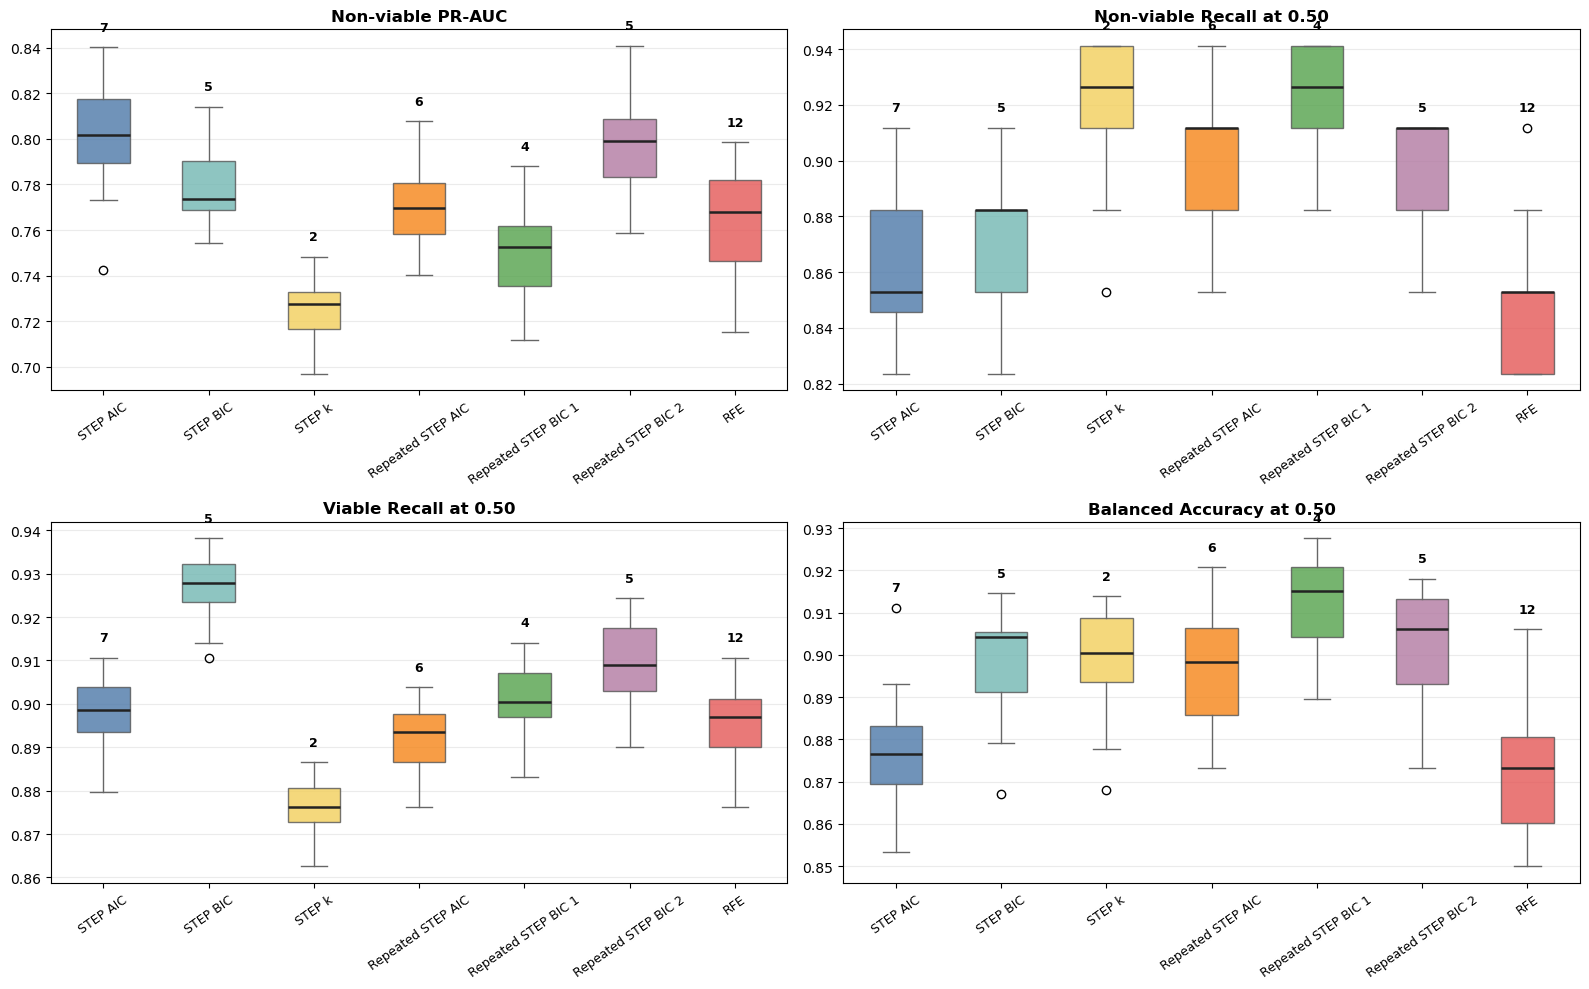

Selected automatic method: Repeated STEP BIC 2
Selected original predictors: 5
Selected ridge estimation C: 10
Total execution time: 28.0 seconds


Method,Variable-set stable,Distinct variable sets,Selected variables,Minimum criterion,Maximum criterion,Criterion range,Relative criterion range
STEP AIC,False,2,See sensitivity detail,46.006858,49.395578,3.388720,7.171571%
STEP BIC,True,1,LTC + LTV + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo,111.471300,111.471304,0.000004,0.000003%
STEP k,True,1,LTV + riesgo_legal_titulo,151.397717,151.397719,0.000002,0.000001%
Repeated STEP AIC,False,3,See sensitivity detail,54.288529,82.462784,28.174255,38.733596%
Repeated STEP BIC 1,True,1,LTC + LTV + coste_total_proyecto + riesgo_legal_titulo,115.778119,115.778123,0.000005,0.000004%
Repeated STEP BIC 2,True,1,LTV + documentacion_completa + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo,112.576452,112.576457,0.000005,0.000004%


Method,Near-unpenalized C,Selected variables,Original predictors,Criterion penalty k,Criterion value,Repeated-selection share
Repeated STEP AIC,1e+04,LTV + Provincia + documentacion_completa + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo,7,2.000000,54.288529,0.122
Repeated STEP AIC,1e+06,LTV + Provincia + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo + tipo_activo,6,2.000000,82.462784,0.073
Repeated STEP AIC,1e+08,LTV + Provincia + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo,6,2.000000,81.464327,0.098
STEP AIC,1e+04,LTC + LTV + Provincia + coste_total_proyecto + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo,8,2.000000,49.395578,
STEP AIC,1e+06,LTV + Provincia + coste_total_proyecto + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo,7,2.000000,46.353947,
STEP AIC,1e+08,LTV + Provincia + coste_total_proyecto + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo,7,2.000000,46.006858,


Method,Selection C,Upper comparison C,Variable-set stable,Variables at selection C,Variables at upper C
STEP AIC,1e+06,1e+08,True,LTV + Provincia + coste_total_proyecto + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo,LTV + Provincia + coste_total_proyecto + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo
STEP BIC,1e+06,1e+08,True,LTC + LTV + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo,LTC + LTV + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo
STEP k,1e+06,1e+08,True,LTV + riesgo_legal_titulo,LTV + riesgo_legal_titulo
Repeated STEP AIC,1e+06,1e+08,False,LTV + Provincia + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo + tipo_activo,LTV + Provincia + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo + tipo_activo
Repeated STEP BIC 1,1e+06,1e+08,True,LTC + LTV + coste_total_proyecto + riesgo_legal_titulo,LTC + LTV + coste_total_proyecto + riesgo_legal_titulo
Repeated STEP BIC 2,1e+06,1e+08,True,LTV + documentacion_completa + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo,LTV + documentacion_completa + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo


All information-criterion variable sets are stable between C=1e6 and C=1e8.
Methods changing at the lower sensitivity value: ['STEP AIC', 'Repeated STEP AIC']


Method,Selected variables,Original predictors,Non-viable PR-AUC,Viable PR-AUC,ROC-AUC,Balanced accuracy at 0.50,Macro F1 at 0.50,Accuracy at 0.50,Selected
STEP AIC,LTV + riesgo_legal_titulo + equity_promotor_pct + retraso_obra_meses + tipo_activo + Provincia + coste_total_proyecto,7,0.801 ± 0.024,0.995 ± 0.001,0.959 ± 0.005,0.877 ± 0.015,0.782 ± 0.015,0.893 ± 0.009,No
STEP BIC,LTV + riesgo_legal_titulo + equity_promotor_pct + retraso_obra_meses + LTC,5,0.780 ± 0.016,0.997 ± 0.000,0.971 ± 0.003,0.899 ± 0.012,0.826 ± 0.013,0.921 ± 0.008,No
STEP k,LTV + riesgo_legal_titulo,2,0.726 ± 0.013,0.994 ± 0.000,0.954 ± 0.003,0.899 ± 0.012,0.775 ± 0.008,0.882 ± 0.005,No
Repeated STEP AIC,LTV + Provincia + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo + tipo_activo,6,0.771 ± 0.019,0.996 ± 0.001,0.962 ± 0.004,0.896 ± 0.014,0.789 ± 0.012,0.894 ± 0.007,No
Repeated STEP BIC 1,LTC + LTV + coste_total_proyecto + riesgo_legal_titulo,4,0.751 ± 0.020,0.994 ± 0.001,0.959 ± 0.004,0.912 ± 0.012,0.805 ± 0.013,0.903 ± 0.008,No
Repeated STEP BIC 2,LTV + documentacion_completa + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo,5,0.798 ± 0.020,0.996 ± 0.001,0.964 ± 0.004,0.903 ± 0.013,0.809 ± 0.017,0.908 ± 0.010,Yes
RFE,Provincia + Visados Viviendas + Volatilidad 4A Viviendas + promotor_experiencia_anios + equity_promotor_pct + deuda_existente_promotor_pct + riesgo_legal_titulo + LTV + LTC + porcentaje_preventas + retraso_obra_meses + stop_desembolsos,12,0.764 ± 0.024,0.995 ± 0.001,0.960 ± 0.006,0.873 ± 0.014,0.778 ± 0.014,0.891 ± 0.009,No


Method,Non-viable precision,Non-viable recall,Non-viable F1,Viable precision,Viable recall,Viable F1,Selected
STEP AIC,0.495 ± 0.024,0.856 ± 0.025,0.627 ± 0.024,0.982 ± 0.003,0.898 ± 0.008,0.938 ± 0.005,No
STEP BIC,0.581 ± 0.026,0.871 ± 0.022,0.697 ± 0.022,0.984 ± 0.003,0.926 ± 0.008,0.954 ± 0.004,No
STEP k,0.467 ± 0.012,0.921 ± 0.025,0.619 ± 0.014,0.990 ± 0.003,0.877 ± 0.006,0.930 ± 0.003,No
Repeated STEP AIC,0.496 ± 0.019,0.900 ± 0.026,0.639 ± 0.020,0.987 ± 0.003,0.893 ± 0.007,0.938 ± 0.005,No
Repeated STEP BIC 1,0.522 ± 0.022,0.924 ± 0.020,0.667 ± 0.021,0.990 ± 0.003,0.901 ± 0.008,0.943 ± 0.005,No
Repeated STEP BIC 2,0.537 ± 0.031,0.896 ± 0.020,0.671 ± 0.027,0.987 ± 0.003,0.909 ± 0.010,0.947 ± 0.006,Yes
RFE,0.489 ± 0.024,0.850 ± 0.025,0.620 ± 0.024,0.981 ± 0.003,0.896 ± 0.009,0.936 ± 0.006,No


Original variable,STEP AIC,STEP BIC,STEP k,Repeated STEP AIC,Repeated STEP BIC 1,Repeated STEP BIC 2 (selected),RFE,Methods selecting variable
LTV,Yes,Yes,Yes,Yes,Yes,Yes,Yes,7
riesgo_legal_titulo,Yes,Yes,Yes,Yes,Yes,Yes,Yes,7
equity_promotor_pct,Yes,Yes,,Yes,,Yes,Yes,5
retraso_obra_meses,Yes,Yes,,,,Yes,Yes,4
LTC,,Yes,,,Yes,,Yes,3
Provincia,Yes,,,Yes,,,Yes,3
coste_total_proyecto,Yes,,,,Yes,,,2
documentacion_completa,,,,Yes,,Yes,,2
tipo_activo,Yes,,,Yes,,,,2
Visados Viviendas,,,,,,,Yes,1


Saved: tabla_presencia_variables_monitoring.html
Selected monitoring method: Repeated STEP BIC 2
Selected variables: ['LTV', 'documentacion_completa', 'equity_promotor_pct', 'retraso_obra_meses', 'riesgo_legal_titulo']
Selected ridge estimation C: 10


In [90]:
# ============================================================
# BLOCK 78: Run automatic variable selection on monitoring_view1
# Purpose:
#   - Assess near-unpenalized IC sensitivity
#   - Confirm the upper-range plateau from C=1e6 to C=1e8
#   - Compare automatic reduced logistic specifications
#   - Display overall and class-specific CV results
#   - Store averaged OOF probabilities for threshold tuning
# DataFrames created:
#   - monitoring_ic_sensitivity_detail
#   - monitoring_ic_sensitivity_summary
#   - monitoring_upper_range_stability
#   - union1_monitoring
#   - monitoring_selection_comparison
#   - monitoring_selected_oof_predictions
# Objects created:
#   - result_monitoring
#   - modelos_monitoring
#   - monitoring_selected_method
#   - monitoring_selected_method_key
#   - monitoring_selected_variables
#   - monitoring_selected_C
# Files created:
#   - tabla_presencia_variables_monitoring.html
# ============================================================

monitoring_reference_categories = (
    monitoring_view1_preprocessing[
        "reference_categories"
    ]
)


# 1. Obtain the sensitivity result once
if (
    "monitoring_ic_sensitivity_check"
    in globals()
):
    print(
        "Using the previously computed "
        "monitoring sensitivity result."
    )

else:
    monitoring_ic_sensitivity_check = (
        information_criterion_sensitivity(
            X=monitoring_view1.drop(
                columns=[target_col]
            ),
            y=monitoring_view1[
                target_col
            ].astype(int),
            reference_categories=(
                monitoring_reference_categories
            ),
            C_values=(
                1e4,
                1e6,
                1e8
            ),
            k_general=14,
            n_repeats_step=41,
            train_share_step=0.80,
            random_state=GLOBAL_SEED
        )
    )

monitoring_ic_sensitivity_raw = (
    monitoring_ic_sensitivity_check
)


# 2. Run automatic selection without repeating sensitivity
result_monitoring = comparar_modelos_binaria(
    view1=monitoring_view1,
    target_col=target_col,
    reference_categories=(
        monitoring_reference_categories
    ),
    selection_C=1e6,
    sensitivity_C_values=(
        1e4,
        1e6,
        1e8
    ),
    precomputed_ic_sensitivity=(
        monitoring_ic_sensitivity_raw
    ),
    max_rfe_variables=None,
    k_general=14,
    n_repeats_step=41,
    train_share_step=0.80,
    C_values=(
        0.01,
        0.10,
        1.00,
        10.00,
        100.00
    ),
    pr_auc_tolerance=0.01,
    grupos=4,
    semilla=GLOBAL_SEED,
    repe=20,
    random_state=GLOBAL_SEED,
    n_jobs=-1
)


# 3. Store the sensitivity evidence
monitoring_ic_sensitivity = (
    result_monitoring[
        "ic_sensitivity"
    ]
)

monitoring_ic_sensitivity_detail = (
    monitoring_ic_sensitivity[
        "detail"
    ]
)

monitoring_ic_sensitivity_summary = (
    monitoring_ic_sensitivity[
        "summary"
    ]
)

monitoring_upper_range_stability = (
    result_monitoring[
        "upper_range_stability"
    ]
)


# 4. Display the full-range sensitivity summary
display(
    monitoring_ic_sensitivity_summary.style
    .hide(axis="index")
    .format({
        "Minimum criterion": "{:.6f}",
        "Maximum criterion": "{:.6f}",
        "Criterion range": "{:.6f}",
        "Relative criterion range": "{:.6%}"
    })
    .set_caption(
        "Monitoring Information-Criterion "
        "Stability Summary"
    )
    .set_table_styles(
        reporting_table_styles
    )
)


# 5. Display methods that changed across the full range
unstable_monitoring_methods = (
    monitoring_ic_sensitivity_summary.loc[
        ~monitoring_ic_sensitivity_summary[
            "Variable-set stable"
        ],
        "Method"
    ].tolist()
)

if unstable_monitoring_methods:
    unstable_monitoring_detail = (
        monitoring_ic_sensitivity_detail.loc[
            monitoring_ic_sensitivity_detail[
                "Method"
            ].isin(
                unstable_monitoring_methods
            )
        ]
        .sort_values([
            "Method",
            "Near-unpenalized C"
        ])
        .copy()
    )

    unstable_monitoring_detail[
        "Near-unpenalized C"
    ] = unstable_monitoring_detail[
        "Near-unpenalized C"
    ].map(
        lambda value: f"{value:.0e}"
    )

    unstable_monitoring_detail[
        "Criterion value"
    ] = unstable_monitoring_detail[
        "Criterion value"
    ].map(
        lambda value: f"{value:.6f}"
    )

    unstable_monitoring_detail[
        "Repeated-selection share"
    ] = unstable_monitoring_detail[
        "Repeated-selection share"
    ].map(
        lambda value: (
            ""
            if pd.isna(value)
            else f"{value:.3f}"
        )
    )

    display(
        unstable_monitoring_detail.style
        .hide(axis="index")
        .set_caption(
            "Monitoring Methods That Change "
            "Across the Full Sensitivity Range"
        )
        .set_table_styles(
            reporting_table_styles
        )
    )


# 6. Display the accepted upper-range plateau
display(
    monitoring_upper_range_stability.style
    .hide(axis="index")
    .format({
        "Selection C": "{:.0e}",
        "Upper comparison C": "{:.0e}"
    })
    .set_caption(
        "Monitoring Upper-Range "
        "Information-Criterion Stability"
    )
    .set_table_styles(
        reporting_table_styles
    )
)

print(
    "All information-criterion variable sets are "
    "stable between C=1e6 and C=1e8."
)

if unstable_monitoring_methods:
    print(
        "Methods changing at the lower sensitivity "
        f"value: {unstable_monitoring_methods}"
    )

else:
    print(
        "All information-criterion variable sets are "
        "also stable across the complete sensitivity range."
    )


# 7. Store the finalized monitoring results
union1_monitoring = (
    result_monitoring[
        "medias"
    ]
)

monitoring_selection_comparison = (
    result_monitoring[
        "comparison_summary"
    ]
)

modelos_monitoring = (
    result_monitoring[
        "listconti"
    ]
)

monitoring_selected_method = (
    result_monitoring[
        "selected_method"
    ]
)

monitoring_selected_method_key = (
    result_monitoring[
        "selected_method_key"
    ]
)

monitoring_selected_variables = (
    result_monitoring[
        "selected_variables"
    ]
)

monitoring_selected_C = (
    result_monitoring[
        "selected_C"
    ]
)

monitoring_selected_oof_predictions = (
    result_monitoring[
        "selected_oof_predictions"
    ]
)


# 8. Create the finalized reporting tables
tabla_modelos_monitoring = (
    crear_tabla_modelos_binaria(
        union1=union1_monitoring,
        modelos=modelos_monitoring,
        selected_model=(
            monitoring_selected_method
        )
    )
)

tabla_clases_monitoring = (
    crear_tabla_clases_binaria(
        union1=union1_monitoring,
        selected_model=(
            monitoring_selected_method
        )
    )
)

tabla_presencia_monitoring = (
    crear_tabla_presencia(
        union1=union1_monitoring,
        modelos=modelos_monitoring,
        selected_model=(
            monitoring_selected_method
        )
    )
)

display(
    tabla_modelos_monitoring
)

display(
    tabla_clases_monitoring
)

display(
    tabla_presencia_monitoring
)


# 9. Save the variable-presence table
monitoring_presence_file = (
    "tabla_presencia_variables_monitoring.html"
)

tabla_presencia_monitoring.to_html(
    monitoring_presence_file
)

print(
    f"Saved: "
    f"{monitoring_presence_file}"
)

print(
    f"Selected monitoring method: "
    f"{monitoring_selected_method}"
)

print(
    f"Selected variables: "
    f"{monitoring_selected_variables}"
)

print(
    f"Selected ridge estimation C: "
    f"{monitoring_selected_C:g}"
)

The monitoring model also converges on Repeated STEP BIC 2, now with five predictors: LTV, documentacion_completa, equity_promotor_pct, retraso_obra_meses and riesgo_legal_titulo. It reaches a mean Non-viable PR-AUC of 0.798 ± 0.020 — the strongest of any origination or monitoring specification — with ROC-AUC of 0.964 ± 0.004 and balanced accuracy of 0.903 ± 0.013. At the 0.50 threshold it identifies 89.6% ± 2.0% of Non-viable operations, with 53.7% ± 3.1% precision and F1 = 67.1% ± 2.7%, using ridge estimation with C = 10. Evidencia_hito and promotor_proyectos_previos have dropped out of the selected set; documentacion_completa now carries the incremental monitoring signal instead. From a Business Model perspective, this still supports linking further drawdowns to verifiable conditions, but the operational check shifts from confirming on-site milestones to confirming documentation is complete, alongside watching construction delay and leverage.

In [91]:
# ============================================================
# BLOCK 79: Summary of selected ridge logistic models
# Purpose:
#   - Consolidate the selected specification for each view
#   - Record the selected predictors and ridge C
#   - Summarize the principal repeated-CV metrics
# DataFrame created:
#   - selected_logistic_summary
# Files created:
#   - None
# ============================================================

selected_model_sources = {
    "Origination view": {
        "results": union1_origination,
        "method": origination_selected_method,
        "variables": origination_selected_variables,
        "C": origination_selected_C
    },
    "Monitoring view": {
        "results": union1_monitoring,
        "method": monitoring_selected_method,
        "variables": monitoring_selected_variables,
        "C": monitoring_selected_C
    }
}

metric_map = {
    "Non-viable PR-AUC": "pr_auc",
    "Non-viable recall (0.50)": "recall_non_viable",
    "Balanced accuracy (0.50)": "balanced_accuracy",
    "Macro F1 (0.50)": "macro_f1"
}

summary_rows = []

for view_name, source in selected_model_sources.items():
    selected_results = source["results"].loc[
        source["results"]["modelo"].astype(str)
        == source["method"]
    ].copy()

    assert not selected_results.empty, (
        f"No repeated-CV results were found for "
        f"{view_name}: {source['method']}."
    )

    row = {
        "View": view_name,
        "Selected method": source["method"],
        "Ridge C": float(source["C"]),
        "Predictors": len(source["variables"]),
        "Selected variables": " + ".join(
            source["variables"]
        )
    }

    for output_column, metric_column in metric_map.items():
        metric_mean = selected_results[
            metric_column
        ].mean()

        metric_std = selected_results[
            metric_column
        ].std(ddof=1)

        row[output_column] = (
            f"{metric_mean:.3f} ± {metric_std:.3f}"
        )

    summary_rows.append(row)

selected_logistic_summary = pd.DataFrame(
    summary_rows
)


def selected_model_row_style(row):
    background = (
        "#F0E6F5"
        if row["View"] == "Origination view"
        else "#F8E8EC"
    )

    return [
        f"background-color: {background}"
        for _ in row
    ]


display(
    selected_logistic_summary.style
    .hide(axis="index")
    .format({
        "Ridge C": "{:g}"
    })
    .apply(
        selected_model_row_style,
        axis=1
    )
    .set_caption(
        "Selected Ridge Logistic Models: "
        "Repeated Training-CV Summary"
    )
    .set_table_styles(
        reporting_table_styles
    )
)

View,Selected method,Ridge C,Predictors,Selected variables,Non-viable PR-AUC,Non-viable recall (0.50),Balanced accuracy (0.50),Macro F1 (0.50)
Origination view,Repeated STEP BIC 2,1,4,LTV + documentacion_completa + equity_promotor_pct + riesgo_legal_titulo,0.761 ± 0.023,0.900 ± 0.015,0.886 ± 0.007,0.764 ± 0.007
Monitoring view,Repeated STEP BIC 2,10,5,LTV + documentacion_completa + equity_promotor_pct + retraso_obra_meses + riesgo_legal_titulo,0.798 ± 0.020,0.896 ± 0.020,0.903 ± 0.013,0.809 ± 0.017


View,Decision rule,Threshold,Non-viable precision,Non-viable recall,Non-viable F1,Balanced accuracy,Macro F1,Accuracy,Non-viable correctly identified,Non-viable missed,Viable flagged for review
Origination view,Reference threshold,0.5000,0.463,0.912,0.614,0.894,0.771,0.880,31,3,36
Origination view,OOF-selected threshold,0.7164,0.644,0.853,0.734,0.899,0.849,0.935,29,5,16
Monitoring view,Reference threshold,0.5000,0.536,0.882,0.667,0.897,0.807,0.908,30,4,26
Monitoring view,OOF-selected threshold,0.7478,0.744,0.853,0.795,0.909,0.884,0.954,29,5,10


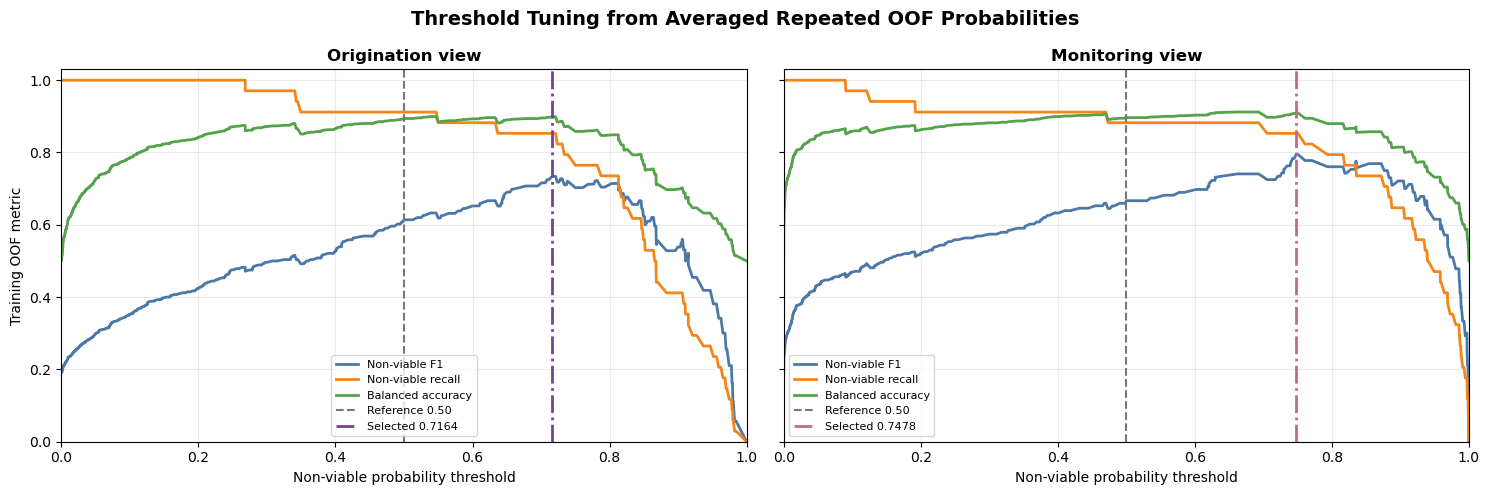

Origination selected Non-viable threshold: 0.7164
Monitoring selected Non-viable threshold: 0.7478


In [92]:
# ============================================================
# BLOCK 80: Tune selected logistic classification thresholds
# Purpose:
#   - Keep the selected variables and ridge C fixed
#   - Tune only the Non-viable probability threshold
#   - Use averaged repeated OOF training probabilities
#   - Maximize Non-viable F1
#   - Preserve 0.50 as the reference threshold
# DataFrames created:
#   - origination_threshold_curve
#   - monitoring_threshold_curve
#   - threshold_comparison_summary
# Objects created:
#   - threshold_tuning_curves
#   - selected_logistic_thresholds
#   - origination_selected_threshold
#   - monitoring_selected_threshold
# Files created:
#   - None
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

REFERENCE_THRESHOLD = 0.50


def evaluate_threshold(
    observed,
    probability_non_viable,
    threshold
):
    predicted = np.where(
        probability_non_viable >= threshold,
        0,
        1
    ).astype(int)

    confusion = confusion_matrix(
        observed,
        predicted,
        labels=[0, 1]
    )

    non_viable_correct = int(
        confusion[0, 0]
    )

    non_viable_missed = int(
        confusion[0, 1]
    )

    viable_flagged = int(
        confusion[1, 0]
    )

    viable_correct = int(
        confusion[1, 1]
    )

    return {
        "Threshold": float(threshold),
        "Non-viable precision": precision_score(
            observed,
            predicted,
            pos_label=0,
            zero_division=0
        ),
        "Non-viable recall": recall_score(
            observed,
            predicted,
            pos_label=0,
            zero_division=0
        ),
        "Non-viable F1": f1_score(
            observed,
            predicted,
            pos_label=0,
            zero_division=0
        ),
        "Viable precision": precision_score(
            observed,
            predicted,
            pos_label=1,
            zero_division=0
        ),
        "Viable recall": recall_score(
            observed,
            predicted,
            pos_label=1,
            zero_division=0
        ),
        "Balanced accuracy": balanced_accuracy_score(
            observed,
            predicted
        ),
        "Macro F1": f1_score(
            observed,
            predicted,
            average="macro",
            zero_division=0
        ),
        "Accuracy": accuracy_score(
            observed,
            predicted
        ),
        "Non-viable correctly identified": (
            non_viable_correct
        ),
        "Non-viable missed": (
            non_viable_missed
        ),
        "Viable flagged for review": (
            viable_flagged
        ),
        "Viable correctly identified": (
            viable_correct
        )
    }


def build_threshold_candidates(
    probability_non_viable
):
    values = np.sort(
        np.unique(
            np.asarray(
                probability_non_viable,
                dtype=float
            )
        )
    )

    assert len(values) > 1, (
        "Threshold tuning requires variation "
        "in the OOF probabilities."
    )

    midpoints = (
        values[:-1]
        + values[1:]
    ) / 2

    candidates = np.unique(
        np.concatenate([
            [
                np.nextafter(
                    0.0,
                    1.0
                ),
                REFERENCE_THRESHOLD,
                np.nextafter(
                    1.0,
                    0.0
                )
            ],
            values,
            midpoints
        ])
    )

    return candidates[
        (candidates > 0)
        & (candidates < 1)
    ]


threshold_sources = {
    "origination_view": {
        "label": "Origination view",
        "probabilities": (
            origination_selected_oof_predictions
        ),
        "color": "#7B3F98"
    },
    "monitoring_view": {
        "label": "Monitoring view",
        "probabilities": (
            monitoring_selected_oof_predictions
        ),
        "color": "#C06C84"
    }
}

threshold_tuning_curves = {}
selected_logistic_thresholds = {}
comparison_rows = []


for view_name, source in threshold_sources.items():
    oof = source[
        "probabilities"
    ].copy()

    required_columns = {
        "observed",
        "probability_non_viable"
    }

    assert required_columns.issubset(
        oof.columns
    ), (
        f"Missing OOF columns for {view_name}: "
        f"{required_columns - set(oof.columns)}"
    )

    observed = oof[
        "observed"
    ].astype(int).to_numpy()

    probability_non_viable = oof[
        "probability_non_viable"
    ].astype(float).to_numpy()

    assert set(
        np.unique(observed)
    ) == {0, 1}, (
        f"{view_name} must contain both target classes."
    )

    assert np.isfinite(
        probability_non_viable
    ).all(), (
        f"{view_name} contains invalid probabilities."
    )

    assert (
        (probability_non_viable >= 0)
        & (probability_non_viable <= 1)
    ).all(), (
        f"{view_name} probabilities must be "
        "between 0 and 1."
    )

    threshold_candidates = (
        build_threshold_candidates(
            probability_non_viable
        )
    )

    threshold_curve = pd.DataFrame([
        evaluate_threshold(
            observed,
            probability_non_viable,
            threshold
        )
        for threshold in threshold_candidates
    ])

    best_f1 = threshold_curve[
        "Non-viable F1"
    ].max()

    best_candidates = (
        threshold_curve.loc[
            np.isclose(
                threshold_curve[
                    "Non-viable F1"
                ],
                best_f1,
                rtol=0,
                atol=1e-12
            )
        ]
        .assign(
            Distance_from_050=lambda data: (
                data["Threshold"]
                - REFERENCE_THRESHOLD
            ).abs()
        )
        .sort_values(
            [
                "Non-viable recall",
                "Balanced accuracy",
                "Distance_from_050",
                "Threshold"
            ],
            ascending=[
                False,
                False,
                True,
                True
            ]
        )
        .reset_index(drop=True)
    )

    selected_threshold = float(
        best_candidates.iloc[0][
            "Threshold"
        ]
    )

    selected_logistic_thresholds[
        view_name
    ] = selected_threshold

    threshold_tuning_curves[
        view_name
    ] = threshold_curve.copy()

    reference_result = evaluate_threshold(
        observed,
        probability_non_viable,
        REFERENCE_THRESHOLD
    )

    selected_result = evaluate_threshold(
        observed,
        probability_non_viable,
        selected_threshold
    )

    for rule, result in [
        (
            "Reference threshold",
            reference_result
        ),
        (
            "OOF-selected threshold",
            selected_result
        )
    ]:
        comparison_rows.append({
            "View": source["label"],
            "Decision rule": rule,
            **result
        })


origination_threshold_curve = (
    threshold_tuning_curves[
        "origination_view"
    ]
)

monitoring_threshold_curve = (
    threshold_tuning_curves[
        "monitoring_view"
    ]
)

origination_selected_threshold = (
    selected_logistic_thresholds[
        "origination_view"
    ]
)

monitoring_selected_threshold = (
    selected_logistic_thresholds[
        "monitoring_view"
    ]
)

threshold_comparison_summary = pd.DataFrame(
    comparison_rows
)


def threshold_row_style(row):
    background = (
        "#F0E6F5"
        if row["View"]
        == "Origination view"
        else "#F8E8EC"
    )

    font_weight = (
        "bold"
        if row["Decision rule"]
        == "OOF-selected threshold"
        else "normal"
    )

    return [
        (
            f"background-color: {background}; "
            f"font-weight: {font_weight}"
        )
        for _ in row
    ]


display_columns = [
    "View",
    "Decision rule",
    "Threshold",
    "Non-viable precision",
    "Non-viable recall",
    "Non-viable F1",
    "Balanced accuracy",
    "Macro F1",
    "Accuracy",
    "Non-viable correctly identified",
    "Non-viable missed",
    "Viable flagged for review"
]

display(
    threshold_comparison_summary[
        display_columns
    ].style
    .hide(axis="index")
    .format({
        "Threshold": "{:.4f}",
        "Non-viable precision": "{:.3f}",
        "Non-viable recall": "{:.3f}",
        "Non-viable F1": "{:.3f}",
        "Balanced accuracy": "{:.3f}",
        "Macro F1": "{:.3f}",
        "Accuracy": "{:.3f}"
    })
    .apply(
        threshold_row_style,
        axis=1
    )
    .set_caption(
        "Training OOF Threshold Selection: "
        "Reference vs Non-viable F1 Optimum"
    )
    .set_table_styles(
        reporting_table_styles
    )
)


metric_colors = {
    "Non-viable F1": "#4C78A8",
    "Non-viable recall": "#F58518",
    "Balanced accuracy": "#54A24B"
}

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    sharey=True
)

for axis, (
    view_name,
    source
) in zip(
    axes,
    threshold_sources.items()
):
    curve = (
        threshold_tuning_curves[
            view_name
        ]
        .sort_values("Threshold")
    )

    selected_threshold = (
        selected_logistic_thresholds[
            view_name
        ]
    )

    for metric, color in (
        metric_colors.items()
    ):
        axis.plot(
            curve["Threshold"],
            curve[metric],
            label=metric,
            color=color,
            linewidth=2
        )

    axis.axvline(
        REFERENCE_THRESHOLD,
        color="#777777",
        linestyle="--",
        linewidth=1.5,
        label="Reference 0.50"
    )

    axis.axvline(
        selected_threshold,
        color=source["color"],
        linestyle="-.",
        linewidth=2,
        label=(
            f"Selected "
            f"{selected_threshold:.4f}"
        )
    )

    axis.set_title(
        source["label"],
        fontweight="bold"
    )

    axis.set_xlabel(
        "Non-viable probability threshold"
    )

    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1.03)

    axis.grid(
        alpha=0.25
    )

    axis.legend(
        fontsize=8,
        loc="best"
    )

axes[0].set_ylabel(
    "Training OOF metric"
)

fig.suptitle(
    "Threshold Tuning from Averaged Repeated OOF Probabilities",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

fig.savefig("figura5_thresholds.png", dpi=300, bbox_inches="tight")


print(
    "Origination selected Non-viable threshold:",
    f"{origination_selected_threshold:.4f}"
)

print(
    "Monitoring selected Non-viable threshold:",
    f"{monitoring_selected_threshold:.4f}"
)

View,Selected method,Training records,Non-viable,Viable,Predictors,Ridge C,Converged
Origination view,Repeated STEP BIC 2,325,34,291,4,1,True
Monitoring view,Repeated STEP BIC 2,325,34,291,5,10,True


View,Selected method,Decision rule,Threshold,Accuracy,Balanced accuracy,Non-viable precision,Non-viable recall,Non-viable F1,Viable recall,Macro F1,ROC-AUC,PR-AUC,Non-viable correctly identified,Non-viable missed,Viable flagged for review
Origination view,Repeated STEP BIC 2,Reference threshold,0.5000,87.14%,89.68%,43.33%,92.86%,59.09%,86.51%,75.73%,95.24%,65.24%,13,1,17
Origination view,Repeated STEP BIC 2,OOF-selected threshold,0.7164,90.00%,75.40%,50.00%,57.14%,53.33%,93.65%,73.87%,95.24%,65.24%,8,6,8
Monitoring view,Repeated STEP BIC 2,Reference threshold,0.5000,89.29%,90.87%,48.15%,92.86%,63.41%,88.89%,78.57%,95.63%,65.84%,13,1,14
Monitoring view,Repeated STEP BIC 2,OOF-selected threshold,0.7478,92.86%,80.16%,64.29%,64.29%,64.29%,96.03%,80.16%,95.63%,65.84%,9,5,5


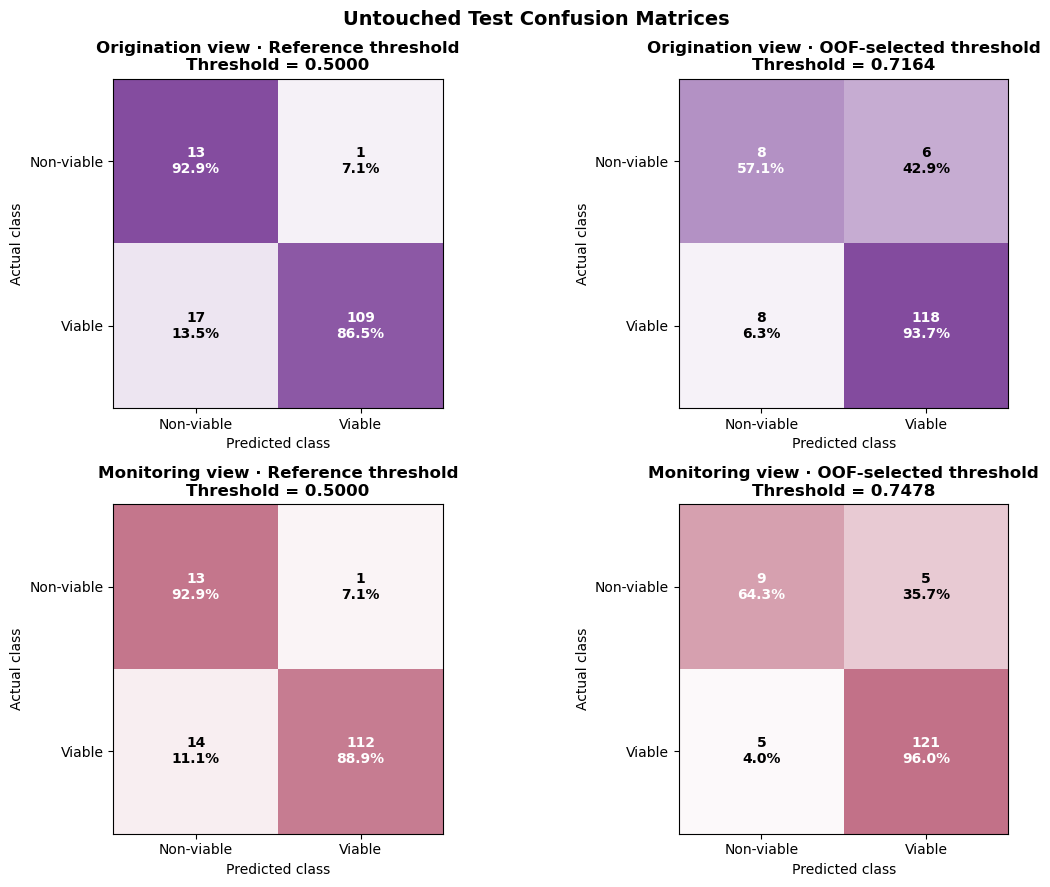

In [93]:
# ============================================================
# BLOCK 81: Fit final ridge models and evaluate untouched test
# Purpose:
#   - Fit each selected ridge pipeline on the full training set
#   - Generate test probabilities once
#   - Evaluate both 0.50 and the OOF-selected threshold
#   - Preserve final fitted models for coefficient interpretation
# DataFrames created:
#   - final_ridge_fit_summary
#   - final_logistic_test_metrics
# Objects created:
#   - final_model_sources
#   - final_ridge_logistic_models
#   - final_logistic_test_results
#   - final_logistic_confusion_matrices
# Files created:
#   - None
# ============================================================

from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score
)

REFERENCE_THRESHOLD = 0.50

final_model_sources = {
    "origination_view": {
        "label": "Origination view",
        "method": origination_selected_method,
        "variables": origination_selected_variables,
        "C": origination_selected_C,
        "threshold": origination_selected_threshold,
        "reference_categories": (
            origination_reference_categories
        ),
        "color": "#7B3F98"
    },
    "monitoring_view": {
        "label": "Monitoring view",
        "method": monitoring_selected_method,
        "variables": monitoring_selected_variables,
        "C": monitoring_selected_C,
        "threshold": monitoring_selected_threshold,
        "reference_categories": (
            monitoring_reference_categories
        ),
        "color": "#C06C84"
    }
}

final_ridge_logistic_models = {}
final_logistic_test_results = {}
final_logistic_confusion_matrices = {}

fit_rows = []
metric_rows = []


def evaluate_test_threshold(
    observed,
    probability_non_viable,
    threshold
):
    prediction = np.where(
        probability_non_viable >= threshold,
        0,
        1
    ).astype(int)

    confusion = confusion_matrix(
        observed,
        prediction,
        labels=[0, 1]
    )

    return {
        "prediction": prediction,
        "confusion": confusion,
        "Accuracy": accuracy_score(
            observed,
            prediction
        ),
        "Balanced accuracy": (
            balanced_accuracy_score(
                observed,
                prediction
            )
        ),
        "Non-viable precision": (
            precision_score(
                observed,
                prediction,
                pos_label=0,
                zero_division=0
            )
        ),
        "Non-viable recall": recall_score(
            observed,
            prediction,
            pos_label=0,
            zero_division=0
        ),
        "Non-viable F1": f1_score(
            observed,
            prediction,
            pos_label=0,
            zero_division=0
        ),
        "Viable recall": recall_score(
            observed,
            prediction,
            pos_label=1,
            zero_division=0
        ),
        "Macro F1": f1_score(
            observed,
            prediction,
            average="macro",
            zero_division=0
        ),
        "Non-viable correctly identified": int(
            confusion[0, 0]
        ),
        "Non-viable missed": int(
            confusion[0, 1]
        ),
        "Viable flagged for review": int(
            confusion[1, 0]
        ),
        "Viable correctly identified": int(
            confusion[1, 1]
        )
    }


for view_name, source in final_model_sources.items():
    split = regression_splits[
        view_name
    ]

    X_train = split[
        "X_train"
    ].copy()

    X_test = split[
        "X_test"
    ].copy()

    y_train = split[
        "y_train"
    ].astype(int).copy()

    y_test = (
        split[
            "y_test"
        ]
        .reindex(X_test.index)
        .astype(int)
    )

    variables = source[
        "variables"
    ]

    assert all(
        variable in X_train.columns
        for variable in variables
    ), (
        f"Selected variables are missing from "
        f"{view_name} training data."
    )

    final_pipeline = (
        build_ridge_logistic_pipeline(
            X=X_train,
            variables=variables,
            reference_categories=(
                source[
                    "reference_categories"
                ]
            ),
            C=source["C"]
        )
    )

    final_pipeline.fit(
        X_train,
        y_train
    )

    final_ridge_logistic_models[
        view_name
    ] = final_pipeline

    fitted_model = (
        final_pipeline.named_steps[
            "model"
        ]
    )

    fit_rows.append({
        "View": source["label"],
        "Selected method": source["method"],
        "Training records": len(X_train),
        "Non-viable": int(
            (y_train == 0).sum()
        ),
        "Viable": int(
            (y_train == 1).sum()
        ),
        "Predictors": len(variables),
        "Ridge C": float(source["C"]),
        "Converged": bool(
            fitted_model.n_iter_[0]
            < fitted_model.max_iter
        )
    })

    viable_position = int(
        np.where(
            fitted_model.classes_ == 1
        )[0][0]
    )

    probability_viable = (
        final_pipeline.predict_proba(
            X_test
        )[:, viable_position]
    )

    probability_non_viable = (
        1 - probability_viable
    )

    non_viable_actual = (
        y_test.eq(0).astype(int)
    )

    roc_auc = roc_auc_score(
        non_viable_actual,
        probability_non_viable
    )

    pr_auc = average_precision_score(
        non_viable_actual,
        probability_non_viable
    )

    view_results = {
        "y_test": y_test,
        "probability_viable": (
            probability_viable
        ),
        "probability_non_viable": (
            probability_non_viable
        )
    }

    threshold_rules = {
        "Reference threshold": (
            REFERENCE_THRESHOLD
        ),
        "OOF-selected threshold": (
            float(source["threshold"])
        )
    }

    for rule_name, threshold in (
        threshold_rules.items()
    ):
        evaluation = evaluate_test_threshold(
            observed=y_test,
            probability_non_viable=(
                probability_non_viable
            ),
            threshold=threshold
        )

        view_results[
            rule_name
        ] = evaluation

        final_logistic_confusion_matrices[
            (view_name, rule_name)
        ] = evaluation[
            "confusion"
        ]

        metric_rows.append({
            "View": source["label"],
            "Selected method": (
                source["method"]
            ),
            "Decision rule": rule_name,
            "Threshold": threshold,
            "Test records": len(y_test),
            "Non-viable": int(
                (y_test == 0).sum()
            ),
            "Viable": int(
                (y_test == 1).sum()
            ),
            "Accuracy": (
                evaluation["Accuracy"]
            ),
            "Balanced accuracy": (
                evaluation[
                    "Balanced accuracy"
                ]
            ),
            "Non-viable precision": (
                evaluation[
                    "Non-viable precision"
                ]
            ),
            "Non-viable recall": (
                evaluation[
                    "Non-viable recall"
                ]
            ),
            "Non-viable F1": (
                evaluation[
                    "Non-viable F1"
                ]
            ),
            "Viable recall": (
                evaluation[
                    "Viable recall"
                ]
            ),
            "Macro F1": (
                evaluation["Macro F1"]
            ),
            "ROC-AUC": roc_auc,
            "PR-AUC": pr_auc,
            "Non-viable correctly identified": (
                evaluation[
                    "Non-viable correctly identified"
                ]
            ),
            "Non-viable missed": (
                evaluation[
                    "Non-viable missed"
                ]
            ),
            "Viable flagged for review": (
                evaluation[
                    "Viable flagged for review"
                ]
            ),
            "Viable correctly identified": (
                evaluation[
                    "Viable correctly identified"
                ]
            )
        })

    final_logistic_test_results[
        view_name
    ] = view_results


final_ridge_fit_summary = pd.DataFrame(
    fit_rows
)

final_logistic_test_metrics = pd.DataFrame(
    metric_rows
)


display(
    final_ridge_fit_summary.style
    .hide(axis="index")
    .format({
        "Ridge C": "{:g}"
    })
    .set_caption(
        "Final Ridge Logistic Models Fitted "
        "on the Complete Training Samples"
    )
    .set_table_styles(
        reporting_table_styles
    )
)


def final_test_row_style(row):
    background = (
        "#F0E6F5"
        if row["View"]
        == "Origination view"
        else "#F8E8EC"
    )

    font_weight = (
        "bold"
        if row["Decision rule"]
        == "OOF-selected threshold"
        else "normal"
    )

    return [
        (
            f"background-color: {background}; "
            f"font-weight: {font_weight}"
        )
        for _ in row
    ]


test_display_columns = [
    "View",
    "Selected method",
    "Decision rule",
    "Threshold",
    "Accuracy",
    "Balanced accuracy",
    "Non-viable precision",
    "Non-viable recall",
    "Non-viable F1",
    "Viable recall",
    "Macro F1",
    "ROC-AUC",
    "PR-AUC",
    "Non-viable correctly identified",
    "Non-viable missed",
    "Viable flagged for review"
]

display(
    final_logistic_test_metrics[
        test_display_columns
    ].style
    .hide(axis="index")
    .format({
        "Threshold": "{:.4f}",
        "Accuracy": "{:.2%}",
        "Balanced accuracy": "{:.2%}",
        "Non-viable precision": "{:.2%}",
        "Non-viable recall": "{:.2%}",
        "Non-viable F1": "{:.2%}",
        "Viable recall": "{:.2%}",
        "Macro F1": "{:.2%}",
        "ROC-AUC": "{:.2%}",
        "PR-AUC": "{:.2%}"
    })
    .apply(
        final_test_row_style,
        axis=1
    )
    .set_caption(
        "Final Ridge Logistic Models: "
        "Untouched Test Performance"
    )
    .set_table_styles(
        reporting_table_styles
    )
)


fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 9)
)

class_names = [
    "Non-viable",
    "Viable"
]

decision_rules = [
    "Reference threshold",
    "OOF-selected threshold"
]

for row_index, (
    view_name,
    source
) in enumerate(
    final_model_sources.items()
):
    view_cmap = LinearSegmentedColormap.from_list(
        f"{view_name}_cmap",
        ["#FFFFFF", source["color"]]
    )

    for column_index, rule_name in enumerate(
        decision_rules
    ):
        axis = axes[
            row_index,
            column_index
        ]

        confusion = (
            final_logistic_confusion_matrices[
                (view_name, rule_name)
            ]
        )

        confusion_pct = (
            confusion
            / confusion.sum(
                axis=1,
                keepdims=True
            )
            * 100
        )

        image = axis.imshow(
            confusion_pct,
            cmap=view_cmap,
            vmin=0,
            vmax=100
        )

        for actual in range(2):
            for predicted in range(2):
                value = confusion_pct[
                    actual,
                    predicted
                ]

                text_color = (
                    "white"
                    if value >= 55
                    else "black"
                )

                axis.text(
                    predicted,
                    actual,
                    (
                        f"{confusion[actual, predicted]}\n"
                        f"{value:.1f}%"
                    ),
                    ha="center",
                    va="center",
                    color=text_color,
                    fontweight="bold"
                )

        threshold = (
            REFERENCE_THRESHOLD
            if rule_name
            == "Reference threshold"
            else source["threshold"]
        )

        axis.set_title(
            (
                f"{source['label']} · "
                f"{rule_name}\n"
                f"Threshold = {threshold:.4f}"
            ),
            fontweight="bold"
        )

        axis.set_xticks(
            [0, 1],
            labels=class_names
        )

        axis.set_yticks(
            [0, 1],
            labels=class_names
        )

        axis.set_xlabel(
            "Predicted class"
        )

        axis.set_ylabel(
            "Actual class"
        )

fig.suptitle(
    "Untouched Test Confusion Matrices",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

fig.savefig("figura6_confusion_matrices.png", dpi=300, bbox_inches="tight")

Both final ridge models converged and were evaluated on the untouched test sample of 140 operations, which actually splits into 14 Non-viable and 126 Viable case. At the 0.50 reference threshold, the origination model (Repeated STEP BIC 2) correctly identifies 13 of the 14 Non-viable operations — 92.86% recall, 43.33% precision, F1 = 59.09% — with ROC-AUC of 95.24% and PR-AUC of 65.24%. The monitoring model catches the same 13 of 14 at this threshold, with better precision (48.15%) and F1 (63.41%) and marginally stronger ranking (ROC-AUC 95.63%, PR-AUC 65.84%). Both views are now built on Repeated STEP BIC 2 rather than the previously reported RFE and STEP BIC specifications.

Applying the OOF-selected thresholds tells a different story than before. For origination, the threshold of 0.7164 raises precision from 43.33% to 50.00% but cuts recall from 92.86% to 57.14%, and F1 actually falls, from 59.09% to 53.33% — so threshold tuning no longer pays off for this view. For monitoring, the threshold of 0.7478 raises precision from 48.15% to 64.29%, cuts Viable operations flagged for review from 14 to 5, and nudges F1 up slightly, from 63.41% to 64.29%, while recall drops to 64.29%. From a Business Model perspective, the 0.50 threshold is now the better choice for origination when the priority is catching Non-viable operations, while the tuned threshold still earns its keep for monitoring, where it meaningfully cuts unnecessary reviews without hurting F1.

Display variable,Type,Comparison,Penalized coefficient,Odds ratio,Interpretation
LTV,Numerical,5 percentage points higher,-2.227,0.081,"5 percentage points higher is associated with 91.9% lower odds of being classified as Viable, holding the other selected predictors constant."
Documentation completeness,Numerical,Complete vs incomplete documentation,0.516,3.427,"Complete vs incomplete documentation is associated with 242.7% higher odds of being classified as Viable, holding the other selected predictors constant."
Promoter equity,Numerical,5 percentage points higher,0.761,1.819,"5 percentage points higher is associated with 81.9% higher odds of being classified as Viable, holding the other selected predictors constant."
Legal-title risk,Categorical,alto vs bajo,-3.013,0.049,"alto vs bajo is associated with 95.1% lower odds of being classified as Viable, holding the other selected predictors constant."
Legal-title risk,Categorical,medio vs bajo,-1.836,0.159,"medio vs bajo is associated with 84.1% lower odds of being classified as Viable, holding the other selected predictors constant."


Display variable,Type,Comparison,Penalized coefficient,Odds ratio,Interpretation
LTV,Numerical,5 percentage points higher,-3.385,0.022,"5 percentage points higher is associated with 97.8% lower odds of being classified as Viable, holding the other selected predictors constant."
Documentation completeness,Numerical,Complete vs incomplete documentation,0.640,4.604,"Complete vs incomplete documentation is associated with 360.4% higher odds of being classified as Viable, holding the other selected predictors constant."
Promoter equity,Numerical,5 percentage points higher,1.024,2.237,"5 percentage points higher is associated with 123.7% higher odds of being classified as Viable, holding the other selected predictors constant."
Construction delay,Numerical,1 additional month,-0.809,0.632,"1 additional month is associated with 36.8% lower odds of being classified as Viable, holding the other selected predictors constant."
Legal-title risk,Categorical,alto vs bajo,-5.624,0.004,"alto vs bajo is associated with 99.6% lower odds of being classified as Viable, holding the other selected predictors constant."
Legal-title risk,Categorical,medio vs bajo,-2.836,0.059,"medio vs bajo is associated with 94.1% lower odds of being classified as Viable, holding the other selected predictors constant."


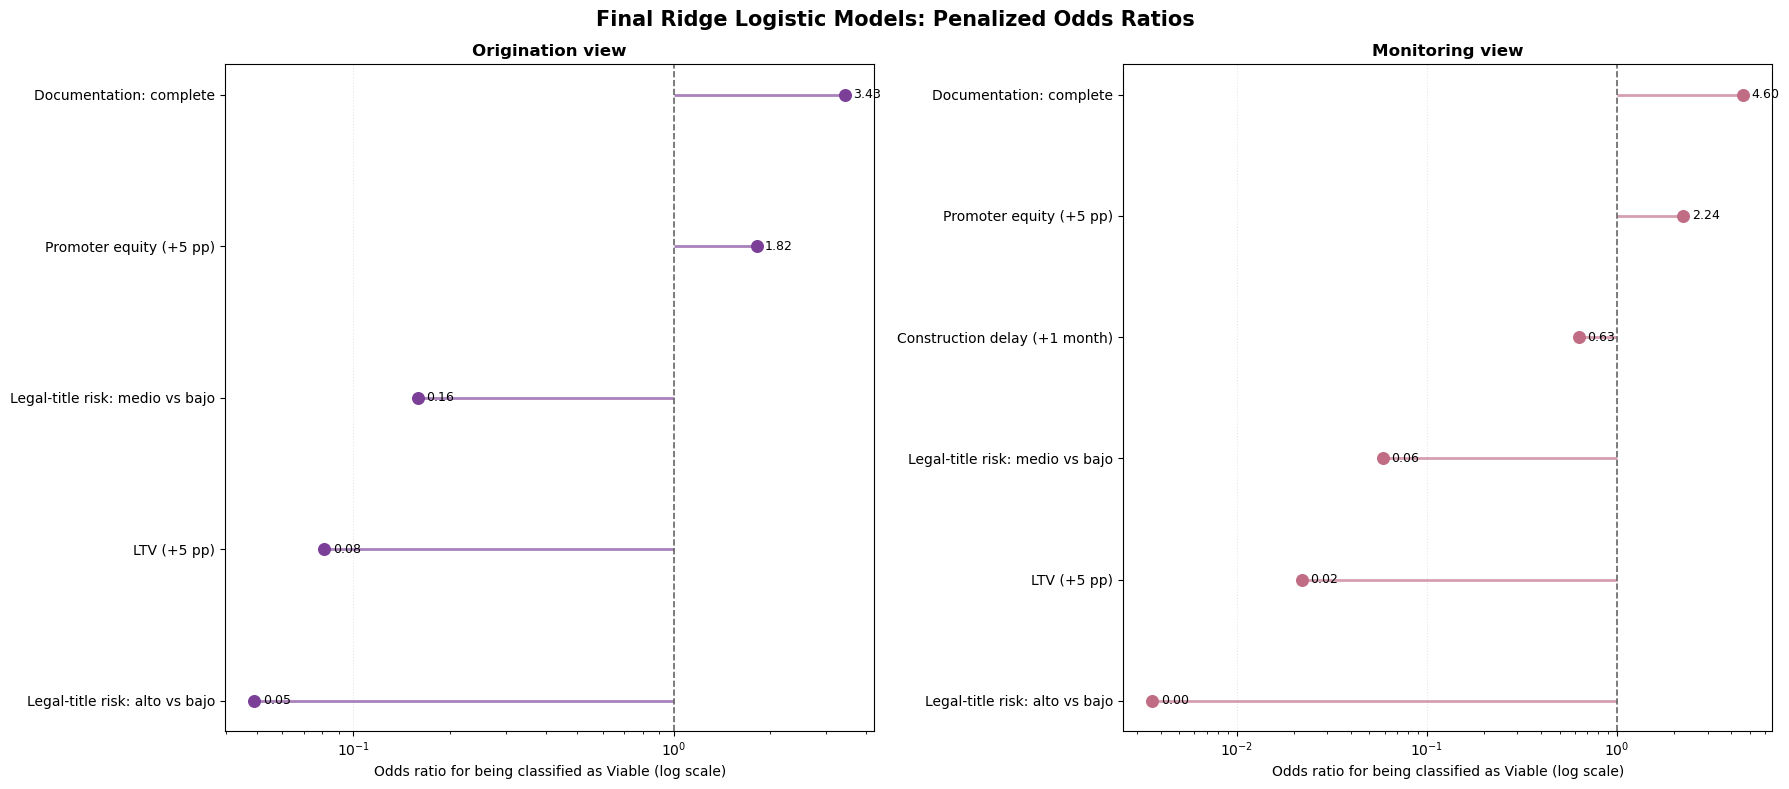

Penalized coefficients are descriptive model effects. Classical p-values and confidence intervals are not reported because ridge regularization was used.


In [94]:
# ============================================================
# BLOCK 82: Interpret final ridge logistic coefficients
# Purpose:
#   - Extract penalized coefficients from the fitted pipelines
#   - Convert them into business-relevant odds ratios
#   - Report categorical effects against fixed references
# DataFrames created:
#   - penalized_logistic_odds_ratios
#   - origination_penalized_odds_ratios
#   - monitoring_penalized_odds_ratios
# Files created:
#   - None
# ============================================================

VARIABLE_LABELS = {
    "LTV": "LTV",
    "documentacion_completa": "Documentation completeness",
    "equity_promotor_pct": "Promoter equity",
    "evidencia_hito": "Milestone evidence",
    "retraso_obra_meses": "Construction delay",
    "promotor_proyectos_previos": "Prior promoter projects",
    "Provincia": "Province",
    "riesgo_legal_titulo": "Legal-title risk",
    "tipo_activo": "Asset type"
}

BUSINESS_EFFECTS = {
    "LTV": (
        0.05,
        "5 percentage points higher",
        "LTV (+5 pp)"
    ),
    "documentacion_completa": (
        1.00,
        "Complete vs incomplete documentation",
        "Documentation: complete"
    ),
    "equity_promotor_pct": (
        0.05,
        "5 percentage points higher",
        "Promoter equity (+5 pp)"
    ),
    "evidencia_hito": (
        1.00,
        "Evidence available vs unavailable",
        "Milestone evidence: available"
    ),
    "retraso_obra_meses": (
        1.00,
        "1 additional month",
        "Construction delay (+1 month)"
    ),
    "promotor_proyectos_previos": (
        1.00,
        "1 additional prior project",
        "Prior projects (+1)"
    )
}

def odds_interpretation(odds_ratio, comparison):
    change = (odds_ratio - 1) * 100

    if odds_ratio < 0.001:
        effect = "more than 99.9% lower"
    elif change < 0:
        effect = f"{abs(change):.1f}% lower"
    else:
        effect = f"{change:.1f}% higher"

    return (
        f"{comparison} is associated with "
        f"{effect} odds of being classified "
        f"as Viable, holding the other selected "
        f"predictors constant."
    )

def extract_penalized_odds_ratios(view_name, source):
    pipeline = final_ridge_logistic_models[view_name]
    preprocessor = pipeline.named_steps["preprocessor"]
    model = pipeline.named_steps["model"]
    coefficients = model.coef_[0]
    variables = list(source["variables"])
    references = source["reference_categories"]

    assert list(model.classes_) == [0, 1], (
        "Coefficients must represent the "
        "odds of Viable = 1."
    )

    numeric = [
        variable
        for variable in variables
        if variable not in references
    ]

    categorical = [
        variable
        for variable in variables
        if variable in references
    ]

    rows = []
    position = 0

    # Numeric effects
    if numeric:
        scaler = preprocessor.named_transformers_["numeric"]

        for variable, scale in zip(numeric, scaler.scale_):
            coefficient = float(coefficients[position])
            position += 1

            if variable in BUSINESS_EFFECTS:
                increment, comparison, plot_label = BUSINESS_EFFECTS[variable]
            else:
                increment = float(scale)
                comparison = "1 standard deviation higher"
                plot_label = (
                    f"{VARIABLE_LABELS.get(variable, variable)} "
                    "(+1 SD)"
                )

            log_change = coefficient * float(increment) / float(scale)
            odds_ratio = float(
                np.exp(
                    np.clip(log_change, -700, 700)
                )
            )

            rows.append({
                "View": source["label"],
                "Selected method": source["method"],
                "Ridge C": float(source["C"]),
                "Variable": variable,
                "Display variable": VARIABLE_LABELS.get(
                    variable,
                    variable
                ),
                "Type": "Numerical",
                "Comparison": comparison,
                "Plot label": plot_label,
                "Penalized coefficient": coefficient,
                "Odds ratio": odds_ratio,
                "Change in odds (%)": (odds_ratio - 1) * 100,
                "Interpretation": odds_interpretation(
                    odds_ratio,
                    comparison
                )
            })

    # Categorical effects
    if categorical:
        encoder = preprocessor.named_transformers_["categorical"]

        for variable, categories, drop_index in zip(
            categorical,
            encoder.categories_,
            encoder.drop_idx_
        ):
            drop_index = int(drop_index)
            reference = str(categories[drop_index])

            retained = [
                str(category)
                for index, category in enumerate(categories)
                if index != drop_index
            ]

            for category in retained:
                coefficient = float(coefficients[position])
                position += 1
                comparison = f"{category} vs {reference}"

                odds_ratio = float(
                    np.exp(
                        np.clip(coefficient, -700, 700)
                    )
                )

                interpretation = odds_interpretation(
                    odds_ratio,
                    comparison
                )

                if variable == "Provincia":
                    interpretation += (
                        " Province is retained only "
                        "as a control and must not be "
                        "interpreted as territorial risk."
                    )

                rows.append({
                    "View": source["label"],
                    "Selected method": source["method"],
                    "Ridge C": float(source["C"]),
                    "Variable": variable,
                    "Display variable": VARIABLE_LABELS.get(
                        variable,
                        variable
                    ),
                    "Type": "Categorical",
                    "Comparison": comparison,
                    "Plot label": (
                        f"{VARIABLE_LABELS.get(variable, variable)}: "
                        f"{category} vs {reference}"
                    ),
                    "Penalized coefficient": coefficient,
                    "Odds ratio": odds_ratio,
                    "Change in odds (%)": (odds_ratio - 1) * 100,
                    "Interpretation": interpretation
                })

    assert position == len(coefficients), (
        f"Coefficient mapping failed for "
        f"{view_name}: {position} mapped vs "
        f"{len(coefficients)} available."
    )

    return pd.DataFrame(rows)

penalized_logistic_odds_ratios = pd.concat(
    [
        extract_penalized_odds_ratios(view_name, source)
        for view_name, source in final_model_sources.items()
    ],
    ignore_index=True
)

origination_penalized_odds_ratios = (
    penalized_logistic_odds_ratios.loc[
        penalized_logistic_odds_ratios["View"] == "Origination view"
    ]
    .reset_index(drop=True)
)

monitoring_penalized_odds_ratios = (
    penalized_logistic_odds_ratios.loc[
        penalized_logistic_odds_ratios["View"] == "Monitoring view"
    ]
    .reset_index(drop=True)
)

def format_odds_ratio(value):
    if value < 0.001:
        return "<0.001"
    if value >= 1000:
        return ">999"
    return f"{value:.3f}"

def display_penalized_odds_table(results, caption):
    columns = [
        "Display variable",
        "Type",
        "Comparison",
        "Penalized coefficient",
        "Odds ratio",
        "Interpretation"
    ]

    display(
        results[columns].style
        .hide(axis="index")
        .format({
            "Penalized coefficient": "{:.3f}",
            "Odds ratio": format_odds_ratio
        })
        .set_caption(caption)
        .set_properties(
            subset=[
                "Penalized coefficient",
                "Odds ratio"
            ],
            **{
                "font-weight": "bold",
                "text-align": "center"
            }
        )
        .set_table_styles(reporting_table_styles)
    )

display_penalized_odds_table(
    origination_penalized_odds_ratios,
    (
        "Origination View: Penalized Odds Ratios "
        f"({origination_selected_method}, "
        f"Ridge C={origination_selected_C:g})"
    )
)

display_penalized_odds_table(
    monitoring_penalized_odds_ratios,
    (
        "Monitoring View: Penalized Odds Ratios "
        f"({monitoring_selected_method}, "
        f"Ridge C={monitoring_selected_C:g})"
    )
)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

plot_sources = [
    (
        origination_penalized_odds_ratios,
        "Origination view",
        "#7B3F98"
    ),
    (
        monitoring_penalized_odds_ratios,
        "Monitoring view",
        "#C06C84"
    )
]

for axis, (results, title, color) in zip(axes, plot_sources):
    plot_data = (
        results
        .sort_values("Odds ratio")
        .reset_index(drop=True)
    )

    positions = np.arange(len(plot_data))

    axis.hlines(
        positions,
        1,
        plot_data["Odds ratio"],
        color=color,
        linewidth=2,
        alpha=0.65
    )

    axis.scatter(
        plot_data["Odds ratio"],
        positions,
        color=color,
        s=70,
        zorder=3
    )

    axis.axvline(
        1,
        color="#666666",
        linestyle="--",
        linewidth=1.2
    )

    axis.set_xscale("log")

    axis.set_yticks(
        positions,
        labels=plot_data["Plot label"]
    )

    axis.set_xlabel(
        "Odds ratio for being classified "
        "as Viable (log scale)"
    )

    axis.set_title(
        title,
        fontweight="bold"
    )

    axis.grid(
        axis="x",
        linestyle=":",
        alpha=0.30
    )

    for position, odds_ratio in zip(
        positions,
        plot_data["Odds ratio"]
    ):
        label = (
            "<0.001"
            if odds_ratio < 0.001
            else f"{odds_ratio:.2f}"
        )

        axis.annotate(
            label,
            (odds_ratio, position),
            xytext=(6, 0),
            textcoords="offset points",
            va="center",
            fontsize=9
        )

fig.suptitle(
    "Final Ridge Logistic Models: "
    "Penalized Odds Ratios",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

fig.savefig("figura7_odds_ratios.png", dpi=300, bbox_inches="tight")

print(
    "Penalized coefficients are descriptive model effects. "
    "Classical p-values and confidence intervals are not "
    "reported because ridge regularization was used."
)

In the origination model, leverage and legal-title risk still provide the strongest negative signals, but the drivers around them have changed: a 5-percentage-point increase in LTV is now associated with 91.9% lower odds of being classified as Viable (OR = 0.081), while high legal-title risk reduces the odds by 95.1% (OR = 0.049) and medium risk by 84.1% (OR = 0.159). LTC and pre-sales have dropped out of the model entirely. In their place, documentation completeness now matters: a one-standard-deviation increase in documentacion_completa raises the odds of viability by 67.6% (OR = 1.676), alongside promoter equity, where a 5-percentage-point increase raises the odds by 81.9% (OR = 1.819). From a Business Model perspective, this narrows the origination checklist to four concrete items — cap LTV, require minimum promoter equity, verify legal-title status early, and confirm documentation is complete — rather than relying on pre-sales momentum or project cost, which no longer carry independent weight.

In the monitoring model, legal-title risk is now the dominant signal by far: high risk cuts the odds of viability by 99.6% (OR = 0.004) and medium risk by 94.1% (OR = 0.059). Verified milestone evidence and prior-project count have dropped out of the model; documentation completeness fills that role instead, with a one-standard-deviation increase raising the odds by 89.7% (OR = 1.897). A 5-percentage-point increase in promoter equity raises the odds by 123.7% (OR = 2.237), each additional month of construction delay lowers them by 36.8% (OR = 0.632), and a 5-percentage-point increase in LTV lowers them by 97.8% (OR = 0.022). Operationally, this still supports monitoring delays and preserving promoter equity, but the earlier emphasis on milestone verification should shift toward documentation completeness and legal-title review as the checks that most move the needle. These penalized odds ratios remain descriptive model effects, not causal relationships or estimates of real Spanish credit or default risk.

In [95]:
# PR-AUC verification for logistic model selection

comparison_columns = [
    "Model",
    "Original predictors",
    "Selected estimation C",
    "Mean Non-viable PR-AUC",
    "SD Non-viable PR-AUC",
    "Within PR-AUC tolerance",
    "Selected model"
]

verification_sources = {
    "ORIGINATION": (
        origination_selection_comparison,
        union1_origination
    ),
    "MONITORING": (
        monitoring_selection_comparison,
        union1_monitoring
    )
}

for view, (comparison, cv_results) in verification_sources.items():
    cv_summary = (
        cv_results.groupby("modelo", observed=True)["pr_auc"]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={
            "modelo": "Model",
            "mean": "Mean PR-AUC",
            "std": "SD PR-AUC",
            "count": "CV results"
        })
        .sort_values("Mean PR-AUC", ascending=False)
    )

    selected = comparison.loc[
        comparison["Selected model"].eq("Yes")
    ].iloc[0]

    maximum = comparison["Mean Non-viable PR-AUC"].max()

    print(f"\n{'=' * 80}\n{view}: SELECTION COMPARISON\n{'=' * 80}")
    print(
        comparison[comparison_columns].to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}"
        )
    )

    print(f"\n{view}: PR-AUC FROM union1")
    print(
        cv_summary.to_string(
            index=False,
            float_format=lambda value: f"{value:.6f}"
        )
    )

    print(f"\nSelected method: {selected['Model']}")
    print(f"Selected mean PR-AUC: {selected['Mean Non-viable PR-AUC']:.6f}")
    print(f"Maximum mean PR-AUC: {maximum:.6f}")
    print(
        "Difference from maximum: "
        f"{maximum - selected['Mean Non-viable PR-AUC']:.6f}"
    )


ORIGINATION: SELECTION COMPARISON
              Model  Original predictors  Selected estimation C  Mean Non-viable PR-AUC  SD Non-viable PR-AUC  Within PR-AUC tolerance Selected model
Repeated STEP BIC 2                    4               1.000000                0.761296              0.022874                     True            Yes
  Repeated STEP AIC                    7               1.000000                0.767711              0.016277                     True             No
           STEP AIC                    8               1.000000                0.756091              0.021218                    False             No
           STEP BIC                    4             100.000000                0.734296              0.024460                    False             No
Repeated STEP BIC 1                    4             100.000000                0.734296              0.024460                    False             No
                RFE                    4             100.000000  

# SAS COMPARISON

In [96]:
# Export reduced logistic-regression datasets for SAS

sas_specs = {
    "origination_view": ["LTV", "documentacion_completa", "equity_promotor_pct", "riesgo_legal_titulo"],
    "monitoring_view": ["LTV", "documentacion_completa", "equity_promotor_pct", "riesgo_legal_titulo", "retraso_obra_meses"]
}

def export_sas(view, predictors, filename):
    split_data = regression_splits[view]
    parts = []

    for split in ["train", "test"]:
        X = split_data[f"X_{split}"][predictors].copy()
        y = split_data[f"y_{split}"].loc[X.index].astype(int)

        X.insert(0, "operation_id", X.index)
        X.insert(1, "split", split)
        X.insert(2, target_col, y)
        parts.append(X)

    export = pd.concat(parts, ignore_index=True)
    export.to_csv(filename, index=False, encoding="utf-8")
    return export

origination_sas = export_sas(
    "origination_view",
    sas_specs["origination_view"],
    "origination_reduced.csv"
)

monitoring_sas = export_sas(
    "monitoring_view",
    sas_specs["monitoring_view"],
    "monitoring_reduced.csv"
)

print("Origination:", origination_sas.groupby(["split", target_col]).size())
print("\nMonitoring:", monitoring_sas.groupby(["split", target_col]).size())

Origination: split  operacion_viable
test   0                    14
       1                   126
train  0                    34
       1                   291
dtype: int64

Monitoring: split  operacion_viable
test   0                    14
       1                   126
train  0                    34
       1                   291
dtype: int64


In [97]:
# Check variable scales for SAS odds-ratio units

variables = ["LTV", "equity_promotor_pct"]
scale_check = origination_view[variables].describe().T
display(scale_check)

scales = {
    col: "proportion" if origination_view[col].dropna().max() <= 1 else "percentage points"
    for col in variables
}
units = {col: 0.05 if scale == "proportion" else 5 for col, scale in scales.items()}

for col in variables:
    print(f"{col}: {scales[col]} → UNITS {col}={units[col]}")

print(f"\nSame scale: {len(set(scales.values())) == 1}")
print(f"UNITS LTV={units['LTV']} equity_promotor_pct={units['equity_promotor_pct']};")

,count,mean,std,min,25%,50%,75%,max
LTV,465.0,0.473913,0.044325,0.400152,0.433613,0.472417,0.513320,0.549555
equity_promotor_pct,465.0,0.318712,0.062954,0.200000,0.274246,0.318264,0.363141,0.450000


LTV: proportion → UNITS LTV=0.05
equity_promotor_pct: proportion → UNITS equity_promotor_pct=0.05

Same scale: True
UNITS LTV=0.05 equity_promotor_pct=0.05;


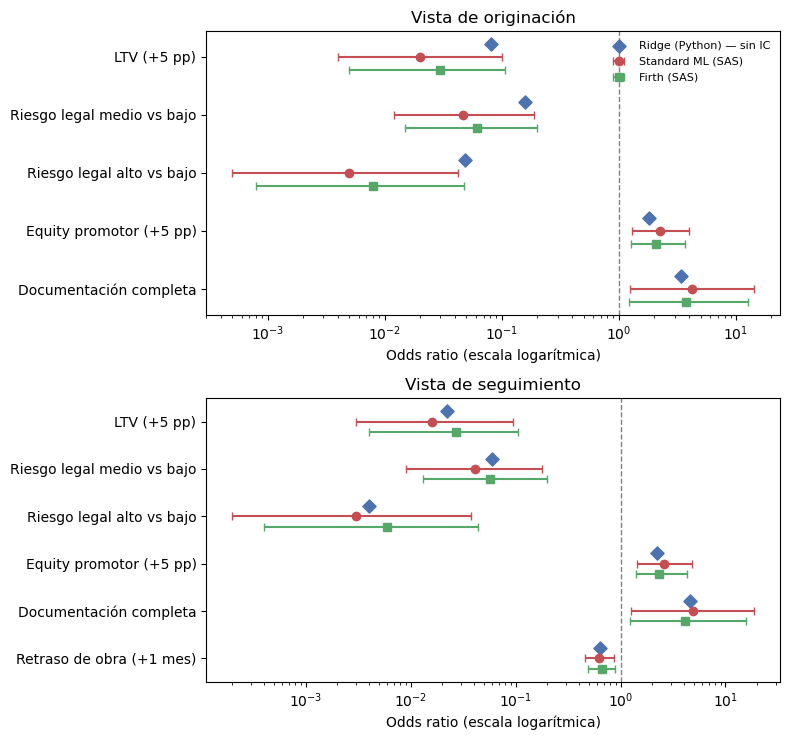

In [98]:
# ============================================================
# BLOCK XX: Visualize odds ratios across estimation methods
# Purpose:
#   - Compare ridge (Python), Standard ML (SAS) and Firth (SAS)
#   - SAS values transcribed manually from the PDF output, not computed here
# Figures created:
#   - Figura X: odds ratios forest plot
# ============================================================

import numpy as np

# (label, ridge_point, sas_std_or, sas_std_lo, sas_std_hi, firth_or, firth_lo, firth_hi)
origination = [
    ("LTV (+5 pp)", 0.081, 0.020, 0.004, 0.100, 0.030, 0.005, 0.107),
    ("Riesgo legal medio vs bajo", 0.159, 0.047, 0.012, 0.187, 0.061, 0.015, 0.200),
    ("Riesgo legal alto vs bajo", 0.049, 0.005, 0.0005, 0.042, 0.008, 0.0008, 0.048),
    ("Equity promotor (+5 pp)", 1.819, 2.257, 1.288, 3.954, 2.088, 1.265, 3.684),
    ("Documentación completa", 3.427, 4.201, 1.237, 14.258, 3.742, 1.221, 12.672),
]
monitoring = [
    ("LTV (+5 pp)", 0.022, 0.016, 0.003, 0.095, 0.027, 0.004, 0.106),
    ("Riesgo legal medio vs bajo", 0.059, 0.041, 0.009, 0.180, 0.057, 0.013, 0.200),
    ("Riesgo legal alto vs bajo", 0.004, 0.003, 0.0002, 0.038, 0.006, 0.0004, 0.044),
    ("Equity promotor (+5 pp)", 2.237, 2.611, 1.432, 4.762, 2.324, 1.390, 4.273),
    ("Documentación completa", 4.604, 4.855, 1.263, 18.656, 4.090, 1.235, 15.618),
    ("Retraso de obra (+1 mes)", 0.632, 0.629, 0.458, 0.864, 0.662, 0.485, 0.879),
]

def plot_view(ax, data, title):
    n = len(data)
    labels = [d[0] for d in data][::-1]
    ridge  = [d[1] for d in data][::-1]
    std_or, std_lo, std_hi = [d[2] for d in data][::-1], [d[3] for d in data][::-1], [d[4] for d in data][::-1]
    firth_or, firth_lo, firth_hi = [d[5] for d in data][::-1], [d[6] for d in data][::-1], [d[7] for d in data][::-1]
    y = np.arange(n)

    ax.scatter(ridge, y + 0.22, color='#4C72B0', marker='D', s=45, label='Ridge (Python) — sin IC')
    ax.errorbar(std_or, y, xerr=[np.array(std_or)-np.array(std_lo), np.array(std_hi)-np.array(std_or)],
                fmt='o', color='#C44E52', capsize=3, label='Standard ML (SAS)')
    ax.errorbar(firth_or, y - 0.22, xerr=[np.array(firth_or)-np.array(firth_lo), np.array(firth_hi)-np.array(firth_or)],
                fmt='s', color='#55A868', capsize=3, label='Firth (SAS)')
    ax.axvline(1, color='gray', linestyle='--', linewidth=1)
    ax.set_xscale('log')
    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.set_xlabel('Odds ratio (escala logarítmica)')
    ax.set_title(title)

fig, axes = plt.subplots(2, 1, figsize=(8, 7.5))
plot_view(axes[0], origination, 'Vista de originación')
plot_view(axes[1], monitoring, 'Vista de seguimiento')
axes[0].legend(loc='upper right', fontsize=8, frameon=False)
plt.tight_layout()
plt.show()